# NB06 - Mindray native export exploration

This notebook explores Mindray TE7 native export folders as standalone acquisition packages.

The goal is **not yet** to improve NB01-NB05.

The goal is also **not** to immediately replace manual ROI selection, velocity calibration, or time-axis calibration.

The first goal is to understand what information exists inside the Mindray native export itself:
- readable metadata,
- CIN descriptor,
- PW cine partition,
- BC cine partition,
- system/backend files,
- virtual machine/display files,
- thumbnail or patient-info side files,
- possible waveform data,
- possible image/cine data,
- possible audio data,
- possible calibration metadata.

Current folder convention:

```text
ultrasound_recordings/
  batch_2026_06_13_native/
    <recording_id>/
      native/
        real Mindray native export files

      linked_avi/
        manually copied AVI reference file

## Import and Setup

In [1]:
import math, cv2, subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, hilbert, find_peaks

PROJECT_ROOT = Path(r"D:\code\DopplerLab")
ULTRASOUND_RECORDINGS_DIR = PROJECT_ROOT / "ultrasound_recordings"
NATIVE_BATCH_DIR = ULTRASOUND_RECORDINGS_DIR / "batch_2026_06_13_native"
NATIVE_BATCH_DIR.exists(), NATIVE_BATCH_DIR

(True,
 WindowsPath('D:/code/DopplerLab/ultrasound_recordings/batch_2026_06_13_native'))

## Folders Inspection

In [2]:
def inspect_mindray_native_batch(native_batch_dir):
    """
    Inspect a Mindray native-export batch directory.

    Expected folder structure
    -------------------------
    native_batch_dir/
        recording_id_1/
            native/
                real Mindray native export files
            linked_avi/
                manually copied AVI reference files

        recording_id_2/
            native/
            linked_avi/

    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Path to the batch folder containing one subfolder per Mindray recording ID.

    Returns
    -------
    inventory_df : pandas.DataFrame
        One row per discovered file.

    recording_summary_df : pandas.DataFrame
        One row per recording folder.

    file_pattern_summary_df : pandas.DataFrame
        Summary of file names/suffixes across recordings.
    """
    native_batch_dir = Path(native_batch_dir)

    if not native_batch_dir.exists():
        raise FileNotFoundError(f"Native batch directory does not exist: {native_batch_dir}")
    if not native_batch_dir.is_dir():
        raise NotADirectoryError(f"Expected a directory, got: {native_batch_dir}")

    rows = []

    recording_dirs = sorted([path for path in native_batch_dir.iterdir() if path.is_dir()])

    for recording_dir in recording_dirs:
        recording_id = recording_dir.name

        for source_group in ["native", "linked_avi"]:
            source_dir = recording_dir / source_group

            if not source_dir.exists():
                rows.append(
                    {
                        "recording_id": recording_id,
                        "source_group": source_group,
                        "file_name": None,
                        "suffix": None,
                        "relative_path": None,
                        "size_bytes": np.nan,
                        "size_kb": np.nan,
                        "size_mb": np.nan,
                        "exists": False,
                    }
                )
                continue

            files = sorted(
                [path for path in source_dir.iterdir() if path.is_file()])

            if len(files) == 0:
                rows.append(
                    {
                        "recording_id": recording_id,
                        "source_group": source_group,
                        "file_name": None,
                        "suffix": None,
                        "relative_path": str(source_dir.relative_to(native_batch_dir)),
                        "size_bytes": np.nan,
                        "size_kb": np.nan,
                        "size_mb": np.nan,
                        "exists": True,
                    }
                )
                continue

            for file_path in files:
                size_bytes = file_path.stat().st_size

                rows.append(
                    {
                        "recording_id": recording_id,
                        "source_group": source_group,
                        "file_name": file_path.name,
                        "suffix": file_path.suffix.lower(),
                        "relative_path": str(file_path.relative_to(native_batch_dir)),
                        "size_bytes": size_bytes,
                        "size_kb": size_bytes / 1024,
                        "size_mb": size_bytes / (1024 ** 2),
                        "exists": True,
                    }
                )

    inventory_df = pd.DataFrame(rows)

    if len(inventory_df) == 0:
        recording_summary_df = pd.DataFrame()
        file_pattern_summary_df = pd.DataFrame()
        return inventory_df, recording_summary_df, file_pattern_summary_df

    valid_file_df = inventory_df[inventory_df["file_name"].notna()].copy()

    recording_summary_df = (
        inventory_df
        .groupby("recording_id", dropna=False)
        .agg(
            n_rows=("file_name", "size"),
            n_files=("file_name", lambda x: x.notna().sum()),
            n_native_files=("source_group", lambda x: (x == "native").sum()),
            n_linked_avi_files=("source_group", lambda x: (x == "linked_avi").sum()),
            total_size_mb=("size_mb", "sum"),
        )
        .reset_index()
        .sort_values("recording_id")
    )

    if len(valid_file_df) > 0:
        file_pattern_summary_df = (
            valid_file_df
            .groupby(["source_group", "file_name", "suffix"], dropna=False)
            .agg(
                present_in_n_recordings=("recording_id", "nunique"),
                min_size_mb=("size_mb", "min"),
                max_size_mb=("size_mb", "max"),
                mean_size_mb=("size_mb", "mean"),
            )
            .reset_index()
            .sort_values(
                ["source_group", "present_in_n_recordings", "file_name"],
                ascending=[True, False, True],
            )
        )
    else:
        file_pattern_summary_df = pd.DataFrame()

    return inventory_df, recording_summary_df, file_pattern_summary_df

In [3]:
inventory_df, recording_summary_df, file_pattern_summary_df = inspect_mindray_native_batch(NATIVE_BATCH_DIR)

In [4]:
recording_summary_df

,recording_id,n_rows,n_files,n_native_files,n_linked_avi_files,total_size_mb
0,202606130411060002SMP,13,13,12,1,51.116372
1,202606130413540003SMP,13,13,12,1,41.649874
2,202606130417060004SMP,13,13,12,1,35.426894
3,202606130420260005SMP,13,13,12,1,43.469953
4,202606130422440006SMP,13,13,12,1,47.106079
5,202606130426500007SMP,13,13,12,1,35.094589
6,202606130430380008SMP,13,13,12,1,37.367611
7,202606130433280009SMP,13,13,12,1,32.710211
8,202606130434130010SMP,13,13,12,1,34.635743
9,202606130437480012SMP,13,13,12,1,37.604373


In [5]:
file_pattern_summary_df

,source_group,file_name,suffix,present_in_n_recordings,min_size_mb,max_size_mb,mean_size_mb
0,linked_avi,202606130411060002SMP.avi,.avi,1,14.130285,14.130285,14.130285
1,linked_avi,202606130413540003SMP.avi,.avi,1,12.250275,12.250275,12.250275
2,linked_avi,202606130417060004SMP.avi,.avi,1,8.856974,8.856974,8.856974
3,linked_avi,202606130420260005SMP.avi,.avi,1,14.946545,14.946545,14.946545
4,linked_avi,202606130422440006SMP.avi,.avi,1,15.089249,15.089249,15.089249
5,linked_avi,202606130426500007SMP.avi,.avi,1,12.053253,12.053253,12.053253
6,linked_avi,202606130430380008SMP.avi,.avi,1,9.588215,9.588215,9.588215
7,linked_avi,202606130433280009SMP.avi,.avi,1,12.658623,12.658623,12.658623
8,linked_avi,202606130434130010SMP.avi,.avi,1,13.345186,13.345186,13.345186
9,linked_avi,202606130437480012SMP.avi,.avi,1,9.391102,9.391102,9.391102


In [6]:
inventory_df.head(30)

,recording_id,source_group,file_name,suffix,relative_path,size_bytes,size_kb,size_mb,exists
0,202606130411060002SMP,native,202606130411060002SMP.CIN,.cin,202606130411060002SMP\native\20260613041106000...,199,0.194336,0.000190,True
1,202606130411060002SMP,native,app.xml,.xml,202606130411060002SMP\native\app.xml,1216,1.187500,0.001160,True
2,202606130411060002SMP,native,BackEndSystem.bin,.bin,202606130411060002SMP\native\BackEndSystem.bin,14948,14.597656,0.014256,True
3,202606130411060002SMP,native,BackEndSystem.txt,.txt,202606130411060002SMP\native\BackEndSystem.txt,10734,10.482422,0.010237,True
4,202606130411060002SMP,native,BackEndSystemInfo.txt,.txt,202606130411060002SMP\native\BackEndSystemInfo...,1984,1.937500,0.001892,True
5,202606130411060002SMP,native,BC_CinePartition1.bin,.bin,202606130411060002SMP\native\BC_CinePartition1...,174368,170.281250,0.166290,True
6,202606130411060002SMP,native,DcmRegionPara.txt,.txt,202606130411060002SMP\native\DcmRegionPara.txt,947,0.924805,0.000903,True
7,202606130411060002SMP,native,ptinfo.uaec,.uaec,202606130411060002SMP\native\ptinfo.uaec,657,0.641602,0.000627,True
8,202606130411060002SMP,native,PW_CinePartition0.bin,.bin,202606130411060002SMP\native\PW_CinePartition0...,38381040,37481.484375,36.603012,True
9,202606130411060002SMP,native,thumbnail.uaec,.uaec,202606130411060002SMP\native\thumbnail.uaec,159807,156.061523,0.152404,True


## Readable native files: broad metadata exploration

The native export contains several readable files:

- `app.xml`
- `DcmRegionPara.txt`
- `BackEndSystem.txt`
- `BackEndSystemInfo.txt`
- `VirtualMachine.txt`


Goal:

1. read all text/XML files safely,
2. preview their contents,
3. compare whether contents are identical or different across recordings,
4. search for potentially meaningful terms,
5. decide which file deserves deeper parsing next.

Important signal question:

readable metadata may tell:
- what mode was recorded,
- what cine partition means,
- what physical scaling exists,
- what region coordinates exist,
- whether sound/audio is described,
- how PW Doppler data should be interpreted.

In [7]:
def read_mindray_text_file(file_path, encodings=("utf-8", "utf-16", "latin-1")):
    """
    Read a Mindray native text-like file using several possible encodings.

    Purpose
    -------
    Native export files may be regular UTF-8 text, XML, UTF-16 text,
    or simple ASCII-compatible files. This helper tries a few common
    encodings and returns the decoded text plus the encoding that worked.

    Parameters
    ----------
    file_path : str or pathlib.Path
        Path to a readable Mindray native file.

    encodings : tuple of str
        Encodings to try, in order.

    Returns
    -------
    text : str
        Decoded file content.

    used_encoding : str
        Encoding that successfully decoded the file.

    error : str or None
        None if reading succeeded. Otherwise, short error message.
    """
    file_path = Path(file_path)
    if not file_path.exists():
        return None, None, f"File does not exist: {file_path}"

    for encoding in encodings:
        try:
            text = file_path.read_text(encoding=encoding)
            return text, encoding, None
        except UnicodeDecodeError:
            continue
        except Exception as exc:
            return None, None, str(exc)

    return None, None, "Could not decode with tested encodings"


def inspect_mindray_readable_files(native_batch_dir):
    """
    Inspect readable text/XML files from a Mindray native-export batch.

    Expected folder structure
    -------------------------
    native_batch_dir/
        recording_id/
            native/
                app.xml
                DcmRegionPara.txt
                BackEndSystem.txt
                BackEndSystemInfo.txt
                VirtualMachine.txt
                ...

    Purpose
    -------
    This function reads text-like native files and creates two tables:

    1. readable_files_df
       One row per readable file per recording.

    2. readable_pattern_df
       One row per file name, showing whether contents are identical
       across recordings and how much they vary.


    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Path to the batch folder containing Mindray recording folders.

    Returns
    -------
    readable_files_df : pandas.DataFrame
        Per-file readable content summary.

    readable_pattern_df : pandas.DataFrame
        Cross-recording summary by file name.
    """
    native_batch_dir = Path(native_batch_dir)
    readable_suffixes = {".txt", ".xml"}
    rows = []
    recording_dirs = sorted([path for path in native_batch_dir.iterdir() if path.is_dir()])

    for recording_dir in recording_dirs:
        recording_id = recording_dir.name
        native_dir = recording_dir / "native"

        if not native_dir.exists():
            continue

        for file_path in sorted(native_dir.iterdir()):
            if not file_path.is_file():
                continue

            suffix = file_path.suffix.lower()

            if suffix not in readable_suffixes:
                continue

            text, used_encoding, error = read_mindray_text_file(file_path)

            if text is None:
                n_chars = np.nan
                n_lines = np.nan
                preview = None
                content_hash = None
            else:
                n_chars = len(text)
                n_lines = len(text.splitlines())
                preview = text[:500]
                content_hash = hash(text)

            rows.append(
                {
                    "recording_id": recording_id,
                    "file_name": file_path.name,
                    "suffix": suffix,
                    "relative_path": str(file_path.relative_to(native_batch_dir)),
                    "size_bytes": file_path.stat().st_size,
                    "used_encoding": used_encoding,
                    "read_error": error,
                    "n_chars": n_chars,
                    "n_lines": n_lines,
                    "content_hash": content_hash,
                    "preview_500_chars": preview,
                }
            )

    readable_files_df = pd.DataFrame(rows)

    if len(readable_files_df) == 0:
        readable_pattern_df = pd.DataFrame()
        return readable_files_df, readable_pattern_df

    readable_pattern_df = (
        readable_files_df
        .groupby("file_name", dropna=False)
        .agg(
            present_in_n_recordings=("recording_id", "nunique"),
            min_size_bytes=("size_bytes", "min"),
            max_size_bytes=("size_bytes", "max"),
            min_n_lines=("n_lines", "min"),
            max_n_lines=("n_lines", "max"),
            unique_content_versions=("content_hash", "nunique"),
            read_errors=("read_error", lambda x: x.notna().sum()),
        )
        .reset_index()
        .sort_values(["present_in_n_recordings", "file_name"], ascending=[False, True])
    )

    return readable_files_df, readable_pattern_df

In [8]:
readable_files_df, readable_pattern_df = inspect_mindray_readable_files(NATIVE_BATCH_DIR)

In [9]:
readable_pattern_df

,file_name,present_in_n_recordings,min_size_bytes,max_size_bytes,min_n_lines,max_n_lines,unique_content_versions,read_errors
0,BackEndSystem.txt,10,10730,11585,377,410,10,0
1,BackEndSystemInfo.txt,10,1980,1984,62,62,10,0
2,DcmRegionPara.txt,10,947,947,47,47,3,0
3,VirtualMachine.txt,10,1353,1358,52,52,10,0
4,app.xml,10,1216,1217,1,1,10,0


In [10]:
readable_files_df[["recording_id", "file_name", "size_bytes", "used_encoding", "n_lines", "read_error"]]

,recording_id,file_name,size_bytes,used_encoding,n_lines,read_error
0,202606130411060002SMP,app.xml,1216,utf-8,1,None
1,202606130411060002SMP,BackEndSystem.txt,10734,utf-8,377,None
2,202606130411060002SMP,BackEndSystemInfo.txt,1984,utf-8,62,None
3,202606130411060002SMP,DcmRegionPara.txt,947,utf-8,47,None
4,202606130411060002SMP,VirtualMachine.txt,1358,utf-8,52,None
5,202606130413540003SMP,app.xml,1217,utf-8,1,None
6,202606130413540003SMP,BackEndSystem.txt,10733,utf-8,377,None
7,202606130413540003SMP,BackEndSystemInfo.txt,1983,utf-8,62,None
8,202606130413540003SMP,DcmRegionPara.txt,947,utf-8,47,None
9,202606130413540003SMP,VirtualMachine.txt,1357,utf-8,52,None


In [11]:
for file_name in readable_files_df["file_name"].unique():
    print("=" * 100)
    print(file_name)
    print("=" * 100)

    row = readable_files_df[readable_files_df["file_name"] == file_name].iloc[0]

    print(row["preview_500_chars"])
    print()

app.xml
<?xml version="1.0" encoding="UTF-8" standalone="no" ?><ImgApplication><ImageTime><Day type="int" value="13"/><Hour type="int" value="4"/><Minute type="int" value="12"/><Month type="int" value="6"/><Second type="int" value="5"/><Year type="int" value="2026"/></ImageTime><ImageGuid><ImageGuid2Rect><GUID type="string" value="4707E75A-0BB2-5CFD-8CF1-96F76E9639B4"/><LEFT type="int" value="79"/><TOP type="int" value="55"/><RIGHT type="int" value="719"/><BOTTOM type="int" value="230"/></ImageGuid2Rect

BackEndSystem.txt
DATA_TREE_BEGIN=BackEndSystem
	CineType=CIN
	ImageMergeSwitchState=0
	SaveMode=REALTIME_FUTURE_CIN
	ScreenPixelDistance=0.2939999997615814
	SubSystemNum=1
	mnColNum=1
	mnRowNum=1
	DATA_TREE_BEGIN=SubSystem0
		mExamModeCaption=Neuromuscular
		mId=[16]{235,57,150,225,2,189,168,67,129,136,245,163,246,209,107,63}
		mProbeSerNo=CB2P18038655    
		mSysExamModeId=NEUROMUSCL_EXAM
		mUserExamModeId=[16]{78,69,85,82,79,77,85,83,67,76,95,69,88,65,77,0}
		mbActive=1
		mbDisplayPr

## Parse Mindray DATA_TREE text files into exploratory key-value tables

Several Mindray native text files use a tree-like format:

```text
DATA_TREE_BEGIN=Name
    key=value
    DATA_TREE_BEGIN=NestedName
        key=value
    DATA_TREE_END=NestedName
DATA_TREE_END=Name

In [12]:
def parse_mindray_data_tree_text(text):
    """
    Parse a Mindray DATA_TREE text file into a long key-value table.

    Mindray native text files often look like this:

        DATA_TREE_BEGIN=Root
            key=value
            DATA_TREE_BEGIN=Child
                key=value
            DATA_TREE_END=Child
        DATA_TREE_END=Root

    This parser keeps track of the current tree path and stores every
    key-value line together with that path.

    Purpose
    -------
    This is an exploratory parser.

    It does not try to understand the meaning of fields yet.
    It only converts nested text metadata into a searchable table.

    Parameters
    ----------
    text : str
        Raw decoded text from a Mindray DATA_TREE file.

    Returns
    -------
    parsed_df : pandas.DataFrame
        One row per parsed key-value line.

        Columns:
        - tree_path
        - depth
        - key
        - value_raw
        - line_number
        - line_raw
    """
    rows = []
    path_stack = []
    lines = text.splitlines()

    for line_number, line_raw in enumerate(lines, start=1):
        stripped = line_raw.strip()

        if stripped == "":
            continue

        if stripped.startswith("DATA_TREE_BEGIN="):
            node_name = stripped.split("=", 1)[1].strip()
            path_stack.append(node_name)
            continue

        if stripped.startswith("DATA_TREE_END="):
            node_name = stripped.split("=", 1)[1].strip()

            if len(path_stack) == 0:
                rows.append(
                    {
                        "tree_path": "",
                        "depth": 0,
                        "key": "__PARSER_WARNING__",
                        "value_raw": f"Unexpected DATA_TREE_END={node_name}",
                        "line_number": line_number,
                        "line_raw": line_raw,
                    }
                )
                continue

            last_node = path_stack[-1]

            if last_node != node_name:
                rows.append(
                    {
                        "tree_path": "/".join(path_stack),
                        "depth": len(path_stack),
                        "key": "__PARSER_WARNING__",
                        "value_raw": f"Mismatched end. Expected {last_node}, got {node_name}",
                        "line_number": line_number,
                        "line_raw": line_raw,
                    }
                )

            path_stack.pop()
            continue

        if "=" in stripped:
            key, value_raw = stripped.split("=", 1)

            rows.append(
                {
                    "tree_path": "/".join(path_stack),
                    "depth": len(path_stack),
                    "key": key.strip(),
                    "value_raw": value_raw.strip(),
                    "line_number": line_number,
                    "line_raw": line_raw,
                }
            )
            continue

        rows.append(
            {
                "tree_path": "/".join(path_stack),
                "depth": len(path_stack),
                "key": "__UNPARSED_LINE__",
                "value_raw": stripped,
                "line_number": line_number,
                "line_raw": line_raw,
            }
        )

    if len(path_stack) > 0:
        rows.append(
            {
                "tree_path": "/".join(path_stack),
                "depth": len(path_stack),
                "key": "__PARSER_WARNING__",
                "value_raw": f"Unclosed tree path: {'/'.join(path_stack)}",
                "line_number": len(lines),
                "line_raw": "",
            }
        )

    return pd.DataFrame(rows)


    
def parse_mindray_readable_tree_files(native_batch_dir):
    """
    Parse readable Mindray DATA_TREE files across a native batch.

    This function reads and parses text files that use the DATA_TREE format.

    It intentionally skips XML files such as app.xml because XML should be
    parsed separately with an XML parser.

    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Batch directory containing recording folders.

    Returns
    -------
    parsed_tree_df : pandas.DataFrame
        Long table with parsed DATA_TREE key-value metadata.
    """
    native_batch_dir = Path(native_batch_dir)

    tree_file_names = [
        "DcmRegionPara.txt",
        "BackEndSystem.txt",
        "BackEndSystemInfo.txt",
        "VirtualMachine.txt",
    ]

    rows = []

    recording_dirs = sorted([path for path in native_batch_dir.iterdir() if path.is_dir()])
    for recording_dir in recording_dirs:
        recording_id = recording_dir.name
        native_dir = recording_dir / "native"

        for file_name in tree_file_names:
            file_path = native_dir / file_name

            if not file_path.exists():
                continue

            text, used_encoding, error = read_mindray_text_file(file_path)

            if error is not None:
                rows.append(
                    {
                        "recording_id": recording_id,
                        "file_name": file_name,
                        "used_encoding": used_encoding,
                        "tree_path": "",
                        "depth": 0,
                        "key": "__READ_ERROR__",
                        "value_raw": error,
                        "line_number": np.nan,
                        "line_raw": "",
                    }
                )
                continue

            parsed_df = parse_mindray_data_tree_text(text)
            parsed_df.insert(0, "used_encoding", used_encoding)
            parsed_df.insert(0, "file_name", file_name)
            parsed_df.insert(0, "recording_id", recording_id)
            rows.append(parsed_df)

    if len(rows) == 0:
        return pd.DataFrame()

    parsed_tree_df = pd.concat(rows, ignore_index=True)

    return parsed_tree_df

In [13]:
parsed_tree_df = parse_mindray_readable_tree_files(NATIVE_BATCH_DIR)
parsed_tree_df.shape

(3853, 9)

In [14]:
parsed_tree_df.head(30)

,recording_id,file_name,used_encoding,tree_path,depth,key,value_raw,line_number,line_raw
0,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo,1,DcmRegionNum,2,2,\tDcmRegionNum=2
1,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo/DcmRegion0,2,DataType,1,4,\t\tDataType=1
2,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo/DcmRegion0,2,Flags,1,5,\t\tFlags=1
3,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo/DcmRegion0,2,PhyDeltaX,0.0201149415224791,6,\t\tPhyDeltaX=0.0201149415224791
4,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo/DcmRegion0,2,PhyDeltaY,0.0201149415224791,7,\t\tPhyDeltaY=0.0201149415224791
5,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo/DcmRegion0,2,PhyUnitsX,3,8,\t\tPhyUnitsX=3
6,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo/DcmRegion0,2,PhyUnitsY,3,9,\t\tPhyUnitsY=3
7,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo/DcmRegion0,2,PhyValueVirX,6.0000000000000000,10,\t\tPhyValueVirX=6.0000000000000000
8,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo/DcmRegion0,2,PhyValueVirY,0.0000000000000000,11,\t\tPhyValueVirY=0.0000000000000000
9,202606130411060002SMP,DcmRegionPara.txt,utf-8,DcmRegionInfo/DcmRegion0,2,SpatialFormat,1,12,\t\tSpatialFormat=1


In [15]:
parsed_tree_df.groupby("file_name").agg(n_rows=("key", "size"), n_recordings=("recording_id", "nunique"), n_tree_paths=("tree_path", "nunique"), 
                                        n_keys=("key", "nunique")).reset_index()

,file_name,n_rows,n_recordings,n_tree_paths,n_keys
0,BackEndSystem.txt,2783,10,51,195
1,BackEndSystemInfo.txt,400,10,11,31
2,DcmRegionPara.txt,410,10,3,21
3,VirtualMachine.txt,260,10,13,15


In [16]:
parsed_tree_df[parsed_tree_df["key"].str.contains("warning|error|unparsed", case=False, na=False)]

,recording_id,file_name,used_encoding,tree_path,depth,key,value_raw,line_number,line_raw


In [17]:
dcm_region_df = parsed_tree_df[parsed_tree_df["file_name"] == "DcmRegionPara.txt"].copy()
dcm_region_df[["recording_id", "tree_path", "key", "value_raw"]].head(50)

,recording_id,tree_path,key,value_raw
0,202606130411060002SMP,DcmRegionInfo,DcmRegionNum,2
1,202606130411060002SMP,DcmRegionInfo/DcmRegion0,DataType,1
2,202606130411060002SMP,DcmRegionInfo/DcmRegion0,Flags,1
3,202606130411060002SMP,DcmRegionInfo/DcmRegion0,PhyDeltaX,0.0201149415224791
4,202606130411060002SMP,DcmRegionInfo/DcmRegion0,PhyDeltaY,0.0201149415224791
5,202606130411060002SMP,DcmRegionInfo/DcmRegion0,PhyUnitsX,3
6,202606130411060002SMP,DcmRegionInfo/DcmRegion0,PhyUnitsY,3
7,202606130411060002SMP,DcmRegionInfo/DcmRegion0,PhyValueVirX,6.0000000000000000
8,202606130411060002SMP,DcmRegionInfo/DcmRegion0,PhyValueVirY,0.0000000000000000
9,202606130411060002SMP,DcmRegionInfo/DcmRegion0,SpatialFormat,1


In [18]:
dcm_region_df[dcm_region_df["tree_path"].str.contains("DcmRegion", case=False, na=False)][["recording_id", "tree_path", "key", "value_raw"]]

,recording_id,tree_path,key,value_raw
0,202606130411060002SMP,DcmRegionInfo,DcmRegionNum,2
1,202606130411060002SMP,DcmRegionInfo/DcmRegion0,DataType,1
2,202606130411060002SMP,DcmRegionInfo/DcmRegion0,Flags,1
3,202606130411060002SMP,DcmRegionInfo/DcmRegion0,PhyDeltaX,0.0201149415224791
4,202606130411060002SMP,DcmRegionInfo/DcmRegion0,PhyDeltaY,0.0201149415224791
...,...,...,...,...
3483,202606130437480012SMP,DcmRegionInfo/DcmRegion1,Y1,508
3484,202606130437480012SMP,DcmRegionInfo/DcmRegion1,bColorFlag,1
3485,202606130437480012SMP,DcmRegionInfo/DcmRegion1,bContrastImgInUse,0
3486,202606130437480012SMP,DcmRegionInfo/DcmRegion1,strExamName,Neuromuscular


## DcmRegionPara structured view

`DcmRegionPara.txt` contains two regions per recording.

At this stage the observed pattern suggests:

- `DcmRegion0` may describe the upper anatomical/B-mode image region,
- `DcmRegion1` may describe the lower PW Doppler spectral region.

The goal of this section is to convert the long parsed key-value table into one row per recording and region.

This helps compare:
- region coordinates,
- physical X/Y deltas,
- physical units,
- data type,
- spatial format,
- virtual reference point,
- probe/exam labels.


In [19]:
def build_dcm_region_summary(parsed_tree_df):
    """
    Build a structured DICOM/native region summary from parsed DcmRegionPara.txt rows.

    Purpose
    -------
    DcmRegionPara.txt is one of the most important readable Mindray native files.

    In the parsed long table, each region field appears as a separate row:

        recording_id | tree_path | key | value_raw

    This function converts it into a wide table:

        one row = one recording_id + one DcmRegion

    This is useful for exploring whether the native export describes:
    - anatomical/B-mode image region,
    - PW Doppler spectral region,
    - physical pixel spacing,
    - display coordinates,
    - virtual reference coordinates.

    Parameters
    ----------
    parsed_tree_df : pandas.DataFrame
        Long parsed metadata table produced by parse_mindray_readable_tree_files().

    Returns
    -------
    dcm_region_summary_df : pandas.DataFrame
        One row per recording and DcmRegion.
    """
    dcm_df = parsed_tree_df[parsed_tree_df["file_name"] == "DcmRegionPara.txt"].copy()
    region_df = dcm_df[dcm_df["tree_path"].str.contains(r"DcmRegionInfo/DcmRegion\d+$", regex=True, na=False)].copy()

    if len(region_df) == 0:
        return pd.DataFrame()

    region_df["region_name"] = region_df["tree_path"].str.extract(r"(DcmRegion\d+)$")

    wide_df = (
        region_df
        .pivot_table(
            index=["recording_id", "region_name"],
            columns="key",
            values="value_raw",
            aggfunc="first",
        )
        .reset_index()
    )

    wide_df.columns.name = None

    numeric_columns = [
        "DataType",
        "Flags",
        "PhyDeltaX",
        "PhyDeltaY",
        "PhyUnitsX",
        "PhyUnitsY",
        "PhyValueVirX",
        "PhyValueVirY",
        "SpatialFormat",
        "VirRefAvail",
        "VirX",
        "VirY",
        "X0",
        "X1",
        "Y0",
        "Y1",
        "bColorFlag",
        "bContrastImgInUse",
    ]

    for column in numeric_columns:
        if column in wide_df.columns:
            wide_df[column] = pd.to_numeric(wide_df[column], errors="coerce")

    if {"X0", "X1"}.issubset(wide_df.columns):
        wide_df["width_px"] = wide_df["X1"] - wide_df["X0"]

    if {"Y0", "Y1"}.issubset(wide_df.columns):
        wide_df["height_px"] = wide_df["Y1"] - wide_df["Y0"]

    if {"width_px", "PhyDeltaX"}.issubset(wide_df.columns):
        wide_df["physical_width"] = wide_df["width_px"] * wide_df["PhyDeltaX"]

    if {"height_px", "PhyDeltaY"}.issubset(wide_df.columns):
        wide_df["physical_height"] = wide_df["height_px"] * wide_df["PhyDeltaY"]

    wide_df = wide_df.sort_values(["recording_id", "region_name"]).reset_index(drop=True)

    return wide_df

In [20]:
dcm_region_summary_df = build_dcm_region_summary(parsed_tree_df)
dcm_region_summary_df

,recording_id,region_name,DataType,Flags,PhyDeltaX,PhyDeltaY,PhyUnitsX,PhyUnitsY,PhyValueVirX,PhyValueVirY,...,Y0,Y1,bColorFlag,bContrastImgInUse,strExamName,strProbeName,width_px,height_px,physical_width,physical_height
0,202606130411060002SMP,DcmRegion0,1,1,0.020115,0.020115,3,3,6.0,0.0,...,55,230,0,0,Neuromuscular,L14-6Ns,640,175,12.873563,3.520115
1,202606130411060002SMP,DcmRegion1,3,1,0.006000,-0.176946,4,7,3.0,0.0,...,245,508,1,0,Neuromuscular,L14-6Ns,580,263,3.480000,-46.536736
2,202606130413540003SMP,DcmRegion0,1,1,0.020115,0.020115,3,3,6.0,0.0,...,55,230,0,0,Neuromuscular,L14-6Ns,640,175,12.873563,3.520115
3,202606130413540003SMP,DcmRegion1,3,1,0.006000,-0.176946,4,7,3.0,0.0,...,245,508,1,0,Neuromuscular,L14-6Ns,580,263,3.480000,-46.536736
4,202606130417060004SMP,DcmRegion0,1,1,0.020115,0.020115,3,3,6.0,0.0,...,55,230,0,0,Neuromuscular,L14-6Ns,640,175,12.873563,3.520115
5,202606130417060004SMP,DcmRegion1,3,1,0.006000,-0.176946,4,7,3.0,0.0,...,245,508,1,0,Neuromuscular,L14-6Ns,580,263,3.480000,-46.536736
6,202606130420260005SMP,DcmRegion0,1,1,0.020115,0.020115,3,3,6.0,0.0,...,55,230,0,0,Neuromuscular,L14-6Ns,640,175,12.873563,3.520115
7,202606130420260005SMP,DcmRegion1,3,1,0.006000,-0.176946,4,7,3.0,0.0,...,245,508,1,0,Neuromuscular,L14-6Ns,580,263,3.480000,-46.536736
8,202606130422440006SMP,DcmRegion0,1,1,0.020115,0.020115,3,3,6.0,0.0,...,55,230,0,0,Neuromuscular,L14-6Ns,640,175,12.873563,3.520115
9,202606130422440006SMP,DcmRegion1,3,1,0.006000,-0.176946,4,7,3.0,0.0,...,245,508,1,0,Neuromuscular,L14-6Ns,580,263,3.480000,-46.536736


In [21]:
dcm_region_summary_df.groupby("region_name").agg(
    n_recordings=("recording_id", "nunique"),
    n_data_types=("DataType", "nunique"),
    min_x0=("X0", "min"),
    max_x0=("X0", "max"),
    min_x1=("X1", "min"),
    max_x1=("X1", "max"),
    min_y0=("Y0", "min"),
    max_y0=("Y0", "max"),
    min_y1=("Y1", "min"),
    max_y1=("Y1", "max"),
    min_phy_delta_x=("PhyDeltaX", "min"),
    max_phy_delta_x=("PhyDeltaX", "max"),
    min_phy_delta_y=("PhyDeltaY", "min"),
    max_phy_delta_y=("PhyDeltaY", "max"),
).reset_index()

,region_name,n_recordings,n_data_types,min_x0,max_x0,min_x1,max_x1,min_y0,max_y0,min_y1,max_y1,min_phy_delta_x,max_phy_delta_x,min_phy_delta_y,max_phy_delta_y
0,DcmRegion0,10,2,79,79,659,719,55,245,230,508,0.006,0.020115,-0.176946,0.020115
1,DcmRegion1,10,2,79,79,659,719,55,245,230,508,0.006,0.020115,-0.176946,0.020115


In [22]:
dcm_region_summary_df[
    [
        "recording_id",
        "region_name",
        "DataType",
        "SpatialFormat",
        "X0",
        "X1",
        "Y0",
        "Y1",
        "width_px",
        "height_px",
        "PhyDeltaX",
        "PhyDeltaY",
        "PhyUnitsX",
        "PhyUnitsY",
        "VirX",
        "VirY",
        "physical_width",
        "physical_height",
        "bColorFlag",
    ]
]

,recording_id,region_name,DataType,SpatialFormat,X0,X1,Y0,Y1,width_px,height_px,PhyDeltaX,PhyDeltaY,PhyUnitsX,PhyUnitsY,VirX,VirY,physical_width,physical_height,bColorFlag
0,202606130411060002SMP,DcmRegion0,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115,0
1,202606130411060002SMP,DcmRegion1,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736,1
2,202606130413540003SMP,DcmRegion0,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115,0
3,202606130413540003SMP,DcmRegion1,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736,1
4,202606130417060004SMP,DcmRegion0,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115,0
5,202606130417060004SMP,DcmRegion1,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736,1
6,202606130420260005SMP,DcmRegion0,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115,0
7,202606130420260005SMP,DcmRegion1,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736,1
8,202606130422440006SMP,DcmRegion0,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115,0
9,202606130422440006SMP,DcmRegion1,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736,1


## DcmRegion role classification

This section assigns an exploratory role to each DICOM/native region.

The region name itself is not stable enough for interpretation.  
Some recordings store the anatomical region as `DcmRegion0` and the PW Doppler spectral region as `DcmRegion1`, while other recordings use the opposite order.

Therefore, the region role is inferred from metadata fields:

- `DataType`,
- `SpatialFormat`,
- `PhyUnitsX`,
- `PhyUnitsY`,
- `PhyDeltaX`,
- `PhyDeltaY`,
- display coordinates.

The classification remains exploratory.

The goal is not to build a final Mindray parser yet.  
The goal is to make later analysis safer by avoiding assumptions based only on region order.

In [23]:
def classify_dcm_region_roles(dcm_region_summary_df):
    """
    Assign exploratory roles to Mindray DICOM/native regions.

    The region order is not assumed to be stable.

    Some recordings may store the anatomical image region as DcmRegion0
    and the PW Doppler spectral region as DcmRegion1. Other recordings may
    store the same two regions in the opposite order.

    The role is therefore inferred from metadata fields rather than from
    the region name.

    Parameters
    ----------
    dcm_region_summary_df : pandas.DataFrame
        Structured DICOM/native region summary table.

        Expected columns include:
        - DataType
        - SpatialFormat
        - PhyUnitsX
        - PhyUnitsY
        - PhyDeltaX
        - PhyDeltaY
        - X0
        - X1
        - Y0
        - Y1

    Returns
    -------
    classified_df : pandas.DataFrame
        Copy of the input table with additional exploratory columns:

        - region_role
        - region_role_reason
        - is_pw_spectral_region
        - is_anatomical_image_region
    """
    classified_df = dcm_region_summary_df.copy()

    roles = []
    reasons = []

    for _, row in classified_df.iterrows():
        data_type = row.get("DataType")
        spatial_format = row.get("SpatialFormat")
        phy_units_x = row.get("PhyUnitsX")
        phy_units_y = row.get("PhyUnitsY")
        phy_delta_x = row.get("PhyDeltaX")
        phy_delta_y = row.get("PhyDeltaY")
        y0 = row.get("Y0")
        y1 = row.get("Y1")

        is_pw_like = (
            data_type == 3
            and spatial_format == 3
            and phy_units_x == 4
            and phy_units_y == 7
            and pd.notna(phy_delta_x)
            and pd.notna(phy_delta_y)
            and abs(phy_delta_x - 0.006) < 0.001
            and phy_delta_y < 0
        )

        is_anatomical_like = (
            data_type == 1
            and spatial_format == 1
            and phy_units_x == 3
            and phy_units_y == 3
            and pd.notna(phy_delta_x)
            and pd.notna(phy_delta_y)
            and phy_delta_x > 0
            and phy_delta_y > 0
        )

        if is_pw_like:
            roles.append("pw_spectral_region")
            reasons.append("DataType=3, SpatialFormat=3, units X=4/Y=7, PhyDeltaX is near 0.006, and PhyDeltaY is negative.")
        elif is_anatomical_like:
            roles.append("anatomical_image_region")
            reasons.append("DataType=1, SpatialFormat=1, units X=3/Y=3, and both physical deltas are positive.")
        elif pd.notna(y0) and pd.notna(y1) and y0 >= 230 and y1 >= 500:
            roles.append("possible_pw_display_region")
            reasons.append("Display coordinates are in the lower Doppler-panel area, but metadata fields did not fully match the PW rule.")
        elif pd.notna(y0) and pd.notna(y1) and y0 < 230 and y1 <= 230:
            roles.append("possible_anatomical_display_region")
            reasons.append(
                "Display coordinates are in the upper image-panel area, but metadata fields did not fully match the anatomical rule.")
        else:
            roles.append("unknown_region")
            reasons.append("No exploratory rule matched this region.")

    classified_df["region_role"] = roles
    classified_df["region_role_reason"] = reasons
    classified_df["is_pw_spectral_region"] = (classified_df["region_role"] == "pw_spectral_region")
    classified_df["is_anatomical_image_region"] = (classified_df["region_role"] == "anatomical_image_region")

    return classified_df

In [24]:
dcm_region_classified_df = classify_dcm_region_roles(dcm_region_summary_df)

dcm_region_classified_df[
    [
        "recording_id",
        "region_name",
        "region_role",
        "DataType",
        "SpatialFormat",
        "X0",
        "X1",
        "Y0",
        "Y1",
        "width_px",
        "height_px",
        "PhyDeltaX",
        "PhyDeltaY",
        "PhyUnitsX",
        "PhyUnitsY",
        "VirX",
        "VirY",
        "physical_width",
        "physical_height",
    ]
]

,recording_id,region_name,region_role,DataType,SpatialFormat,X0,X1,Y0,Y1,width_px,height_px,PhyDeltaX,PhyDeltaY,PhyUnitsX,PhyUnitsY,VirX,VirY,physical_width,physical_height
0,202606130411060002SMP,DcmRegion0,anatomical_image_region,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115
1,202606130411060002SMP,DcmRegion1,pw_spectral_region,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736
2,202606130413540003SMP,DcmRegion0,anatomical_image_region,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115
3,202606130413540003SMP,DcmRegion1,pw_spectral_region,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736
4,202606130417060004SMP,DcmRegion0,anatomical_image_region,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115
5,202606130417060004SMP,DcmRegion1,pw_spectral_region,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736
6,202606130420260005SMP,DcmRegion0,anatomical_image_region,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115
7,202606130420260005SMP,DcmRegion1,pw_spectral_region,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736
8,202606130422440006SMP,DcmRegion0,anatomical_image_region,1,1,79,719,55,230,640,175,0.020115,0.020115,3,3,320,0,12.873563,3.520115
9,202606130422440006SMP,DcmRegion1,pw_spectral_region,3,3,79,659,245,508,580,263,0.006000,-0.176946,4,7,580,131,3.480000,-46.536736


In [25]:
dcm_region_classified_df.groupby(["region_role"]).agg(
    n_rows=("recording_id", "size"),
    n_recordings=("recording_id", "nunique"),
    region_names=("region_name", lambda x: sorted(x.unique())),
    min_y0=("Y0", "min"),
    max_y0=("Y0", "max"),
    min_y1=("Y1", "min"),
    max_y1=("Y1", "max"),
    min_phy_delta_x=("PhyDeltaX", "min"),
    max_phy_delta_x=("PhyDeltaX", "max"),
    min_phy_delta_y=("PhyDeltaY", "min"),
    max_phy_delta_y=("PhyDeltaY", "max"),
).reset_index()

,region_role,n_rows,n_recordings,region_names,min_y0,max_y0,min_y1,max_y1,min_phy_delta_x,max_phy_delta_x,min_phy_delta_y,max_phy_delta_y
0,anatomical_image_region,10,10,"[DcmRegion0, DcmRegion1]",55,55,230,230,0.020115,0.020115,0.020115,0.020115
1,pw_spectral_region,10,10,"[DcmRegion0, DcmRegion1]",245,245,508,508,0.006000,0.006000,-0.176946,-0.176946


In [26]:
pw_region_df = dcm_region_classified_df[dcm_region_classified_df["is_pw_spectral_region"]].copy()

pw_region_df[
    [
        "recording_id",
        "region_name",
        "X0",
        "X1",
        "Y0",
        "Y1",
        "width_px",
        "height_px",
        "PhyDeltaX",
        "PhyDeltaY",
        "PhyUnitsX",
        "PhyUnitsY",
        "VirX",
        "VirY",
        "physical_width",
        "physical_height",
    ]
]

,recording_id,region_name,X0,X1,Y0,Y1,width_px,height_px,PhyDeltaX,PhyDeltaY,PhyUnitsX,PhyUnitsY,VirX,VirY,physical_width,physical_height
1,202606130411060002SMP,DcmRegion1,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736
3,202606130413540003SMP,DcmRegion1,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736
5,202606130417060004SMP,DcmRegion1,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736
7,202606130420260005SMP,DcmRegion1,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736
9,202606130422440006SMP,DcmRegion1,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736
11,202606130426500007SMP,DcmRegion1,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736
12,202606130430380008SMP,DcmRegion0,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736
14,202606130433280009SMP,DcmRegion0,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736
17,202606130434130010SMP,DcmRegion1,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736
19,202606130437480012SMP,DcmRegion1,79,659,245,508,580,263,0.006,-0.176946,4,7,580,131,3.48,-46.536736


## Interim finding: DcmRegion metadata identifies the PW spectral region

The native Mindray export contains two regions per recording.

The region order is not stable:

- in most recordings, `DcmRegion0` is the anatomical image region and `DcmRegion1` is the PW spectral region,
- in some recordings, this order is reversed.

Therefore, region interpretation should not depend on `DcmRegion0` or `DcmRegion1`.

The PW spectral region is identified by metadata:

- `DataType = 3`
- `SpatialFormat = 3`
- `PhyUnitsX = 4`
- `PhyUnitsY = 7`
- `PhyDeltaX ≈ 0.006`
- `PhyDeltaY ≈ -0.176946`
- display rectangle: `X0=79`, `X1=659`, `Y0=245`, `Y1=508`

The anatomical image region is identified by metadata:

- `DataType = 1`
- `SpatialFormat = 1`
- `PhyUnitsX = 3`
- `PhyUnitsY = 3`
- display rectangle: `X0=79`, `X1=719`, `Y0=55`, `Y1=230`

This finding is important because it shows that the native export describes the physical scaling and display coordinates of the PW Doppler spectral region.

This does not yet prove that `PW_CinePartition0.bin` can be decoded into waveform or image data.  
It only proves that the native metadata contains a consistent description of the PW spectral display region.

##  VirtualMachine structured view

This section explores `VirtualMachine.txt`.

The goal is to understand how native cine partitions are described before binary files are inspected directly.

The file already indicates that `CinePartition0` has `cine_data_type=PW`.

This makes `PW_CinePartition0.bin` the main candidate for native PW Doppler cine data.

The section checks:

- how many cine partitions exist,
- which partition is marked as PW,
- whether another partition corresponds to BC/B-mode/color data,
- how `page_count`, `file_valid_pos`, `param_size`, and partition metadata vary across recordings,
- whether these metadata values correlate with binary file sizes.

This is still exploratory.  
The section does not assume that `page_count` means video frames.

In [27]:
def build_virtual_machine_cine_summary(parsed_tree_df, inventory_df):
    """
    Build an exploratory summary of Mindray cine partitions from VirtualMachine.txt.

    The function extracts partition-level metadata from parsed VirtualMachine.txt
    rows and joins it with native binary file sizes from the batch inventory.

    The parser does not assume that page_count means frame count.
    It only exposes the available metadata so the notebook can compare it
    against observed native binary files.

    Parameters
    ----------
    parsed_tree_df : pandas.DataFrame
        Long parsed metadata table produced by parse_mindray_readable_tree_files().

    inventory_df : pandas.DataFrame
        File inventory table produced by inspect_mindray_native_batch().

    Returns
    -------
    cine_summary_df : pandas.DataFrame
        One row per recording and cine partition.

        Important columns may include:
        - recording_id
        - partition_name
        - cine_data_type
        - file_valid_pos
        - page_count
        - param_size
        - expected_bin_file_name
        - bin_size_bytes
        - bin_size_mb
        - bytes_per_page
    """
    vm_df = parsed_tree_df[parsed_tree_df["file_name"] == "VirtualMachine.txt"].copy()
    partition_df = vm_df[vm_df["tree_path"].str.contains(r"CinePartition/CinePartition\d+", regex=True, na=False)].copy()

    if len(partition_df) == 0:
        return pd.DataFrame()

    partition_df["partition_name"] = partition_df["tree_path"].str.extract(r"(CinePartition\d+)")
    partition_level_df = partition_df[partition_df["tree_path"].str.match(r"CinePartition/CinePartition\d+$", na=False)].copy()
    partition_wide_df = (partition_level_df.pivot_table(index=["recording_id", "partition_name"], 
                                                        columns="key", values="value_raw", aggfunc="first").reset_index())
    partition_wide_df.columns.name = None
    fe_param_df = partition_df[partition_df["tree_path"].str.contains(r"FeParam/Version\d+$", regex=True, na=False)].copy()

    if len(fe_param_df) > 0:
        fe_param_wide_df = (
            fe_param_df
            .pivot_table(
                index=["recording_id", "partition_name"],
                columns="key",
                values="value_raw",
                aggfunc="first",
            )
            .reset_index()
        )
        fe_param_wide_df.columns.name = None
    else:
        fe_param_wide_df = pd.DataFrame(columns=["recording_id", "partition_name"])

    page_info_df = partition_df[partition_df["tree_path"].str.contains(r"PageInfo$", regex=True, na=False)].copy()

    if len(page_info_df) > 0:
        page_info_wide_df = (
            page_info_df
            .pivot_table(
                index=["recording_id", "partition_name"],
                columns="key",
                values="value_raw",
                aggfunc="first",
            )
            .reset_index()
        )
        page_info_wide_df.columns.name = None
    else:
        page_info_wide_df = pd.DataFrame(columns=["recording_id", "partition_name"])

    cine_summary_df = partition_wide_df.merge(
        fe_param_wide_df,
        on=["recording_id", "partition_name"],
        how="left",
        suffixes=("", "_fe"),
    )

    cine_summary_df = cine_summary_df.merge(
        page_info_wide_df,
        on=["recording_id", "partition_name"],
        how="left",
        suffixes=("", "_page"),
    )

    numeric_columns = [
        "version_count",
        "param_size",
        "file_valid_pos",
        "page_count",
    ]

    for column in numeric_columns:
        if column in cine_summary_df.columns:
            cine_summary_df[column] = pd.to_numeric(
                cine_summary_df[column],
                errors="coerce",
            )

    cine_summary_df["partition_index"] = (
        cine_summary_df["partition_name"]
        .str.extract(r"CinePartition(\d+)")
        .astype(float)
    )

    cine_summary_df["expected_bin_file_name"] = np.where(
        cine_summary_df["cine_data_type"].notna(),
        cine_summary_df["cine_data_type"].astype(str)
        + "_"
        + cine_summary_df["partition_name"]
        .str.replace("CinePartition", "CinePartition", regex=False)
        + ".bin",
        None,
    )

    # Mindray files observed in this batch are named:
    # PW_CinePartition0.bin and BC_CinePartition1.bin.
    cine_summary_df["expected_bin_file_name"] = (
        cine_summary_df["cine_data_type"].astype(str)
        + "_"
        + cine_summary_df["partition_name"]
        + ".bin"
    )

    native_bin_df = inventory_df[
        (inventory_df["source_group"] == "native")
        & (inventory_df["suffix"] == ".bin")
        & (inventory_df["file_name"].notna())
    ][
        ["recording_id", "file_name", "size_bytes", "size_mb"]
    ].copy()

    native_bin_df = native_bin_df.rename(
        columns={
            "file_name": "expected_bin_file_name",
            "size_bytes": "bin_size_bytes",
            "size_mb": "bin_size_mb",
        })

    cine_summary_df = cine_summary_df.merge(native_bin_df, on=["recording_id", "expected_bin_file_name"], how="left")

    if {"bin_size_bytes", "page_count"}.issubset(cine_summary_df.columns):
        cine_summary_df["bytes_per_page"] = (cine_summary_df["bin_size_bytes"] / cine_summary_df["page_count"])

    cine_summary_df = cine_summary_df.sort_values(["recording_id", "partition_index"]).reset_index(drop=True)

    return cine_summary_df

In [28]:
cine_summary_df = build_virtual_machine_cine_summary(parsed_tree_df=parsed_tree_df, inventory_df=inventory_df)
cine_summary_df

,recording_id,partition_name,cine_data_type,id_cine,param_size,file_valid_pos,page_count,page_size,page_type,partition_index,expected_bin_file_name,bin_size_bytes,bin_size_mb,bytes_per_page
0,202606130411060002SMP,CinePartition0,PW,"[16]{67,115,112,64,145,154,171,64,131,74,163,2...",4514,0,29615,1296,1,0.0,PW_CinePartition0.bin,38381040,36.603012,1296.0
1,202606130411060002SMP,CinePartition1,BC,"[16]{210,17,241,118,223,146,238,71,152,104,139...",30935,0,1,NaN,0,1.0,BC_CinePartition1.bin,174368,0.166290,174368.0
2,202606130413540003SMP,CinePartition0,PW,"[16]{206,148,100,52,166,15,36,69,173,83,183,10...",4528,0,23491,1296,1,0.0,PW_CinePartition0.bin,30444336,29.033981,1296.0
3,202606130413540003SMP,CinePartition1,BC,"[16]{210,17,241,118,223,146,238,71,152,104,139...",30935,0,1,NaN,0,1.0,BC_CinePartition1.bin,174368,0.166290,174368.0
4,202606130417060004SMP,CinePartition0,PW,"[16]{235,190,227,188,214,117,44,70,141,32,40,5...",4532,0,21232,1296,1,0.0,PW_CinePartition0.bin,27516672,26.241943,1296.0
5,202606130417060004SMP,CinePartition1,BC,"[16]{210,17,241,118,223,146,238,71,152,104,139...",30935,0,1,NaN,0,1.0,BC_CinePartition1.bin,174368,0.166290,174368.0
6,202606130420260005SMP,CinePartition0,PW,"[16]{85,99,183,215,9,250,120,67,163,222,200,5,...",4518,0,22764,1296,1,0.0,PW_CinePartition0.bin,29502144,28.135437,1296.0
7,202606130420260005SMP,CinePartition1,BC,"[16]{210,17,241,118,223,146,238,71,152,104,139...",30936,0,1,NaN,0,1.0,BC_CinePartition1.bin,174368,0.166290,174368.0
8,202606130422440006SMP,CinePartition0,PW,"[16]{202,3,45,120,216,86,20,72,145,66,238,22,1...",4528,0,25626,1296,1,0.0,PW_CinePartition0.bin,33211296,31.672760,1296.0
9,202606130422440006SMP,CinePartition1,BC,"[16]{210,17,241,118,223,146,238,71,152,104,139...",30936,0,1,NaN,0,1.0,BC_CinePartition1.bin,174368,0.166290,174368.0


In [29]:
cine_summary_df[
    [
        "recording_id",
        "partition_name",
        "cine_data_type",
        "param_size",
        "file_valid_pos",
        "page_count",
        "expected_bin_file_name",
        "bin_size_mb",
        "bytes_per_page",
    ]
]

,recording_id,partition_name,cine_data_type,param_size,file_valid_pos,page_count,expected_bin_file_name,bin_size_mb,bytes_per_page
0,202606130411060002SMP,CinePartition0,PW,4514,0,29615,PW_CinePartition0.bin,36.603012,1296.0
1,202606130411060002SMP,CinePartition1,BC,30935,0,1,BC_CinePartition1.bin,0.166290,174368.0
2,202606130413540003SMP,CinePartition0,PW,4528,0,23491,PW_CinePartition0.bin,29.033981,1296.0
3,202606130413540003SMP,CinePartition1,BC,30935,0,1,BC_CinePartition1.bin,0.166290,174368.0
4,202606130417060004SMP,CinePartition0,PW,4532,0,21232,PW_CinePartition0.bin,26.241943,1296.0
5,202606130417060004SMP,CinePartition1,BC,30935,0,1,BC_CinePartition1.bin,0.166290,174368.0
6,202606130420260005SMP,CinePartition0,PW,4518,0,22764,PW_CinePartition0.bin,28.135437,1296.0
7,202606130420260005SMP,CinePartition1,BC,30936,0,1,BC_CinePartition1.bin,0.166290,174368.0
8,202606130422440006SMP,CinePartition0,PW,4528,0,25626,PW_CinePartition0.bin,31.672760,1296.0
9,202606130422440006SMP,CinePartition1,BC,30936,0,1,BC_CinePartition1.bin,0.166290,174368.0


In [30]:
cine_summary_df.groupby(["cine_data_type", "partition_name"]).agg(
    n_recordings=("recording_id", "nunique"),
    min_page_count=("page_count", "min"),
    max_page_count=("page_count", "max"),
    min_bin_size_mb=("bin_size_mb", "min"),
    max_bin_size_mb=("bin_size_mb", "max"),
    min_bytes_per_page=("bytes_per_page", "min"),
    max_bytes_per_page=("bytes_per_page", "max"),
).reset_index()

,cine_data_type,partition_name,n_recordings,min_page_count,max_page_count,min_bin_size_mb,max_bin_size_mb,min_bytes_per_page,max_bytes_per_page
0,BC,CinePartition1,10,1,1,0.166290,0.221336,174368.0,232088.0
1,PW,CinePartition0,10,15862,29615,19.604828,36.603012,1296.0,1296.0


## Global metadata keyword search

This section searches all parsed Mindray DATA_TREE metadata for potentially useful acquisition, signal, cine, Doppler, and audio-related fields.

The goal is exploratory.

The notebook does not yet decide which fields are important.  
Instead, it searches broadly across:

- keys,
- raw values,
- tree paths,
- file names.

This helps identify metadata related to:

- PW Doppler,
- cine partitions,
- audio or sound,
- velocity scale,
- sweep/time scale,
- probe and exam settings,
- image/frame geometry,
- gain/depth/frequency settings.

The result is a searchable table that can guide the next manual inspection step.

In [31]:
def search_parsed_metadata_keywords(parsed_tree_df, keywords):
    """
    Search parsed Mindray metadata for keyword matches.

    The function searches across file name, tree path, key, and raw value.

    The purpose is exploratory. The function does not interpret matched
    metadata fields. It only collects rows that may be relevant for later
    inspection.

    Parameters
    ----------
    parsed_tree_df : pandas.DataFrame
        Long parsed metadata table produced by parse_mindray_readable_tree_files().

    keywords : list of str
        Keywords searched case-insensitively across metadata columns.

    Returns
    -------
    keyword_hits_df : pandas.DataFrame
        Table containing metadata rows that matched at least one keyword.

        Additional columns:
        - matched_keywords
        - search_text
    """

    if parsed_tree_df is None or len(parsed_tree_df) == 0:
        return pd.DataFrame()

    search_df = parsed_tree_df.copy()

    text_columns = [
        "file_name",
        "tree_path",
        "key",
        "value_raw",
    ]

    for column in text_columns:
        if column not in search_df.columns:
            search_df[column] = ""

    search_df["search_text"] = (search_df[text_columns].fillna("").astype(str).agg(" | ".join, axis=1))
    normalized_keywords = [str(keyword).strip() for keyword in keywords if str(keyword).strip() != ""]
    matched_keyword_rows = []

    for _, row in search_df.iterrows():
        search_text_lower = row["search_text"].lower()
        matched_keywords = [keyword for keyword in normalized_keywords if keyword.lower() in search_text_lower]

        if len(matched_keywords) > 0:
            row_dict = row.to_dict()
            row_dict["matched_keywords"] = ", ".join(matched_keywords)
            matched_keyword_rows.append(row_dict)

    if len(matched_keyword_rows) == 0:
        return pd.DataFrame()

    keyword_hits_df = pd.DataFrame(matched_keyword_rows)

    display_columns = [
        "recording_id",
        "file_name",
        "tree_path",
        "key",
        "value_raw",
        "matched_keywords",
        "line_number",
        "line_raw",
        "search_text",
    ]

    existing_display_columns = [column for column in display_columns if column in keyword_hits_df.columns]
    keyword_hits_df = keyword_hits_df[existing_display_columns].copy()
    keyword_hits_df = keyword_hits_df.sort_values(["file_name", "matched_keywords", "recording_id", "tree_path", "key"]).reset_index(drop=True)

    return keyword_hits_df


def summarize_metadata_keyword_hits(keyword_hits_df):
    """
    Summarize keyword matches found in parsed Mindray metadata.

    The function groups matches by file, key, tree path, and matched keyword set.

    The purpose is to identify which metadata locations are worth inspecting
    manually in the next notebook step.

    Parameters
    ----------
    keyword_hits_df : pandas.DataFrame
        Output from search_parsed_metadata_keywords().

    Returns
    -------
    keyword_summary_df : pandas.DataFrame
        Summary table showing where keyword hits occur and how often.
    """
    if keyword_hits_df is None or len(keyword_hits_df) == 0:
        return pd.DataFrame()

    keyword_summary_df = (
        keyword_hits_df
        .groupby(
            ["file_name", "tree_path", "key", "matched_keywords"],
            dropna=False,
        )
        .agg(
            n_rows=("recording_id", "size"),
            n_recordings=("recording_id", "nunique"),
            example_value=("value_raw", "first"),
            example_line=("line_raw", "first"),
        )
        .reset_index()
        .sort_values(
            ["n_recordings", "file_name", "matched_keywords", "tree_path", "key"],
            ascending=[False, True, True, True, True],
        )
    )

    return keyword_summary_df

In [32]:
metadata_keywords = [
    "PW",
    "Doppler",
    "Cine",
    "Partition",
    "Audio",
    "Sound",
    "Frame",
    "Image",
    "Img",
    "Velocity",
    "Vel",
    "Scale",
    "Baseline",
    "Sweep",
    "Speed",
    "Gain",
    "Depth",
    "Frequency",
    "Freq",
    "Probe",
    "Sample",
    "Gate",
    "Volume",
    "Angle",
    "PRF",
    "Wall",
    "Filter",
    "Color",
    "BMode",
    "BC",
    "Time",
    "Delta",
    "Phy",
    "Unit",
]

keyword_hits_df = search_parsed_metadata_keywords(parsed_tree_df=parsed_tree_df, keywords=metadata_keywords)
keyword_summary_df = summarize_metadata_keyword_hits(keyword_hits_df)
keyword_hits_df.shape, keyword_summary_df.shape

((3253, 9), (346, 8))

In [33]:
keyword_summary_df.head(80)

,file_name,tree_path,key,matched_keywords,n_rows,n_recordings,example_value,example_line
0,BackEndSystem.txt,BackEndSystem,CineType,Cine,10,10,CIN,\tCineType=CIN
6,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode,BCinePartition,"Cine, Partition, BC",10,10,"[16]{210,17,241,118,223,146,238,71,152,104,139...","\t\t\tBCinePartition=[16]{210,17,241,118,223,1..."
1,BackEndSystem.txt,BackEndSystem,ImageMergeSwitchState,Image,10,10,0,\tImageMergeSwitchState=0
87,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/mAut...,mImage,"Image, Img",10,10,"[10]{0,0,0,0,0,0,0,0,0,0}","\t\t\t\t\t\tmImage=[10]{0,0,0,0,0,0,0,0,0,0}"
41,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/AMMa...,mbShowAllImage,"Image, Img, Wall",10,10,0,\t\t\t\t\tmbShowAllImage=0
...,...,...,...,...,...,...,...,...
122,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/mCur...,SIZE,Img,10,10,1024,\t\t\t\t\t\tSIZE=1024
123,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/mDis...,bApplyPixelDispHVRatio,Img,10,10,1,\t\t\t\t\tbApplyPixelDispHVRatio=1
124,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/mDis...,fDispRatio,Img,10,10,1.0000000000000000,\t\t\t\t\tfDispRatio=1.0000000000000000
125,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/mDis...,nDispPixel,Img,10,10,480,\t\t\t\t\tnDispPixel=480


In [34]:
audio_keyword_hits_df = keyword_hits_df[keyword_hits_df["matched_keywords"].str.contains( "Audio|Sound", case=False, na=False)].copy()

audio_keyword_hits_df[
    [
        "recording_id",
        "file_name",
        "tree_path",
        "key",
        "value_raw",
        "matched_keywords",
    ]
].head(100)

,recording_id,file_name,tree_path,key,value_raw,matched_keywords
2093,202606130411060002SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"
2094,202606130413540003SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"
2095,202606130417060004SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"
2096,202606130420260005SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"
2097,202606130422440006SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"
2098,202606130426500007SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"
2099,202606130430380008SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"
2100,202606130433280009SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"
2101,202606130434130010SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"
2102,202606130437480012SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg/mBl...,mbAudioSwitch,1,"PW, Audio, Img"


In [35]:
pw_cine_keyword_hits_df = keyword_hits_df[
    keyword_hits_df["matched_keywords"].str.contains(
        "PW|Doppler|Cine|Partition",
        case=False,
        na=False,
    )
].copy()

pw_cine_keyword_hits_df[
    [
        "recording_id",
        "file_name",
        "tree_path",
        "key",
        "value_raw",
        "matched_keywords",
    ]
].head(150)

,recording_id,file_name,tree_path,key,value_raw,matched_keywords
0,202606130411060002SMP,BackEndSystem.txt,BackEndSystem,CineType,CIN,Cine
1,202606130413540003SMP,BackEndSystem.txt,BackEndSystem,CineType,CIN,Cine
2,202606130417060004SMP,BackEndSystem.txt,BackEndSystem,CineType,CIN,Cine
3,202606130420260005SMP,BackEndSystem.txt,BackEndSystem,CineType,CIN,Cine
4,202606130422440006SMP,BackEndSystem.txt,BackEndSystem,CineType,CIN,Cine
...,...,...,...,...,...,...
2218,202606130420260005SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg,mImagingMode,0,"PW, Img"
2219,202606130420260005SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg,mbActive,1,"PW, Img"
2220,202606130420260005SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg,mbIsSmartVTI,0,"PW, Img"
2221,202606130420260005SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/PWImg,mbPW,1,"PW, Img"


In [36]:
probe_settings_keyword_hits_df = keyword_hits_df[
    keyword_hits_df["matched_keywords"].str.contains(
        "Probe|Gain|Depth|Frequency|Freq|PRF|Angle|Wall|Filter|Sample|Gate|Volume",
        case=False,
        na=False,
    )
].copy()

probe_settings_keyword_hits_df[
    [
        "recording_id",
        "file_name",
        "tree_path",
        "key",
        "value_raw",
        "matched_keywords",
    ]
].head(150)

,recording_id,file_name,tree_path,key,value_raw,matched_keywords
40,202606130411060002SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/AMMa...,mbShowAllImage,0,"Image, Img, Wall"
41,202606130413540003SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/AMMa...,mbShowAllImage,0,"Image, Img, Wall"
42,202606130417060004SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/AMMa...,mbShowAllImage,0,"Image, Img, Wall"
43,202606130420260005SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/AMMa...,mbShowAllImage,0,"Image, Img, Wall"
44,202606130422440006SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/AMMa...,mbShowAllImage,0,"Image, Img, Wall"
...,...,...,...,...,...,...
1873,202606130417060004SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/Body...,ProbeIconPosiY,0,"Img, Probe"
1874,202606130420260005SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg,mProbeId,194,"Img, Probe"
1875,202606130420260005SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/Body...,ProbeIconPosiX,0,"Img, Probe"
1876,202606130420260005SMP,BackEndSystem.txt,BackEndSystem/SubSystem0/DisplayMode/BImg/Body...,ProbeIconPosiY,0,"Img, Probe"


## Interim finding: audio-related metadata exists, but stored audio is not confirmed

The native metadata contains audio/sound-related fields inside the PW display branch.

Observed fields include:

- `mbAudioSwitch = 1`
- `mnAudioVolume = 50`
- `mfSoundSpeedHigh ≈ 23.268`
- `mfSoundSpeedLow ≈ -23.268`

This suggests that Doppler audio playback or audio-related PW settings were enabled during acquisition.

However, this does not yet prove that native export contains a decodable audio stream.

At this stage, the notebook separates two concepts:

- audio-related metadata,
- stored audio samples.

The metadata confirms the first concept.  
The binary files still need to be inspected before the second concept can be confirmed or rejected.

## Structured PW settings view from BackEndSystem metadata

This section extracts settings from the `PWImg` branch of `BackEndSystem.txt`.

The goal is to create a structured view of PW Doppler acquisition/display settings.

The section is still exploratory.

It does not assume that all fields are clinically meaningful.  
It only extracts fields located under the PW image branch so they can be compared across recordings.

This is useful because keyword search already found audio-related PW fields:

- `mbAudioSwitch`
- `mnAudioVolume`
- `mfSoundSpeedHigh`
- `mfSoundSpeedLow`

The next step is to inspect the broader PW metadata context around these fields.

In [37]:
def build_backend_pw_settings_summary(parsed_tree_df):
    """
    Build an exploratory PW settings summary from BackEndSystem.txt metadata.

    The function extracts rows from the BackEndSystem PWImg branch and converts
    selected branch-level key-value metadata into a wide recording-level table.

    The function does not decide which fields are clinically valid or final.
    It exposes the PW metadata context so the notebook can compare recordings
    and decide which fields deserve deeper interpretation.

    Parameters
    ----------
    parsed_tree_df : pandas.DataFrame
        Long parsed metadata table produced by parse_mindray_readable_tree_files().

    Returns
    -------
    pw_settings_wide_df : pandas.DataFrame
        One row per recording with selected PW metadata fields as columns.

    pw_settings_long_df : pandas.DataFrame
        Long table of all metadata rows located under the PWImg branch.
    """
    backend_df = parsed_tree_df[parsed_tree_df["file_name"] == "BackEndSystem.txt"].copy()
    pw_settings_long_df = backend_df[backend_df["tree_path"].str.contains("BackEndSystem/SubSystem0/DisplayMode/PWImg", regex=False, na=False)].copy()

    if len(pw_settings_long_df) == 0:
        return pd.DataFrame(), pd.DataFrame()

    # Keep only key-value fields. Parser warnings are excluded from the wide view.
    valid_long_df = pw_settings_long_df[~pw_settings_long_df["key"].astype(str).str.startswith("__")].copy()

    # A flat field name is created from the final tree node and key.
    # This preserves context while keeping the table readable.
    valid_long_df["tree_leaf"] = (
        valid_long_df["tree_path"]
        .astype(str)
        .str.split("/")
        .str[-1]
    )

    valid_long_df["field_name"] = np.where(
        valid_long_df["tree_leaf"] == "PWImg",
        valid_long_df["key"].astype(str),
        valid_long_df["tree_leaf"].astype(str) + "__" + valid_long_df["key"].astype(str),
    )

    pw_settings_wide_df = (
        valid_long_df
        .pivot_table(
            index="recording_id",
            columns="field_name",
            values="value_raw",
            aggfunc="first",
        )
        .reset_index()
    )

    pw_settings_wide_df.columns.name = None

    for column in pw_settings_wide_df.columns:
        if column == "recording_id":
            continue

        converted = pd.to_numeric(pw_settings_wide_df[column], errors="coerce")

        if converted.notna().sum() > 0:
            pw_settings_wide_df[column] = converted

    pw_settings_wide_df = pw_settings_wide_df.sort_values("recording_id").reset_index(drop=True)

    return pw_settings_wide_df, pw_settings_long_df

In [38]:
pw_settings_wide_df, pw_settings_long_df = build_backend_pw_settings_summary(parsed_tree_df)
pw_settings_wide_df.shape, pw_settings_long_df.shape

((10, 50), (490, 9))

In [39]:
pw_settings_wide_df.head()

,recording_id,BodyMark0__BodyMarkIconId,BodyMark0__ExamLibId,BodyMark0__GUID,BodyMark0__ProbeIconAngle,BodyMark0__ProbeIconPosiX,BodyMark0__ProbeIconPosiY,BodyMark1__BodyMarkIconId,BodyMark1__ExamLibId,BodyMark1__GUID,...,mCurveTrans__grayreverse,mCurveTrans__rejection,mId,mImagingMode,mbActive,mbIsSmartVTI,mbPW,mnSpeed,tint_curve__OFFSET,tint_curve__SIZE
0,202606130411060002SMP,-1,0,,0,0,0,-1,0,,...,0,0,"[16]{142,227,100,175,170,92,210,65,128,132,97,...",0,1,0,1,2,13924,1024
1,202606130413540003SMP,-1,0,,0,0,0,-1,0,,...,0,0,"[16]{142,227,100,175,170,92,210,65,128,132,97,...",0,1,0,1,2,13924,1024
2,202606130417060004SMP,-1,0,,0,0,0,-1,0,,...,0,0,"[16]{142,227,100,175,170,92,210,65,128,132,97,...",0,1,0,1,2,13924,1024
3,202606130420260005SMP,-1,0,,0,0,0,-1,0,,...,0,0,"[16]{142,227,100,175,170,92,210,65,128,132,97,...",0,1,0,1,2,13924,1024
4,202606130422440006SMP,-1,0,,0,0,0,-1,0,,...,0,0,"[16]{142,227,100,175,170,92,210,65,128,132,97,...",0,1,0,1,2,13924,1024


In [40]:
list(pw_settings_wide_df.columns)

['recording_id',
 'BodyMark0__BodyMarkIconId',
 'BodyMark0__ExamLibId',
 'BodyMark0__GUID',
 'BodyMark0__ProbeIconAngle',
 'BodyMark0__ProbeIconPosiX',
 'BodyMark0__ProbeIconPosiY',
 'BodyMark1__BodyMarkIconId',
 'BodyMark1__ExamLibId',
 'BodyMark1__GUID',
 'BodyMark1__ProbeIconAngle',
 'BodyMark1__ProbeIconPosiX',
 'BodyMark1__ProbeIconPosiY',
 'gray_curve__OFFSET',
 'gray_curve__SIZE',
 'mBloodParam__mbAudioSwitch',
 'mBloodParam__mbAutoCalcSwitch',
 'mBloodParam__mbInvert',
 'mBloodParam__mbTraceVMax',
 'mBloodParam__mbTraceVMean',
 'mBloodParam__mfSoundSpeedHigh',
 'mBloodParam__mfSoundSpeedLow',
 'mBloodParam__mnAngle',
 'mBloodParam__mnAudioVolume',
 'mBloodParam__mnAutoCalcCycleNum',
 'mBloodParam__mnBaseline',
 'mBloodParam__mnCurDownSample',
 'mBloodParam__mnDynamicRange',
 'mBloodParam__mnGain',
 'mBloodParam__mnMaxDownSample',
 'mBloodParam__mnTFResolution',
 'mBloodParam__mnTraceArea',
 'mBloodParam__mnTraceSensitivity',
 'mBloodParam__mnTraceSmooth',
 'mBloodParam__mnVTITr

In [41]:
pw_variability_df = (
    pw_settings_wide_df
    .drop(columns=["recording_id"])
    .nunique(dropna=False)
    .reset_index()
)

pw_variability_df.columns = ["field_name", "n_unique_values"]
pw_variability_df.sort_values(["n_unique_values", "field_name"], ascending=[False, True]).head(80)

,field_name,n_unique_values
0,BodyMark0__BodyMarkIconId,1
1,BodyMark0__ExamLibId,1
2,BodyMark0__GUID,1
3,BodyMark0__ProbeIconAngle,1
4,BodyMark0__ProbeIconPosiX,1
5,BodyMark0__ProbeIconPosiY,1
6,BodyMark1__BodyMarkIconId,1
7,BodyMark1__ExamLibId,1
8,BodyMark1__GUID,1
9,BodyMark1__ProbeIconAngle,1


In [42]:
audio_like_columns = [column for column in pw_settings_wide_df.columns if any(term.lower() in column.lower() for term in ["audio", "sound", "volume"])]
pw_settings_wide_df[["recording_id"] + audio_like_columns]

,recording_id,mBloodParam__mbAudioSwitch,mBloodParam__mfSoundSpeedHigh,mBloodParam__mfSoundSpeedLow,mBloodParam__mnAudioVolume
0,202606130411060002SMP,1,23.268368,-23.268368,50
1,202606130413540003SMP,1,23.268368,-23.268368,50
2,202606130417060004SMP,1,23.268368,-23.268368,50
3,202606130420260005SMP,1,23.268368,-23.268368,50
4,202606130422440006SMP,1,23.268368,-23.268368,50
5,202606130426500007SMP,1,23.268368,-23.268368,50
6,202606130430380008SMP,1,23.268368,-23.268368,50
7,202606130433280009SMP,1,23.268368,-23.268368,50
8,202606130434130010SMP,1,23.268368,-23.268368,50
9,202606130437480012SMP,1,23.268368,-23.268368,50


In [43]:
doppler_like_columns = [
    column
    for column in pw_settings_wide_df.columns
    if any(
        term.lower() in column.lower()
        for term in [
            "scale",
            "baseline",
            "sweep",
            "speed",
            "gain",
            "freq",
            "depth",
            "angle",
            "filter",
            "sample",
            "gate",
            "wall",
            "prf",
            "velocity",
            "vel",
        ]
    )
]

pw_settings_wide_df[["recording_id"] + doppler_like_columns]

,recording_id,BodyMark0__ProbeIconAngle,BodyMark1__ProbeIconAngle,mBloodParam__mfSoundSpeedHigh,mBloodParam__mfSoundSpeedLow,mBloodParam__mnAngle,mBloodParam__mnBaseline,mBloodParam__mnCurDownSample,mBloodParam__mnGain,mBloodParam__mnMaxDownSample,mBloodParam__mnWallFilter,mnSpeed
0,202606130411060002SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2
1,202606130413540003SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2
2,202606130417060004SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2
3,202606130420260005SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2
4,202606130422440006SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2
5,202606130426500007SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2
6,202606130430380008SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2
7,202606130433280009SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2
8,202606130434130010SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2
9,202606130437480012SMP,0,0,23.268368,-23.268368,0,0,0,50,9,1,2


## Interim finding: PW settings are consistent across the batch

The `PWImg` branch in `BackEndSystem.txt` contains structured PW Doppler settings.

Across the 10 explored recordings, all extracted PW settings are identical.

Important observed fields include:

- `mbPW = 1`
- `mbActive = 1`
- `mBloodParam__mbAudioSwitch = 1`
- `mBloodParam__mnAudioVolume = 50`
- `mBloodParam__mnGain = 50`
- `mBloodParam__mnWallFilter = 1`
- `mBloodParam__mnAngle = 0`
- `mBloodParam__mnBaseline = 0`
- `mBloodParam__mnMaxDownSample = 9`
- `mnSpeed = 2`
- `mBloodParam__mfSoundSpeedHigh ≈ 23.268`
- `mBloodParam__mfSoundSpeedLow ≈ -23.268`

This suggests that the batch was acquired with consistent PW Doppler display/audio settings.

This is useful for reverse engineering because variation in `PW_CinePartition0.bin` is more likely related to recording duration or internal page count than to changing PW settings.

The metadata confirms that Doppler audio was enabled, but it does not yet confirm that native export contains decodable audio samples.

## Binary file triage

This section inspects binary files without attempting full decoding.

The goal is to identify basic structure and possible encoding signatures.

The inspected files include:

- `PW_CinePartition0.bin`
- `BC_CinePartition1.bin`
- `thumbnail.uaec`
- `ptinfo.uaec`
- `BackEndSystem.bin`
- `VirtualMachine.bin`
- `.CIN` descriptor files

This step checks:

- file size,
- first bytes,
- hex preview,
- ASCII preview,
- common magic signatures,
- byte entropy,
- number of unique byte values,
- whether `PW_CinePartition0.bin` is divisible by the metadata page size.

This section remains exploratory.

It does not assume that binary files contain raw images, audio samples, or decoded spectral matrices.

In [44]:
def compute_byte_entropy(byte_array):
    """
    Compute Shannon entropy for a byte array.

    The entropy is calculated over byte values from 0 to 255.

    Interpretation:
    - low entropy may suggest structured, sparse, or repeated data,
    - high entropy may suggest compressed, encrypted, or highly variable data.

    Parameters
    ----------
    byte_array : bytes or numpy.ndarray
        Binary content or array of uint8 values.

    Returns
    -------
    entropy : float
        Shannon entropy in bits per byte.
    """

    if isinstance(byte_array, bytes):
        values = np.frombuffer(byte_array, dtype=np.uint8)
    else:
        values = np.asarray(byte_array, dtype=np.uint8)

    if values.size == 0:
        return np.nan

    counts = np.bincount(values, minlength=256)
    probabilities = counts[counts > 0] / values.size

    entropy = -np.sum(probabilities * np.log2(probabilities))

    return float(entropy)


def detect_common_binary_signature(first_bytes):
    """
    Detect common binary signatures from the first bytes of a file.

    The function checks only simple magic bytes.

    Parameters
    ----------
    first_bytes : bytes
        Initial bytes from a binary file.

    Returns
    -------
    signature_label : str
        Human-readable signature label.
    """

    signatures = [
        (b"\x89PNG\r\n\x1a\n", "PNG image"),
        (b"\xff\xd8\xff", "JPEG image"),
        (b"BM", "BMP image"),
        (b"GIF87a", "GIF image"),
        (b"GIF89a", "GIF image"),
        (b"PK\x03\x04", "ZIP container"),
        (b"\x1f\x8b", "GZIP compressed"),
        (b"\x78\x01", "zlib compressed, low compression"),
        (b"\x78\x9c", "zlib compressed, default compression"),
        (b"\x78\xda", "zlib compressed, best compression"),
        (b"<?xml", "XML text"),
        (b"DATA_TREE_BEGIN", "Mindray DATA_TREE text"),
    ]

    for magic, label in signatures:
        if first_bytes.startswith(magic):
            return label

    return "unknown"


def make_ascii_preview(byte_data, max_chars=160):
    """
    Create a safe ASCII preview from binary bytes.

    Non-printable bytes are replaced with dots.

    Parameters
    ----------
    byte_data : bytes
        Binary content.

    max_chars : int
        Maximum number of preview characters.

    Returns
    -------
    preview : str
        Printable ASCII preview.
    """

    preview_chars = []

    for value in byte_data[:max_chars]:
        if 32 <= value <= 126:
            preview_chars.append(chr(value))
        else:
            preview_chars.append(".")

    return "".join(preview_chars)


def inspect_binary_files_in_native_batch(native_batch_dir, max_read_bytes=1024 * 1024):
    """
    Inspect binary-like files in a Mindray native-export batch.

    The function reads the beginning of each binary-like file and computes
    lightweight structural diagnostics.

    It does not decode the files.

    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Batch directory containing recording folders.

    max_read_bytes : int
        Maximum number of bytes read per file for entropy and byte statistics.

    Returns
    -------
    binary_summary_df : pandas.DataFrame
        One row per binary-like file.

        Columns include:
        - recording_id
        - file_name
        - suffix
        - size_bytes
        - size_mb
        - first_32_hex
        - first_16_uint8
        - ascii_preview
        - signature_label
        - entropy_first_chunk
        - unique_byte_values_first_chunk
        - zero_fraction_first_chunk
    """

    native_batch_dir = Path(native_batch_dir)

    binary_suffixes = {
        ".bin",
        ".uaec",
        ".cin",
    }

    rows = []

    recording_dirs = sorted([path for path in native_batch_dir.iterdir() if path.is_dir()])

    for recording_dir in recording_dirs:
        recording_id = recording_dir.name
        native_dir = recording_dir / "native"

        if not native_dir.exists():
            continue

        for file_path in sorted(native_dir.iterdir()):
            if not file_path.is_file():
                continue

            suffix = file_path.suffix.lower()

            if suffix not in binary_suffixes:
                continue

            size_bytes = file_path.stat().st_size

            with open(file_path, "rb") as file:
                first_chunk = file.read(max_read_bytes)

            first_32 = first_chunk[:32]
            first_16_values = list(first_chunk[:16])

            values = np.frombuffer(first_chunk, dtype=np.uint8)

            if values.size > 0:
                unique_values = int(np.unique(values).size)
                zero_fraction = float(np.mean(values == 0))
                entropy = compute_byte_entropy(values)
            else:
                unique_values = 0
                zero_fraction = np.nan
                entropy = np.nan

            rows.append(
                {
                    "recording_id": recording_id,
                    "file_name": file_path.name,
                    "suffix": suffix,
                    "relative_path": str(file_path.relative_to(native_batch_dir)),
                    "size_bytes": size_bytes,
                    "size_mb": size_bytes / (1024 ** 2),
                    "first_32_hex": first_32.hex(" "),
                    "first_16_uint8": first_16_values,
                    "ascii_preview": make_ascii_preview(first_chunk, max_chars=160),
                    "signature_label": detect_common_binary_signature(first_chunk),
                    "entropy_first_chunk": entropy,
                    "unique_byte_values_first_chunk": unique_values,
                    "zero_fraction_first_chunk": zero_fraction,
                }
            )

    binary_summary_df = pd.DataFrame(rows)

    if len(binary_summary_df) > 0:
        binary_summary_df = binary_summary_df.sort_values(["file_name", "recording_id"]).reset_index(drop=True)

    return binary_summary_df

In [45]:
binary_summary_df = inspect_binary_files_in_native_batch(NATIVE_BATCH_DIR, max_read_bytes=1024 * 1024)

binary_summary_df.shape

(70, 13)

In [46]:
binary_summary_df[
    [
        "recording_id",
        "file_name",
        "size_mb",
        "signature_label",
        "entropy_first_chunk",
        "unique_byte_values_first_chunk",
        "zero_fraction_first_chunk",
        "first_32_hex",
        "ascii_preview",
    ]
].head(80)

,recording_id,file_name,size_mb,signature_label,entropy_first_chunk,unique_byte_values_first_chunk,zero_fraction_first_chunk,first_32_hex,ascii_preview
0,202606130411060002SMP,202606130411060002SMP.CIN,0.000190,unknown,5.417702,57,0.000000,5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
1,202606130413540003SMP,202606130413540003SMP.CIN,0.000190,unknown,5.417702,57,0.000000,5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
2,202606130417060004SMP,202606130417060004SMP.CIN,0.000190,unknown,5.417702,57,0.000000,5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
3,202606130420260005SMP,202606130420260005SMP.CIN,0.000190,unknown,5.417702,57,0.000000,5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
4,202606130422440006SMP,202606130422440006SMP.CIN,0.000190,unknown,5.417702,57,0.000000,5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
...,...,...,...,...,...,...,...,...,...
65,202606130426500007SMP,thumbnail.uaec,0.135712,unknown,7.998949,256,0.003689,03 1a 02 42 4a a5 10 a6 b2 39 06 a2 3c 17 7b b...,...BJ....9..<.{...... G.5..%..;!.O..mW*...2.BC...
66,202606130430380008SMP,thumbnail.uaec,0.127656,unknown,7.998635,256,0.003930,03 1a 02 42 4a a5 10 a6 b2 39 06 a2 3c 17 7b b...,...BJ....9..<.{...... G.5..%..;!.O.........6.....
67,202606130433280009SMP,thumbnail.uaec,0.216071,unknown,7.999046,256,0.003986,03 1a 02 42 4a a5 10 a6 b2 39 06 a2 3c 17 7b b...,...BJ....9..<.{...... G.5..%..;!.O..mW*...2.BC...
68,202606130434130010SMP,thumbnail.uaec,0.152344,unknown,7.998885,256,0.003825,03 1a 02 42 4a a5 10 a6 b2 39 06 a2 3c 17 7b b...,...BJ....9..<.{...... G.5..%..;!.O.....W}..9\....


In [47]:
binary_summary_by_file_df = (
    binary_summary_df
    .groupby("file_name")
    .agg(
        n_recordings=("recording_id", "nunique"),
        min_size_mb=("size_mb", "min"),
        max_size_mb=("size_mb", "max"),
        min_entropy=("entropy_first_chunk", "min"),
        max_entropy=("entropy_first_chunk", "max"),
        min_unique_bytes=("unique_byte_values_first_chunk", "min"),
        max_unique_bytes=("unique_byte_values_first_chunk", "max"),
        min_zero_fraction=("zero_fraction_first_chunk", "min"),
        max_zero_fraction=("zero_fraction_first_chunk", "max"),
        signature_labels=("signature_label", lambda x: sorted(set(x))),
        example_first_32_hex=("first_32_hex", "first"),
        example_ascii_preview=("ascii_preview", "first"),
    )
    .reset_index()
    .sort_values("file_name")
)

binary_summary_by_file_df

,file_name,n_recordings,min_size_mb,max_size_mb,min_entropy,max_entropy,min_unique_bytes,max_unique_bytes,min_zero_fraction,max_zero_fraction,signature_labels,example_first_32_hex,example_ascii_preview
0,202606130411060002SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
1,202606130413540003SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
2,202606130417060004SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
3,202606130420260005SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
4,202606130422440006SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
5,202606130426500007SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
6,202606130430380008SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
7,202606130433280009SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
8,202606130434130010SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...
9,202606130437480012SMP.CIN,1,0.000190,0.000190,5.417702,5.417702,57,57,0.000000,0.000000,[unknown],5b 55 6c 74 72 61 53 79 73 49 6e 66 6f 5d 0d 0...,[UltraSysInfo]..SysFileDataVer=0..SysFileProto...


In [48]:
pw_page_check_df = cine_summary_df[cine_summary_df["cine_data_type"] == "PW"].copy()
pw_page_check_df["expected_size_bytes"] = (pw_page_check_df["page_count"] * pw_page_check_df["page_size"])
pw_page_check_df["size_matches_page_metadata"] = (pw_page_check_df["expected_size_bytes"] == pw_page_check_df["bin_size_bytes"])

pw_page_check_df[
    [
        "recording_id",
        "page_count",
        "page_size",
        "bin_size_bytes",
        "expected_size_bytes",
        "size_matches_page_metadata",
    ]
]

,recording_id,page_count,page_size,bin_size_bytes,expected_size_bytes,size_matches_page_metadata
0,202606130411060002SMP,29615,1296,38381040,1296129612961296129612961296129612961296129612...,False
2,202606130413540003SMP,23491,1296,30444336,1296129612961296129612961296129612961296129612...,False
4,202606130417060004SMP,21232,1296,27516672,1296129612961296129612961296129612961296129612...,False
6,202606130420260005SMP,22764,1296,29502144,1296129612961296129612961296129612961296129612...,False
8,202606130422440006SMP,25626,1296,33211296,1296129612961296129612961296129612961296129612...,False
10,202606130426500007SMP,18346,1296,23776416,1296129612961296129612961296129612961296129612...,False
12,202606130430380008SMP,22186,1296,28753056,1296129612961296129612961296129612961296129612...,False
14,202606130433280009SMP,15862,1296,20557152,1296129612961296129612961296129612961296129612...,False
16,202606130434130010SMP,16916,1296,21923136,1296129612961296129612961296129612961296129612...,False
18,202606130437480012SMP,22513,1296,29176848,1296129612961296129612961296129612961296129612...,False


## Interim finding: binary triage suggests structured PW data

The binary triage shows different behaviors across native files.

The `.CIN` file is very small and contains readable text-like descriptor content starting with `[UltraSysInfo]`.  
This supports the interpretation that `.CIN` is a descriptor/config file, not the actual cine data.

`PW_CinePartition0.bin` has:

- medium entropy,
- all 256 byte values present,
- a high zero fraction,
- size proportional to `page_count`,
- metadata page size of 1296 bytes.

This suggests structured binary data rather than a simple image file or highly compressed blob.

`thumbnail.uaec` and `ptinfo.uaec` have high entropy and no common image signature.  
They may be compressed, encrypted, or proprietary encoded side files.

`VirtualMachine.bin` shows text-like structure in the ASCII preview and may be useful for later parsing.

The next priority is to fix the PW page-size validation and then inspect `PW_CinePartition0.bin` as a page matrix.

In [49]:
def validate_pw_partition_page_sizes(cine_summary_df):
    """
    Validate PW cine partition file sizes against page metadata.

    The function checks whether each PW binary file size equals:

        page_count * page_size

    The validation is important because `page_count` and `page_size` come from
    native metadata, while `bin_size_bytes` comes from the actual file system.

    If the values match exactly, the PW binary file can be treated as a sequence
    of fixed-size pages for the next exploratory step.

    Parameters
    ----------
    cine_summary_df : pandas.DataFrame
        Cine partition summary table created from `VirtualMachine.txt`
        and file inventory metadata.

    Returns
    -------
    pw_page_check_df : pandas.DataFrame
        One row per PW recording with page-size validation fields.
    """
    pw_page_check_df = cine_summary_df[cine_summary_df["cine_data_type"] == "PW"].copy()

    numeric_columns = [
        "page_count",
        "page_size",
        "bin_size_bytes",
    ]

    for column in numeric_columns:
        pw_page_check_df[column] = pd.to_numeric(pw_page_check_df[column], errors="coerce")

    pw_page_check_df["expected_size_bytes"] = (pw_page_check_df["page_count"] * pw_page_check_df["page_size"])
    pw_page_check_df["size_difference_bytes"] = (pw_page_check_df["bin_size_bytes"] - pw_page_check_df["expected_size_bytes"])
    pw_page_check_df["size_matches_page_metadata"] = (pw_page_check_df["size_difference_bytes"] == 0)

    return pw_page_check_df.sort_values("recording_id").reset_index(drop=True)

In [50]:
pw_page_check_df = validate_pw_partition_page_sizes(cine_summary_df)

pw_page_check_df[
    [
        "recording_id",
        "page_count",
        "page_size",
        "bin_size_bytes",
        "expected_size_bytes",
        "size_difference_bytes",
        "size_matches_page_metadata",
    ]
]

,recording_id,page_count,page_size,bin_size_bytes,expected_size_bytes,size_difference_bytes,size_matches_page_metadata
0,202606130411060002SMP,29615,1296,38381040,38381040,0,True
1,202606130413540003SMP,23491,1296,30444336,30444336,0,True
2,202606130417060004SMP,21232,1296,27516672,27516672,0,True
3,202606130420260005SMP,22764,1296,29502144,29502144,0,True
4,202606130422440006SMP,25626,1296,33211296,33211296,0,True
5,202606130426500007SMP,18346,1296,23776416,23776416,0,True
6,202606130430380008SMP,22186,1296,28753056,28753056,0,True
7,202606130433280009SMP,15862,1296,20557152,20557152,0,True
8,202606130434130010SMP,16916,1296,21923136,21923136,0,True
9,202606130437480012SMP,22513,1296,29176848,29176848,0,True


## PW cine partition as fixed-size pages

`VirtualMachine.txt` reports that the PW cine partition uses fixed-size pages.

For the explored batch, `PW_CinePartition0.bin` appears to follow:

```text
file_size = page_count × 1296 bytes

In [51]:
def load_pw_partition_pages(native_batch_dir, recording_id, page_size=1296):
    """
    Load `PW_CinePartition0.bin` as a fixed-size page matrix.

    The function treats the PW binary file as a sequence of equal-sized pages.

    It does not decode the pages.

    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Batch directory containing recording folders.

    recording_id : str
        Mindray recording folder ID.

    page_size : int
        Number of bytes per page. For the current batch this is expected
        to be 1296 based on `VirtualMachine.txt`.

    Returns
    -------
    pages : numpy.ndarray
        Array with shape `(n_pages, page_size)` and dtype `uint8`.

    file_path : pathlib.Path
        Path to the loaded PW binary file.
    """
    native_batch_dir = Path(native_batch_dir)

    file_path = (
        native_batch_dir
        / recording_id
        / "native"
        / "PW_CinePartition0.bin"
    )

    if not file_path.exists():
        raise FileNotFoundError(f"PW file does not exist: {file_path}")

    byte_data = file_path.read_bytes()

    if len(byte_data) % page_size != 0:
        raise ValueError(f"PW file size is not divisible by page_size. size={len(byte_data)}, page_size={page_size}")

    pages = np.frombuffer(byte_data, dtype=np.uint8).reshape(-1, page_size)
    return pages, file_path


def summarize_pw_pages(pages):
    """
    Summarize fixed-size PW pages with lightweight byte-level statistics.

    The function computes one row per page.

    It does not decode page content.

    Parameters
    ----------
    pages : numpy.ndarray
        Page matrix with shape `(n_pages, page_size)` and dtype `uint8`.

    Returns
    -------
    page_summary_df : pandas.DataFrame
        One row per page with basic byte-level statistics.
    """
    if pages.ndim != 2:
        raise ValueError("Expected pages with shape (n_pages, page_size).")

    n_pages, page_size = pages.shape

    rows = []

    for page_index in range(n_pages):
        page = pages[page_index]

        rows.append(
            {
                "page_index": page_index,
                "page_size": page_size,
                "mean_byte": float(np.mean(page)),
                "std_byte": float(np.std(page)),
                "min_byte": int(np.min(page)),
                "max_byte": int(np.max(page)),
                "zero_fraction": float(np.mean(page == 0)),
                "unique_byte_values": int(np.unique(page).size),
                "entropy": compute_byte_entropy(page),
                "first_16_hex": bytes(page[:16]).hex(" "),
                "first_16_uint8": list(page[:16]),
            }
        )

    page_summary_df = pd.DataFrame(rows)

    return page_summary_df

In [52]:
selected_recording_id = "202606130411060002SMP"
pw_pages, pw_file_path = load_pw_partition_pages(native_batch_dir=NATIVE_BATCH_DIR, recording_id=selected_recording_id, page_size=1296)
pw_pages.shape, pw_file_path

((29615, 1296),
 WindowsPath('D:/code/DopplerLab/ultrasound_recordings/batch_2026_06_13_native/202606130411060002SMP/native/PW_CinePartition0.bin'))

In [53]:
pw_page_summary_df = summarize_pw_pages(pw_pages)

pw_page_summary_df.head(20)

,page_index,page_size,mean_byte,std_byte,min_byte,max_byte,zero_fraction,unique_byte_values,entropy,first_16_hex,first_16_uint8
0,0,1296,71.077160,84.797318,0,255,0.424383,150,4.619172,04 00 00 00 c6 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 198, 127, 4, 0, 0, 190, 148, 112,..."
1,1,1296,72.659722,85.770082,0,255,0.420525,149,4.643701,04 00 00 00 ca 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 202, 127, 4, 0, 0, 190, 148, 112,..."
2,2,1296,72.223765,85.979205,0,255,0.420525,155,4.661008,04 00 00 00 ce 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 206, 127, 4, 0, 0, 190, 148, 112,..."
3,3,1296,72.499228,85.755925,0,255,0.424383,151,4.621817,04 00 00 00 d2 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 210, 127, 4, 0, 0, 190, 148, 112,..."
4,4,1296,71.728395,84.861263,0,255,0.420525,149,4.619003,04 00 00 00 d6 7f 04 00 00 be 94 70 08 00 00 00,"[4, 0, 0, 0, 214, 127, 4, 0, 0, 190, 148, 112,..."
5,5,1296,69.638889,83.509596,0,255,0.420525,150,4.643193,04 00 00 00 db 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 219, 127, 4, 0, 0, 190, 148, 112,..."
6,6,1296,71.752315,85.567791,0,255,0.425154,155,4.627453,04 00 00 00 de 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 222, 127, 4, 0, 0, 190, 148, 112,..."
7,7,1296,71.584877,84.922453,0,255,0.420525,150,4.640444,04 00 00 00 e3 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 227, 127, 4, 0, 0, 190, 148, 112,..."
8,8,1296,71.594907,85.131236,0,255,0.420525,150,4.627283,04 00 00 00 e6 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 230, 127, 4, 0, 0, 190, 148, 112,..."
9,9,1296,71.484568,84.780998,0,255,0.420525,156,4.652529,04 00 00 00 eb 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 235, 127, 4, 0, 0, 190, 148, 112,..."


In [54]:
pw_page_summary_df.describe()

,page_index,page_size,mean_byte,std_byte,min_byte,max_byte,zero_fraction,unique_byte_values,entropy
count,29615.000000,29615.0,29615.000000,29615.000000,29615.0,29615.0,29615.000000,29615.000000,29615.000000
mean,14807.000000,1296.0,70.713929,84.351633,0.0,255.0,0.422202,150.605740,4.628474
std,8549.258447,0.0,1.033932,0.706971,0.0,0.0,0.002501,3.734768,0.026844
min,0.000000,1296.0,66.587963,81.687479,0.0,255.0,0.420525,137.000000,4.482503
25%,7403.500000,1296.0,70.010802,83.862283,0.0,255.0,0.420525,148.000000,4.612181
50%,14807.000000,1296.0,70.722994,84.353637,0.0,255.0,0.420525,151.000000,4.631603
75%,22210.500000,1296.0,71.426698,84.836768,0.0,255.0,0.424383,153.000000,4.647860
max,29614.000000,1296.0,74.340278,87.162769,0.0,255.0,0.440586,167.000000,4.703777


In [55]:
sample_page_indices = [
    0,
    1,
    2,
    len(pw_pages) // 2,
    len(pw_pages) - 3,
    len(pw_pages) - 2,
    len(pw_pages) - 1,
]

pw_page_summary_df[pw_page_summary_df["page_index"].isin(sample_page_indices)]

,page_index,page_size,mean_byte,std_byte,min_byte,max_byte,zero_fraction,unique_byte_values,entropy,first_16_hex,first_16_uint8
0,0,1296,71.077160,84.797318,0,255,0.424383,150,4.619172,04 00 00 00 c6 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 198, 127, 4, 0, 0, 190, 148, 112,..."
1,1,1296,72.659722,85.770082,0,255,0.420525,149,4.643701,04 00 00 00 ca 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 202, 127, 4, 0, 0, 190, 148, 112,..."
2,2,1296,72.223765,85.979205,0,255,0.420525,155,4.661008,04 00 00 00 ce 7f 04 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 206, 127, 4, 0, 0, 190, 148, 112,..."
14807,14807,1296,70.621142,84.552977,0,255,0.425154,151,4.607400,04 00 00 00 22 67 05 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 34, 103, 5, 0, 0, 190, 148, 112, ..."
29612,29612,1296,71.336420,84.443016,0,255,0.420525,149,4.649471,04 00 00 00 76 4e 06 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 118, 78, 6, 0, 0, 190, 148, 112, ..."
29613,29613,1296,72.449074,85.138797,0,255,0.424383,147,4.611406,04 00 00 00 7a 4e 06 00 00 be 94 70 07 00 00 00,"[4, 0, 0, 0, 122, 78, 6, 0, 0, 190, 148, 112, ..."
29614,29614,1296,72.071759,85.001726,0,255,0.424383,147,4.601363,04 00 00 00 7e 4e 06 00 00 be 94 70 08 00 00 00,"[4, 0, 0, 0, 126, 78, 6, 0, 0, 190, 148, 112, ..."


## PW page header exploration

This section treats each 1296-byte PW page as an unknown structured record.

The previous section showed that every PW page has the same size and similar byte-level statistics.  
The first bytes also show repeated and slowly changing patterns across pages.

This suggests that each page may contain:

- a small header,
- a payload,
- counters or timestamps,
- encoded PW data.

This section inspects the first bytes of each page as possible numeric fields.

The goal is not to decode the PW signal yet.  
The goal is to identify which byte offsets behave like stable fields, counters, timestamps, or payload descriptors.

In [56]:
def interpret_pw_page_header_words(pages, header_n_bytes=64):
    """
    Interpret the first bytes of PW pages as candidate numeric header fields.

    The function treats each fixed-size page as an unknown structured record.

    It reads the first `header_n_bytes` bytes of every page as:

    - uint32 little-endian words,
    - int32 little-endian words,
    - float32 little-endian words,
    - uint16 little-endian words.

    The function does not assume that any interpretation is correct.
    It only exposes candidate fields for exploratory analysis.

    Parameters
    ----------
    pages : numpy.ndarray
        Page matrix with shape `(n_pages, page_size)` and dtype `uint8`.

    header_n_bytes : int
        Number of bytes from the beginning of each page to inspect.

    Returns
    -------
    header_u32_df : pandas.DataFrame
        Candidate uint32 little-endian fields, one row per page.

    header_i32_df : pandas.DataFrame
        Candidate int32 little-endian fields, one row per page.

    header_f32_df : pandas.DataFrame
        Candidate float32 little-endian fields, one row per page.

    header_u16_df : pandas.DataFrame
        Candidate uint16 little-endian fields, one row per page.
    """
    if pages.ndim != 2:
        raise ValueError("Expected pages with shape (n_pages, page_size).")

    if header_n_bytes > pages.shape[1]:
        raise ValueError(f"header_n_bytes={header_n_bytes} is larger than page_size={pages.shape[1]}")

    if header_n_bytes % 4 != 0:
        raise ValueError("header_n_bytes must be divisible by 4 for 32-bit views.")

    header_bytes = np.ascontiguousarray(pages[:, :header_n_bytes])

    n_pages = header_bytes.shape[0]

    header_u32 = header_bytes.reshape(n_pages, header_n_bytes // 4, 4).copy()
    header_i32 = header_u32.copy()
    header_f32 = header_u32.copy()

    # Viewing requires contiguous byte groups.
    header_u32_values = header_u32.view("<u4").reshape(n_pages, header_n_bytes // 4)
    header_i32_values = header_i32.view("<i4").reshape(n_pages, header_n_bytes // 4)
    header_f32_values = header_f32.view("<f4").reshape(n_pages, header_n_bytes // 4)

    header_u16 = header_bytes[:, :header_n_bytes].reshape(n_pages, header_n_bytes // 2, 2).copy()
    header_u16_values = header_u16.view("<u2").reshape(n_pages, header_n_bytes // 2)

    page_index = np.arange(n_pages)

    header_u32_df = pd.DataFrame(header_u32_values)
    header_i32_df = pd.DataFrame(header_i32_values)
    header_f32_df = pd.DataFrame(header_f32_values)
    header_u16_df = pd.DataFrame(header_u16_values)

    header_u32_df.columns = [f"u32_{i:02d}_offset_{i*4:03d}" for i in range(header_u32_df.shape[1])]
    header_i32_df.columns = [f"i32_{i:02d}_offset_{i*4:03d}" for i in range(header_i32_df.shape[1])]
    header_f32_df.columns = [f"f32_{i:02d}_offset_{i*4:03d}" for i in range(header_f32_df.shape[1])]
    header_u16_df.columns = [f"u16_{i:02d}_offset_{i*2:03d}" for i in range(header_u16_df.shape[1])]

    for df in [header_u32_df, header_i32_df, header_f32_df, header_u16_df]:
        df.insert(0, "page_index", page_index)

    return header_u32_df, header_i32_df, header_f32_df, header_u16_df


def summarize_candidate_header_fields(header_df):
    """
    Summarize candidate header fields across PW pages.

    The function reports how each candidate field behaves across pages:
    whether it is constant, how many unique values it has, and how often
    its first difference is positive, zero, or negative.

    Parameters
    ----------
    header_df : pandas.DataFrame
        Header interpretation table produced by interpret_pw_page_header_words().

    Returns
    -------
    header_field_summary_df : pandas.DataFrame
        One row per candidate field with variability and monotonicity diagnostics.
    """

    if header_df is None or len(header_df) == 0:
        return pd.DataFrame()

    rows = []

    for column in header_df.columns:
        if column == "page_index":
            continue

        values = pd.to_numeric(header_df[column], errors="coerce").to_numpy()

        finite_values = values[np.isfinite(values)]

        if finite_values.size == 0:
            rows.append(
                {
                    "field": column,
                    "n_unique": 0,
                    "min_value": np.nan,
                    "max_value": np.nan,
                    "first_value": np.nan,
                    "last_value": np.nan,
                    "median_diff": np.nan,
                    "n_positive_diffs": np.nan,
                    "n_zero_diffs": np.nan,
                    "n_negative_diffs": np.nan,
                    "constant": False,
                }
            )
            continue

        diffs = np.diff(values)

        rows.append(
            {
                "field": column,
                "n_unique": int(pd.Series(values).nunique(dropna=False)),
                "min_value": float(np.nanmin(values)),
                "max_value": float(np.nanmax(values)),
                "first_value": float(values[0]),
                "last_value": float(values[-1]),
                "median_diff": float(np.nanmedian(diffs)) if diffs.size > 0 else np.nan,
                "n_positive_diffs": int(np.sum(diffs > 0)),
                "n_zero_diffs": int(np.sum(diffs == 0)),
                "n_negative_diffs": int(np.sum(diffs < 0)),
                "constant": int(pd.Series(values).nunique(dropna=False)) == 1,
            }
        )

    header_field_summary_df = pd.DataFrame(rows)

    return header_field_summary_df.sort_values(["constant", "n_unique", "field"], ascending=[False, True, True]).reset_index(drop=True)

In [57]:
header_u32_df, header_i32_df, header_f32_df, header_u16_df = interpret_pw_page_header_words(pw_pages, header_n_bytes=64)

In [58]:
header_u32_df.head(20)

,page_index,u32_00_offset_000,u32_01_offset_004,u32_02_offset_008,u32_03_offset_012,u32_04_offset_016,u32_05_offset_020,u32_06_offset_024,u32_07_offset_028,u32_08_offset_032,u32_09_offset_036,u32_10_offset_040,u32_11_offset_044,u32_12_offset_048,u32_13_offset_052,u32_14_offset_056,u32_15_offset_060
0,0,4,294854,1888796160,7,2532929431,3225655663,0,3228822528,1321528399,3225707756,991146299,3228831665,330382099,3225792827,991146299,3228838833
1,1,4,294858,1888796160,7,3964585196,3225865924,2202547331,3228790836,1872165231,3225745145,1982292598,3228790626,660764199,3225641590,3524075730,3228797216
2,2,4,294862,1888796160,7,4074712563,3225689901,3634203096,3228836233,4074712563,3225763629,4074712563,3228834605,770891566,3225842399,1321528399,3228824812
3,3,4,294866,1888796160,7,881018932,3225486152,3634203096,3228757385,3413948363,3225222327,881018932,3228760904,3964585196,3224997572,1762037865,3228771984
4,4,4,294870,1888796160,8,2753184164,3225147969,440509466,3228821924,1101273665,3225265178,2312674698,3228817565,4184839929,3225317270,2643056797,3228812760
5,5,4,294875,1888796160,7,330382099,3224842555,1431655765,3228829013,330382099,3225039163,4184839929,3228836758,881018932,3225273160,3854457830,3228836443
6,6,4,294878,1888796160,7,0,3225223168,3193693630,3228780517,4074712563,3225034541,1321528399,3228783852,3634203096,3224935817,2973438897,3228791571
7,7,4,294883,1888796160,7,2092419964,3224860619,4074712563,3228812077,220254733,3224871122,881018932,3228815176,3413948363,3224927415,1762037865,3228818064
8,8,4,294886,1888796160,7,3083566264,3224963964,2422802064,3228766470,1321528399,3224700140,1762037865,3228758672,1541783132,3224413630,440509466,3228759460
9,9,4,294891,1888796160,7,1762037865,3223815824,1872165231,3228788473,1211401032,3223729283,2532929431,3228790127,1211401032,3223663747,4074712563,3228792621


In [59]:
u32_summary_df = summarize_candidate_header_fields(header_u32_df)
u16_summary_df = summarize_candidate_header_fields(header_u16_df)

u32_summary_df

,field,n_unique,min_value,max_value,first_value,last_value,median_diff,n_positive_diffs,n_zero_diffs,n_negative_diffs,constant
0,u32_00_offset_000,1,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,0.000000e+00,0,29614,0,True
1,u32_02_offset_008,1,1.888796e+09,1.888796e+09,1.888796e+09,1.888796e+09,0.000000e+00,0,29614,0,True
2,u32_03_offset_012,2,7.000000e+00,8.000000e+00,7.000000e+00,8.000000e+00,0.000000e+00,5461,24153,0,False
3,u32_04_offset_016,45,0.000000e+00,4.184840e+09,2.532929e+09,1.321528e+09,2.092420e+09,28829,785,0,False
4,u32_06_offset_024,45,0.000000e+00,4.184840e+09,0.000000e+00,3.634203e+09,2.092420e+09,28856,758,0,False
5,u32_08_offset_032,45,0.000000e+00,4.184840e+09,1.321528e+09,2.973439e+09,2.092420e+09,28900,714,0,False
6,u32_10_offset_040,45,0.000000e+00,4.184840e+09,9.911463e+08,4.405095e+08,2.092420e+09,28877,737,0,False
7,u32_12_offset_048,45,0.000000e+00,4.184840e+09,3.303821e+08,2.422802e+09,2.092420e+09,28840,774,0,False
8,u32_14_offset_056,45,0.000000e+00,4.184840e+09,9.911463e+08,1.101274e+08,2.092420e+09,28896,718,0,False
9,u32_15_offset_060,25843,1.067477e+09,3.231098e+09,3.228839e+09,3.226767e+09,4.290697e+09,29561,53,0,False


In [60]:
u16_summary_df.head(80)

,field,n_unique,min_value,max_value,first_value,last_value,median_diff,n_positive_diffs,n_zero_diffs,n_negative_diffs,constant
0,u16_00_offset_000,1,4.0,4.0,4.0,4.0,0.0,0,29614,0,True
1,u16_01_offset_002,1,0.0,0.0,0.0,0.0,0.0,0,29614,0,True
2,u16_04_offset_008,1,48640.0,48640.0,48640.0,48640.0,0.0,0,29614,0,True
3,u16_05_offset_010,1,28820.0,28820.0,28820.0,28820.0,0.0,0,29614,0,True
4,u16_07_offset_014,1,0.0,0.0,0.0,0.0,0.0,0,29614,0,True
5,u16_06_offset_012,2,7.0,8.0,7.0,8.0,0.0,5461,24153,0,False
6,u16_03_offset_006,3,4.0,6.0,4.0,6.0,0.0,2,29612,0,False
7,u16_09_offset_018,39,0.0,63855.0,38649.0,20164.0,31928.0,28817,797,0,False
8,u16_13_offset_026,39,0.0,63855.0,0.0,55453.0,31928.0,28844,770,0,False
9,u16_17_offset_034,39,0.0,63855.0,20164.0,45371.0,31928.0,28878,736,0,False


In [61]:
u32_summary_df[~u32_summary_df["constant"]].sort_values(["n_unique", "field"], ascending=[False, True]).head(30)

,field,n_unique,min_value,max_value,first_value,last_value,median_diff,n_positive_diffs,n_zero_diffs,n_negative_diffs,constant
15,u32_01_offset_004,29615,2.948540e+05,4.133100e+05,2.948540e+05,4.133100e+05,4.000000e+00,29614,0,0,False
14,u32_13_offset_052,26269,1.068123e+09,3.230892e+09,3.225793e+09,3.228662e+09,3.503235e+06,29535,79,0,False
13,u32_09_offset_036,26209,1.064977e+09,3.231259e+09,3.225708e+09,3.228662e+09,3.250964e+06,29546,68,0,False
12,u32_05_offset_020,26172,1.064977e+09,3.231455e+09,3.225656e+09,3.228662e+09,2.761754e+06,29540,74,0,False
11,u32_07_offset_028,25984,1.066025e+09,3.231267e+09,3.228823e+09,3.226771e+09,2.149445e+09,29542,72,0,False
10,u32_11_offset_044,25945,1.066644e+09,3.230896e+09,3.228832e+09,3.226768e+09,4.289306e+09,29556,58,0,False
9,u32_15_offset_060,25843,1.067477e+09,3.231098e+09,3.228839e+09,3.226767e+09,4.290697e+09,29561,53,0,False
3,u32_04_offset_016,45,0.000000e+00,4.184840e+09,2.532929e+09,1.321528e+09,2.092420e+09,28829,785,0,False
4,u32_06_offset_024,45,0.000000e+00,4.184840e+09,0.000000e+00,3.634203e+09,2.092420e+09,28856,758,0,False
5,u32_08_offset_032,45,0.000000e+00,4.184840e+09,1.321528e+09,2.973439e+09,2.092420e+09,28900,714,0,False


In [62]:
header_u32_df.head(30)

,page_index,u32_00_offset_000,u32_01_offset_004,u32_02_offset_008,u32_03_offset_012,u32_04_offset_016,u32_05_offset_020,u32_06_offset_024,u32_07_offset_028,u32_08_offset_032,u32_09_offset_036,u32_10_offset_040,u32_11_offset_044,u32_12_offset_048,u32_13_offset_052,u32_14_offset_056,u32_15_offset_060
0,0,4,294854,1888796160,7,2532929431,3225655663,0,3228822528,1321528399,3225707756,991146299,3228831665,330382099,3225792827,991146299,3228838833
1,1,4,294858,1888796160,7,3964585196,3225865924,2202547331,3228790836,1872165231,3225745145,1982292598,3228790626,660764199,3225641590,3524075730,3228797216
2,2,4,294862,1888796160,7,4074712563,3225689901,3634203096,3228836233,4074712563,3225763629,4074712563,3228834605,770891566,3225842399,1321528399,3228824812
3,3,4,294866,1888796160,7,881018932,3225486152,3634203096,3228757385,3413948363,3225222327,881018932,3228760904,3964585196,3224997572,1762037865,3228771984
4,4,4,294870,1888796160,8,2753184164,3225147969,440509466,3228821924,1101273665,3225265178,2312674698,3228817565,4184839929,3225317270,2643056797,3228812760
5,5,4,294875,1888796160,7,330382099,3224842555,1431655765,3228829013,330382099,3225039163,4184839929,3228836758,881018932,3225273160,3854457830,3228836443
6,6,4,294878,1888796160,7,0,3225223168,3193693630,3228780517,4074712563,3225034541,1321528399,3228783852,3634203096,3224935817,2973438897,3228791571
7,7,4,294883,1888796160,7,2092419964,3224860619,4074712563,3228812077,220254733,3224871122,881018932,3228815176,3413948363,3224927415,1762037865,3228818064
8,8,4,294886,1888796160,7,3083566264,3224963964,2422802064,3228766470,1321528399,3224700140,1762037865,3228758672,1541783132,3224413630,440509466,3228759460
9,9,4,294891,1888796160,7,1762037865,3223815824,1872165231,3228788473,1211401032,3223729283,2532929431,3228790127,1211401032,3223663747,4074712563,3228792621


In [63]:
header_u32_df[header_u32_df["page_index"].isin(sample_page_indices)]

,page_index,u32_00_offset_000,u32_01_offset_004,u32_02_offset_008,u32_03_offset_012,u32_04_offset_016,u32_05_offset_020,u32_06_offset_024,u32_07_offset_028,u32_08_offset_032,u32_09_offset_036,u32_10_offset_040,u32_11_offset_044,u32_12_offset_048,u32_13_offset_052,u32_14_offset_056,u32_15_offset_060
0,0,4,294854,1888796160,7,2532929431,3225655663,0,3228822528,1321528399,3225707756,991146299,3228831665,330382099,3225792827,991146299,3228838833
1,1,4,294858,1888796160,7,3964585196,3225865924,2202547331,3228790836,1872165231,3225745145,1982292598,3228790626,660764199,3225641590,3524075730,3228797216
2,2,4,294862,1888796160,7,4074712563,3225689901,3634203096,3228836233,4074712563,3225763629,4074712563,3228834605,770891566,3225842399,1321528399,3228824812
14807,14807,4,354082,1888796160,7,2643056797,1081136600,991146299,3228031921,3193693630,1081135077,1211401032,3228036227,1872165231,1081134841,550636833,3228041741
29612,29612,4,413302,1888796160,7,1762037865,3228662416,3413948363,3226770615,550636833,3228662285,3744330463,3226766834,2202547331,3228661812,3964585196,3226767044
29613,29613,4,413306,1888796160,7,550636833,3228662285,2202547331,3226769460,3413948363,3228661943,0,3226767360,3634203096,3228662153,3634203096,3226766729
29614,29614,4,413310,1888796160,8,1321528399,3228661996,3634203096,3226770825,2973438897,3228661523,440509466,3226767780,2422802064,3228662022,110127366,3226767465


## Interim finding: PW pages contain a stable header and a monotonic counter

The PW binary file is organized as fixed-size pages of 1296 bytes.

The first 16 bytes of each page show a repeated header-like structure:

- offset `0`: constant `uint32 = 4`
- offset `4`: monotonically increasing `uint32`
- offset `8`: constant `uint32 = 1888796160`
- offset `12`: small `uint32` value, usually `7` or `8`

The field at offset `4` behaves like a page counter, timestamp, sample pointer, or internal stream index.

For the inspected recording:

```text
first counter = 294854
last counter  = 413310
page count    = 29615

## PW page payload as candidate float32 values

This section treats the first 16 bytes of each PW page as a candidate header.

The remaining 1280 bytes are inspected as candidate `float32` payload values:

```text
1296 bytes per page
- 16 bytes candidate header
= 1280 bytes payload
= 320 float32 values

In [64]:
def extract_pw_page_header_and_float_payload(pages, header_n_bytes=16):
    """
    Extract a candidate header and candidate float32 payload from PW pages.

    The function treats the first `header_n_bytes` bytes as a page header
    and interprets the remaining bytes as little-endian float32 values.

    The function does not assume that this interpretation is correct.
    It only creates exploratory views that can be inspected.

    Parameters
    ----------
    pages : numpy.ndarray
        Page matrix with shape `(n_pages, page_size)` and dtype `uint8`.

    header_n_bytes : int
        Number of bytes treated as candidate page header.

    Returns
    -------
    header_u32_df : pandas.DataFrame
        Candidate header fields interpreted as uint32 little-endian.

    payload_f32 : numpy.ndarray
        Candidate payload matrix with shape `(n_pages, n_payload_float32)`.

    payload_summary_df : pandas.DataFrame
        One row per page with summary statistics of candidate float32 payload.
    """

    if pages.ndim != 2:
        raise ValueError("Expected pages with shape (n_pages, page_size).")

    n_pages, page_size = pages.shape

    if header_n_bytes >= page_size:
        raise ValueError("header_n_bytes must be smaller than page_size.")

    if header_n_bytes % 4 != 0:
        raise ValueError("header_n_bytes must be divisible by 4.")

    payload_n_bytes = page_size - header_n_bytes

    if payload_n_bytes % 4 != 0:
        raise ValueError("Payload byte count must be divisible by 4 for float32 view.")

    header_bytes = np.ascontiguousarray(pages[:, :header_n_bytes])
    payload_bytes = np.ascontiguousarray(pages[:, header_n_bytes:])

    header_u32_values = (
        header_bytes
        .reshape(n_pages, header_n_bytes // 4, 4)
        .copy()
        .view("<u4")
        .reshape(n_pages, header_n_bytes // 4)
    )

    payload_f32 = (
        payload_bytes
        .reshape(n_pages, payload_n_bytes // 4, 4)
        .copy()
        .view("<f4")
        .reshape(n_pages, payload_n_bytes // 4)
    )

    header_u32_df = pd.DataFrame(header_u32_values)
    header_u32_df.columns = [f"header_u32_{i:02d}_offset_{i*4:03d}" for i in range(header_u32_df.shape[1])]
    header_u32_df.insert(0, "page_index", np.arange(n_pages))

    rows = []

    for page_index in range(n_pages):
        values = payload_f32[page_index]

        finite_values = values[np.isfinite(values)]

        if finite_values.size == 0:
            rows.append(
                {
                    "page_index": page_index,
                    "n_payload_values": values.size,
                    "n_finite": 0,
                    "payload_min": np.nan,
                    "payload_max": np.nan,
                    "payload_mean": np.nan,
                    "payload_std": np.nan,
                    "payload_median": np.nan,
                    "payload_abs_max": np.nan,
                }
            )
            continue

        rows.append(
            {
                "page_index": page_index,
                "n_payload_values": values.size,
                "n_finite": finite_values.size,
                "payload_min": float(np.min(finite_values)),
                "payload_max": float(np.max(finite_values)),
                "payload_mean": float(np.mean(finite_values)),
                "payload_std": float(np.std(finite_values)),
                "payload_median": float(np.median(finite_values)),
                "payload_abs_max": float(np.max(np.abs(finite_values))),
            }
        )

    payload_summary_df = pd.DataFrame(rows)

    return header_u32_df, payload_f32, payload_summary_df


def summarize_pw_payload_columns(payload_f32):
    """
    Summarize candidate float32 payload columns across pages.

    The function treats each payload position as a candidate signal channel
    or feature dimension and computes statistics across pages.

    Parameters
    ----------
    payload_f32 : numpy.ndarray
        Candidate float32 payload matrix with shape `(n_pages, n_payload_values)`.

    Returns
    -------
    payload_column_summary_df : pandas.DataFrame
        One row per payload column.
    """

    if payload_f32.ndim != 2:
        raise ValueError("Expected payload_f32 with shape (n_pages, n_payload_values).")

    rows = []

    for column_index in range(payload_f32.shape[1]):
        values = payload_f32[:, column_index]
        finite_values = values[np.isfinite(values)]

        if finite_values.size == 0:
            rows.append(
                {
                    "payload_column": column_index,
                    "n_finite": 0,
                    "min_value": np.nan,
                    "max_value": np.nan,
                    "mean_value": np.nan,
                    "std_value": np.nan,
                    "median_value": np.nan,
                    "n_unique_rounded_6": 0,
                }
            )
            continue

        rows.append(
            {
                "payload_column": column_index,
                "n_finite": finite_values.size,
                "min_value": float(np.min(finite_values)),
                "max_value": float(np.max(finite_values)),
                "mean_value": float(np.mean(finite_values)),
                "std_value": float(np.std(finite_values)),
                "median_value": float(np.median(finite_values)),
                "n_unique_rounded_6": int(pd.Series(np.round(finite_values, 6)).nunique()),
            }
        )

    payload_column_summary_df = pd.DataFrame(rows)

    return payload_column_summary_df

In [65]:
header16_u32_df, pw_payload_f32, pw_payload_summary_df = extract_pw_page_header_and_float_payload(pw_pages, header_n_bytes=16,)

pw_payload_f32.shape

D:\code\DopplerLab\venv\Lib\site-packages\numpy\_core\_methods.py:190: RuntimeWarning: overflow encountered in square
  x = um.square(x, out=x)


(29615, 320)

In [66]:
pw_payload_summary_df.describe()

D:\code\DopplerLab\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
D:\code\DopplerLab\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,page_index,n_payload_values,n_finite,payload_min,payload_max,payload_mean,payload_std,payload_median,payload_abs_max
count,29615.000000,29615.0,29615.0,2.961500e+04,2.961500e+04,2.961500e+04,29615.0,2.961500e+04,2.961500e+04
mean,14807.000000,320.0,312.0,-2.674177e+34,2.607124e+36,9.983395e+33,inf,5.212411e-43,2.624619e+36
std,8549.258447,0.0,0.0,3.693201e+34,3.618736e+36,1.546545e+34,NaN,2.868398e-43,3.606261e+36
min,0.000000,320.0,312.0,-7.775131e+34,2.444704e+33,-9.889890e+32,inf,1.387285e-43,2.444704e+33
25%,7403.500000,320.0,312.0,-7.775131e+34,2.444704e+33,7.794799e+30,NaN,1.401298e-43,2.444704e+33
50%,14807.000000,320.0,312.0,-8.841050e+30,2.444704e+33,7.851772e+30,NaN,7.567012e-43,7.775131e+34
75%,22210.500000,320.0,312.0,-1.123681e+23,7.634540e+36,2.423377e+34,NaN,7.567012e-43,7.634540e+36
max,29614.000000,320.0,312.0,-1.962001e+16,7.634540e+36,9.789746e+34,inf,7.567012e-43,7.634540e+36


In [67]:
pw_payload_summary_df.head(20)

,page_index,n_payload_values,n_finite,payload_min,payload_max,payload_mean,payload_std,payload_median,payload_abs_max
0,0,320,312,-9.998746e+26,2.444704e+33,7.851167e+30,inf,1.387285e-43,2.444704e+33
1,1,320,312,-9.998746e+26,2.444704e+33,1.329241e+31,inf,1.387285e-43,2.444704e+33
2,2,320,312,-8.841050e+30,7.634540e+36,2.447744e+34,inf,1.387285e-43,7.634540e+36
3,3,320,312,-9.998746e+26,2.444704e+33,7.851467e+30,inf,1.387285e-43,2.444704e+33
4,4,320,312,-7.775131e+34,7.634540e+36,2.422833e+34,inf,1.401298e-43,7.634540e+36
5,5,320,312,-7.775131e+34,2.444704e+33,-4.905547e+32,inf,2.494311e-43,7.775131e+34
6,6,320,312,-8.841050e+30,2.444704e+33,7.823435e+30,inf,1.387285e-43,2.444704e+33
7,7,320,312,-8.841050e+30,7.634540e+36,2.447750e+34,inf,1.401298e-43,7.634540e+36
8,8,320,312,-7.775131e+34,7.634540e+36,2.422833e+34,inf,1.387285e-43,7.634540e+36
9,9,320,312,-7.775131e+34,2.444704e+33,-2.413798e+32,inf,1.387285e-43,7.775131e+34


In [68]:
payload_column_summary_df = summarize_pw_payload_columns(pw_payload_f32)

payload_column_summary_df.head(40)

D:\code\DopplerLab\venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
D:\code\DopplerLab\venv\Lib\site-packages\numpy\_core\_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
D:\code\DopplerLab\venv\Lib\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
D:\code\DopplerLab\venv\Lib\site-packages\numpy\_core\_methods.py:201: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
D:\code\DopplerLab\venv\Lib\site-packages\numpy\_core\_methods.py:190: RuntimeWarning: overflow encountered in square
  x = um.square(x, out=x)


,payload_column,n_finite,min_value,max_value,mean_value,std_value,median_value,n_unique_rounded_6
0,0,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
1,1,29615,-4.877642e+00,4.633301e+00,4.415477e-02,3.566602,-1.913461e+00,26172
2,2,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
3,3,29615,-4.788107e+00,4.542149e+00,-1.451547e+00,3.227569,-3.371820e+00,25984
4,4,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
5,5,29615,-4.784433e+00,4.634809e+00,4.454362e-02,3.566758,-1.915865e+00,26209
6,6,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
7,7,29615,-4.611334e+00,4.668488e+00,-1.449725e+00,3.227998,-3.371745e+00,25945
8,8,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
9,9,29615,-4.609322e+00,4.868809e+00,4.696136e-02,3.566942,-1.901442e+00,26269


In [69]:
payload_column_summary_df.describe()

D:\code\DopplerLab\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
D:\code\DopplerLab\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,payload_column,n_finite,min_value,max_value,mean_value,std_value,median_value,n_unique_rounded_6
count,320.000000,320.000000,3.120000e+02,3.120000e+02,3.120000e+02,312.000000,3.120000e+02,320.000000
mean,159.500000,28874.625000,-3.979396e+33,3.915227e+35,inf,inf,7.851173e+30,1159.521875
std,92.520268,4630.881808,1.717973e+34,1.686673e+36,NaN,NaN,1.384034e+32,5340.904221
min,0.000000,0.000000,-7.775131e+34,-1.962001e+16,-1.962001e+16,0.000000,-1.962001e+16,0.000000
25%,79.750000,29615.000000,0.000000e+00,1.401298e-45,0.000000e+00,0.000000,0.000000e+00,1.000000
50%,159.500000,29615.000000,1.387285e-43,7.567012e-43,7.567012e-43,0.000000,1.387285e-43,1.000000
75%,239.250000,29615.000000,4.590654e-41,1.340135e+17,1.340135e+17,3.226995,4.590654e-41,1.000000
max,319.000000,29615.000000,2.444704e+33,7.634540e+36,inf,inf,2.444704e+33,26269.000000


In [70]:
pd.DataFrame(pw_payload_f32[:10, :20])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-4.029854e-25,-3.056240,0.000000e+00,-3.811279,1.651911e+09,-3.068660,2.253606e-03,-3.813458,4.473933e-27,-3.088942,2.253606e-03,-3.815167,2.051282e+01,-3.113532,-1.890462e+03,-3.815204,5.432110e-35,-3.135767,-3.031649e-13,-3.813151
1,-9.998746e+26,-3.106370,-5.883500e-37,-3.803723,9.344860e+28,-3.077574,8.487408e+32,-3.803673,3.142785e-15,-3.052885,-1.515353e+11,-3.805244,-1.253433e+19,-3.036007,-1.253433e+19,-3.807492,4.955665e-31,-3.033253,9.344860e+28,-3.810484
2,-8.841050e+30,-3.064403,-1.385723e+15,-3.814547,-8.841050e+30,-3.081981,-8.841050e+30,-3.814159,2.761133e-11,-3.100761,1.651911e+09,-3.811824,-1.515353e+11,-3.108223,-1.515353e+11,-3.808174,3.558407e-19,-3.102664,1.651911e+09,-3.804011
3,2.445319e-07,-3.015825,-1.385723e+15,-3.795748,-1.656212e+07,-2.952924,2.445319e-07,-3.796587,-9.998746e+26,-2.899339,1.016738e+25,-3.799229,-1.253433e+19,-2.866086,1.016738e+25,-3.802402,1.651911e+09,-2.859675,9.344860e+28,-3.805845
4,-3.344903e-17,-2.935196,4.004402e-23,-3.811135,2.051282e+01,-2.963141,-5.214826e-33,-3.810096,-7.775131e+34,-2.975561,-3.648757e-21,-3.808950,5.432110e-35,-2.969752,-2.425756e-05,-3.807586,2.051282e+01,-2.943610,7.634540e+36,-3.806628
5,4.473933e-27,-2.862380,1.466015e+13,-3.812825,4.473933e-27,-2.909255,-7.775131e+34,-3.814672,2.445319e-07,-2.965044,-1.123681e+23,-3.814597,-2.425756e-05,-3.008513,3.142785e-15,-3.812650,1.016738e+25,-3.023838,2.445319e-07,-3.809038
6,0.000000e+00,-2.953125,-2.147436e-01,-3.801263,-8.841050e+30,-2.908153,1.651911e+09,-3.802058,-1.385723e+15,-2.884615,-2.722327e-09,-3.803899,-5.883500e-37,-2.875501,-1.123681e+23,-3.805320,4.955665e-31,-2.869191,-2.425756e-05,-3.806121
7,7.634540e+36,-2.866687,-8.841050e+30,-3.808788,4.955665e-31,-2.869191,2.445319e-07,-3.809526,-1.656212e+07,-2.882612,1.016738e+25,-3.810215,1.848451e+05,-2.913361,-3.648757e-21,-3.810171,3.558407e-19,-2.942508,-1.515353e+11,-3.808174
8,-2.425756e-05,-2.891326,-4.595620e-29,-3.797914,1.651911e+09,-2.828425,1.016738e+25,-3.796055,1.293341e+17,-2.760116,4.004402e-23,-3.796243,-1.515353e+11,-2.657051,-5.883500e-37,-3.798108,-1.656212e+07,-2.616987,-1.656212e+07,-3.800581
9,1.016738e+25,-2.617588,9.344860e+28,-3.803160,1.848451e+05,-2.596955,-4.029854e-25,-3.803554,1.848451e+05,-2.581330,-8.841050e+30,-3.804149,-1.515353e+11,-2.586739,1.848451e+05,-3.804719,-7.775131e+34,-2.584936,-5.214826e-33,-3.804725


## PW payload as 160 mixed 8-byte records

The previous section showed that interpreting the whole 1280-byte payload as 320 float32 values is only partially valid.

Every second float-like column contains plausible values, while alternating columns contain extremely large, tiny, or invalid float values.

This suggests that the payload may not be a pure float32 array.

A more plausible structure is:

```text
16-byte candidate header
1280-byte payload
160 records × 8 bytes

In [71]:
def extract_pw_payload_as_u32_f32_records(pages, header_n_bytes=16):
    """
    Extract the PW page payload as candidate mixed 8-byte records.

    The function treats each page as:

        candidate header: first `header_n_bytes` bytes
        payload: remaining bytes

    The payload is interpreted as repeated 8-byte records:

        uint32_code + float32_value

    This interpretation is exploratory. It is motivated by the observation
    that alternating float32 columns look plausible while the other alternating
    columns look invalid or code-like.

    Parameters
    ----------
    pages : numpy.ndarray
        Page matrix with shape `(n_pages, page_size)` and dtype `uint8`.

    header_n_bytes : int
        Number of bytes treated as candidate page header.

    Returns
    -------
    header_u32_df : pandas.DataFrame
        Candidate header values interpreted as little-endian uint32.

    record_u32 : numpy.ndarray
        Candidate code/index matrix with shape `(n_pages, n_records)`.

    record_f32 : numpy.ndarray
        Candidate value matrix with shape `(n_pages, n_records)`.

    record_summary_df : pandas.DataFrame
        One row per page with summary statistics for candidate float32 values.
    """
    if pages.ndim != 2:
        raise ValueError("Expected pages with shape (n_pages, page_size).")

    n_pages, page_size = pages.shape

    if header_n_bytes % 4 != 0:
        raise ValueError("header_n_bytes must be divisible by 4.")

    payload_n_bytes = page_size - header_n_bytes

    if payload_n_bytes % 8 != 0:
        raise ValueError("Payload byte count must be divisible by 8 for mixed records.")

    n_records = payload_n_bytes // 8

    header_bytes = np.ascontiguousarray(pages[:, :header_n_bytes])
    payload_bytes = np.ascontiguousarray(pages[:, header_n_bytes:])
    header_u32_values = (header_bytes.reshape(n_pages, header_n_bytes // 4, 4).copy().view("<u4").reshape(n_pages, header_n_bytes // 4))
    payload_records = payload_bytes.reshape(n_pages, n_records, 8)
    record_u32 = (np.ascontiguousarray(payload_records[:, :, 0:4]).copy().view("<u4").reshape(n_pages, n_records))
    record_f32 = (np.ascontiguousarray(payload_records[:, :, 4:8]).copy().view("<f4").reshape(n_pages, n_records))

    header_u32_df = pd.DataFrame(header_u32_values)
    header_u32_df.columns = [f"header_u32_{i:02d}_offset_{i*4:03d}" for i in range(header_u32_df.shape[1])]
    header_u32_df.insert(0, "page_index", np.arange(n_pages))
    rows = []

    for page_index in range(n_pages):
        values = record_f32[page_index]
        finite_values = values[np.isfinite(values)]
        rows.append(
            {
                "page_index": page_index,
                "n_records": n_records,
                "n_finite_values": int(finite_values.size),
                "value_min": float(np.min(finite_values)) if finite_values.size else np.nan,
                "value_max": float(np.max(finite_values)) if finite_values.size else np.nan,
                "value_mean": float(np.mean(finite_values)) if finite_values.size else np.nan,
                "value_std": float(np.std(finite_values)) if finite_values.size else np.nan,
                "value_median": float(np.median(finite_values)) if finite_values.size else np.nan,
            }
        )
    record_summary_df = pd.DataFrame(rows)

    return header_u32_df, record_u32, record_f32, record_summary_df


def summarize_pw_mixed_record_columns(record_u32, record_f32):
    """
    Summarize candidate mixed PW payload record columns.

    The function summarizes the code-like uint32 part and the float32 value
    part for each record position across pages.

    Parameters
    ----------
    record_u32 : numpy.ndarray
        Candidate uint32 code/index matrix with shape `(n_pages, n_records)`.

    record_f32 : numpy.ndarray
        Candidate float32 value matrix with shape `(n_pages, n_records)`.

    Returns
    -------
    mixed_record_column_summary_df : pandas.DataFrame
        One row per record position.
    """
    if record_u32.shape != record_f32.shape:
        raise ValueError("record_u32 and record_f32 must have the same shape.")

    rows = []

    for record_index in range(record_f32.shape[1]):
        codes = record_u32[:, record_index]
        values = record_f32[:, record_index]
        finite_values = values[np.isfinite(values)]

        rows.append(
            {
                "record_index": record_index,
                "code_n_unique": int(pd.Series(codes).nunique(dropna=False)),
                "code_min": int(np.min(codes)),
                "code_max": int(np.max(codes)),
                "code_first": int(codes[0]),
                "code_last": int(codes[-1]),
                "value_n_finite": int(finite_values.size),
                "value_min": float(np.min(finite_values)) if finite_values.size else np.nan,
                "value_max": float(np.max(finite_values)) if finite_values.size else np.nan,
                "value_mean": float(np.mean(finite_values)) if finite_values.size else np.nan,
                "value_std": float(np.std(finite_values)) if finite_values.size else np.nan,
                "value_median": float(np.median(finite_values)) if finite_values.size else np.nan,
                "value_n_unique_rounded_6": int(pd.Series(np.round(finite_values, 6)).nunique()) if finite_values.size else 0,
            }
        )

    return pd.DataFrame(rows)

In [72]:
header_mixed_df, record_u32, record_f32, mixed_record_summary_df = extract_pw_payload_as_u32_f32_records(pw_pages, header_n_bytes=16)
record_u32.shape, record_f32.shape

((29615, 160), (29615, 160))

In [73]:
mixed_record_summary_df.describe()

,page_index,n_records,n_finite_values,value_min,value_max,value_mean,value_std,value_median
count,29615.000000,29615.0,29615.0,29615.000000,29615.000000,29615.000000,29615.000000,2.961500e+04
mean,14807.000000,160.0,156.0,-2.902990,122149.742188,876.633537,9810.484330,4.932479e-43
std,8549.258447,0.0,0.0,1.486252,0.000000,0.281426,0.025214,3.051166e-43
min,0.000000,160.0,156.0,-4.981574,122149.742188,876.248596,9810.437500,1.387285e-43
25%,7403.500000,160.0,156.0,-3.783144,122149.742188,876.343079,9810.475586,1.387285e-43
50%,14807.000000,160.0,156.0,-3.595578,122149.742188,876.682617,9810.480469,7.567012e-43
75%,22210.500000,160.0,156.0,-3.021785,122149.742188,876.743103,9810.509766,7.567012e-43
max,29614.000000,160.0,156.0,0.000000,122149.742188,877.150330,9810.519531,7.567012e-43


In [74]:
mixed_record_summary_df.head(20)

,page_index,n_records,n_finite_values,value_min,value_max,value_mean,value_std,value_median
0,0,160,156,-3.815204,122149.742188,876.351074,9810.509766,1.387285e-43
1,1,160,156,-3.813783,122149.742188,876.353455,9810.509766,1.387285e-43
2,2,160,156,-3.814547,122149.742188,876.352173,9810.508789,1.387285e-43
3,3,160,156,-3.810791,122149.742188,876.360291,9810.508789,1.387285e-43
4,4,160,156,-3.811135,122149.742188,876.360291,9810.508789,1.387285e-43
5,5,160,156,-3.814672,122149.742188,876.358887,9810.507812,1.387285e-43
6,6,160,156,-3.809577,122149.742188,876.362854,9810.508789,1.387285e-43
7,7,160,156,-3.810215,122149.742188,876.361694,9810.508789,1.387285e-43
8,8,160,156,-3.809577,122149.742188,876.370789,9810.507812,1.387285e-43
9,9,160,156,-3.809577,122149.742188,876.376526,9810.506836,1.387285e-43


In [75]:
mixed_record_column_summary_df = summarize_pw_mixed_record_columns(record_u32=record_u32, record_f32=record_f32)

mixed_record_column_summary_df.head(40)

,record_index,code_n_unique,code_min,code_max,code_first,code_last,value_n_finite,value_min,value_max,value_mean,value_std,value_median,value_n_unique_rounded_6
0,0,45,0,4184839929,2532929431,1321528399,29615,-4.877642e+00,4.633301e+00,4.415477e-02,3.566602e+00,-1.913461e+00,26172
1,1,45,0,4184839929,0,3634203096,29615,-4.788107e+00,4.542149e+00,-1.451547e+00,3.227569e+00,-3.371820e+00,25984
2,2,45,0,4184839929,1321528399,2973438897,29615,-4.784433e+00,4.634809e+00,4.454362e-02,3.566758e+00,-1.915865e+00,26209
3,3,45,0,4184839929,991146299,440509466,29615,-4.611334e+00,4.668488e+00,-1.449725e+00,3.227998e+00,-3.371745e+00,25945
4,4,45,0,4184839929,330382099,2422802064,29615,-4.609322e+00,4.868809e+00,4.696136e-02,3.566942e+00,-1.901442e+00,26269
5,5,45,0,4184839929,991146299,110127366,29615,-4.707826e+00,4.781741e+00,-1.450688e+00,3.227505e+00,-3.372195e+00,25843
6,6,45,0,4184839929,1101273665,3193693630,29615,-4.659909e+00,4.717939e+00,4.462929e-02,3.566795e+00,-1.904647e+00,26167
7,7,45,0,4184839929,3303820997,2863311530,29615,-4.981574e+00,4.516038e+00,-1.451539e+00,3.227024e+00,-3.372746e+00,25989
8,8,45,0,4184839929,110127366,1321528399,29615,-4.951531e+00,4.635219e+00,4.342358e-02,3.566723e+00,-1.922276e+00,26187
9,9,45,0,4184839929,2863311530,4184839929,29615,-4.612596e+00,4.525907e+00,-1.450957e+00,3.227259e+00,-3.372646e+00,25936


In [76]:
pd.DataFrame(record_f32[:10, :20])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-3.056240,-3.811279,-3.068660,-3.813458,-3.088942,-3.815167,-3.113532,-3.815204,-3.135767,-3.813151,-3.144181,-3.809633,-3.131761,-3.806015,-3.108924,-3.805833,0.0,0.0,7.567012e-43,NaN
1,-3.106370,-3.803723,-3.077574,-3.803673,-3.052885,-3.805244,-3.036007,-3.807492,-3.033253,-3.810484,-3.042768,-3.812462,-3.051432,-3.813783,-3.108924,-3.805833,0.0,0.0,7.567012e-43,NaN
2,-3.064403,-3.814547,-3.081981,-3.814159,-3.100761,-3.811824,-3.108223,-3.808174,-3.102664,-3.804011,-3.086188,-3.800249,-3.056540,-3.797107,-3.108924,-3.805833,0.0,0.0,7.567012e-43,NaN
3,-3.015825,-3.795748,-2.952924,-3.796587,-2.899339,-3.799229,-2.866086,-3.802402,-2.859675,-3.805845,-2.868890,-3.808932,-2.899740,-3.810791,-3.108924,-3.805833,0.0,0.0,7.567012e-43,NaN
4,-2.935196,-3.811135,-2.963141,-3.810096,-2.975561,-3.808950,-2.969752,-3.807586,-2.943610,-3.806628,-2.910256,-3.806296,-2.874799,-3.806991,-2.847356,-3.809577,0.0,0.0,7.567012e-43,NaN
5,-2.862380,-3.812825,-2.909255,-3.814672,-2.965044,-3.814597,-3.008513,-3.812650,-3.023838,-3.809038,-3.018079,-3.805401,-3.004858,-3.802496,-2.847356,-3.809577,0.0,0.0,7.567012e-43,NaN
6,-2.953125,-3.801263,-2.908153,-3.802058,-2.884615,-3.803899,-2.875501,-3.805320,-2.869191,-3.806121,-2.858173,-3.807066,-2.855769,-3.808043,-2.847356,-3.809577,0.0,0.0,7.567012e-43,NaN
7,-2.866687,-3.808788,-2.869191,-3.809526,-2.882612,-3.810215,-2.913361,-3.810171,-2.942508,-3.808174,-2.952924,-3.804850,-2.938101,-3.800938,-2.847356,-3.809577,0.0,0.0,7.567012e-43,NaN
8,-2.891326,-3.797914,-2.828425,-3.796055,-2.760116,-3.796243,-2.657051,-3.798108,-2.616987,-3.800581,-2.628405,-3.801977,-2.630609,-3.802484,-2.847356,-3.809577,0.0,0.0,7.567012e-43,NaN
9,-2.617588,-3.803160,-2.596955,-3.803554,-2.581330,-3.804149,-2.586739,-3.804719,-2.584936,-3.804725,-2.569511,-3.804731,-2.546674,-3.804875,-2.847356,-3.809577,0.0,0.0,7.567012e-43,NaN


In [77]:
pd.DataFrame(record_u32[:10, :20])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,2532929431,0,1321528399,991146299,330382099,991146299,1101273665,3303820997,110127366,2863311530,2753184164,2422802064,3964585196,1541783132,2312674698,3964585196,1,0,1790324592,4294967294
1,3964585196,2202547331,1872165231,1982292598,660764199,3524075730,3744330463,3744330463,220254733,1872165231,3413948363,1982292598,2863311530,2422802064,2312674698,3964585196,1,0,1790324592,4294967294
2,4074712563,3634203096,4074712563,4074712563,770891566,1321528399,3524075730,3524075730,550636833,1321528399,1101273665,881018932,3854457830,2092419965,2312674698,3964585196,1,0,1790324592,4294967294
3,881018932,3634203096,3413948363,881018932,3964585196,1762037865,3744330463,1762037865,1321528399,1872165231,3193693630,3634203096,1431655765,0,2312674698,3964585196,1,0,1790324592,4294967294
4,2753184164,440509466,1101273665,2312674698,4184839929,2643056797,110127366,3083566264,1101273665,2092419965,440509466,3854457830,3413948363,1541783132,2973438897,1101273665,1,0,1790324592,4294967294
5,330382099,1431655765,330382099,4184839929,881018932,3854457830,3083566264,660764199,1762037865,881018932,2202547331,991146299,4184839929,1101273665,2973438897,1101273665,1,0,1790324592,4294967294
6,0,3193693630,4074712563,1321528399,3634203096,2973438897,2202547331,3854457830,220254733,3083566264,3303820997,1872165231,1321528399,1872165231,2973438897,1101273665,1,0,1790324592,4294967294
7,2092419964,4074712563,220254733,881018932,3413948363,1762037865,1211401032,2643056797,550636833,3524075730,3413948363,2863311530,2643056797,1762037865,2973438897,1101273665,1,0,1790324592,4294967294
8,3083566264,2422802064,1321528399,1762037865,1541783132,440509466,3524075730,2202547331,3413948363,3413948363,2092419964,4184839929,3193693630,3193693630,2973438897,1101273665,1,0,1790324592,4294967294
9,1762037865,1872165231,1211401032,2532929431,1211401032,4074712563,3524075730,1211401032,4184839929,2312674698,770891566,3413948363,3413948363,2973438897,2973438897,1101273665,1,0,1790324592,4294967294


## Interim finding: PW pages contain dynamic mixed records

The previous float32-only interpretation produced invalid values and numerical warnings.

A mixed-record interpretation is more plausible.

Each 1296-byte PW page can be viewed as:

```text
16-byte candidate page header
1280-byte payload
160 records × 8 bytes

## Dynamic PW record block

This section focuses only on the first 16 mixed records of each PW page.

The previous section showed that these records contain plausible dynamic float32 values, while later records are mostly constant or metadata-like.

The dynamic block is represented as:

```text
page_index × 16 dynamic channels

In [78]:
def build_pw_dynamic_record_block(record_f32, n_dynamic_records=16):
    """
    Extract the dynamic PW record block from candidate mixed-record payload values.

    The function selects the first `n_dynamic_records` float32 values from each
    PW page and returns both a matrix and a long-format table.

    The selected block is exploratory. It is not yet interpreted as a final
    Doppler waveform.

    Parameters
    ----------
    record_f32 : numpy.ndarray
        Candidate float32 value matrix with shape `(n_pages, n_records)`.

    n_dynamic_records : int
        Number of leading record columns treated as dynamic signal-like channels.

    Returns
    -------
    dynamic_matrix : numpy.ndarray
        Matrix with shape `(n_pages, n_dynamic_records)`.

    dynamic_long_df : pandas.DataFrame
        Long table with columns:
        - page_index
        - dynamic_channel
        - value
    """
    if record_f32.ndim != 2:
        raise ValueError("Expected record_f32 with shape (n_pages, n_records).")

    if n_dynamic_records > record_f32.shape[1]:
        raise ValueError(f"n_dynamic_records={n_dynamic_records} is larger than available records={record_f32.shape[1]}")

    dynamic_matrix = record_f32[:, :n_dynamic_records].copy()
    dynamic_df = pd.DataFrame(dynamic_matrix, columns=[f"ch_{i:02d}" for i in range(n_dynamic_records)])
    dynamic_df.insert(0, "page_index", np.arange(dynamic_matrix.shape[0]))
    dynamic_long_df = dynamic_df.melt(id_vars="page_index", var_name="dynamic_channel", value_name="value",)

    return dynamic_matrix, dynamic_long_df


def summarize_pw_dynamic_channels(dynamic_matrix):
    """
    Summarize dynamic PW channels across pages.

    The function computes basic statistics and temporal smoothness diagnostics
    for each dynamic channel.

    Parameters
    ----------
    dynamic_matrix : numpy.ndarray
        Matrix with shape `(n_pages, n_dynamic_channels)`.

    Returns
    -------
    dynamic_channel_summary_df : pandas.DataFrame
        One row per dynamic channel.
    """

    if dynamic_matrix.ndim != 2:
        raise ValueError("Expected dynamic_matrix with shape (n_pages, n_channels).")

    rows = []

    for channel_index in range(dynamic_matrix.shape[1]):
        values = dynamic_matrix[:, channel_index]
        finite_values = values[np.isfinite(values)]

        if finite_values.size == 0:
            rows.append(
                {
                    "dynamic_channel": f"ch_{channel_index:02d}",
                    "n_finite": 0,
                    "min_value": np.nan,
                    "max_value": np.nan,
                    "mean_value": np.nan,
                    "std_value": np.nan,
                    "median_value": np.nan,
                    "median_abs_diff": np.nan,
                    "max_abs_diff": np.nan,
                }
            )
            continue

        diffs = np.diff(values)
        finite_diffs = diffs[np.isfinite(diffs)]

        rows.append(
            {
                "dynamic_channel": f"ch_{channel_index:02d}",
                "n_finite": int(finite_values.size),
                "min_value": float(np.min(finite_values)),
                "max_value": float(np.max(finite_values)),
                "mean_value": float(np.mean(finite_values)),
                "std_value": float(np.std(finite_values)),
                "median_value": float(np.median(finite_values)),
                "median_abs_diff": float(np.median(np.abs(finite_diffs))) if finite_diffs.size else np.nan,
                "max_abs_diff": float(np.max(np.abs(finite_diffs))) if finite_diffs.size else np.nan,
            }
        )

    return pd.DataFrame(rows)

In [79]:
dynamic_matrix, dynamic_long_df = build_pw_dynamic_record_block(record_f32=record_f32, n_dynamic_records=16,)
dynamic_channel_summary_df = summarize_pw_dynamic_channels(dynamic_matrix)
dynamic_matrix.shape

(29615, 16)

In [80]:
dynamic_channel_summary_df

,dynamic_channel,n_finite,min_value,max_value,mean_value,std_value,median_value,median_abs_diff,max_abs_diff
0,ch_00,29615,-4.877642,4.633301,0.044155,3.566602,-1.913461,0.011174,9.350435
1,ch_01,29615,-4.788107,4.542149,-1.451547,3.227569,-3.371820,0.011230,8.606692
2,ch_02,29615,-4.784433,4.634809,0.044544,3.566758,-1.915865,0.011137,9.157471
3,ch_03,29615,-4.611334,4.668488,-1.449725,3.227998,-3.371745,0.011243,8.741211
4,ch_04,29615,-4.609322,4.868809,0.046961,3.566942,-1.901442,0.011168,8.026123
5,ch_05,29615,-4.707826,4.781741,-1.450688,3.227505,-3.372195,0.011281,9.067057
6,ch_06,29615,-4.659909,4.717939,0.044629,3.566795,-1.904647,0.011221,8.481248
7,ch_07,29615,-4.981574,4.516038,-1.451539,3.227024,-3.372746,0.011174,8.877995
8,ch_08,29615,-4.951531,4.635219,0.043424,3.566723,-1.922276,0.011180,9.493507
9,ch_09,29615,-4.612596,4.525907,-1.450957,3.227259,-3.372646,0.011256,8.643251


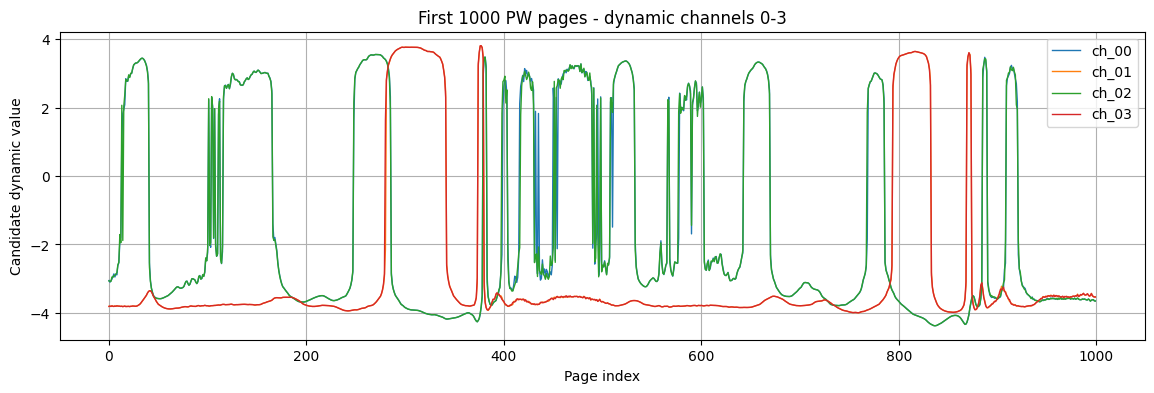

In [81]:
plt.figure(figsize=(14, 4))
plt.plot(dynamic_matrix[:1000, 0], linewidth=1, label="ch_00")
plt.plot(dynamic_matrix[:1000, 1], linewidth=1, label="ch_01")
plt.plot(dynamic_matrix[:1000, 2], linewidth=1, label="ch_02")
plt.plot(dynamic_matrix[:1000, 3], linewidth=1, label="ch_03")
plt.xlabel("Page index")
plt.ylabel("Candidate dynamic value")
plt.title("First 1000 PW pages - dynamic channels 0-3")
plt.grid(True)
plt.legend()
plt.show()

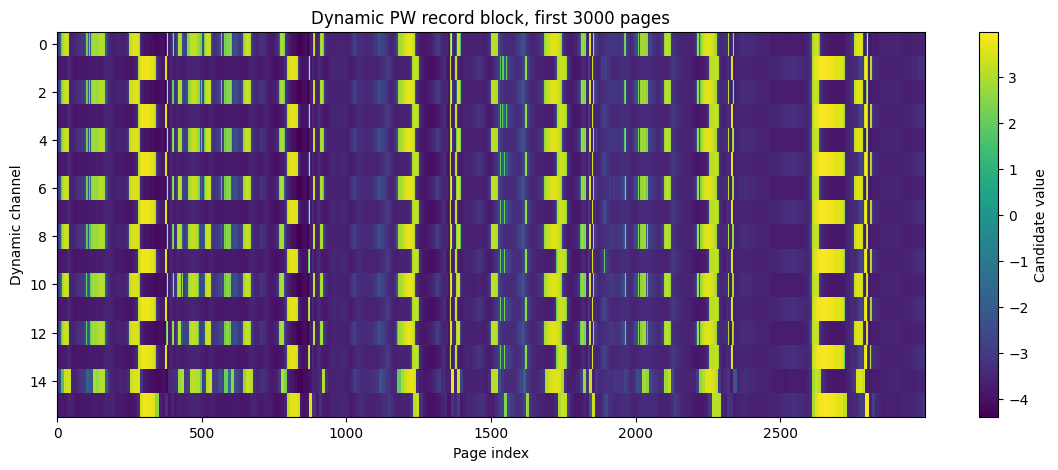

In [82]:
plt.figure(figsize=(14, 5))
plt.imshow(dynamic_matrix[:3000].T, aspect="auto", interpolation="nearest")
plt.xlabel("Page index")
plt.ylabel("Dynamic channel")
plt.title("Dynamic PW record block, first 3000 pages")
plt.colorbar(label="Candidate value")
plt.show()

## Interim finding: dynamic PW block is structured and non-random

The first 16 mixed records of each PW page form a dynamic block with shape:

```text
page_count × 16 channels

## PW page time-axis candidates

This section estimates possible time axes for the native PW page stream.

The page stream has two useful timing clues:

1. the number of PW pages,
2. the monotonic counter stored in the page header at byte offset 4.

The linked AVI is not treated as part of the native export.  
It is used only as an external reference to estimate duration.

The goal is to answer:

- how many PW pages occur per second,
- how fast the header counter changes,
- whether dynamic PW events occur at a physiologically plausible timescale,
- whether page index can be mapped approximately to time.

This remains an exploratory timing estimate.

In [83]:
def inspect_linked_avi_metadata(native_batch_dir, recording_id):
    """
    Inspect linked AVI metadata for one Mindray native recording folder.

    The linked AVI is not treated as part of the native export.
    It is used only as an external timing reference.

    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Batch directory containing recording folders.

    recording_id : str
        Mindray recording folder ID.

    Returns
    -------
    avi_metadata : dict
        Basic AVI metadata including path, fps, frame count, and duration.
    """
    native_batch_dir = Path(native_batch_dir)
    linked_avi_dir = native_batch_dir / recording_id / "linked_avi"

    if not linked_avi_dir.exists():
        raise FileNotFoundError(f"linked_avi directory does not exist: {linked_avi_dir}")

    avi_files = sorted(linked_avi_dir.glob("*.avi"))

    if len(avi_files) == 0:
        raise FileNotFoundError(f"No AVI files found in: {linked_avi_dir}")

    if len(avi_files) > 1:
        print(f"Warning: multiple AVI files found. Using first file: {avi_files[0]}")

    avi_path = avi_files[0]
    cap = cv2.VideoCapture(str(avi_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open AVI file: {avi_path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    duration_s = frame_count / fps if fps > 0 else np.nan

    avi_metadata = {
        "recording_id": recording_id,
        "avi_path": avi_path,
        "fps": fps,
        "frame_count": frame_count,
        "duration_s": duration_s,
        "width": width,
        "height": height,
    }

    return avi_metadata


def build_pw_timing_summary(recording_id, header_u32_df, dynamic_matrix, linked_avi_metadata):
    """
    Build exploratory timing summary for a PW native page stream.

    The function combines:
    - page count,
    - header counter at offset 4,
    - linked AVI duration.

    The linked AVI is used only as a timing reference.

    Parameters
    ----------
    recording_id : str
        Mindray recording ID.

    header_u32_df : pandas.DataFrame
        Header table containing the monotonic counter at offset 4.

    dynamic_matrix : numpy.ndarray
        Dynamic PW matrix with shape `(n_pages, n_channels)`.

    linked_avi_metadata : dict
        Metadata returned by inspect_linked_avi_metadata().

    Returns
    -------
    timing_summary : dict
        Timing estimates for the PW native stream.
    """
    n_pages = int(dynamic_matrix.shape[0])
    duration_s = float(linked_avi_metadata["duration_s"])
    counter = pd.to_numeric(header_u32_df["header_u32_01_offset_004"], errors="coerce").to_numpy()

    counter_first = float(counter[0])
    counter_last = float(counter[-1])
    counter_span = counter_last - counter_first

    page_rate_hz = n_pages / duration_s if duration_s > 0 else np.nan
    seconds_per_page = duration_s / n_pages if n_pages > 0 else np.nan

    counter_units_per_second = counter_span / duration_s if duration_s > 0 else np.nan
    seconds_per_counter_unit = duration_s / counter_span if counter_span > 0 else np.nan

    timing_summary = {
        "recording_id": recording_id,
        "n_pages": n_pages,
        "linked_avi_duration_s": duration_s,
        "linked_avi_fps": linked_avi_metadata["fps"],
        "linked_avi_frame_count": linked_avi_metadata["frame_count"],
        "page_rate_hz_from_avi": page_rate_hz,
        "seconds_per_page_from_avi": seconds_per_page,
        "counter_first": counter_first,
        "counter_last": counter_last,
        "counter_span": counter_span,
        "counter_units_per_second_from_avi": counter_units_per_second,
        "seconds_per_counter_unit_from_avi": seconds_per_counter_unit,
    }

    return timing_summary


def add_time_axis_to_dynamic_matrix(dynamic_matrix, timing_summary):
    """
    Create a time axis for the dynamic PW matrix using linked AVI duration.

    The time axis is exploratory and assumes that the PW page stream spans the
    same duration as the linked AVI reference.

    Parameters
    ----------
    dynamic_matrix : numpy.ndarray
        Dynamic PW matrix with shape `(n_pages, n_channels)`.

    timing_summary : dict
        Timing summary returned by build_pw_timing_summary().

    Returns
    -------
    time_s : numpy.ndarray
        Estimated time axis in seconds, one value per PW page.
    """
    n_pages = dynamic_matrix.shape[0]
    duration_s = timing_summary["linked_avi_duration_s"]

    time_s = np.linspace(
        0,
        duration_s,
        n_pages,
        endpoint=False,
    )

    return time_s

In [84]:
linked_avi_metadata = inspect_linked_avi_metadata(native_batch_dir=NATIVE_BATCH_DIR, recording_id=selected_recording_id,)
linked_avi_metadata

{'recording_id': '202606130411060002SMP',
 'avi_path': WindowsPath('D:/code/DopplerLab/ultrasound_recordings/batch_2026_06_13_native/202606130411060002SMP/linked_avi/202606130411060002SMP.avi'),
 'fps': 30.0,
 'frame_count': 1778,
 'duration_s': 59.266666666666666,
 'width': 720,
 'height': 540}

In [85]:
timing_summary = build_pw_timing_summary(recording_id=selected_recording_id, header_u32_df=header16_u32_df, dynamic_matrix=dynamic_matrix, 
                                         linked_avi_metadata=linked_avi_metadata)
timing_summary

{'recording_id': '202606130411060002SMP',
 'n_pages': 29615,
 'linked_avi_duration_s': 59.266666666666666,
 'linked_avi_fps': 30.0,
 'linked_avi_frame_count': 1778,
 'page_rate_hz_from_avi': 499.69066366704163,
 'seconds_per_page_from_avi': 0.002001238111317463,
 'counter_first': 294854.0,
 'counter_last': 413310.0,
 'counter_span': 118456.0,
 'counter_units_per_second_from_avi': 1998.695163104612,
 'seconds_per_counter_unit_from_avi': 0.000500326422187704}

In [86]:
time_s = add_time_axis_to_dynamic_matrix(dynamic_matrix=dynamic_matrix, timing_summary=timing_summary,)

time_s[:5], time_s[-1]

(array([0.        , 0.00200124, 0.00400248, 0.00600371, 0.00800495]),
 np.float64(59.26466542855535))

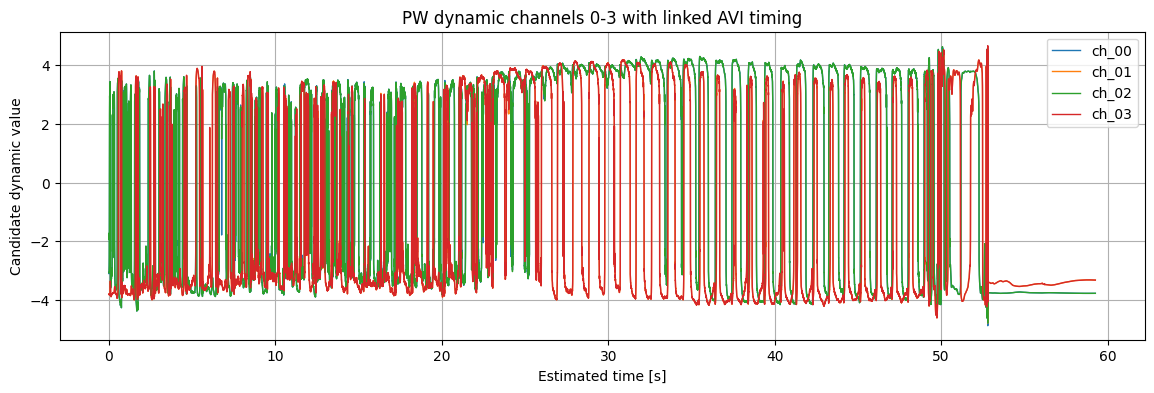

In [87]:
plt.figure(figsize=(14, 4))
plt.plot(time_s, dynamic_matrix[:, 0], linewidth=1, label="ch_00")
plt.plot(time_s, dynamic_matrix[:, 1], linewidth=1, label="ch_01")
plt.plot(time_s, dynamic_matrix[:, 2], linewidth=1, label="ch_02")
plt.plot(time_s, dynamic_matrix[:, 3], linewidth=1, label="ch_03")
plt.xlabel("Estimated time [s]")
plt.ylabel("Candidate dynamic value")
plt.title("PW dynamic channels 0-3 with linked AVI timing")
plt.grid(True)
plt.legend()
plt.show()

In [88]:
dynamic_corr_df = pd.DataFrame(dynamic_matrix).corr()
dynamic_corr_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1.000000,0.321312,0.996144,0.320114,0.993043,0.319971,0.990546,0.319681,0.988931,0.319392,0.987730,0.319669,0.986072,0.319752,0.953951,0.313527
1,0.321312,1.000000,0.321403,0.995759,0.321630,0.992005,0.320395,0.990265,0.321017,0.988369,0.321521,0.985644,0.321880,0.983958,0.329095,0.947342
2,0.996144,0.321403,1.000000,0.320239,0.996469,0.318979,0.992737,0.318780,0.991383,0.318891,0.989362,0.318742,0.987878,0.318650,0.951641,0.312344
3,0.320114,0.995759,0.320239,1.000000,0.321731,0.995784,0.320746,0.992097,0.320470,0.990177,0.321249,0.987754,0.321856,0.985832,0.329425,0.945280
4,0.993043,0.321630,0.996469,0.321731,1.000000,0.320646,0.996255,0.318871,0.992879,0.319026,0.990805,0.319379,0.989569,0.319171,0.951275,0.311669
5,0.319971,0.992005,0.318979,0.995784,0.320646,1.000000,0.320751,0.995667,0.320361,0.992008,0.321004,0.989849,0.321819,0.987758,0.329809,0.943953
6,0.990546,0.320395,0.992737,0.320746,0.996255,0.320751,1.000000,0.318898,0.996309,0.318021,0.993244,0.318134,0.991306,0.318039,0.949964,0.310992
7,0.319681,0.990265,0.318780,0.992097,0.318871,0.995667,0.318898,1.000000,0.320182,0.995649,0.320773,0.991617,0.320903,0.989738,0.329251,0.942616
8,0.988931,0.321017,0.991383,0.320470,0.992879,0.320361,0.996309,0.320182,1.000000,0.318946,0.996394,0.317799,0.992802,0.317800,0.948585,0.311102
9,0.319392,0.988369,0.318891,0.990177,0.319026,0.992008,0.318021,0.995649,0.318946,1.000000,0.320581,0.996067,0.320872,0.992308,0.329483,0.941662


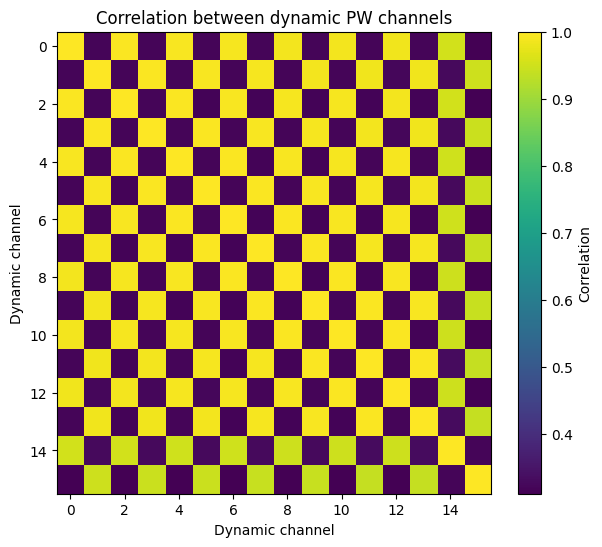

In [89]:
plt.figure(figsize=(7, 6))
plt.imshow(dynamic_corr_df, aspect="auto", interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xlabel("Dynamic channel")
plt.ylabel("Dynamic channel")
plt.title("Correlation between dynamic PW channels")
plt.show()

## Interim finding: dynamic PW channels form two strongly correlated families

The linked AVI timing suggests that the native PW page stream runs at approximately 500 pages per second.

For the inspected recording:

```text
linked AVI duration ≈ 59.27 s
PW pages = 29615
page rate ≈ 499.7 pages/s
seconds per page ≈ 2.0 ms
counter rate ≈ 1998.7 units/s
seconds per counter unit ≈ 0.5 ms

## Even/odd dynamic PW family reduction

The dynamic PW block contains 16 channels.

Correlation analysis shows that the channels form two strongly correlated families:

- even-indexed channels,
- odd-indexed channels.

This section reduces the 16-channel dynamic block into two representative signals:

```text
even_family_mean
odd_family_mean

In [90]:
def reduce_dynamic_pw_even_odd_families(dynamic_matrix):
    """
    Reduce dynamic PW channels into even and odd channel families.

    The function computes mean signals across even-indexed and odd-indexed
    dynamic channels.

    This reduction is motivated by correlation analysis showing that even
    channels are strongly correlated with each other, and odd channels are
    strongly correlated with each other.

    Parameters
    ----------
    dynamic_matrix : numpy.ndarray
        Dynamic PW matrix with shape `(n_pages, n_dynamic_channels)`.

    Returns
    -------
    family_df : pandas.DataFrame
        One row per page with reduced even/odd family signals.

    family_summary_df : pandas.DataFrame
        Summary statistics for the reduced family signals.
    """
    if dynamic_matrix.ndim != 2:
        raise ValueError("Expected dynamic_matrix with shape (n_pages, n_channels).")

    even_indices = np.arange(0, dynamic_matrix.shape[1], 2)
    odd_indices = np.arange(1, dynamic_matrix.shape[1], 2)

    even_values = dynamic_matrix[:, even_indices]
    odd_values = dynamic_matrix[:, odd_indices]

    family_df = pd.DataFrame(
        {
            "page_index": np.arange(dynamic_matrix.shape[0]),
            "even_family_mean": np.nanmean(even_values, axis=1),
            "odd_family_mean": np.nanmean(odd_values, axis=1),
            "even_family_std": np.nanstd(even_values, axis=1),
            "odd_family_std": np.nanstd(odd_values, axis=1),
        }
    )

    family_df["family_difference_even_minus_odd"] = (family_df["even_family_mean"] - family_df["odd_family_mean"])

    rows = []

    for column in [
        "even_family_mean",
        "odd_family_mean",
        "even_family_std",
        "odd_family_std",
        "family_difference_even_minus_odd",
    ]:
        values = family_df[column].to_numpy()
        finite_values = values[np.isfinite(values)]

        diffs = np.diff(values)
        finite_diffs = diffs[np.isfinite(diffs)]

        rows.append(
            {
                "signal_name": column,
                "n_finite": int(finite_values.size),
                "min_value": float(np.min(finite_values)) if finite_values.size else np.nan,
                "max_value": float(np.max(finite_values)) if finite_values.size else np.nan,
                "mean_value": float(np.mean(finite_values)) if finite_values.size else np.nan,
                "std_value": float(np.std(finite_values)) if finite_values.size else np.nan,
                "median_value": float(np.median(finite_values)) if finite_values.size else np.nan,
                "median_abs_diff": float(np.median(np.abs(finite_diffs))) if finite_diffs.size else np.nan,
                "max_abs_diff": float(np.max(np.abs(finite_diffs))) if finite_diffs.size else np.nan,
            }
        )

    family_summary_df = pd.DataFrame(rows)

    return family_df, family_summary_df

In [91]:
family_df, family_summary_df = reduce_dynamic_pw_even_odd_families(dynamic_matrix)

family_summary_df

,signal_name,n_finite,min_value,max_value,mean_value,std_value,median_value,median_abs_diff,max_abs_diff
0,even_family_mean,29615,-4.463031,4.600420,0.042287,3.537958,-0.566963,0.009039,6.907682
1,odd_family_mean,29615,-4.602963,4.495520,-1.450876,3.197867,-3.367979,0.009254,5.974490
2,even_family_std,29615,0.000018,4.414287,0.125517,0.433790,0.010106,0.002922,3.247823
3,odd_family_std,29615,0.000049,4.541480,0.115549,0.420986,0.010816,0.002971,3.605902
4,family_difference_even_minus_odd,29615,-8.174253,8.451107,1.493164,3.920744,0.247017,0.018516,8.410915


In [92]:
family_df.head()

,page_index,even_family_mean,odd_family_mean,even_family_std,odd_family_std,family_difference_even_minus_odd
0,0,-3.106001,-3.811217,0.030071,0.003515,0.705216
1,1,-3.063652,-3.807837,0.028412,0.003689,0.744185
2,2,-3.088711,-3.806988,0.018731,0.005985,0.718277
3,3,-2.933926,-3.803171,0.082464,0.005245,0.869245
4,4,-2.927459,-3.808407,0.043563,0.001668,0.880949


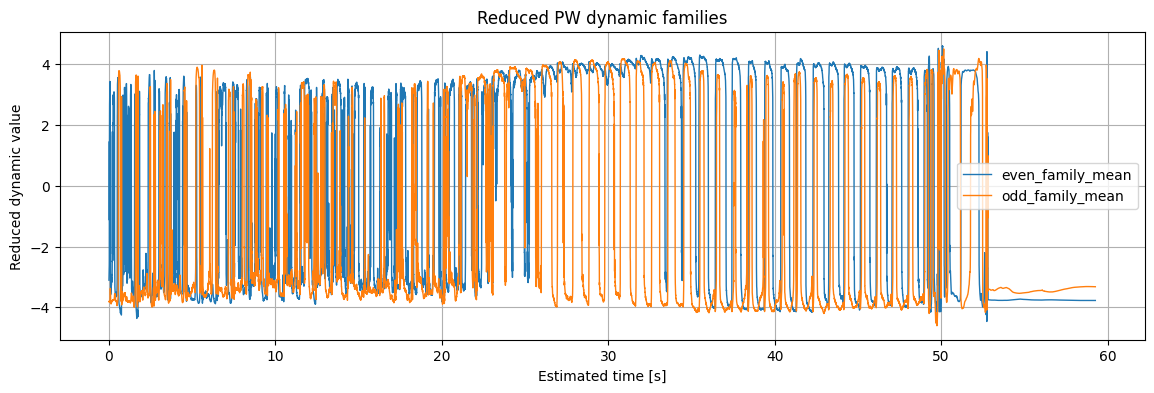

In [93]:
plt.figure(figsize=(14, 4))
plt.plot(time_s, family_df["even_family_mean"], linewidth=1, label="even_family_mean")
plt.plot(time_s, family_df["odd_family_mean"], linewidth=1, label="odd_family_mean")
plt.xlabel("Estimated time [s]")
plt.ylabel("Reduced dynamic value")
plt.title("Reduced PW dynamic families")
plt.grid(True)
plt.legend()
plt.show()

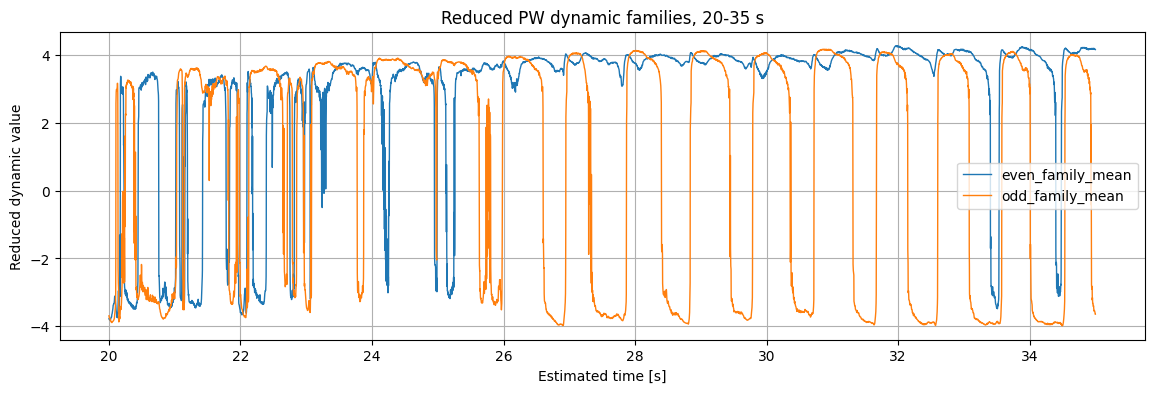

In [94]:
window_start_s = 20
window_end_s = 35

mask = (time_s >= window_start_s) & (time_s <= window_end_s)

plt.figure(figsize=(14, 4))
plt.plot(time_s[mask], family_df.loc[mask, "even_family_mean"], linewidth=1, label="even_family_mean")
plt.plot(time_s[mask], family_df.loc[mask, "odd_family_mean"], linewidth=1, label="odd_family_mean")
plt.xlabel("Estimated time [s]")
plt.ylabel("Reduced dynamic value")
plt.title(f"Reduced PW dynamic families, {window_start_s}-{window_end_s} s")
plt.grid(True)
plt.legend()
plt.show()

In [95]:
def estimate_dominant_frequency(signal_values, sample_rate_hz, fmin=0.5, fmax=5.0):
    """
    Estimate dominant frequency of a signal within a selected frequency band.

    The function removes the mean, applies a Hann window, computes an FFT,
    and returns the strongest frequency in the selected band.

    This is an exploratory signal diagnostic, not a clinical measurement.

    Parameters
    ----------
    signal_values : array-like
        Input signal.

    sample_rate_hz : float
        Sampling rate in Hz.

    fmin : float
        Minimum frequency for the search band.

    fmax : float
        Maximum frequency for the search band.

    Returns
    -------
    result : dict
        Dominant frequency estimate and related values.
    """
    values = np.asarray(signal_values, dtype=float)
    finite_mask = np.isfinite(values)

    if finite_mask.sum() < 10:
        return {
            "dominant_frequency_hz": np.nan,
            "dominant_frequency_bpm": np.nan,
            "dominant_power": np.nan,
            "n_samples": int(finite_mask.sum()),
        }

    values = values.copy()
    values[~finite_mask] = np.nanmedian(values[finite_mask])
    values = values - np.mean(values)

    window = np.hanning(len(values))
    windowed = values * window

    freqs = np.fft.rfftfreq(len(windowed), d=1.0 / sample_rate_hz)
    spectrum = np.abs(np.fft.rfft(windowed)) ** 2
    band_mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(band_mask):
        return {
            "dominant_frequency_hz": np.nan,
            "dominant_frequency_bpm": np.nan,
            "dominant_power": np.nan,
            "n_samples": len(values),
        }

    band_freqs = freqs[band_mask]
    band_power = spectrum[band_mask]
    peak_index = int(np.argmax(band_power))
    dominant_frequency_hz = float(band_freqs[peak_index])

    return {
        "dominant_frequency_hz": dominant_frequency_hz,
        "dominant_frequency_bpm": dominant_frequency_hz * 60,
        "dominant_power": float(band_power[peak_index]),
        "n_samples": len(values),
    }

In [96]:
page_sample_rate_hz = timing_summary["page_rate_hz_from_avi"]

even_freq_result = estimate_dominant_frequency(
    family_df["even_family_mean"],
    sample_rate_hz=page_sample_rate_hz,
    fmin=0.5,
    fmax=5.0,
)

odd_freq_result = estimate_dominant_frequency(
    family_df["odd_family_mean"],
    sample_rate_hz=page_sample_rate_hz,
    fmin=0.5,
    fmax=5.0,
)

even_freq_result, odd_freq_result

({'dominant_frequency_hz': 1.046119235095613,
  'dominant_frequency_bpm': 62.76715410573678,
  'dominant_power': 191691619.7724195,
  'n_samples': 29615},
 {'dominant_frequency_hz': 1.046119235095613,
  'dominant_frequency_bpm': 62.76715410573678,
  'dominant_power': 343170076.2336545,
  'n_samples': 29615})

## Interim finding: reduced dynamic PW families contain a heart-rate-like component

The 16 dynamic PW channels were reduced into two correlated signal families:

- `even_family_mean`
- `odd_family_mean`

Both reduced signals have the same dominant frequency in the 0.5-5.0 Hz band:

```text
dominant frequency ≈ 1.046 Hz
dominant frequency ≈ 62.8 bpm

In [97]:
def detect_native_dynamic_events(time_s, signal_values, invert_signal=False, min_distance_s=0.45, prominence=1.0):
    """
    Detect events in a reduced native PW dynamic signal.

    The function uses scipy.signal.find_peaks on either the original signal
    or the inverted signal.

    This is an exploratory event detector. It is not yet a clinical beat
    detector.

    Parameters
    ----------
    time_s : numpy.ndarray
        Estimated time axis in seconds.

    signal_values : array-like
        Reduced native PW dynamic signal.

    invert_signal : bool
        If True, peaks are detected on the inverted signal.

    min_distance_s : float
        Minimum distance between detected events in seconds.

    prominence : float
        Minimum peak prominence.

    Returns
    -------
    events_df : pandas.DataFrame
        Detected event table.

    detection_signal : numpy.ndarray
        Signal used for peak detection.
    """
    values = np.asarray(signal_values, dtype=float)

    if len(time_s) != len(values):
        raise ValueError("time_s and signal_values must have the same length.")

    sample_rate_hz = 1.0 / np.median(np.diff(time_s))
    min_distance_samples = int(round(min_distance_s * sample_rate_hz))

    if invert_signal:
        detection_signal = -values
    else:
        detection_signal = values.copy()

    finite_mask = np.isfinite(detection_signal)

    if not np.all(finite_mask):
        fill_value = np.nanmedian(detection_signal[finite_mask])
        detection_signal = detection_signal.copy()
        detection_signal[~finite_mask] = fill_value

    peak_indices, properties = find_peaks(detection_signal, distance=min_distance_samples, prominence=prominence,)

    events_df = pd.DataFrame(
        {
            "event_index": np.arange(len(peak_indices)),
            "sample_index": peak_indices,
            "time_s": time_s[peak_indices],
            "signal_value": values[peak_indices],
            "detection_value": detection_signal[peak_indices],
            "prominence": properties.get("prominences", np.full(len(peak_indices), np.nan)),
        }
    )

    if len(events_df) > 1:
        events_df["rr_s"] = events_df["time_s"].diff()
        events_df["instant_hr_bpm"] = 60.0 / events_df["rr_s"]
    else:
        events_df["rr_s"] = np.nan
        events_df["instant_hr_bpm"] = np.nan

    return events_df, detection_signal

In [98]:
odd_events_df, odd_detection_signal = detect_native_dynamic_events(
    time_s=time_s,
    signal_values=family_df["odd_family_mean"],
    invert_signal=True,
    min_distance_s=0.45,
    prominence=1.0,
)

odd_events_df.head(20)

,event_index,sample_index,time_s,signal_value,detection_value,prominence,rr_s,instant_hr_bpm
0,0,758,1.516938,-3.999279,3.999279,7.768158,NaN,NaN
1,1,1294,2.589602,-3.992262,3.992262,7.631971,1.072664,55.935522
2,2,1793,3.588220,-3.856112,3.856112,7.217255,0.998618,60.083046
3,3,2212,4.426739,-3.844787,3.844787,7.334124,0.838519,71.554749
4,4,2890,5.783578,-3.664009,3.664009,7.463656,1.356839,44.220413
5,5,3760,7.524655,-3.733527,3.733527,7.464502,1.741077,34.461425
6,6,4121,8.247102,-3.560248,3.560248,6.906586,0.722447,83.051080
7,7,4504,9.013576,-3.434686,3.434686,6.690380,0.766474,78.280522
8,8,4757,9.519890,-3.615171,3.615171,6.836175,0.506313,118.503715
9,9,5014,10.034208,-3.493305,3.493305,5.735968,0.514318,116.659299


In [99]:
odd_events_df["instant_hr_bpm"].describe()

count     59.000000
mean      76.527410
std       25.267574
min       34.461425
25%       61.374557
50%       66.773808
75%       88.573201
max      132.076827
Name: instant_hr_bpm, dtype: float64

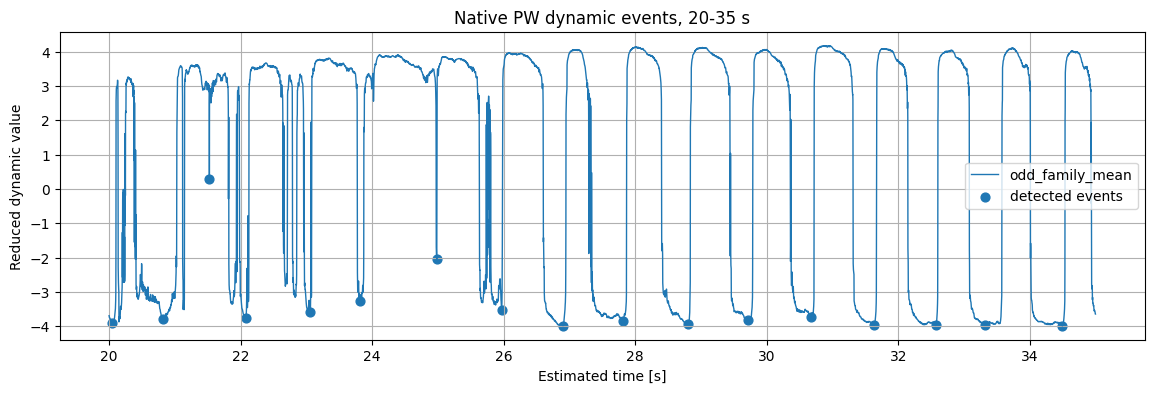

In [100]:
window_start_s = 20
window_end_s = 35

mask = (time_s >= window_start_s) & (time_s <= window_end_s)
event_mask = ((odd_events_df["time_s"] >= window_start_s) & (odd_events_df["time_s"] <= window_end_s))

plt.figure(figsize=(14, 4))
plt.plot(time_s[mask], family_df.loc[mask, "odd_family_mean"], linewidth=1, label="odd_family_mean")
plt.scatter(
    odd_events_df.loc[event_mask, "time_s"],
    odd_events_df.loc[event_mask, "signal_value"],
    s=40,
    label="detected events",
)
plt.xlabel("Estimated time [s]")
plt.ylabel("Reduced dynamic value")
plt.title(f"Native PW dynamic events, {window_start_s}-{window_end_s} s")
plt.grid(True)
plt.legend()
plt.show()

## Interim finding: native dynamic event detection is promising but not yet robust

Simple peak detection on the inverted `odd_family_mean` signal detects repeated events.

The detected events show a heart-rate-scale rhythm, but the detector is not robust across the full recording.

Observed behavior:

- stable sections produce plausible repeated events,
- unstable sections produce extra detections,
- the median instantaneous HR is plausible,
- the mean HR is inflated by false positives and irregular segments.

This means that the native dynamic signal likely contains physiological or PW-related periodic information, but a simple global peak detector is not sufficient.

The next validation step is to compare the native dynamic events against an external reference signal from the linked AVI audio.

## Linked AVI audio reference for native PW dynamic validation

This section uses the linked AVI only as an external timing and audio reference.

The linked AVI is not treated as part of the native Mindray export.

The goal is to compare:

- native PW dynamic events,
- Doppler audio-derived beat events from the linked AVI.

If native dynamic events align with audio-derived Doppler beats, this supports the interpretation that the native PW dynamic block contains physiological or PW-related signal information.

This section remains exploratory and does not replace the existing NB02 audio pipeline.

In [101]:
def extract_audio_from_avi_to_wav(avi_path, wav_path, sample_rate_hz=48000):
    """
    Extract mono audio from an AVI file into a WAV file using ffmpeg.

    The function uses the linked AVI as an external reference signal.
    It does not treat the AVI as part of the native Mindray export.

    Parameters
    ----------
    avi_path : str or pathlib.Path
        Path to the linked AVI file.

    wav_path : str or pathlib.Path
        Output WAV path.

    sample_rate_hz : int
        Target audio sample rate.

    Returns
    -------
    wav_path : pathlib.Path
        Path to the extracted WAV file.
    """
    avi_path = Path(avi_path)
    wav_path = Path(wav_path)

    wav_path.parent.mkdir(parents=True, exist_ok=True)

    command = [
        "ffmpeg",
        "-y",
        "-i",
        str(avi_path),
        "-vn",
        "-ac",
        "1",
        "-ar",
        str(sample_rate_hz),
        str(wav_path),
    ]

    result = subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

    if result.returncode != 0:
        raise RuntimeError("ffmpeg audio extraction failed:\n" + result.stderr[-2000:])

    return wav_path


def load_wav_mono_float(wav_path):
    """
    Load a WAV file as mono float signal.

    Parameters
    ----------
    wav_path : str or pathlib.Path
        Path to WAV file.

    Returns
    -------
    sample_rate_hz : int
        Audio sample rate.

    audio_signal : numpy.ndarray
        Mono audio signal normalized to float.
    """
    sample_rate_hz, audio = wavfile.read(str(wav_path))

    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    audio = audio.astype(float)

    max_abs = np.max(np.abs(audio))

    if max_abs > 0:
        audio = audio / max_abs

    return sample_rate_hz, audio


def compute_audio_envelope_reference(
    audio_signal,
    sample_rate_hz,
    bandpass_low_hz=100,
    bandpass_high_hz=3000,
    envelope_smooth_s=0.03,
):
    """
    Compute a simple Doppler audio envelope reference signal.

    The function bandpass-filters the audio, computes the Hilbert envelope,
    and smooths it with a moving average.

    Parameters
    ----------
    audio_signal : numpy.ndarray
        Mono audio signal.

    sample_rate_hz : int
        Audio sample rate.

    bandpass_low_hz : float
        Lower cutoff frequency.

    bandpass_high_hz : float
        Upper cutoff frequency.

    envelope_smooth_s : float
        Moving average smoothing window in seconds.

    Returns
    -------
    audio_time_s : numpy.ndarray
        Audio time axis.

    envelope_smooth : numpy.ndarray
        Smoothed audio envelope.
    """
    nyquist = sample_rate_hz / 2

    low = bandpass_low_hz / nyquist
    high = bandpass_high_hz / nyquist

    b, a = butter(N=3, Wn=[low, high], btype="bandpass")

    filtered = filtfilt(b, a, audio_signal)

    envelope = np.abs(hilbert(filtered))

    smooth_n = max(1, int(round(envelope_smooth_s * sample_rate_hz)))

    kernel = np.ones(smooth_n) / smooth_n
    envelope_smooth = np.convolve(envelope, kernel, mode="same")

    if np.max(envelope_smooth) > 0:
        envelope_smooth = envelope_smooth / np.max(envelope_smooth)

    audio_time_s = np.arange(len(envelope_smooth)) / sample_rate_hz

    return audio_time_s, envelope_smooth


def detect_audio_envelope_beats(
    audio_time_s,
    envelope_signal,
    min_distance_s=0.45,
    prominence=0.08,
):
    """
    Detect beat-like peaks from a Doppler audio envelope.

    This is an exploratory reference detector for native PW validation.

    Parameters
    ----------
    audio_time_s : numpy.ndarray
        Audio time axis.

    envelope_signal : numpy.ndarray
        Smoothed audio envelope.

    min_distance_s : float
        Minimum distance between detected peaks.

    prominence : float
        Minimum peak prominence.

    Returns
    -------
    audio_events_df : pandas.DataFrame
        Detected audio event table.
    """

    sample_rate_hz = 1.0 / np.median(np.diff(audio_time_s))
    min_distance_samples = int(round(min_distance_s * sample_rate_hz))

    peak_indices, properties = find_peaks(
        envelope_signal,
        distance=min_distance_samples,
        prominence=prominence,
    )

    audio_events_df = pd.DataFrame(
        {
            "event_index": np.arange(len(peak_indices)),
            "sample_index": peak_indices,
            "time_s": audio_time_s[peak_indices],
            "envelope_value": envelope_signal[peak_indices],
            "prominence": properties.get("prominences", np.full(len(peak_indices), np.nan)),
        }
    )

    if len(audio_events_df) > 1:
        audio_events_df["rr_s"] = audio_events_df["time_s"].diff()
        audio_events_df["instant_hr_bpm"] = 60.0 / audio_events_df["rr_s"]
    else:
        audio_events_df["rr_s"] = np.nan
        audio_events_df["instant_hr_bpm"] = np.nan

    return audio_events_df

In [102]:
AUDIO_REFERENCE_DIR = PROJECT_ROOT / "audio_exports" / "native_reference_audio"
AUDIO_REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

linked_avi_path = linked_avi_metadata["avi_path"]
wav_path = AUDIO_REFERENCE_DIR / f"{selected_recording_id}_linked_audio.wav"
wav_path = extract_audio_from_avi_to_wav(avi_path=linked_avi_path, wav_path=wav_path, sample_rate_hz=48000)
audio_sample_rate_hz, audio_signal = load_wav_mono_float(wav_path)

audio_time_s, audio_envelope = compute_audio_envelope_reference(
    audio_signal=audio_signal,
    sample_rate_hz=audio_sample_rate_hz,
    bandpass_low_hz=100,
    bandpass_high_hz=3000,
    envelope_smooth_s=0.03,
)
audio_events_df = detect_audio_envelope_beats(
    audio_time_s=audio_time_s,
    envelope_signal=audio_envelope,
    min_distance_s=0.45,
    prominence=0.08,
)

audio_sample_rate_hz, audio_signal.shape, audio_events_df.shape

(48000, (2843648,), (55, 7))

In [103]:
audio_events_df["instant_hr_bpm"].describe()

count     54.000000
mean      66.733618
std       17.556214
min       21.526112
25%       59.677686
50%       62.515280
75%       66.808150
max      128.605877
Name: instant_hr_bpm, dtype: float64

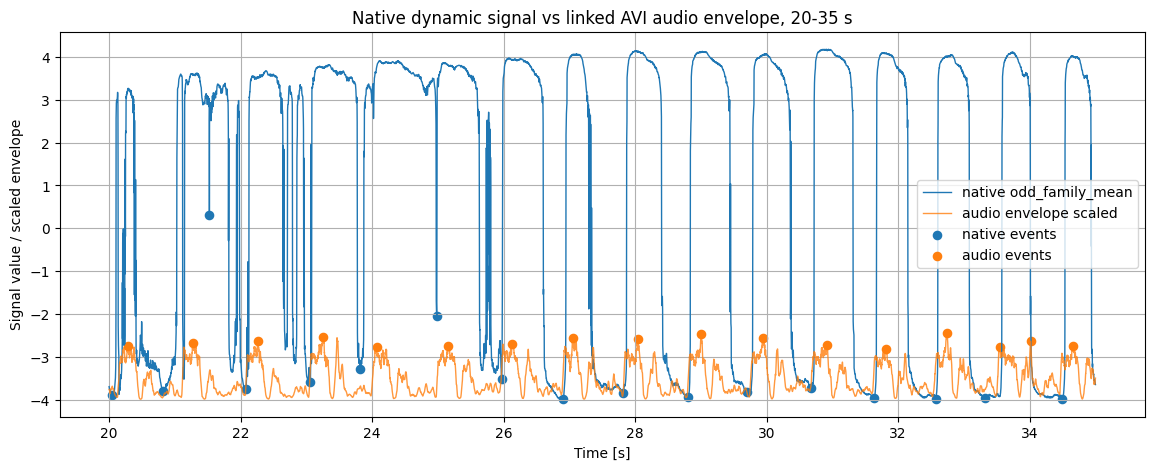

In [104]:
window_start_s = 20
window_end_s = 35

native_mask = (time_s >= window_start_s) & (time_s <= window_end_s)
audio_mask = (audio_time_s >= window_start_s) & (audio_time_s <= window_end_s)

native_event_mask = ((odd_events_df["time_s"] >= window_start_s) & (odd_events_df["time_s"] <= window_end_s))

audio_event_mask = ((audio_events_df["time_s"] >= window_start_s) & (audio_events_df["time_s"] <= window_end_s))

plt.figure(figsize=(14, 5))

plt.plot(
    time_s[native_mask],
    family_df.loc[native_mask, "odd_family_mean"],
    linewidth=1,
    label="native odd_family_mean",
)

plt.plot(
    audio_time_s[audio_mask],
    audio_envelope[audio_mask] * 8 - 4,
    linewidth=1,
    alpha=0.8,
    label="audio envelope scaled",
)

plt.scatter(
    odd_events_df.loc[native_event_mask, "time_s"],
    odd_events_df.loc[native_event_mask, "signal_value"],
    s=35,
    label="native events",
)

plt.scatter(
    audio_events_df.loc[audio_event_mask, "time_s"],
    audio_events_df.loc[audio_event_mask, "envelope_value"] * 8 - 4,
    s=35,
    label="audio events",
)

plt.xlabel("Time [s]")
plt.ylabel("Signal value / scaled envelope")
plt.title(f"Native dynamic signal vs linked AVI audio envelope, {window_start_s}-{window_end_s} s")
plt.grid(True)
plt.legend()
plt.show()

## Interim finding: native PW dynamic stream matches Doppler audio heart-rate scale

The native PW dynamic stream was compared against the linked AVI Doppler audio envelope.

The linked AVI is used only as an external reference.

The audio envelope detector produced a median instantaneous HR of approximately 62.5 bpm.

The native dynamic reduced signals previously showed a dominant frequency of approximately 62.8 bpm.

This close agreement supports the interpretation that the native PW dynamic block is related to the same physiological/PW process represented in the Doppler audio.

However, the native dynamic stream does not look like raw audio.  
It is sampled at approximately 500 Hz and shows state-like transitions rather than a conventional high-frequency audio waveform.

The safest interpretation is:

```text
PW_CinePartition0.bin contains a structured native PW dynamic stream with a heart-rate-scale component matching the linked AVI Doppler audio reference.

In [105]:
def compare_event_timing_to_reference(
    candidate_events_df,
    reference_events_df,
    candidate_time_column="time_s",
    reference_time_column="time_s",
    max_abs_delta_s=0.4,
):
    """
    Compare candidate event timing against reference event timing.

    For each candidate event, the function finds the nearest reference event
    and computes the time difference:

        delta_s = candidate_time_s - nearest_reference_time_s

    A positive delta means the candidate event occurs after the reference event.
    A negative delta means the candidate event occurs before the reference event.

    Parameters
    ----------
    candidate_events_df : pandas.DataFrame
        Event table for the candidate/native signal.

    reference_events_df : pandas.DataFrame
        Event table for the reference signal.

    candidate_time_column : str
        Time column in the candidate event table.

    reference_time_column : str
        Time column in the reference event table.

    max_abs_delta_s : float
        Maximum absolute time difference for a match to be considered valid.

    Returns
    -------
    comparison_df : pandas.DataFrame
        One row per candidate event with nearest reference timing.

    comparison_summary : dict
        Summary statistics of valid timing differences.
    """
    candidate_times = candidate_events_df[candidate_time_column].to_numpy(dtype=float)
    reference_times = reference_events_df[reference_time_column].to_numpy(dtype=float)

    rows = []

    for candidate_index, candidate_time in enumerate(candidate_times):
        if len(reference_times) == 0:
            nearest_reference_index = np.nan
            nearest_reference_time = np.nan
            delta_s = np.nan
            abs_delta_s = np.nan
            valid_match = False
        else:
            deltas = candidate_time - reference_times
            nearest_reference_index = int(np.argmin(np.abs(deltas)))
            nearest_reference_time = float(reference_times[nearest_reference_index])
            delta_s = float(candidate_time - nearest_reference_time)
            abs_delta_s = abs(delta_s)
            valid_match = abs_delta_s <= max_abs_delta_s

        rows.append(
            {
                "candidate_event_index": candidate_index,
                "candidate_time_s": candidate_time,
                "nearest_reference_event_index": nearest_reference_index,
                "nearest_reference_time_s": nearest_reference_time,
                "delta_s": delta_s,
                "abs_delta_s": abs_delta_s,
                "valid_match": valid_match,
            }
        )

    comparison_df = pd.DataFrame(rows)

    valid_df = comparison_df[comparison_df["valid_match"]].copy()

    if len(valid_df) > 0:
        comparison_summary = {
            "n_candidate_events": int(len(comparison_df)),
            "n_reference_events": int(len(reference_events_df)),
            "n_valid_matches": int(len(valid_df)),
            "valid_match_fraction": float(len(valid_df) / len(comparison_df)),
            "median_delta_s": float(valid_df["delta_s"].median()),
            "mean_delta_s": float(valid_df["delta_s"].mean()),
            "std_delta_s": float(valid_df["delta_s"].std()),
            "median_abs_delta_s": float(valid_df["abs_delta_s"].median()),
            "max_abs_delta_s_valid": float(valid_df["abs_delta_s"].max()),
        }
    else:
        comparison_summary = {
            "n_candidate_events": int(len(comparison_df)),
            "n_reference_events": int(len(reference_events_df)),
            "n_valid_matches": 0,
            "valid_match_fraction": 0.0,
            "median_delta_s": np.nan,
            "mean_delta_s": np.nan,
            "std_delta_s": np.nan,
            "median_abs_delta_s": np.nan,
            "max_abs_delta_s_valid": np.nan,
        }

    return comparison_df, comparison_summary

In [106]:
native_audio_comparison_df, native_audio_comparison_summary = compare_event_timing_to_reference(
    candidate_events_df=odd_events_df,
    reference_events_df=audio_events_df,
    max_abs_delta_s=0.4,
)

native_audio_comparison_summary

{'n_candidate_events': 60,
 'n_reference_events': 55,
 'n_valid_matches': 51,
 'valid_match_fraction': 0.85,
 'median_delta_s': -0.17940241783443156,
 'mean_delta_s': -0.1467835411473404,
 'std_delta_s': 0.19571362669100578,
 'median_abs_delta_s': 0.20184469441161568,
 'max_abs_delta_s_valid': 0.3977217661376571}

In [107]:
stable_start_s = 26.5
stable_end_s = 35.0

stable_native_events_df = odd_events_df[(odd_events_df["time_s"] >= stable_start_s) & (odd_events_df["time_s"] <= stable_end_s)].copy()
stable_audio_events_df = audio_events_df[(audio_events_df["time_s"] >= stable_start_s) & (audio_events_df["time_s"] <= stable_end_s)].copy()
stable_comparison_df, stable_comparison_summary = compare_event_timing_to_reference(candidate_events_df=stable_native_events_df, reference_events_df=stable_audio_events_df, max_abs_delta_s=0.4)

stable_comparison_summary

{'n_candidate_events': 9,
 'n_reference_events': 10,
 'n_valid_matches': 9,
 'valid_match_fraction': 1.0,
 'median_delta_s': -0.19611364947380494,
 'mean_delta_s': -0.20029194414742532,
 'std_delta_s': 0.034416008449835174,
 'median_abs_delta_s': 0.19611364947380494,
 'max_abs_delta_s_valid': 0.24346468217120076}

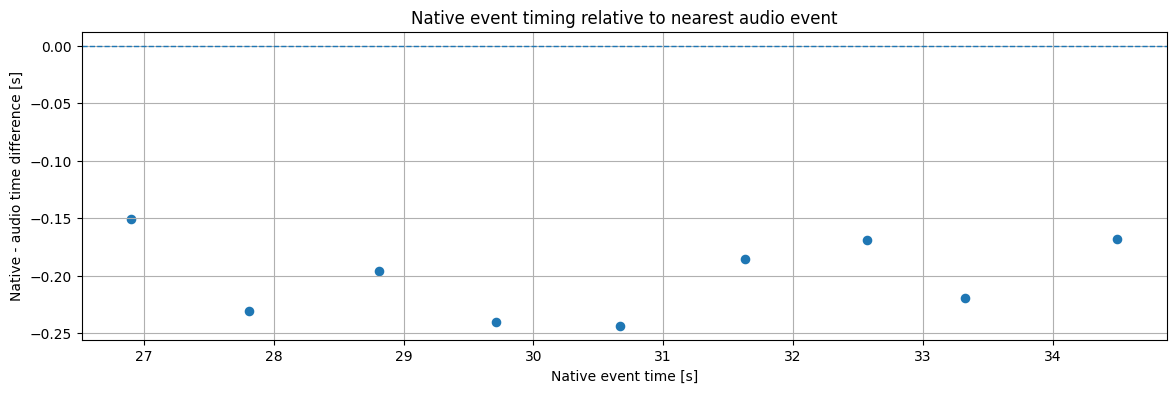

In [108]:
plt.figure(figsize=(14, 4))
plt.scatter(stable_comparison_df["candidate_time_s"], stable_comparison_df["delta_s"], s=35,)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Native event time [s]")
plt.ylabel("Native - audio time difference [s]")
plt.title("Native event timing relative to nearest audio event")
plt.grid(True)
plt.show()

## Interim finding: native PW events are time-locked to Doppler audio events

Native PW dynamic events were compared with Doppler audio envelope events from the linked AVI.

In the full recording, most native events matched nearby audio events.

In the stable segment from 26.5 s to 35.0 s:

```text
native candidate events: 9
audio reference events: 10
valid native matches: 9
valid match fraction: 1.0
median delta: approximately -0.196 s
mean delta: approximately -0.200 s
standard deviation: approximately 0.034 s

In [109]:
native_audio_lag_s = -stable_comparison_summary["median_delta_s"]

native_audio_lag_s

0.19611364947380494

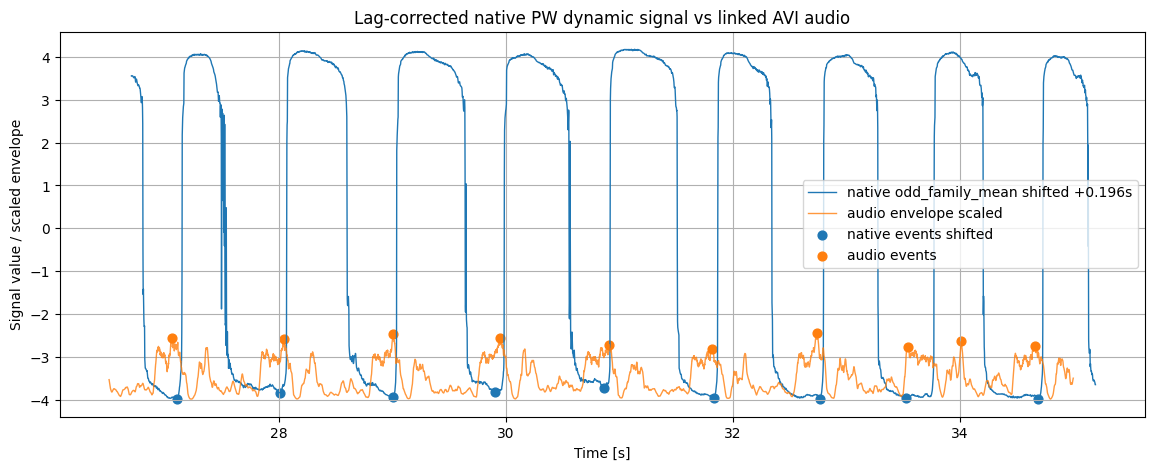

In [110]:
window_start_s = 26.5
window_end_s = 35.0

native_mask = (time_s >= window_start_s) & (time_s <= window_end_s)
audio_mask = (audio_time_s >= window_start_s) & (audio_time_s <= window_end_s)

stable_native_events_df = odd_events_df[
    (odd_events_df["time_s"] >= window_start_s)
    & (odd_events_df["time_s"] <= window_end_s)
].copy()

stable_audio_events_df = audio_events_df[
    (audio_events_df["time_s"] >= window_start_s)
    & (audio_events_df["time_s"] <= window_end_s)
].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    time_s[native_mask] + native_audio_lag_s,
    family_df.loc[native_mask, "odd_family_mean"],
    linewidth=1,
    label=f"native odd_family_mean shifted +{native_audio_lag_s:.3f}s",
)

plt.plot(
    audio_time_s[audio_mask],
    audio_envelope[audio_mask] * 8 - 4,
    linewidth=1,
    alpha=0.8,
    label="audio envelope scaled",
)

plt.scatter(
    stable_native_events_df["time_s"] + native_audio_lag_s,
    stable_native_events_df["signal_value"],
    s=40,
    label="native events shifted",
)

plt.scatter(
    stable_audio_events_df["time_s"],
    stable_audio_events_df["envelope_value"] * 8 - 4,
    s=40,
    label="audio events",
)

plt.xlabel("Time [s]")
plt.ylabel("Signal value / scaled envelope")
plt.title("Lag-corrected native PW dynamic signal vs linked AVI audio")
plt.grid(True)
plt.legend()
plt.show()

In [111]:
def compare_rr_intervals_between_event_tables(
    candidate_events_df,
    reference_events_df,
    candidate_lag_s=0.0,
    time_start_s=None,
    time_end_s=None,
):
    """
    Compare RR intervals between candidate and reference event tables.

    The function applies an optional lag correction to candidate event times,
    restricts both event tables to an optional time window, and compares
    consecutive intervals.

    This is an exploratory validation tool.

    Parameters
    ----------
    candidate_events_df : pandas.DataFrame
        Candidate/native event table with a `time_s` column.

    reference_events_df : pandas.DataFrame
        Reference/audio event table with a `time_s` column.

    candidate_lag_s : float
        Time shift added to candidate event times.

    time_start_s : float or None
        Optional start of comparison window.

    time_end_s : float or None
        Optional end of comparison window.

    Returns
    -------
    rr_comparison_df : pandas.DataFrame
        Table comparing candidate and reference RR intervals by order.

    rr_summary : dict
        Summary of RR interval differences.
    """
    candidate_times = candidate_events_df["time_s"].to_numpy(dtype=float) + candidate_lag_s
    reference_times = reference_events_df["time_s"].to_numpy(dtype=float)

    if time_start_s is not None:
        candidate_times = candidate_times[candidate_times >= time_start_s]
        reference_times = reference_times[reference_times >= time_start_s]

    if time_end_s is not None:
        candidate_times = candidate_times[candidate_times <= time_end_s]
        reference_times = reference_times[reference_times <= time_end_s]

    candidate_rr = np.diff(candidate_times)
    reference_rr = np.diff(reference_times)

    n_compare = min(len(candidate_rr), len(reference_rr))

    rr_comparison_df = pd.DataFrame(
        {
            "interval_index": np.arange(n_compare),
            "candidate_rr_s": candidate_rr[:n_compare],
            "reference_rr_s": reference_rr[:n_compare],
        }
    )

    if len(rr_comparison_df) > 0:
        rr_comparison_df["rr_delta_s"] = (
            rr_comparison_df["candidate_rr_s"] - rr_comparison_df["reference_rr_s"]
        )
        rr_comparison_df["abs_rr_delta_s"] = np.abs(rr_comparison_df["rr_delta_s"])

        rr_summary = {
            "n_candidate_intervals": int(len(candidate_rr)),
            "n_reference_intervals": int(len(reference_rr)),
            "n_compared_intervals": int(n_compare),
            "candidate_median_rr_s": float(np.median(candidate_rr)) if len(candidate_rr) else np.nan,
            "reference_median_rr_s": float(np.median(reference_rr)) if len(reference_rr) else np.nan,
            "candidate_median_hr_bpm": float(60.0 / np.median(candidate_rr)) if len(candidate_rr) else np.nan,
            "reference_median_hr_bpm": float(60.0 / np.median(reference_rr)) if len(reference_rr) else np.nan,
            "median_abs_rr_delta_s": float(rr_comparison_df["abs_rr_delta_s"].median()),
            "mean_abs_rr_delta_s": float(rr_comparison_df["abs_rr_delta_s"].mean()),
        }
    else:
        rr_summary = {
            "n_candidate_intervals": int(len(candidate_rr)),
            "n_reference_intervals": int(len(reference_rr)),
            "n_compared_intervals": 0,
            "candidate_median_rr_s": np.nan,
            "reference_median_rr_s": np.nan,
            "candidate_median_hr_bpm": np.nan,
            "reference_median_hr_bpm": np.nan,
            "median_abs_rr_delta_s": np.nan,
            "mean_abs_rr_delta_s": np.nan,
        }

    return rr_comparison_df, rr_summary

In [112]:
rr_comparison_df, rr_summary = compare_rr_intervals_between_event_tables(
    candidate_events_df=odd_events_df,
    reference_events_df=audio_events_df,
    candidate_lag_s=native_audio_lag_s,
    time_start_s=26.5,
    time_end_s=35.0,
)

rr_summary

{'n_candidate_intervals': 8,
 'n_reference_intervals': 9,
 'n_compared_intervals': 8,
 'candidate_median_rr_s': 0.9465856266531567,
 'reference_median_rr_s': 0.9177083333333371,
 'candidate_median_hr_bpm': 63.38570786474123,
 'reference_median_hr_bpm': 65.38024971623129,
 'median_abs_rr_delta_s': 0.04711242191456222,
 'mean_abs_rr_delta_s': 0.12396397078478927}

In [113]:
rr_comparison_df

,interval_index,candidate_rr_s,reference_rr_s,rr_delta_s,abs_rr_delta_s
0,0,0.910563,0.990875,-0.080312,0.080312
1,1,0.998618,0.963771,0.034847,0.034847
2,2,0.898556,0.942437,-0.043882,0.043882
3,3,0.958593,0.962063,-0.003469,0.003469
4,4,0.966598,0.908792,0.057806,0.057806
5,5,0.934578,0.917708,0.016870,0.016870
6,6,0.758469,0.808812,-0.050343,0.050343
7,7,1.170724,0.466542,0.704183,0.704183


## Interim finding: native PW dynamic RR timing is close to Doppler audio RR timing in stable segments

After applying a lag correction of approximately +0.196 s to native PW events, native dynamic events were compared against linked AVI audio envelope events.

In the stable segment from 26.5 s to 35.0 s:

```text
native median HR ≈ 63.4 bpm
audio median HR  ≈ 65.4 bpm
median absolute RR difference ≈ 47 ms

In [114]:
def summarize_rr_comparison_with_qc(rr_comparison_df, max_abs_rr_delta_s=0.2):
    """
    Summarize RR interval comparison with a simple QC threshold.

    The function separates intervals with acceptable RR agreement from
    large-mismatch intervals.

    This helps distinguish signal agreement from event detection errors.

    Parameters
    ----------
    rr_comparison_df : pandas.DataFrame
        RR comparison table produced by compare_rr_intervals_between_event_tables().

    max_abs_rr_delta_s : float
        Maximum absolute RR difference accepted as a valid interval match.

    Returns
    -------
    qc_rr_df : pandas.DataFrame
        Copy of RR comparison table with an added QC flag.

    qc_summary : dict
        Robust RR comparison summary.
    """
    qc_rr_df = rr_comparison_df.copy()
    qc_rr_df["rr_match_ok"] = (qc_rr_df["abs_rr_delta_s"] <= max_abs_rr_delta_s)

    valid_df = qc_rr_df[qc_rr_df["rr_match_ok"]].copy()
    invalid_df = qc_rr_df[~qc_rr_df["rr_match_ok"]].copy()

    if len(valid_df) > 0:
        qc_summary = {
            "n_intervals_total": int(len(qc_rr_df)),
            "n_intervals_ok": int(len(valid_df)),
            "n_intervals_rejected": int(len(invalid_df)),
            "ok_fraction": float(len(valid_df) / len(qc_rr_df)),
            "max_abs_rr_delta_s_threshold": float(max_abs_rr_delta_s),
            "candidate_median_rr_s_ok": float(valid_df["candidate_rr_s"].median()),
            "reference_median_rr_s_ok": float(valid_df["reference_rr_s"].median()),
            "candidate_median_hr_bpm_ok": float(60.0 / valid_df["candidate_rr_s"].median()),
            "reference_median_hr_bpm_ok": float(60.0 / valid_df["reference_rr_s"].median()),
            "median_abs_rr_delta_s_ok": float(valid_df["abs_rr_delta_s"].median()),
            "mean_abs_rr_delta_s_ok": float(valid_df["abs_rr_delta_s"].mean()),
            "max_abs_rr_delta_s_ok": float(valid_df["abs_rr_delta_s"].max()),
        }
    else:
        qc_summary = {
            "n_intervals_total": int(len(qc_rr_df)),
            "n_intervals_ok": 0,
            "n_intervals_rejected": int(len(invalid_df)),
            "ok_fraction": 0.0,
            "max_abs_rr_delta_s_threshold": float(max_abs_rr_delta_s),
            "candidate_median_rr_s_ok": np.nan,
            "reference_median_rr_s_ok": np.nan,
            "candidate_median_hr_bpm_ok": np.nan,
            "reference_median_hr_bpm_ok": np.nan,
            "median_abs_rr_delta_s_ok": np.nan,
            "mean_abs_rr_delta_s_ok": np.nan,
            "max_abs_rr_delta_s_ok": np.nan,
        }

    return qc_rr_df, qc_summary

In [115]:
qc_rr_df, qc_rr_summary = summarize_rr_comparison_with_qc(rr_comparison_df, max_abs_rr_delta_s=0.2)

qc_rr_summary

{'n_intervals_total': 8,
 'n_intervals_ok': 7,
 'n_intervals_rejected': 1,
 'ok_fraction': 0.875,
 'max_abs_rr_delta_s_threshold': 0.2,
 'candidate_median_rr_s_ok': 0.9345781979852497,
 'reference_median_rr_s_ok': 0.9424374999999969,
 'candidate_median_hr_bpm_ok': 64.20008526771451,
 'reference_median_hr_bpm_ok': 63.664699250613644,
 'median_abs_rr_delta_s_ok': 0.04388158801845776,
 'mean_abs_rr_delta_s_ok': 0.041075591117754176,
 'max_abs_rr_delta_s_ok': 0.08031165935055284}

In [116]:
qc_rr_df

,interval_index,candidate_rr_s,reference_rr_s,rr_delta_s,abs_rr_delta_s,rr_match_ok
0,0,0.910563,0.990875,-0.080312,0.080312,True
1,1,0.998618,0.963771,0.034847,0.034847,True
2,2,0.898556,0.942437,-0.043882,0.043882,True
3,3,0.958593,0.962063,-0.003469,0.003469,True
4,4,0.966598,0.908792,0.057806,0.057806,True
5,5,0.934578,0.917708,0.016870,0.016870,True
6,6,0.758469,0.808812,-0.050343,0.050343,True
7,7,1.170724,0.466542,0.704183,0.704183,False


## Interim finding: native PW dynamic RR timing matches Doppler audio after QC

A simple RR comparison was performed between lag-corrected native PW dynamic events and linked AVI Doppler audio events.

One large mismatch was rejected using a simple RR QC threshold:

```text
abs_rr_delta_s <= 0.2 s

## Batch validation of native PW dynamic stream against linked AVI audio

The previous sections showed that one native PW recording contains a structured dynamic stream with beat-scale timing comparable to linked AVI Doppler audio.

This section extends the validation to all available native recordings.

The goal is not to build a final decoder.

The goal is to check whether the same native PW dynamic extraction produces heart-rate-scale signals across the batch.

For each recording, the section estimates:

- native PW page rate,
- native even-family dominant frequency,
- native odd-family dominant frequency,
- linked AVI audio envelope event HR,
- difference between native and audio HR estimates.

This provides a batch-level sanity check before deeper decoding work continues.

In [117]:
def process_one_native_recording_for_hr_validation(
    native_batch_dir,
    recording_id,
    project_root,
    page_size=1296,
    header_n_bytes=16,
    n_dynamic_records=16,
    audio_sample_rate_hz=48000,
):
    """
    Process one Mindray native recording for exploratory HR validation.

    The function compares native PW dynamic frequency estimates with linked
    AVI Doppler audio envelope beat estimates.

    This is a validation wrapper, not a final decoder.

    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Batch directory containing recording folders.

    recording_id : str
        Mindray recording ID.

    project_root : str or pathlib.Path
        DopplerLab project root.

    page_size : int
        PW page size in bytes.

    header_n_bytes : int
        Candidate page header size in bytes.

    n_dynamic_records : int
        Number of leading mixed records used as dynamic channels.

    audio_sample_rate_hz : int
        Target WAV sample rate for linked AVI audio extraction.

    Returns
    -------
    result : dict
        One-row summary for the recording.

    debug_objects : dict
        Optional intermediate objects for further inspection.
    """
    native_batch_dir = Path(native_batch_dir)
    project_root = Path(project_root)

    result = {"recording_id": recording_id, "status": "started"}

    try:
        pages, pw_file_path = load_pw_partition_pages(
            native_batch_dir=native_batch_dir,
            recording_id=recording_id,
            page_size=page_size,
        )
        header_mixed_df, record_u32, record_f32, mixed_record_summary_df = (
            extract_pw_payload_as_u32_f32_records(
                pages,
                header_n_bytes=header_n_bytes,
            )
        )
        dynamic_matrix, dynamic_long_df = build_pw_dynamic_record_block(
            record_f32=record_f32,
            n_dynamic_records=n_dynamic_records,
        )
        family_df, family_summary_df = reduce_dynamic_pw_even_odd_families(
            dynamic_matrix
        )
        linked_avi_metadata = inspect_linked_avi_metadata(
            native_batch_dir=native_batch_dir,
            recording_id=recording_id,
        )
        timing_summary = build_pw_timing_summary(
            recording_id=recording_id,
            header_u32_df=header_mixed_df,
            dynamic_matrix=dynamic_matrix,
            linked_avi_metadata=linked_avi_metadata,
        )
        time_s = add_time_axis_to_dynamic_matrix(
            dynamic_matrix=dynamic_matrix,
            timing_summary=timing_summary,
        )
        page_sample_rate_hz = timing_summary["page_rate_hz_from_avi"]
        even_freq_result = estimate_dominant_frequency(
            family_df["even_family_mean"],
            sample_rate_hz=page_sample_rate_hz,
            fmin=0.5,
            fmax=5.0,
        )
        odd_freq_result = estimate_dominant_frequency(
            family_df["odd_family_mean"],
            sample_rate_hz=page_sample_rate_hz,
            fmin=0.5,
            fmax=5.0,
        )
        audio_reference_dir = (
            project_root
            / "audio_exports"
            / "native_reference_audio"
        )
        audio_reference_dir.mkdir(parents=True, exist_ok=True)
        wav_path = audio_reference_dir / f"{recording_id}_linked_audio.wav"
        wav_path = extract_audio_from_avi_to_wav(
            avi_path=linked_avi_metadata["avi_path"],
            wav_path=wav_path,
            sample_rate_hz=audio_sample_rate_hz,
        )

        loaded_audio_sample_rate_hz, audio_signal = load_wav_mono_float(wav_path)
        audio_time_s, audio_envelope = compute_audio_envelope_reference(
            audio_signal=audio_signal,
            sample_rate_hz=loaded_audio_sample_rate_hz,
            bandpass_low_hz=100,
            bandpass_high_hz=3000,
            envelope_smooth_s=0.03,
        )
        audio_events_df = detect_audio_envelope_beats(
            audio_time_s=audio_time_s,
            envelope_signal=audio_envelope,
            min_distance_s=0.45,
            prominence=0.08,
        )

        audio_hr_series = audio_events_df["instant_hr_bpm"].dropna()

        result.update(
            {
                "status": "ok",
                "n_pages": int(pages.shape[0]),
                "page_size": int(pages.shape[1]),
                "linked_avi_duration_s": float(linked_avi_metadata["duration_s"]),
                "linked_avi_fps": float(linked_avi_metadata["fps"]),
                "linked_avi_frame_count": int(linked_avi_metadata["frame_count"]),
                "page_rate_hz": float(timing_summary["page_rate_hz_from_avi"]),
                "seconds_per_page": float(timing_summary["seconds_per_page_from_avi"]),
                "counter_first": float(timing_summary["counter_first"]),
                "counter_last": float(timing_summary["counter_last"]),
                "counter_span": float(timing_summary["counter_span"]),
                "even_dominant_bpm": float(even_freq_result["dominant_frequency_bpm"]),
                "odd_dominant_bpm": float(odd_freq_result["dominant_frequency_bpm"]),
                "audio_n_events": int(len(audio_events_df)),
                "audio_median_hr_bpm": float(audio_hr_series.median()) if len(audio_hr_series) else np.nan,
                "audio_mean_hr_bpm": float(audio_hr_series.mean()) if len(audio_hr_series) else np.nan,
                "audio_std_hr_bpm": float(audio_hr_series.std()) if len(audio_hr_series) else np.nan,
            }
        )

        result["even_minus_audio_median_bpm"] = (result["even_dominant_bpm"] - result["audio_median_hr_bpm"])
        result["odd_minus_audio_median_bpm"] = (result["odd_dominant_bpm"] - result["audio_median_hr_bpm"])

        debug_objects = {
            "pages": pages,
            "header_mixed_df": header_mixed_df,
            "record_u32": record_u32,
            "record_f32": record_f32,
            "dynamic_matrix": dynamic_matrix,
            "family_df": family_df,
            "time_s": time_s,
            "audio_time_s": audio_time_s,
            "audio_envelope": audio_envelope,
            "audio_events_df": audio_events_df,
        }

        return result, debug_objects

    except Exception as exc:
        result.update({"status": "error", "error_message": str(exc)})

        return result, {}

In [118]:
recording_ids = sorted([path.name for path in NATIVE_BATCH_DIR.iterdir() if path.is_dir()])
batch_results = []
batch_debug = {}

for recording_id in recording_ids:
    print(f"Processing {recording_id}...")

    result, debug_objects = process_one_native_recording_for_hr_validation(
        native_batch_dir=NATIVE_BATCH_DIR,
        recording_id=recording_id,
        project_root=PROJECT_ROOT,
        page_size=1296,
        header_n_bytes=16,
        n_dynamic_records=16,
        audio_sample_rate_hz=48000,
    )

    batch_results.append(result)
    batch_debug[recording_id] = debug_objects

batch_validation_df = pd.DataFrame(batch_results)
batch_validation_df

Processing 202606130411060002SMP...
Processing 202606130413540003SMP...
Processing 202606130417060004SMP...
Processing 202606130420260005SMP...
Processing 202606130422440006SMP...
Processing 202606130426500007SMP...
Processing 202606130430380008SMP...
Processing 202606130433280009SMP...
Processing 202606130434130010SMP...
Processing 202606130437480012SMP...


,recording_id,status,n_pages,page_size,linked_avi_duration_s,linked_avi_fps,linked_avi_frame_count,page_rate_hz,seconds_per_page,counter_first,counter_last,counter_span,even_dominant_bpm,odd_dominant_bpm,audio_n_events,audio_median_hr_bpm,audio_mean_hr_bpm,audio_std_hr_bpm,even_minus_audio_median_bpm,odd_minus_audio_median_bpm
0,202606130411060002SMP,ok,29615,1296,59.266667,30.0,1778,499.690664,0.002001,294854.0,413310.0,118456.0,62.767154,62.767154,55,62.515280,66.733618,17.556214,0.251874,0.251874
1,202606130413540003SMP,ok,23491,1296,47.033333,30.0,1411,499.454288,0.002002,631080.0,725040.0,93960.0,52.303331,52.303331,75,104.539440,101.103652,21.046697,-52.236109,-52.236109
2,202606130417060004SMP,ok,21232,1296,42.500000,30.0,1275,499.576471,0.002002,1013186.0,1098110.0,84924.0,112.941176,108.705882,79,112.090653,112.139430,4.625629,0.850524,-3.384770
3,202606130420260005SMP,ok,22764,1296,45.566667,30.0,1367,499.575713,0.002002,1414814.0,1505865.0,91051.0,194.879298,251.499634,45,62.894461,62.806616,6.124730,131.984837,188.605173
4,202606130422440006SMP,ok,25626,1296,51.300000,30.0,1539,499.532164,0.002002,1690366.0,1792866.0,102500.0,168.421053,163.742690,84,109.086777,104.459388,21.468602,59.334276,54.655913
5,202606130426500007SMP,ok,18346,1296,36.733333,30.0,1102,499.437387,0.002002,2182582.0,2255962.0,73380.0,91.470054,256.442831,53,99.237499,95.682110,22.117950,-7.767444,157.205332
6,202606130430380008SMP,ok,22186,1296,44.433333,30.0,1333,499.309827,0.002003,2637853.0,2726593.0,88740.0,39.159790,31.057764,19,35.890953,49.143827,36.116703,3.268837,-4.833189
7,202606130433280009SMP,ok,15862,1296,31.766667,30.0,953,499.328437,0.002003,2979714.0,3043157.0,63443.0,86.883526,183.210913,55,107.966436,106.378263,13.497921,-21.082910,75.244477
8,202606130434130010SMP,ok,16916,1296,33.866667,30.0,1016,499.488189,0.002002,3068131.0,3135791.0,67660.0,154.133858,51.377953,60,107.635385,107.874998,8.585822,46.498473,-56.257432
9,202606130437480012SMP,ok,22513,1296,45.066667,30.0,1352,499.548817,0.002002,3499408.0,3589456.0,90048.0,74.556213,61.242604,22,62.857392,51.555011,21.623067,11.698821,-1.614789


In [119]:
batch_validation_df[
    [
        "recording_id",
        "status",
        "linked_avi_duration_s",
        "n_pages",
        "page_rate_hz",
        "even_dominant_bpm",
        "odd_dominant_bpm",
        "audio_n_events",
        "audio_median_hr_bpm",
        "even_minus_audio_median_bpm",
        "odd_minus_audio_median_bpm",
    ]
]

,recording_id,status,linked_avi_duration_s,n_pages,page_rate_hz,even_dominant_bpm,odd_dominant_bpm,audio_n_events,audio_median_hr_bpm,even_minus_audio_median_bpm,odd_minus_audio_median_bpm
0,202606130411060002SMP,ok,59.266667,29615,499.690664,62.767154,62.767154,55,62.515280,0.251874,0.251874
1,202606130413540003SMP,ok,47.033333,23491,499.454288,52.303331,52.303331,75,104.539440,-52.236109,-52.236109
2,202606130417060004SMP,ok,42.500000,21232,499.576471,112.941176,108.705882,79,112.090653,0.850524,-3.384770
3,202606130420260005SMP,ok,45.566667,22764,499.575713,194.879298,251.499634,45,62.894461,131.984837,188.605173
4,202606130422440006SMP,ok,51.300000,25626,499.532164,168.421053,163.742690,84,109.086777,59.334276,54.655913
5,202606130426500007SMP,ok,36.733333,18346,499.437387,91.470054,256.442831,53,99.237499,-7.767444,157.205332
6,202606130430380008SMP,ok,44.433333,22186,499.309827,39.159790,31.057764,19,35.890953,3.268837,-4.833189
7,202606130433280009SMP,ok,31.766667,15862,499.328437,86.883526,183.210913,55,107.966436,-21.082910,75.244477
8,202606130434130010SMP,ok,33.866667,16916,499.488189,154.133858,51.377953,60,107.635385,46.498473,-56.257432
9,202606130437480012SMP,ok,45.066667,22513,499.548817,74.556213,61.242604,22,62.857392,11.698821,-1.614789


In [120]:
batch_validation_df[batch_validation_df["status"] == "ok"][["even_minus_audio_median_bpm", "odd_minus_audio_median_bpm", "page_rate_hz"]].describe()

,even_minus_audio_median_bpm,odd_minus_audio_median_bpm,page_rate_hz
count,10.000000,10.000000,10.000000
mean,17.280118,35.763648,499.494196
std,51.097298,83.049543,0.116792
min,-52.236109,-56.257432,499.309827
25%,-5.762615,-4.471084,499.441612
50%,2.059680,-0.681457,499.510176
75%,37.798560,70.097336,499.568989
max,131.984837,188.605173,499.690664


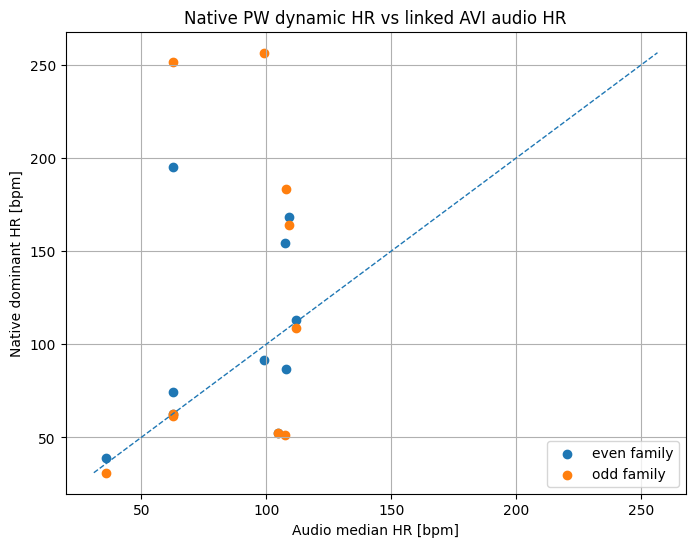

In [121]:
ok_batch_df = batch_validation_df[batch_validation_df["status"] == "ok"].copy()

plt.figure(figsize=(8, 6))
plt.scatter(ok_batch_df["audio_median_hr_bpm"], ok_batch_df["even_dominant_bpm"], label="even family")
plt.scatter(ok_batch_df["audio_median_hr_bpm"], ok_batch_df["odd_dominant_bpm"], label="odd family")
min_hr = min(ok_batch_df["audio_median_hr_bpm"].min(), ok_batch_df["even_dominant_bpm"].min(), ok_batch_df["odd_dominant_bpm"].min())
max_hr = max( ok_batch_df["audio_median_hr_bpm"].max(), ok_batch_df["even_dominant_bpm"].max(), ok_batch_df["odd_dominant_bpm"].max())
plt.plot([min_hr, max_hr], [min_hr, max_hr], linestyle="--", linewidth=1)
plt.xlabel("Audio median HR [bpm]")
plt.ylabel("Native dominant HR [bpm]")
plt.title("Native PW dynamic HR vs linked AVI audio HR")
plt.grid(True)
plt.legend()
plt.show()

## Interim finding: batch extraction works, but global dominant-frequency HR is not robust

The native PW dynamic extraction was successfully applied to all 10 native recordings.

Across the batch, the PW page stream is highly consistent:

```text
page rate ≈ 499.5 Hz

In [122]:
def classify_native_audio_hr_relationship(
    batch_validation_df,
    native_column,
    audio_column="audio_median_hr_bpm",
    tolerance_bpm=6.0,
):
    """
    Classify the relationship between native HR estimate and audio HR estimate.

    The function checks whether the native HR estimate is close to:
    - 0.5 × audio HR,
    - 1.0 × audio HR,
    - 2.0 × audio HR,
    - 3.0 × audio HR,
    - 4.0 × audio HR.

    This is useful because simple FFT-based dominant frequency estimates may
    select harmonics or subharmonics instead of the fundamental frequency.

    Parameters
    ----------
    batch_validation_df : pandas.DataFrame
        Batch validation table.

    native_column : str
        Column containing native HR estimate.

    audio_column : str
        Column containing audio HR estimate.

    tolerance_bpm : float
        Maximum absolute BPM error accepted for a relationship match.

    Returns
    -------
    relationship_df : pandas.DataFrame
        One row per recording with best harmonic/subharmonic relationship.
    """

    ratios_to_test = {
        "half_audio": 0.5,
        "fundamental": 1.0,
        "second_harmonic": 2.0,
        "third_harmonic": 3.0,
        "fourth_harmonic": 4.0,
    }

    rows = []

    for _, row in batch_validation_df.iterrows():
        recording_id = row["recording_id"]
        status = row["status"]

        native_bpm = row.get(native_column, np.nan)
        audio_bpm = row.get(audio_column, np.nan)

        if status != "ok" or not np.isfinite(native_bpm) or not np.isfinite(audio_bpm):
            rows.append(
                {
                    "recording_id": recording_id,
                    "native_column": native_column,
                    "native_bpm": native_bpm,
                    "audio_bpm": audio_bpm,
                    "best_relationship": "invalid",
                    "best_ratio": np.nan,
                    "expected_native_bpm": np.nan,
                    "abs_error_bpm": np.nan,
                    "match_ok": False,
                }
            )
            continue

        candidates = []

        for relationship_name, ratio in ratios_to_test.items():
            expected_native_bpm = audio_bpm * ratio
            abs_error_bpm = abs(native_bpm - expected_native_bpm)

            candidates.append(
                {
                    "relationship_name": relationship_name,
                    "ratio": ratio,
                    "expected_native_bpm": expected_native_bpm,
                    "abs_error_bpm": abs_error_bpm,
                }
            )

        best_candidate = min(candidates, key=lambda item: item["abs_error_bpm"])

        rows.append(
            {
                "recording_id": recording_id,
                "native_column": native_column,
                "native_bpm": native_bpm,
                "audio_bpm": audio_bpm,
                "best_relationship": best_candidate["relationship_name"],
                "best_ratio": best_candidate["ratio"],
                "expected_native_bpm": best_candidate["expected_native_bpm"],
                "abs_error_bpm": best_candidate["abs_error_bpm"],
                "match_ok": best_candidate["abs_error_bpm"] <= tolerance_bpm,
            }
        )

    relationship_df = pd.DataFrame(rows)

    return relationship_df

In [123]:
even_hr_relationship_df = classify_native_audio_hr_relationship(
    batch_validation_df=batch_validation_df,
    native_column="even_dominant_bpm",
    audio_column="audio_median_hr_bpm",
    tolerance_bpm=6.0,
)

odd_hr_relationship_df = classify_native_audio_hr_relationship(
    batch_validation_df=batch_validation_df,
    native_column="odd_dominant_bpm",
    audio_column="audio_median_hr_bpm",
    tolerance_bpm=6.0,
)

even_hr_relationship_df

,recording_id,native_column,native_bpm,audio_bpm,best_relationship,best_ratio,expected_native_bpm,abs_error_bpm,match_ok
0,202606130411060002SMP,even_dominant_bpm,62.767154,62.515280,fundamental,1.0,62.515280,0.251874,True
1,202606130413540003SMP,even_dominant_bpm,52.303331,104.539440,half_audio,0.5,52.269720,0.033611,True
2,202606130417060004SMP,even_dominant_bpm,112.941176,112.090653,fundamental,1.0,112.090653,0.850524,True
3,202606130420260005SMP,even_dominant_bpm,194.879298,62.894461,third_harmonic,3.0,188.683383,6.195914,False
4,202606130422440006SMP,even_dominant_bpm,168.421053,109.086777,second_harmonic,2.0,218.173554,49.752501,False
5,202606130426500007SMP,even_dominant_bpm,91.470054,99.237499,fundamental,1.0,99.237499,7.767444,False
6,202606130430380008SMP,even_dominant_bpm,39.159790,35.890953,fundamental,1.0,35.890953,3.268837,True
7,202606130433280009SMP,even_dominant_bpm,86.883526,107.966436,fundamental,1.0,107.966436,21.082910,False
8,202606130434130010SMP,even_dominant_bpm,154.133858,107.635385,fundamental,1.0,107.635385,46.498473,False
9,202606130437480012SMP,even_dominant_bpm,74.556213,62.857392,fundamental,1.0,62.857392,11.698821,False


In [124]:
odd_hr_relationship_df

,recording_id,native_column,native_bpm,audio_bpm,best_relationship,best_ratio,expected_native_bpm,abs_error_bpm,match_ok
0,202606130411060002SMP,odd_dominant_bpm,62.767154,62.515280,fundamental,1.0,62.515280,0.251874,True
1,202606130413540003SMP,odd_dominant_bpm,52.303331,104.539440,half_audio,0.5,52.269720,0.033611,True
2,202606130417060004SMP,odd_dominant_bpm,108.705882,112.090653,fundamental,1.0,112.090653,3.384770,True
3,202606130420260005SMP,odd_dominant_bpm,251.499634,62.894461,fourth_harmonic,4.0,251.577844,0.078210,True
4,202606130422440006SMP,odd_dominant_bpm,163.742690,109.086777,second_harmonic,2.0,218.173554,54.430864,False
5,202606130426500007SMP,odd_dominant_bpm,256.442831,99.237499,third_harmonic,3.0,297.712496,41.269665,False
6,202606130430380008SMP,odd_dominant_bpm,31.057764,35.890953,fundamental,1.0,35.890953,4.833189,True
7,202606130433280009SMP,odd_dominant_bpm,183.210913,107.966436,second_harmonic,2.0,215.932872,32.721959,False
8,202606130434130010SMP,odd_dominant_bpm,51.377953,107.635385,half_audio,0.5,53.817693,2.439740,True
9,202606130437480012SMP,odd_dominant_bpm,61.242604,62.857392,fundamental,1.0,62.857392,1.614789,True


In [125]:
pd.concat(
    [
        even_hr_relationship_df.assign(family="even"),
        odd_hr_relationship_df.assign(family="odd"),
    ],
    ignore_index=True,
).groupby(["family", "best_relationship", "match_ok"]).agg(
    n_recordings=("recording_id", "size"),
    median_abs_error_bpm=("abs_error_bpm", "median"),
    max_abs_error_bpm=("abs_error_bpm", "max"),
).reset_index()

,family,best_relationship,match_ok,n_recordings,median_abs_error_bpm,max_abs_error_bpm
0,even,fundamental,False,4,16.390865,46.498473
1,even,fundamental,True,3,0.850524,3.268837
2,even,half_audio,True,1,0.033611,0.033611
3,even,second_harmonic,False,1,49.752501,49.752501
4,even,third_harmonic,False,1,6.195914,6.195914
5,odd,fourth_harmonic,True,1,0.078210,0.078210
6,odd,fundamental,True,4,2.499780,4.833189
7,odd,half_audio,True,2,1.236675,2.439740
8,odd,second_harmonic,False,2,43.576411,54.430864
9,odd,third_harmonic,False,1,41.269665,41.269665


## Batch diagnostic classification of native PW dynamic HR estimates

The previous batch validation showed that native PW dynamic extraction is structurally consistent across recordings.

However, simple global dominant-frequency estimates are not always equal to audio HR.

Some native estimates match the audio fundamental frequency, while others appear to match subharmonics or harmonics.

This section classifies each recording diagnostically.

The goal is not to create a final HR estimator.

The goal is to separate recordings into interpretable groups:

- fundamental match,
- half-frequency match,
- harmonic match,
- mismatch,
- best native family candidate.

This helps decide which recordings should be inspected visually next.

In [126]:
def classify_hr_relationship_single_value(native_bpm, audio_bpm, tolerance_bpm=6.0):
    """
    Classify one native HR estimate relative to one audio HR estimate.

    The function tests whether the native estimate is close to:

    - 0.5 × audio HR,
    - 1.0 × audio HR,
    - 2.0 × audio HR,
    - 3.0 × audio HR,
    - 4.0 × audio HR.

    This is a diagnostic helper for harmonic-aware interpretation.

    Parameters
    ----------
    native_bpm : float
        Native dominant frequency converted to bpm.

    audio_bpm : float
        Audio reference HR in bpm.

    tolerance_bpm : float
        Maximum absolute BPM error accepted as a match.

    Returns
    -------
    result : dict
        Diagnostic relationship result.
    """
    if not np.isfinite(native_bpm) or not np.isfinite(audio_bpm):
        return {
            "relationship": "invalid",
            "ratio": np.nan,
            "expected_native_bpm": np.nan,
            "abs_error_bpm": np.nan,
            "match_ok": False,
        }

    relationships = {
        "half_audio": 0.5,
        "fundamental": 1.0,
        "second_harmonic": 2.0,
        "third_harmonic": 3.0,
        "fourth_harmonic": 4.0,
    }

    candidates = []

    for relationship_name, ratio in relationships.items():
        expected_native_bpm = audio_bpm * ratio
        abs_error_bpm = abs(native_bpm - expected_native_bpm)

        candidates.append(
            {
                "relationship": relationship_name,
                "ratio": ratio,
                "expected_native_bpm": expected_native_bpm,
                "abs_error_bpm": abs_error_bpm,
                "match_ok": abs_error_bpm <= tolerance_bpm,
            }
        )

    best_candidate = min(candidates, key=lambda item: item["abs_error_bpm"])

    return best_candidate


def build_batch_native_hr_diagnostic_table(batch_validation_df, tolerance_bpm=6.0):
    """
    Build a diagnostic classification table for native PW HR estimates.

    The function compares both native families:

    - even_family dominant HR,
    - odd_family dominant HR,

    against the linked AVI audio median HR.

    It assigns each family a harmonic-aware relationship and then selects
    the best family for each recording.

    This function is diagnostic. It does not produce a final HR estimator.

    Parameters
    ----------
    batch_validation_df : pandas.DataFrame
        Batch validation table produced by native-vs-audio processing.

    tolerance_bpm : float
        Maximum absolute BPM error accepted as a relationship match.

    Returns
    -------
    diagnostic_df : pandas.DataFrame
        One row per recording with even/odd relationship classification,
        best-family selection, and diagnostic group.
    """
    rows = []

    for _, row in batch_validation_df.iterrows():
        recording_id = row["recording_id"]
        status = row["status"]

        audio_bpm = row.get("audio_median_hr_bpm", np.nan)
        even_bpm = row.get("even_dominant_bpm", np.nan)
        odd_bpm = row.get("odd_dominant_bpm", np.nan)

        even_result = classify_hr_relationship_single_value(
            native_bpm=even_bpm,
            audio_bpm=audio_bpm,
            tolerance_bpm=tolerance_bpm,
        )

        odd_result = classify_hr_relationship_single_value(
            native_bpm=odd_bpm,
            audio_bpm=audio_bpm,
            tolerance_bpm=tolerance_bpm,
        )

        family_candidates = [
            {
                "family": "even",
                "native_bpm": even_bpm,
                **even_result,
            },
            {
                "family": "odd",
                "native_bpm": odd_bpm,
                **odd_result,
            },
        ]

        best_family_candidate = min(
            family_candidates,
            key=lambda item: (
                not item["match_ok"],
                item["abs_error_bpm"] if np.isfinite(item["abs_error_bpm"]) else np.inf,
            ),
        )

        any_match_ok = even_result["match_ok"] or odd_result["match_ok"]

        if status != "ok":
            diagnostic_group = "processing_error"
        elif not np.isfinite(audio_bpm):
            diagnostic_group = "missing_audio_reference"
        elif not any_match_ok:
            diagnostic_group = "native_audio_mismatch"
        elif best_family_candidate["relationship"] == "fundamental":
            diagnostic_group = "fundamental_match"
        elif best_family_candidate["relationship"] == "half_audio":
            diagnostic_group = "subharmonic_match"
        elif best_family_candidate["relationship"] in [
            "second_harmonic",
            "third_harmonic",
            "fourth_harmonic",
        ]:
            diagnostic_group = "harmonic_match"
        else:
            diagnostic_group = "other_match"

        rows.append(
            {
                "recording_id": recording_id,
                "status": status,
                "audio_median_hr_bpm": audio_bpm,
                "audio_n_events": row.get("audio_n_events", np.nan),
                "audio_std_hr_bpm": row.get("audio_std_hr_bpm", np.nan),
                "page_rate_hz": row.get("page_rate_hz", np.nan),

                "even_dominant_bpm": even_bpm,
                "even_relationship": even_result["relationship"],
                "even_ratio": even_result["ratio"],
                "even_abs_error_bpm": even_result["abs_error_bpm"],
                "even_match_ok": even_result["match_ok"],

                "odd_dominant_bpm": odd_bpm,
                "odd_relationship": odd_result["relationship"],
                "odd_ratio": odd_result["ratio"],
                "odd_abs_error_bpm": odd_result["abs_error_bpm"],
                "odd_match_ok": odd_result["match_ok"],

                "best_family": best_family_candidate["family"],
                "best_native_bpm": best_family_candidate["native_bpm"],
                "best_relationship": best_family_candidate["relationship"],
                "best_ratio": best_family_candidate["ratio"],
                "best_abs_error_bpm": best_family_candidate["abs_error_bpm"],
                "best_match_ok": best_family_candidate["match_ok"],

                "diagnostic_group": diagnostic_group,
            }
        )

    diagnostic_df = pd.DataFrame(rows)
    diagnostic_df = diagnostic_df.sort_values(["diagnostic_group", "recording_id"]).reset_index(drop=True)

    return diagnostic_df


def summarize_batch_native_hr_diagnostics(diagnostic_df):
    """
    Summarize batch native HR diagnostic classification.

    Parameters
    ----------
    diagnostic_df : pandas.DataFrame
        Output from build_batch_native_hr_diagnostic_table().

    Returns
    -------
    diagnostic_summary_df : pandas.DataFrame
        Summary by diagnostic group and best relationship.
    """

    if diagnostic_df is None or len(diagnostic_df) == 0:
        return pd.DataFrame()

    diagnostic_summary_df = (
        diagnostic_df
        .groupby(["diagnostic_group", "best_relationship", "best_family"], dropna=False)
        .agg(
            n_recordings=("recording_id", "size"),
            median_best_abs_error_bpm=("best_abs_error_bpm", "median"),
            max_best_abs_error_bpm=("best_abs_error_bpm", "max"),
            median_audio_hr_bpm=("audio_median_hr_bpm", "median"),
            median_native_hr_bpm=("best_native_bpm", "median"),
        )
        .reset_index()
        .sort_values(["diagnostic_group", "best_relationship", "best_family"])
    )

    return diagnostic_summary_df

In [127]:
batch_hr_diagnostic_df = build_batch_native_hr_diagnostic_table(batch_validation_df=batch_validation_df, tolerance_bpm=6.0)
batch_hr_diagnostic_summary_df = summarize_batch_native_hr_diagnostics(batch_hr_diagnostic_df)
batch_hr_diagnostic_df

,recording_id,status,audio_median_hr_bpm,audio_n_events,audio_std_hr_bpm,page_rate_hz,even_dominant_bpm,even_relationship,even_ratio,even_abs_error_bpm,...,odd_ratio,odd_abs_error_bpm,odd_match_ok,best_family,best_native_bpm,best_relationship,best_ratio,best_abs_error_bpm,best_match_ok,diagnostic_group
0,202606130411060002SMP,ok,62.515280,55,17.556214,499.690664,62.767154,fundamental,1.0,0.251874,...,1.0,0.251874,True,even,62.767154,fundamental,1.0,0.251874,True,fundamental_match
1,202606130417060004SMP,ok,112.090653,79,4.625629,499.576471,112.941176,fundamental,1.0,0.850524,...,1.0,3.384770,True,even,112.941176,fundamental,1.0,0.850524,True,fundamental_match
2,202606130430380008SMP,ok,35.890953,19,36.116703,499.309827,39.159790,fundamental,1.0,3.268837,...,1.0,4.833189,True,even,39.159790,fundamental,1.0,3.268837,True,fundamental_match
3,202606130437480012SMP,ok,62.857392,22,21.623067,499.548817,74.556213,fundamental,1.0,11.698821,...,1.0,1.614789,True,odd,61.242604,fundamental,1.0,1.614789,True,fundamental_match
4,202606130420260005SMP,ok,62.894461,45,6.124730,499.575713,194.879298,third_harmonic,3.0,6.195914,...,4.0,0.078210,True,odd,251.499634,fourth_harmonic,4.0,0.078210,True,harmonic_match
5,202606130422440006SMP,ok,109.086777,84,21.468602,499.532164,168.421053,second_harmonic,2.0,49.752501,...,2.0,54.430864,False,even,168.421053,second_harmonic,2.0,49.752501,False,native_audio_mismatch
6,202606130426500007SMP,ok,99.237499,53,22.117950,499.437387,91.470054,fundamental,1.0,7.767444,...,3.0,41.269665,False,even,91.470054,fundamental,1.0,7.767444,False,native_audio_mismatch
7,202606130433280009SMP,ok,107.966436,55,13.497921,499.328437,86.883526,fundamental,1.0,21.082910,...,2.0,32.721959,False,even,86.883526,fundamental,1.0,21.082910,False,native_audio_mismatch
8,202606130413540003SMP,ok,104.539440,75,21.046697,499.454288,52.303331,half_audio,0.5,0.033611,...,0.5,0.033611,True,even,52.303331,half_audio,0.5,0.033611,True,subharmonic_match
9,202606130434130010SMP,ok,107.635385,60,8.585822,499.488189,154.133858,fundamental,1.0,46.498473,...,0.5,2.439740,True,odd,51.377953,half_audio,0.5,2.439740,True,subharmonic_match


In [128]:
batch_hr_diagnostic_summary_df

,diagnostic_group,best_relationship,best_family,n_recordings,median_best_abs_error_bpm,max_best_abs_error_bpm,median_audio_hr_bpm,median_native_hr_bpm
0,fundamental_match,fundamental,even,3,0.850524,3.268837,62.515280,62.767154
1,fundamental_match,fundamental,odd,1,1.614789,1.614789,62.857392,61.242604
2,harmonic_match,fourth_harmonic,odd,1,0.078210,0.078210,62.894461,251.499634
3,native_audio_mismatch,fundamental,even,2,14.425177,21.082910,103.601967,89.176790
4,native_audio_mismatch,second_harmonic,even,1,49.752501,49.752501,109.086777,168.421053
5,subharmonic_match,half_audio,even,1,0.033611,0.033611,104.539440,52.303331
6,subharmonic_match,half_audio,odd,1,2.439740,2.439740,107.635385,51.377953


In [129]:
batch_hr_diagnostic_df[
    [
        "recording_id",
        "audio_median_hr_bpm",
        "even_dominant_bpm",
        "even_relationship",
        "even_abs_error_bpm",
        "even_match_ok",
        "odd_dominant_bpm",
        "odd_relationship",
        "odd_abs_error_bpm",
        "odd_match_ok",
        "best_family",
        "best_relationship",
        "best_abs_error_bpm",
        "diagnostic_group",
    ]
]

,recording_id,audio_median_hr_bpm,even_dominant_bpm,even_relationship,even_abs_error_bpm,even_match_ok,odd_dominant_bpm,odd_relationship,odd_abs_error_bpm,odd_match_ok,best_family,best_relationship,best_abs_error_bpm,diagnostic_group
0,202606130411060002SMP,62.515280,62.767154,fundamental,0.251874,True,62.767154,fundamental,0.251874,True,even,fundamental,0.251874,fundamental_match
1,202606130417060004SMP,112.090653,112.941176,fundamental,0.850524,True,108.705882,fundamental,3.384770,True,even,fundamental,0.850524,fundamental_match
2,202606130430380008SMP,35.890953,39.159790,fundamental,3.268837,True,31.057764,fundamental,4.833189,True,even,fundamental,3.268837,fundamental_match
3,202606130437480012SMP,62.857392,74.556213,fundamental,11.698821,False,61.242604,fundamental,1.614789,True,odd,fundamental,1.614789,fundamental_match
4,202606130420260005SMP,62.894461,194.879298,third_harmonic,6.195914,False,251.499634,fourth_harmonic,0.078210,True,odd,fourth_harmonic,0.078210,harmonic_match
5,202606130422440006SMP,109.086777,168.421053,second_harmonic,49.752501,False,163.742690,second_harmonic,54.430864,False,even,second_harmonic,49.752501,native_audio_mismatch
6,202606130426500007SMP,99.237499,91.470054,fundamental,7.767444,False,256.442831,third_harmonic,41.269665,False,even,fundamental,7.767444,native_audio_mismatch
7,202606130433280009SMP,107.966436,86.883526,fundamental,21.082910,False,183.210913,second_harmonic,32.721959,False,even,fundamental,21.082910,native_audio_mismatch
8,202606130413540003SMP,104.539440,52.303331,half_audio,0.033611,True,52.303331,half_audio,0.033611,True,even,half_audio,0.033611,subharmonic_match
9,202606130434130010SMP,107.635385,154.133858,fundamental,46.498473,False,51.377953,half_audio,2.439740,True,odd,half_audio,2.439740,subharmonic_match


Native PW_CinePartition0.bin contains a stable ~500 Hz structured PW dynamic stream.

The extracted dynamic block often contains heart-rate-related periodicity that matches the linked AVI Doppler audio either at the fundamental frequency or at a harmonic/subharmonic.

However, the current global dominant-frequency method is not robust enough to serve as a native HR estimator across all recordings.

## Interim finding: batch diagnostic classification shows HR-related native periodicity

The batch diagnostic classification separates native PW dynamic HR estimates into interpretable groups.

Across 10 native recordings:

```text
fundamental match:     4 recordings
subharmonic match:     2 recordings
harmonic match:        1 recording
native/audio mismatch: 3 recordings

## Visual inspection of representative diagnostic groups

The batch diagnostic classification identified several relationship groups:

- fundamental match,
- subharmonic match,
- harmonic match,
- native/audio mismatch.

This section visually inspects representative recordings from each group.

The goal is to understand whether mismatches are caused by:

- true absence of HR-related information,
- harmonic dominance,
- unstable signal quality,
- audio detection errors,
- native event detection errors,
- or segment selection issues.

This step is intentionally visual and exploratory.

In [130]:
def plot_native_audio_overlay_for_recording(
    recording_id,
    batch_debug,
    batch_validation_df,
    batch_hr_diagnostic_df,
    window_start_s=0,
    window_end_s=15,
    native_family=None,
):
    """
    Plot native reduced PW dynamic signal against linked AVI audio envelope
    for one recording.

    The function uses objects stored in `batch_debug` from batch processing.

    Parameters
    ----------
    recording_id : str
        Recording ID to inspect.

    batch_debug : dict
        Debug dictionary created during batch validation.

    batch_validation_df : pandas.DataFrame
        Batch validation summary table.

    batch_hr_diagnostic_df : pandas.DataFrame
        Diagnostic classification table.

    window_start_s : float
        Start time for visual inspection.

    window_end_s : float
        End time for visual inspection.

    native_family : str or None
        Native family to plot. Use:
        - "even"
        - "odd"
        - None to use diagnostic best_family.

    Returns
    -------
    None
        Displays a matplotlib plot.
    """
    debug = batch_debug.get(recording_id, None)

    if debug is None or len(debug) == 0:
        raise ValueError(f"No debug objects found for recording_id={recording_id}")

    diagnostic_row = batch_hr_diagnostic_df[batch_hr_diagnostic_df["recording_id"] == recording_id].iloc[0]
    validation_row = batch_validation_df[batch_validation_df["recording_id"] == recording_id].iloc[0]

    if native_family is None:
        native_family = diagnostic_row["best_family"]

    family_df = debug["family_df"]
    time_s = debug["time_s"]
    audio_time_s = debug["audio_time_s"]
    audio_envelope = debug["audio_envelope"]

    if native_family == "even":
        native_column = "even_family_mean"
    elif native_family == "odd":
        native_column = "odd_family_mean"
    else:
        raise ValueError("native_family must be 'even', 'odd', or None.")

    native_mask = (time_s >= window_start_s) & (time_s <= window_end_s)
    audio_mask = (audio_time_s >= window_start_s) & (audio_time_s <= window_end_s)

    plt.figure(figsize=(14, 5))
    plt.plot(
        time_s[native_mask],
        family_df.loc[native_mask, native_column],
        linewidth=1,
        label=f"native {native_column}",
    )
    plt.plot(
        audio_time_s[audio_mask],
        audio_envelope[audio_mask] * 8 - 4,
        linewidth=1,
        alpha=0.8,
        label="audio envelope scaled",
    )
    title = (
        f"{recording_id} | "
        f"group={diagnostic_row['diagnostic_group']} | "
        f"best={diagnostic_row['best_relationship']} | "
        f"native={diagnostic_row['best_native_bpm']:.1f} bpm | "
        f"audio={diagnostic_row['audio_median_hr_bpm']:.1f} bpm"
    )

    plt.xlabel("Time [s]")
    plt.ylabel("Signal value / scaled envelope")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

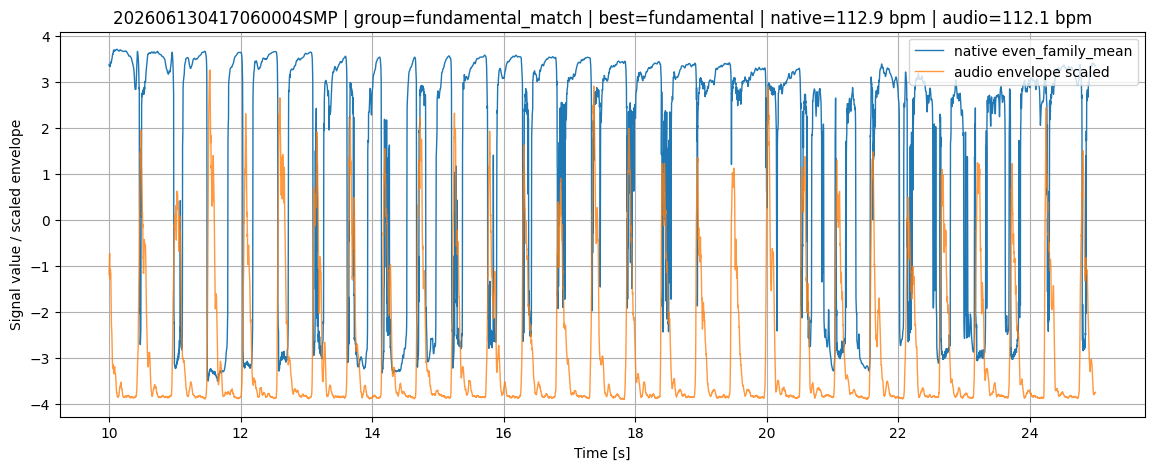

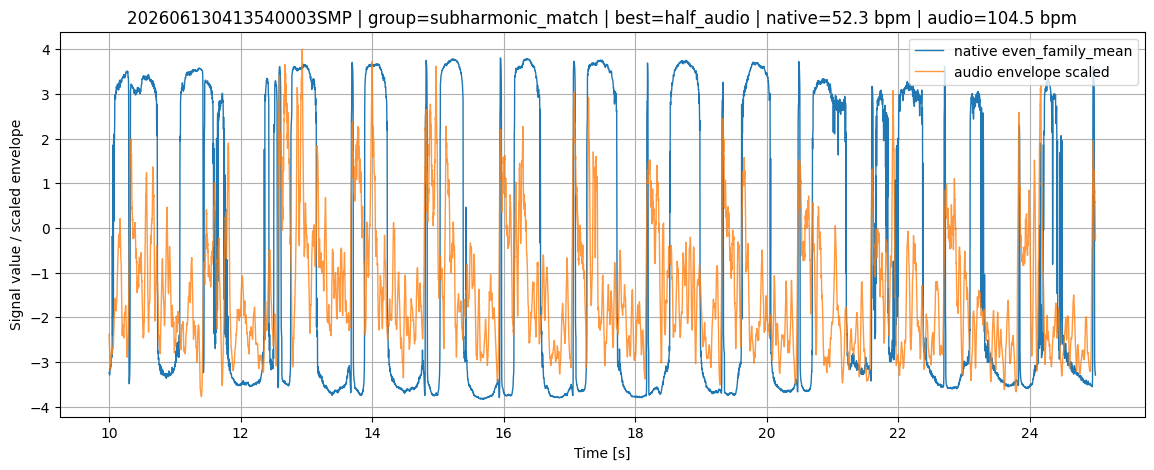

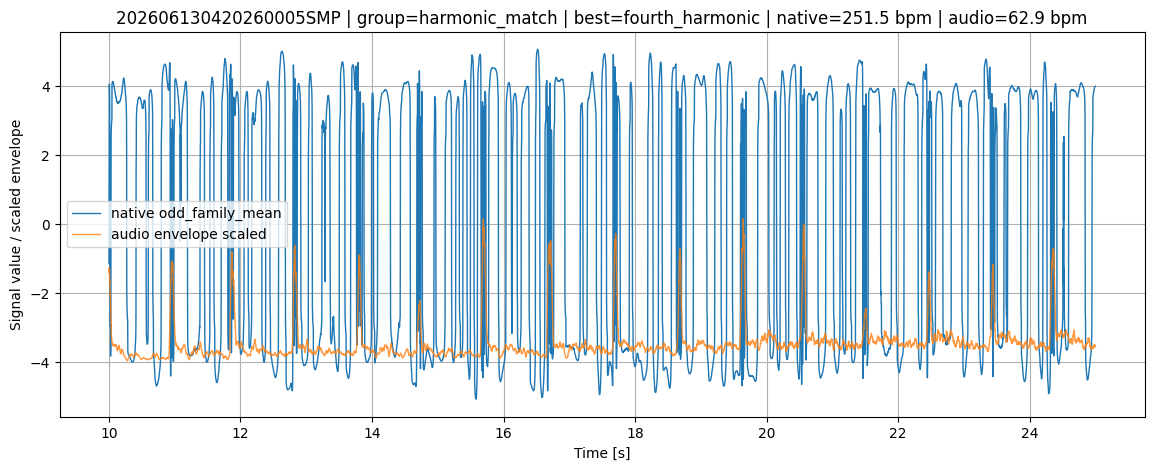

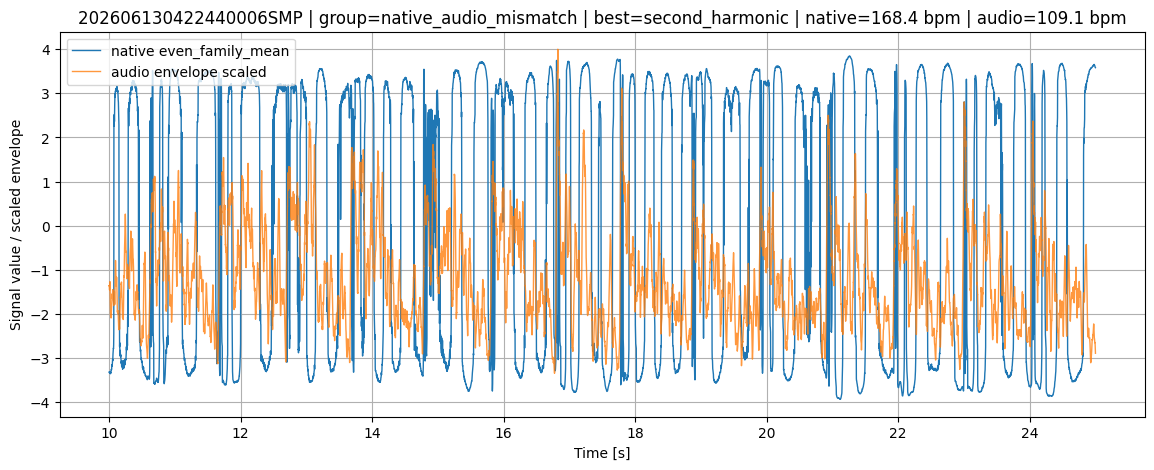

In [131]:
representative_recordings = {
    "fundamental_match": "202606130417060004SMP",
    "subharmonic_match": "202606130413540003SMP",
    "harmonic_match": "202606130420260005SMP",
    "native_audio_mismatch": "202606130422440006SMP",
}

for group_name, recording_id in representative_recordings.items():
    plot_native_audio_overlay_for_recording(
        recording_id=recording_id,
        batch_debug=batch_debug,
        batch_validation_df=batch_validation_df,
        batch_hr_diagnostic_df=batch_hr_diagnostic_df,
        window_start_s=10,
        window_end_s=25,
        native_family=None,
    )

## Interim finding: representative plots show different native dynamic modes

Representative visual inspection shows that native PW dynamic signals behave differently across diagnostic groups.

In a fundamental-match recording, the native dynamic signal follows the linked AVI Doppler audio rhythm closely at the fundamental HR frequency.

In a subharmonic-match recording, the native signal appears to follow a slower periodic structure, approximately half of the audio HR.

In a harmonic-match recording, the native signal shows multiple transitions per audio beat, and the strongest native frequency appears near a higher harmonic of audio HR.

In a mismatch recording, both native and audio signals appear less clearly aligned in the selected window, suggesting that segment quality and signal-quality gating are important.

The working interpretation is:

```text
The native PW dynamic block is a structured Doppler-related event stream, not a clean final HR waveform.
Its dominant frequency can represent fundamental HR, subharmonics, harmonics, or non-HR switching depending on recording and segment quality.

## Segment-level native versus audio frequency analysis

The previous batch-level analysis used one global frequency estimate per recording.

Visual inspection showed that this is too coarse.

Native dynamic signals can change behavior across time, and some recordings contain stable and unstable segments.

This section performs segment-level analysis.

Each recording is divided into fixed time windows.  
For each window, the section estimates:

- native even-family dominant frequency,
- native odd-family dominant frequency,
- audio envelope dominant frequency,
- harmonic-aware relationship between native and audio estimates.

The goal is to identify stable segments where native and audio timing agree, and to separate those from noisy or ambiguous segments.

In [133]:
def iter_time_windows(duration_s, window_length_s=10.0, step_s=5.0):
    """
    Generate fixed-length time windows over a recording duration.

    Parameters
    ----------
    duration_s : float
        Recording duration in seconds.

    window_length_s : float
        Window length in seconds.

    step_s : float
        Step between consecutive window starts in seconds.

    Returns
    -------
    windows : list of dict
        One dictionary per window with:
        - window_index
        - window_start_s
        - window_end_s
    """

    if duration_s <= 0:
        return []

    windows = []
    window_index = 0
    start_s = 0.0

    while start_s + window_length_s <= duration_s:
        windows.append(
            {
                "window_index": window_index,
                "window_start_s": float(start_s),
                "window_end_s": float(start_s + window_length_s),
            }
        )

        window_index += 1
        start_s += step_s

    return windows


def estimate_dominant_frequency_in_window(
    time_s,
    signal_values,
    window_start_s,
    window_end_s,
    fmin=0.5,
    fmax=5.0,
):
    """
    Estimate dominant frequency of a signal inside one time window.

    The function extracts the selected time window and calls
    estimate_dominant_frequency().

    Parameters
    ----------
    time_s : numpy.ndarray
        Time axis in seconds.

    signal_values : array-like
        Signal values.

    window_start_s : float
        Window start time in seconds.

    window_end_s : float
        Window end time in seconds.

    fmin : float
        Minimum searched frequency.

    fmax : float
        Maximum searched frequency.

    Returns
    -------
    result : dict
        Dominant frequency result for the selected window.
    """
    time_s = np.asarray(time_s, dtype=float)
    values = np.asarray(signal_values, dtype=float)

    if len(time_s) != len(values):
        raise ValueError("time_s and signal_values must have the same length.")

    mask = (time_s >= window_start_s) & (time_s < window_end_s)

    if mask.sum() < 10:
        return {
            "dominant_frequency_hz": np.nan,
            "dominant_frequency_bpm": np.nan,
            "dominant_power": np.nan,
            "n_samples": int(mask.sum()),
        }

    window_time = time_s[mask]
    window_values = values[mask]

    sample_rate_hz = 1.0 / np.median(np.diff(window_time))

    result = estimate_dominant_frequency(
        signal_values=window_values,
        sample_rate_hz=sample_rate_hz,
        fmin=fmin,
        fmax=fmax,
    )

    return result


def build_segment_level_native_audio_frequency_table(
    batch_debug,
    batch_validation_df,
    recording_ids=None,
    window_length_s=10.0,
    step_s=5.0,
    fmin=0.5,
    fmax=5.0,
    tolerance_bpm=6.0,
):
    """
    Build segment-level native-versus-audio frequency diagnostics.

    For each recording and each time window, the function estimates:

    - even-family native dominant frequency,
    - odd-family native dominant frequency,
    - linked AVI audio-envelope dominant frequency.

    It then classifies the relationship between native and audio estimates
    using harmonic-aware logic.

    Parameters
    ----------
    batch_debug : dict
        Debug dictionary created during batch validation.

    batch_validation_df : pandas.DataFrame
        Batch validation summary table.

    recording_ids : list of str or None
        Recording IDs to analyze. If None, all available recording IDs from
        batch_validation_df with status == "ok" are used.

    window_length_s : float
        Segment length in seconds.

    step_s : float
        Step between segment starts in seconds.

    fmin : float
        Minimum frequency for dominant frequency search.

    fmax : float
        Maximum frequency for dominant frequency search.

    tolerance_bpm : float
        BPM tolerance for harmonic-aware relationship classification.

    Returns
    -------
    segment_frequency_df : pandas.DataFrame
        One row per recording and time window.
    """
    if recording_ids is None:
        recording_ids = (
            batch_validation_df[
                batch_validation_df["status"] == "ok"
            ]["recording_id"]
            .tolist()
        )

    rows = []

    for recording_id in recording_ids:
        debug = batch_debug.get(recording_id, None)

        if debug is None or len(debug) == 0:
            rows.append(
                {
                    "recording_id": recording_id,
                    "window_index": np.nan,
                    "status": "missing_debug",
                }
            )
            continue

        family_df = debug["family_df"]
        native_time_s = debug["time_s"]
        audio_time_s = debug["audio_time_s"]
        audio_envelope = debug["audio_envelope"]

        duration_s = min(
            float(np.nanmax(native_time_s)),
            float(np.nanmax(audio_time_s)),
        )

        windows = iter_time_windows(
            duration_s=duration_s,
            window_length_s=window_length_s,
            step_s=step_s,
        )

        for window in windows:
            window_start_s = window["window_start_s"]
            window_end_s = window["window_end_s"]

            even_result = estimate_dominant_frequency_in_window(
                time_s=native_time_s,
                signal_values=family_df["even_family_mean"],
                window_start_s=window_start_s,
                window_end_s=window_end_s,
                fmin=fmin,
                fmax=fmax,
            )

            odd_result = estimate_dominant_frequency_in_window(
                time_s=native_time_s,
                signal_values=family_df["odd_family_mean"],
                window_start_s=window_start_s,
                window_end_s=window_end_s,
                fmin=fmin,
                fmax=fmax,
            )

            audio_result = estimate_dominant_frequency_in_window(
                time_s=audio_time_s,
                signal_values=audio_envelope,
                window_start_s=window_start_s,
                window_end_s=window_end_s,
                fmin=fmin,
                fmax=fmax,
            )

            audio_bpm = audio_result["dominant_frequency_bpm"]
            even_bpm = even_result["dominant_frequency_bpm"]
            odd_bpm = odd_result["dominant_frequency_bpm"]

            even_relationship = classify_hr_relationship_single_value(
                native_bpm=even_bpm,
                audio_bpm=audio_bpm,
                tolerance_bpm=tolerance_bpm,
            )

            odd_relationship = classify_hr_relationship_single_value(
                native_bpm=odd_bpm,
                audio_bpm=audio_bpm,
                tolerance_bpm=tolerance_bpm,
            )

            family_candidates = [
                {
                    "family": "even",
                    "native_bpm": even_bpm,
                    **even_relationship,
                },
                {
                    "family": "odd",
                    "native_bpm": odd_bpm,
                    **odd_relationship,
                },
            ]

            best_candidate = min(
                family_candidates,
                key=lambda item: (
                    not item["match_ok"],
                    item["abs_error_bpm"] if np.isfinite(item["abs_error_bpm"]) else np.inf,
                ),
            )

            if best_candidate["match_ok"]:
                if best_candidate["relationship"] == "fundamental":
                    diagnostic_group = "fundamental_match"
                elif best_candidate["relationship"] == "half_audio":
                    diagnostic_group = "subharmonic_match"
                elif best_candidate["relationship"] in [
                    "second_harmonic",
                    "third_harmonic",
                    "fourth_harmonic",
                ]:
                    diagnostic_group = "harmonic_match"
                else:
                    diagnostic_group = "other_match"
            else:
                diagnostic_group = "native_audio_mismatch"

            rows.append(
                {
                    "recording_id": recording_id,
                    "window_index": window["window_index"],
                    "window_start_s": window_start_s,
                    "window_end_s": window_end_s,
                    "status": "ok",

                    "audio_dominant_bpm": audio_bpm,
                    "audio_dominant_hz": audio_result["dominant_frequency_hz"],
                    "audio_dominant_power": audio_result["dominant_power"],

                    "even_dominant_bpm": even_bpm,
                    "even_dominant_hz": even_result["dominant_frequency_hz"],
                    "even_dominant_power": even_result["dominant_power"],
                    "even_relationship": even_relationship["relationship"],
                    "even_abs_error_bpm": even_relationship["abs_error_bpm"],
                    "even_match_ok": even_relationship["match_ok"],

                    "odd_dominant_bpm": odd_bpm,
                    "odd_dominant_hz": odd_result["dominant_frequency_hz"],
                    "odd_dominant_power": odd_result["dominant_power"],
                    "odd_relationship": odd_relationship["relationship"],
                    "odd_abs_error_bpm": odd_relationship["abs_error_bpm"],
                    "odd_match_ok": odd_relationship["match_ok"],

                    "best_family": best_candidate["family"],
                    "best_native_bpm": best_candidate["native_bpm"],
                    "best_relationship": best_candidate["relationship"],
                    "best_abs_error_bpm": best_candidate["abs_error_bpm"],
                    "best_match_ok": best_candidate["match_ok"],
                    "diagnostic_group": diagnostic_group,
                }
            )

    segment_frequency_df = pd.DataFrame(rows)

    return segment_frequency_df


def summarize_segment_frequency_diagnostics(segment_frequency_df):
    """
    Summarize segment-level native-versus-audio diagnostic groups.

    Parameters
    ----------
    segment_frequency_df : pandas.DataFrame
        Segment-level frequency table.

    Returns
    -------
    segment_summary_by_group_df : pandas.DataFrame
        Summary by diagnostic group.

    segment_summary_by_recording_df : pandas.DataFrame
        Summary by recording.
    """
    ok_df = segment_frequency_df[segment_frequency_df["status"] == "ok"].copy()

    if len(ok_df) == 0:
        return pd.DataFrame(), pd.DataFrame()

    segment_summary_by_group_df = (
        ok_df
        .groupby(["diagnostic_group", "best_relationship", "best_family"], dropna=False)
        .agg(
            n_segments=("recording_id", "size"),
            n_recordings=("recording_id", "nunique"),
            median_best_abs_error_bpm=("best_abs_error_bpm", "median"),
            max_best_abs_error_bpm=("best_abs_error_bpm", "max"),
            median_audio_bpm=("audio_dominant_bpm", "median"),
            median_native_bpm=("best_native_bpm", "median"),
        )
        .reset_index()
        .sort_values(["diagnostic_group", "best_relationship", "best_family"])
    )

    segment_summary_by_recording_df = (
        ok_df
        .groupby("recording_id", dropna=False)
        .agg(
            n_segments=("window_index", "size"),
            n_fundamental=("diagnostic_group", lambda x: (x == "fundamental_match").sum()),
            n_subharmonic=("diagnostic_group", lambda x: (x == "subharmonic_match").sum()),
            n_harmonic=("diagnostic_group", lambda x: (x == "harmonic_match").sum()),
            n_mismatch=("diagnostic_group", lambda x: (x == "native_audio_mismatch").sum()),
            median_best_abs_error_bpm=("best_abs_error_bpm", "median"),
            median_audio_bpm=("audio_dominant_bpm", "median"),
            median_best_native_bpm=("best_native_bpm", "median"),
        )
        .reset_index()
    )

    segment_summary_by_recording_df["match_fraction"] = (
        (
            segment_summary_by_recording_df["n_fundamental"]
            + segment_summary_by_recording_df["n_subharmonic"]
            + segment_summary_by_recording_df["n_harmonic"]
        )
        / segment_summary_by_recording_df["n_segments"]
    )

    return segment_summary_by_group_df, segment_summary_by_recording_df

In [134]:
segment_frequency_df = build_segment_level_native_audio_frequency_table(
    batch_debug=batch_debug,
    batch_validation_df=batch_validation_df,
    recording_ids=None,
    window_length_s=10.0,
    step_s=5.0,
    fmin=0.5,
    fmax=5.0,
    tolerance_bpm=6.0,
)

segment_summary_by_group_df, segment_summary_by_recording_df = summarize_segment_frequency_diagnostics(segment_frequency_df)
segment_frequency_df.shape

(73, 26)

In [135]:
segment_summary_by_group_df

,diagnostic_group,best_relationship,best_family,n_segments,n_recordings,median_best_abs_error_bpm,max_best_abs_error_bpm,median_audio_bpm,median_native_bpm
0,fundamental_match,fundamental,even,19,4,0.004942,5.998767,60.0,59.998879
1,fundamental_match,fundamental,odd,5,4,0.011977,5.998767,66.0,65.998767
2,harmonic_match,fourth_harmonic,even,1,1,5.986875,5.986875,66.0,269.986875
3,harmonic_match,fourth_harmonic,odd,1,1,0.029329,0.029329,54.0,215.970671
4,harmonic_match,second_harmonic,even,1,1,5.992659,5.992659,60.0,114.007341
5,harmonic_match,second_harmonic,odd,2,1,2.996937,5.987458,96.0,194.990521
6,harmonic_match,third_harmonic,even,4,2,0.008750,5.988796,60.0,179.991250
7,native_audio_mismatch,fundamental,even,16,5,11.989745,36.025794,108.0,99.000332
8,native_audio_mismatch,fundamental,odd,1,1,18.009025,18.009025,90.0,71.990975
9,native_audio_mismatch,half_audio,even,8,5,19.505721,60.004942,108.0,53.994763


In [136]:
segment_summary_by_recording_df

,recording_id,n_segments,n_fundamental,n_subharmonic,n_harmonic,n_mismatch,median_best_abs_error_bpm,median_audio_bpm,median_best_native_bpm,match_fraction
0,202606130411060002SMP,10,10,0,0,0,0.001121,60.0,59.998879,1.000000
1,202606130413540003SMP,8,7,0,0,1,0.005406,54.0,53.995058,0.875000
2,202606130417060004SMP,7,3,0,0,4,6.004804,114.0,107.994914,0.428571
3,202606130420260005SMP,8,0,0,6,2,2.997812,66.0,179.991250,0.750000
4,202606130422440006SMP,9,0,0,3,6,12.022811,60.0,167.977189,0.333333
5,202606130426500007SMP,6,0,0,0,6,17.998496,90.0,90.006738,0.000000
6,202606130430380008SMP,7,1,0,0,6,11.999173,108.0,42.000827,0.142857
7,202606130433280009SMP,5,0,1,0,4,11.994533,216.0,107.984524,0.200000
8,202606130434130010SMP,5,0,1,0,4,18.002128,210.0,101.997588,0.200000
9,202606130437480012SMP,8,3,1,0,4,6.000142,66.0,59.999858,0.500000


In [137]:
segment_frequency_df[
    [
        "recording_id",
        "window_index",
        "window_start_s",
        "window_end_s",
        "audio_dominant_bpm",
        "even_dominant_bpm",
        "even_relationship",
        "even_match_ok",
        "odd_dominant_bpm",
        "odd_relationship",
        "odd_match_ok",
        "best_family",
        "best_relationship",
        "best_abs_error_bpm",
        "diagnostic_group",
    ]
].head(80)

,recording_id,window_index,window_start_s,window_end_s,audio_dominant_bpm,even_dominant_bpm,even_relationship,even_match_ok,odd_dominant_bpm,odd_relationship,odd_match_ok,best_family,best_relationship,best_abs_error_bpm,diagnostic_group
0,202606130411060002SMP,0,0.0,10.0,60.0,53.998991,fundamental,False,65.998767,fundamental,True,odd,fundamental,5.998767,fundamental_match
1,202606130411060002SMP,1,5.0,15.0,60.0,59.998879,fundamental,True,53.998991,fundamental,False,even,fundamental,0.001121,fundamental_match
2,202606130411060002SMP,2,10.0,20.0,60.0,59.998879,fundamental,True,65.998767,fundamental,True,even,fundamental,0.001121,fundamental_match
3,202606130411060002SMP,3,15.0,25.0,60.0,59.998879,fundamental,True,59.998879,fundamental,True,even,fundamental,0.001121,fundamental_match
4,202606130411060002SMP,4,20.0,30.0,60.0,59.998879,fundamental,True,59.998879,fundamental,True,even,fundamental,0.001121,fundamental_match
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,202606130437480012SMP,3,15.0,25.0,66.0,72.007037,fundamental,False,60.005864,fundamental,True,odd,fundamental,5.994136,fundamental_match
69,202606130437480012SMP,4,20.0,30.0,66.0,59.993853,fundamental,False,59.993853,fundamental,False,even,fundamental,6.006147,native_audio_mismatch
70,202606130437480012SMP,5,25.0,35.0,66.0,65.993238,fundamental,True,65.993238,fundamental,True,even,fundamental,0.006762,fundamental_match
71,202606130437480012SMP,6,30.0,40.0,72.0,36.003518,half_audio,True,216.021110,third_harmonic,True,even,half_audio,0.003518,subharmonic_match


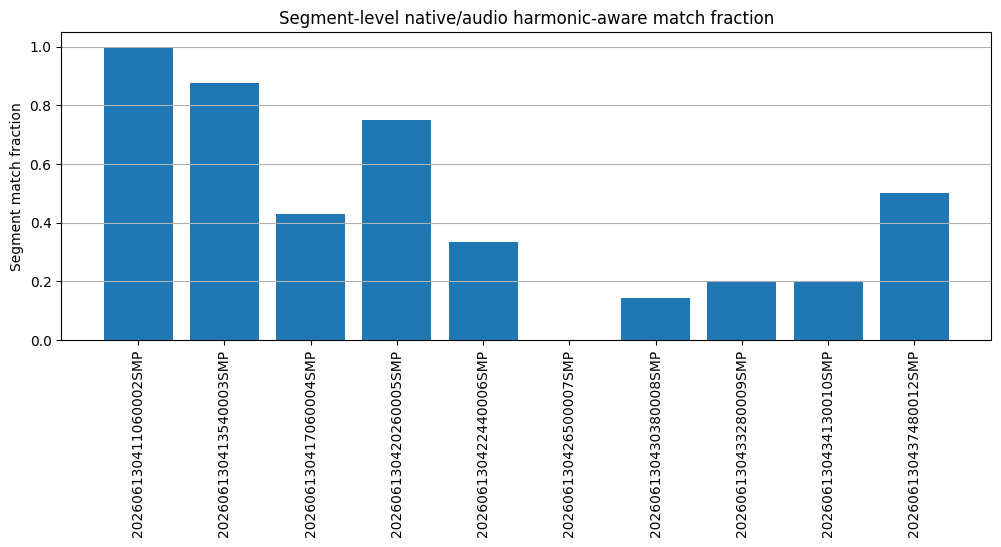

In [138]:
plt.figure(figsize=(12, 4))
plt.bar(segment_summary_by_recording_df["recording_id"], segment_summary_by_recording_df["match_fraction"],)
plt.xticks(rotation=90)
plt.ylabel("Segment match fraction")
plt.title("Segment-level native/audio harmonic-aware match fraction")
plt.grid(True, axis="y")
plt.show()

## Interim finding: segment-level analysis improves diagnostics but is limited by FFT resolution

Segment-level native/audio analysis was performed using 10-second windows with 5-second step.

This showed that some recordings have strong segment-level agreement between native PW dynamic signals and linked AVI audio frequency estimates.

However, 10-second FFT windows have a frequency resolution of:

```text
0.1 Hz = 6 bpm

## Current evidence summary and next decisions

This section summarizes the current evidence from native Mindray PW export exploration.

The goal is to separate:

- what is directly supported by extracted metadata and binary structure,
- what is likely but not yet proven,
- what remains unknown,
- which next analysis path is most reasonable.

This section is a checkpoint.

It does not introduce a new decoder or a final physiological estimator.

### What is directly supported

The native export contains a consistent PW cine partition.

`VirtualMachine.txt` identifies:

```text
CinePartition0 = PW
CinePartition1 = BC
```


###  What is supported by linked AVI validation

The linked AVI is not treated as native export data.

It is used only as an external timing and audio reference.

For the first inspected recording, the reduced native dynamic families showed a dominant frequency near:

```text
~62.8 bpm
```

### What the batch analysis suggests

Batch extraction succeeded for all 10 recordings.

The native PW page stream rate was highly stable across recordings:

```text
~499.5 Hz
```

###  What is not proven yet

The current analysis does not prove that the native PW dynamic block is raw audio.

The page rate is approximately 500 Hz, which is much lower than conventional Doppler audio sampling rates.

The current analysis also does not prove that the dynamic block is the final clinical Doppler velocity waveform.

The native dynamic stream may represent:

- internal PW processing data,
- spectral rendering state,
- envelope-like features,
- Doppler/audio-derived features,
- display state transitions,
- or another proprietary PW representation.

The current analysis does not yet recover:

- PSV,
- EDV,
- RI,
- full spectral image,
- audio waveform,
- calibrated velocity envelope,
- or clinical beat-level Doppler features.

The native stream is meaningful, structured, and PW-related, but its exact semantic meaning is still unresolved.

## PW mixed-record codebook exploration

The dynamic PW payload was interpreted experimentally as repeated 8-byte mixed records:

```text
uint32-like code + float32-like value

In [139]:
def summarize_record_u32_codebook(record_u32, max_records=None):
    """
    Summarize uint32-like code values in mixed PW records.

    The function summarizes each record position independently.

    For each record index, it reports:
    - number of unique codes,
    - most frequent codes,
    - first and last code,
    - whether the code is constant,
    - whether the code values are shared with other record positions.

    Parameters
    ----------
    record_u32 : numpy.ndarray
        Candidate uint32 code matrix with shape `(n_pages, n_records)`.

    max_records : int or None
        Optional maximum number of record positions to summarize.

    Returns
    -------
    codebook_summary_df : pandas.DataFrame
        One row per record position.

    code_frequency_df : pandas.DataFrame
        Long table of code frequencies per record position.
    """
    if record_u32.ndim != 2:
        raise ValueError("Expected record_u32 with shape (n_pages, n_records).")

    n_pages, n_records = record_u32.shape

    if max_records is None:
        max_records = n_records

    max_records = min(max_records, n_records)

    summary_rows = []
    frequency_rows = []

    for record_index in range(max_records):
        codes = record_u32[:, record_index]

        value_counts = pd.Series(codes).value_counts(dropna=False)

        n_unique = int(value_counts.shape[0])
        most_common_code = int(value_counts.index[0])
        most_common_count = int(value_counts.iloc[0])
        most_common_fraction = most_common_count / n_pages

        for code_value, count in value_counts.items():
            frequency_rows.append(
                {
                    "record_index": record_index,
                    "code_value": int(code_value),
                    "count": int(count),
                    "fraction": float(count / n_pages),
                }
            )

        summary_rows.append(
            {
                "record_index": record_index,
                "n_unique_codes": n_unique,
                "constant_code": n_unique == 1,
                "first_code": int(codes[0]),
                "last_code": int(codes[-1]),
                "most_common_code": most_common_code,
                "most_common_count": most_common_count,
                "most_common_fraction": float(most_common_fraction),
                "min_code": int(np.min(codes)),
                "max_code": int(np.max(codes)),
            }
        )

    codebook_summary_df = pd.DataFrame(summary_rows)
    code_frequency_df = pd.DataFrame(frequency_rows)

    return codebook_summary_df, code_frequency_df


def summarize_shared_codes_across_record_positions(record_u32, record_indices=None):
    """
    Summarize how uint32-like codes are shared across record positions.

    This function checks whether different record positions use the same
    codebook values.

    Parameters
    ----------
    record_u32 : numpy.ndarray
        Candidate uint32 code matrix with shape `(n_pages, n_records)`.

    record_indices : list of int or None
        Record positions to include. If None, all positions are included.

    Returns
    -------
    shared_code_df : pandas.DataFrame
        One row per unique code value with the record positions where it appears.
    """
    if record_u32.ndim != 2:
        raise ValueError("Expected record_u32 with shape (n_pages, n_records).")

    if record_indices is None:
        record_indices = list(range(record_u32.shape[1]))

    rows = []

    for record_index in record_indices:
        codes = record_u32[:, record_index]
        unique_codes = np.unique(codes)

        for code_value in unique_codes:
            rows.append(
                {
                    "code_value": int(code_value),
                    "record_index": int(record_index),
                }
            )

    code_position_df = pd.DataFrame(rows)

    shared_code_df = (
        code_position_df
        .groupby("code_value")
        .agg(
            n_record_positions=("record_index", "nunique"),
            record_positions=("record_index", lambda x: sorted(set(x))),
        )
        .reset_index()
        .sort_values(
            ["n_record_positions", "code_value"],
            ascending=[False, True],
        )
    )

    return shared_code_df

In [140]:
codebook_summary_df, code_frequency_df = summarize_record_u32_codebook(record_u32=record_u32, max_records=160)

codebook_summary_df.head(40)

,record_index,n_unique_codes,constant_code,first_code,last_code,most_common_code,most_common_count,most_common_fraction,min_code,max_code
0,0,45,False,2532929431,1321528399,1101273665,830,0.028026,0,4184839929
1,1,45,False,0,3634203096,3744330463,807,0.027250,0,4184839929
2,2,45,False,1321528399,2973438897,1872165231,852,0.028769,0,4184839929
3,3,45,False,991146299,440509466,3303820997,824,0.027824,0,4184839929
4,4,45,False,330382099,2422802064,2973438897,819,0.027655,0,4184839929
5,5,45,False,991146299,110127366,3524075730,800,0.027013,0,4184839929
6,6,45,False,1101273665,3193693630,2202547331,812,0.027419,0,4184839929
7,7,45,False,3303820997,2863311530,550636833,817,0.027587,0,4184839929
8,8,45,False,110127366,1321528399,2312674698,811,0.027385,0,4184839929
9,9,45,False,2863311530,4184839929,2643056797,821,0.027722,0,4184839929


In [141]:
codebook_summary_df.tail(40)

,record_index,n_unique_codes,constant_code,first_code,last_code,most_common_code,most_common_count,most_common_fraction,min_code,max_code
120,120,1,True,4294967294,4294967294,4294967294,29615,1.000000,4294967294,4294967294
121,121,1,True,3079660952,3079660952,3079660952,29615,1.000000,3079660952,3079660952
122,122,1,True,1,1,1,29615,1.000000,1,1
123,123,1,True,3079661168,3079661168,3079661168,29615,1.000000,3079661168,3079661168
124,124,1,True,1779055737,1779055737,1779055737,29615,1.000000,1779055737,1779055737
125,125,1,True,1683855984,1683855984,1683855984,29615,1.000000,1683855984,1683855984
126,126,1,True,1,1,1,29615,1.000000,1,1
127,127,1,True,3079661080,3079661080,3079661080,29615,1.000000,3079661080,3079661080
128,128,1,True,1880257696,1880257696,1880257696,29615,1.000000,1880257696,1880257696
129,129,1,True,1786057792,1786057792,1786057792,29615,1.000000,1786057792,1786057792


In [142]:
dynamic_codebook_summary_df = codebook_summary_df[codebook_summary_df["record_index"] < 16].copy()
dynamic_codebook_summary_df

,record_index,n_unique_codes,constant_code,first_code,last_code,most_common_code,most_common_count,most_common_fraction,min_code,max_code
0,0,45,False,2532929431,1321528399,1101273665,830,0.028026,0,4184839929
1,1,45,False,0,3634203096,3744330463,807,0.027250,0,4184839929
2,2,45,False,1321528399,2973438897,1872165231,852,0.028769,0,4184839929
3,3,45,False,991146299,440509466,3303820997,824,0.027824,0,4184839929
4,4,45,False,330382099,2422802064,2973438897,819,0.027655,0,4184839929
5,5,45,False,991146299,110127366,3524075730,800,0.027013,0,4184839929
6,6,45,False,1101273665,3193693630,2202547331,812,0.027419,0,4184839929
7,7,45,False,3303820997,2863311530,550636833,817,0.027587,0,4184839929
8,8,45,False,110127366,1321528399,2312674698,811,0.027385,0,4184839929
9,9,45,False,2863311530,4184839929,2643056797,821,0.027722,0,4184839929


In [143]:
static_codebook_summary_df = codebook_summary_df[codebook_summary_df["record_index"] >= 16].copy()

static_codebook_summary_df.head(60)

,record_index,n_unique_codes,constant_code,first_code,last_code,most_common_code,most_common_count,most_common_fraction,min_code,max_code
16,16,1,True,1,1,1,29615,1.0,1,1
17,17,1,True,0,0,0,29615,1.0,0,0
18,18,1,True,1790324592,1790324592,1790324592,29615,1.0,1790324592,1790324592
19,19,1,True,4294967294,4294967294,4294967294,29615,1.0,4294967294,4294967294
20,20,1,True,1790324592,1790324592,1790324592,29615,1.0,1790324592,1790324592
21,21,1,True,3079660033,3079660033,3079660033,29615,1.0,3079660033,3079660033
22,22,1,True,1995510017,1995510017,1995510017,29615,1.0,1995510017,1995510017
23,23,1,True,3666569368,3666569368,3666569368,29615,1.0,3666569368,3666569368
24,24,1,True,1733064544,1733064544,1733064544,29615,1.0,1733064544,1733064544
25,25,1,True,1733064576,1733064576,1733064576,29615,1.0,1733064576,1733064576


In [144]:
dynamic_shared_code_df = summarize_shared_codes_across_record_positions(record_u32=record_u32, record_indices=list(range(16)))

dynamic_shared_code_df.head(80)

,code_value,n_record_positions,record_positions
0,0,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,110127366,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,220254733,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,330382099,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,330382100,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
5,440509466,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
6,550636833,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
7,660764199,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
8,770891566,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
9,881018932,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


In [145]:
top_dynamic_code_frequency_df = (
    code_frequency_df[
        code_frequency_df["record_index"] < 16
    ]
    .sort_values(
        ["record_index", "count"],
        ascending=[True, False],
    )
    .groupby("record_index")
    .head(10)
    .reset_index(drop=True)
)

top_dynamic_code_frequency_df

,record_index,code_value,count,fraction
0,0,1101273665,830,0.028026
1,0,2753184164,805,0.027182
2,0,4184839929,796,0.026878
3,0,2532929431,794,0.026811
4,0,2202547331,793,0.026777
...,...,...,...,...
155,15,4184839929,835,0.028195
156,15,2202547331,831,0.028060
157,15,881018932,825,0.027858
158,15,1762037865,804,0.027148


In [146]:
def add_hex_to_code_frequency_df(code_frequency_df):
    """
    Add hexadecimal representation to uint32-like code frequency table.

    Parameters
    ----------
    code_frequency_df : pandas.DataFrame
        Code frequency table with a `code_value` column.

    Returns
    -------
    output_df : pandas.DataFrame
        Copy of the input table with `code_hex`.
    """
    output_df = code_frequency_df.copy()
    output_df["code_hex"] = output_df["code_value"].apply(lambda value: f"0x{int(value):08X}")

    return output_df

In [147]:
top_dynamic_code_frequency_hex_df = add_hex_to_code_frequency_df(top_dynamic_code_frequency_df)
top_dynamic_code_frequency_hex_df

,record_index,code_value,count,fraction,code_hex
0,0,1101273665,830,0.028026,0x41A41A41
1,0,2753184164,805,0.027182,0xA41A41A4
2,0,4184839929,796,0.026878,0xF96F96F9
3,0,2532929431,794,0.026811,0x96F96F97
4,0,2202547331,793,0.026777,0x83483483
...,...,...,...,...,...
155,15,4184839929,835,0.028195,0xF96F96F9
156,15,2202547331,831,0.028060,0x83483483
157,15,881018932,825,0.027858,0x34834834
158,15,1762037865,804,0.027148,0x69069069


In [148]:
def reinterpret_u32_codes_as_float32(record_u32, record_indices=None):
    """
    Reinterpret uint32-like code values as float32 values.

    This tests whether the code part of each mixed record may actually be
    another float32 field viewed as uint32.

    Parameters
    ----------
    record_u32 : numpy.ndarray
        Candidate uint32 code matrix.

    record_indices : list of int or None
        Record positions to inspect. If None, all positions are inspected.

    Returns
    -------
    code_as_f32 : numpy.ndarray
        Float32 reinterpretation of selected code values.

    code_as_f32_summary_df : pandas.DataFrame
        Summary per selected record position.
    """
    if record_u32.ndim != 2:
        raise ValueError("Expected record_u32 with shape (n_pages, n_records).")

    if record_indices is None:
        record_indices = list(range(record_u32.shape[1]))

    selected_codes = np.ascontiguousarray(record_u32[:, record_indices])

    code_as_f32 = selected_codes.copy().view("<f4")

    rows = []

    for local_index, record_index in enumerate(record_indices):
        values = code_as_f32[:, local_index]
        finite_values = values[np.isfinite(values)]

        rows.append(
            {
                "record_index": record_index,
                "n_finite": int(finite_values.size),
                "min_value": float(np.min(finite_values)) if finite_values.size else np.nan,
                "max_value": float(np.max(finite_values)) if finite_values.size else np.nan,
                "mean_value": float(np.mean(finite_values)) if finite_values.size else np.nan,
                "std_value": float(np.std(finite_values)) if finite_values.size else np.nan,
                "median_value": float(np.median(finite_values)) if finite_values.size else np.nan,
                "n_unique_rounded_6": int(pd.Series(np.round(finite_values, 6)).nunique()) if finite_values.size else 0,
            }
        )

    code_as_f32_summary_df = pd.DataFrame(rows)

    return code_as_f32, code_as_f32_summary_df

In [149]:
dynamic_code_as_f32, dynamic_code_as_f32_summary_df = reinterpret_u32_codes_as_float32(record_u32=record_u32, record_indices=list(range(16)))

dynamic_code_as_f32_summary_df

D:\code\DopplerLab\venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
D:\code\DopplerLab\venv\Lib\site-packages\numpy\_core\_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
D:\code\DopplerLab\venv\Lib\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)


,record_index,n_finite,min_value,max_value,mean_value,std_value,median_value,n_unique_rounded_6
0,0,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
1,1,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
2,2,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
3,3,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
4,4,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
5,5,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
6,6,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
7,7,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
8,8,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24
9,9,29615,-7.775131e+34,7.634540e+36,inf,inf,0.000000e+00,24


In [150]:
pd.DataFrame(dynamic_code_as_f32[:10, :16])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-4.029854e-25,0.000000e+00,1.651911e+09,2.253606e-03,4.473933e-27,2.253606e-03,2.051282e+01,-1.890462e+03,5.432110e-35,-3.031649e-13,-3.344903e-17,-4.595620e-29,-9.998746e+26,1.293341e+17,-5.214826e-33,-9.998746e+26
1,-9.998746e+26,-5.883500e-37,9.344860e+28,8.487408e+32,3.142785e-15,-1.515353e+11,-1.253433e+19,-1.253433e+19,4.955665e-31,9.344860e+28,-1.656212e+07,8.487408e+32,-3.031649e-13,-4.595620e-29,-5.214826e-33,-9.998746e+26
2,-8.841050e+30,-1.385723e+15,-8.841050e+30,-8.841050e+30,2.761133e-11,1.651911e+09,-1.515353e+11,-1.515353e+11,3.558407e-19,1.651911e+09,2.051282e+01,2.445319e-07,-1.123681e+23,7.634540e+36,-5.214826e-33,-9.998746e+26
3,2.445319e-07,-1.385723e+15,-1.656212e+07,2.445319e-07,-9.998746e+26,1.016738e+25,-1.253433e+19,1.016738e+25,1.651911e+09,9.344860e+28,-2.147436e-01,-1.385723e+15,1.466015e+13,0.000000e+00,-5.214826e-33,-9.998746e+26
4,-3.344903e-17,4.004402e-23,2.051282e+01,-5.214826e-33,-7.775131e+34,-3.648757e-21,5.432110e-35,-2.425756e-05,2.051282e+01,7.634540e+36,4.004402e-23,-1.123681e+23,-1.656212e+07,1.293341e+17,-2.722327e-09,2.051282e+01
5,4.473933e-27,1.466015e+13,4.473933e-27,-7.775131e+34,2.445319e-07,-1.123681e+23,-2.425756e-05,3.142785e-15,1.016738e+25,2.445319e-07,-5.883500e-37,2.253606e-03,-7.775131e+34,2.051282e+01,-2.722327e-09,2.051282e+01
6,0.000000e+00,-2.147436e-01,-8.841050e+30,1.651911e+09,-1.385723e+15,-2.722327e-09,-5.883500e-37,-1.123681e+23,4.955665e-31,-2.425756e-05,-1.890462e+03,9.344860e+28,1.651911e+09,9.344860e+28,-2.722327e-09,2.051282e+01
7,7.634540e+36,-8.841050e+30,4.955665e-31,2.445319e-07,-1.656212e+07,1.016738e+25,1.848451e+05,-3.648757e-21,3.558407e-19,-1.515353e+11,-1.656212e+07,-3.031649e-13,-3.648757e-21,1.016738e+25,-2.722327e-09,2.051282e+01
8,-2.425756e-05,-4.595620e-29,1.651911e+09,1.016738e+25,1.293341e+17,4.004402e-23,-1.515353e+11,-5.883500e-37,-1.656212e+07,-1.656212e+07,7.634540e+36,-7.775131e+34,-2.147436e-01,-2.147436e-01,-2.722327e-09,2.051282e+01
9,1.016738e+25,9.344860e+28,1.848451e+05,-4.029854e-25,1.848451e+05,-8.841050e+30,-1.515353e+11,1.848451e+05,-7.775131e+34,-5.214826e-33,2.761133e-11,-1.656212e+07,-1.656212e+07,-2.722327e-09,-2.722327e-09,2.051282e+01


## Interim finding: dynamic record codes form a shared 45-value codebook

The mixed-record interpretation was further tested by inspecting the uint32-like part of the first 16 dynamic records.

The first 16 records all contain exactly 45 unique code values.

The same 45 code values are shared across all 16 dynamic record positions.

The code values show repeated hexadecimal bit patterns, for example:

```text
0x41A41A41
0xA41A41A4
0x1A41A41A
0xF96F96F9
0x96F96F97

## Dynamic codebook temporal structure

The first 16 dynamic mixed records use a shared 45-value uint32-like codebook.

This section explores whether the codebook has temporal structure.

The goal is to test whether code values behave like:

- cyclic phase states,
- repeated lookup-table indices,
- quantized positions,
- internal rendering states,
- or unordered labels.

This section compares code values against:

- page index,
- dynamic float values,
- even/odd family behavior,
- and record position.

The analysis remains exploratory.

In [151]:
def build_dynamic_code_long_table(record_u32, record_f32, n_dynamic_records=16):
    """
    Build a long-format table for dynamic mixed-record code/value pairs.

    The function extracts the first `n_dynamic_records` mixed records and
    creates one row per page and dynamic record position.

    Parameters
    ----------
    record_u32 : numpy.ndarray
        Candidate uint32 code matrix with shape `(n_pages, n_records)`.

    record_f32 : numpy.ndarray
        Candidate float32 value matrix with shape `(n_pages, n_records)`.

    n_dynamic_records : int
        Number of leading mixed records treated as dynamic records.

    Returns
    -------
    dynamic_code_long_df : pandas.DataFrame
        Long table with:
        - page_index
        - record_index
        - code_value
        - code_hex
        - dynamic_value
    """
    if record_u32.shape != record_f32.shape:
        raise ValueError("record_u32 and record_f32 must have the same shape.")

    if n_dynamic_records > record_u32.shape[1]:
        raise ValueError(f"n_dynamic_records={n_dynamic_records} is larger than available records={record_u32.shape[1]}")

    rows = []

    n_pages = record_u32.shape[0]

    for record_index in range(n_dynamic_records):
        codes = record_u32[:, record_index]
        values = record_f32[:, record_index]

        record_df = pd.DataFrame(
            {
                "page_index": np.arange(n_pages),
                "record_index": record_index,
                "code_value": codes.astype(np.uint32),
                "dynamic_value": values.astype(float),
            }
        )

        rows.append(record_df)

    dynamic_code_long_df = pd.concat(rows, ignore_index=True)
    dynamic_code_long_df["code_hex"] = dynamic_code_long_df["code_value"].apply(lambda value: f"0x{int(value):08X}")

    return dynamic_code_long_df


def build_codebook_order_table(dynamic_code_long_df):
    """
    Build an exploratory ordered table of unique dynamic codebook values.

    The function assigns several possible orderings to code values:

    - numeric order,
    - first occurrence order,
    - median page index of occurrence.

    This does not assume which ordering is semantically correct.

    Parameters
    ----------
    dynamic_code_long_df : pandas.DataFrame
        Long dynamic code table from build_dynamic_code_long_table().

    Returns
    -------
    codebook_order_df : pandas.DataFrame
        One row per unique code value.
    """
    first_occurrence_df = (
        dynamic_code_long_df
        .groupby("code_value", dropna=False)
        .agg(
            code_hex=("code_hex", "first"),
            first_page_index=("page_index", "min"),
            median_page_index=("page_index", "median"),
            n_occurrences=("page_index", "size"),
            n_record_positions=("record_index", "nunique"),
            mean_dynamic_value=("dynamic_value", "mean"),
            median_dynamic_value=("dynamic_value", "median"),
            std_dynamic_value=("dynamic_value", "std"),
        )
        .reset_index()
    )

    first_occurrence_df["numeric_order"] = (
        first_occurrence_df["code_value"]
        .rank(method="dense")
        .astype(int)
        - 1
    )

    first_occurrence_df["first_occurrence_order"] = (
        first_occurrence_df["first_page_index"]
        .rank(method="dense")
        .astype(int)
        - 1
    )

    first_occurrence_df["median_occurrence_order"] = (
        first_occurrence_df["median_page_index"]
        .rank(method="dense")
        .astype(int)
        - 1
    )

    codebook_order_df = first_occurrence_df.sort_values(
        "first_occurrence_order"
    ).reset_index(drop=True)

    return codebook_order_df


def add_codebook_orders_to_dynamic_table(dynamic_code_long_df, codebook_order_df):
    """
    Add codebook order labels to the dynamic code long table.

    Parameters
    ----------
    dynamic_code_long_df : pandas.DataFrame
        Long dynamic code table.

    codebook_order_df : pandas.DataFrame
        Codebook order table.

    Returns
    -------
    output_df : pandas.DataFrame
        Dynamic code table with ordering columns added.
    """
    order_columns = [
        "code_value",
        "numeric_order",
        "first_occurrence_order",
        "median_occurrence_order",
    ]

    output_df = dynamic_code_long_df.merge(
        codebook_order_df[order_columns],
        on="code_value",
        how="left",
    )

    return output_df

In [152]:
dynamic_code_long_df = build_dynamic_code_long_table(record_u32=record_u32, record_f32=record_f32, n_dynamic_records=16)
codebook_order_df = build_codebook_order_table(dynamic_code_long_df)
dynamic_code_ordered_df = add_codebook_orders_to_dynamic_table(dynamic_code_long_df=dynamic_code_long_df, codebook_order_df=codebook_order_df)
dynamic_code_long_df.shape, codebook_order_df.shape

((473840, 5), (45, 12))

In [153]:
codebook_order_df[
    [
        "code_value",
        "code_hex",
        "numeric_order",
        "first_occurrence_order",
        "median_occurrence_order",
        "n_occurrences",
        "n_record_positions",
        "mean_dynamic_value",
        "median_dynamic_value",
        "std_dynamic_value",
    ]
].head(60)

,code_value,code_hex,numeric_order,first_occurrence_order,median_occurrence_order,n_occurrences,n_record_positions,mean_dynamic_value,median_dynamic_value,std_dynamic_value
0,0,0x00000000,0,0,36,12193,16,-0.611531,-3.125000,3.509347
1,110127366,0x06906906,1,0,3,11880,16,-0.769969,-3.188502,3.462639
2,330382099,0x13B13B13,3,0,1,7969,16,-0.587271,-3.114333,3.478493
3,1101273665,0x41A41A41,11,0,19,12116,16,-0.662265,-3.139899,3.499400
4,991146299,0x3B13B13B,10,0,31,12169,16,-0.706033,-3.151592,3.484311
5,1321528399,0x4EC4EC4F,14,0,13,9236,16,-0.653804,-3.117488,3.496651
6,2532929431,0x96F96F97,26,0,30,12252,16,-0.744727,-3.161709,3.475087
7,1541783132,0x5BE5BE5C,16,0,4,12494,16,-0.567645,-3.078475,3.493661
8,2863311530,0xAAAAAAAA,29,0,27,10645,16,-0.742745,-3.172526,3.472147
9,2422802064,0x90690690,25,0,39,11905,16,-0.771695,-3.217348,3.470366


In [154]:
codebook_order_df["n_record_positions"].value_counts()

n_record_positions
16    45
Name: count, dtype: int64

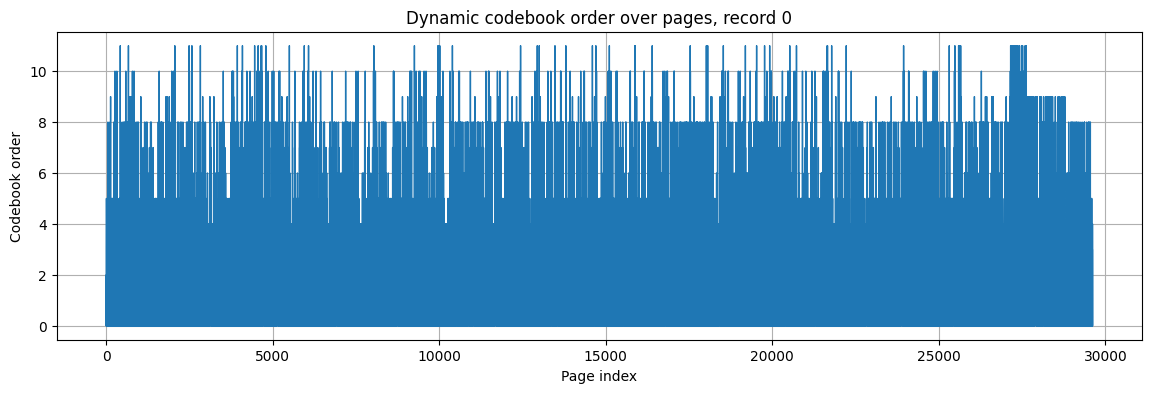

In [155]:
record_index_to_plot = 0
record_code_df = dynamic_code_ordered_df[dynamic_code_ordered_df["record_index"] == record_index_to_plot].copy()

plt.figure(figsize=(14, 4))
plt.plot(record_code_df["page_index"], record_code_df["first_occurrence_order"], linewidth=1)
plt.xlabel("Page index")
plt.ylabel("Codebook order")
plt.title(f"Dynamic codebook order over pages, record {record_index_to_plot}")
plt.grid(True)
plt.show()

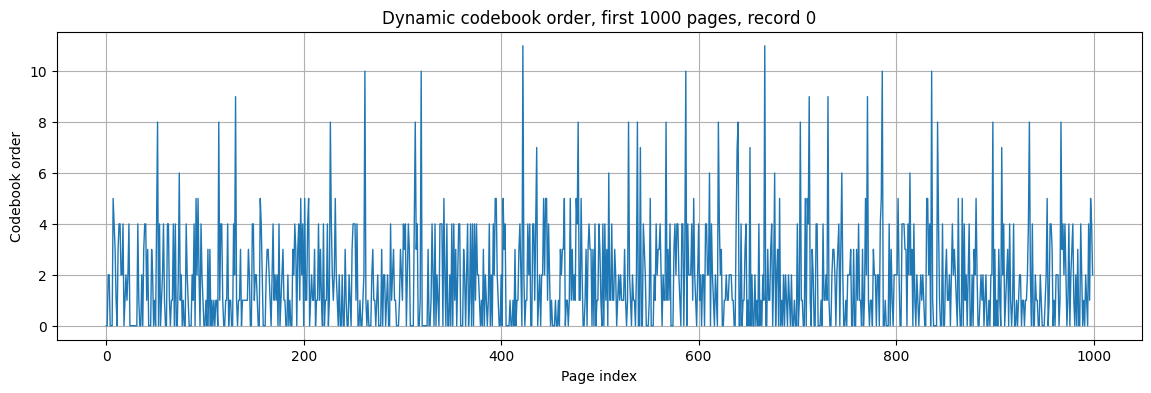

In [156]:
record_index_to_plot = 0
record_code_df = dynamic_code_ordered_df[dynamic_code_ordered_df["record_index"] == record_index_to_plot].copy()
zoom_df = record_code_df[record_code_df["page_index"] < 1000].copy()
plt.figure(figsize=(14, 4))
plt.plot(zoom_df["page_index"], zoom_df["first_occurrence_order"], linewidth=1)
plt.xlabel("Page index")
plt.ylabel("Codebook order")
plt.title(f"Dynamic codebook order, first 1000 pages, record {record_index_to_plot}")
plt.grid(True)
plt.show()

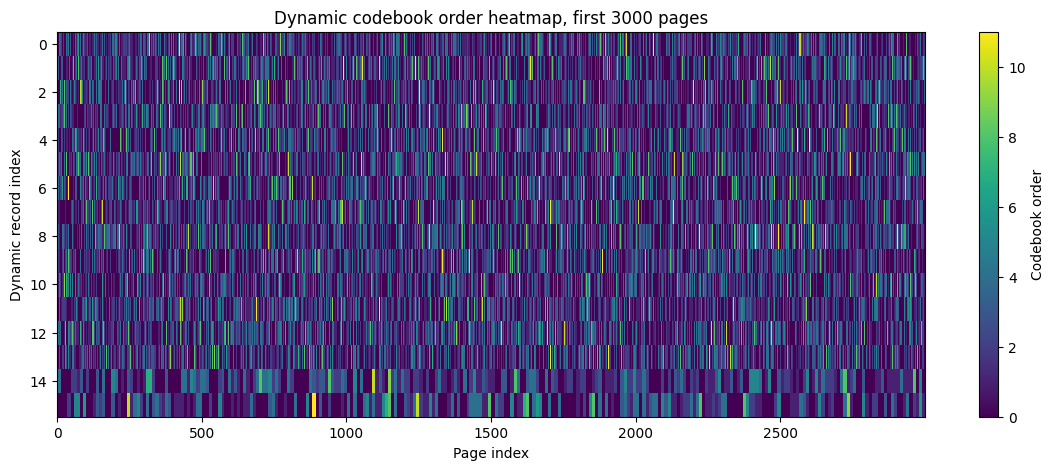

In [157]:
code_order_matrix = np.full(shape=(record_u32.shape[0], 16), fill_value=np.nan)

for record_index in range(16):
    record_df = dynamic_code_ordered_df[dynamic_code_ordered_df["record_index"] == record_index].sort_values("page_index")
    code_order_matrix[:, record_index] = record_df["first_occurrence_order"].to_numpy()

plt.figure(figsize=(14, 5))
plt.imshow(code_order_matrix[:3000].T, aspect="auto", interpolation="nearest")
plt.xlabel("Page index")
plt.ylabel("Dynamic record index")
plt.title("Dynamic codebook order heatmap, first 3000 pages")
plt.colorbar(label="Codebook order")
plt.show()

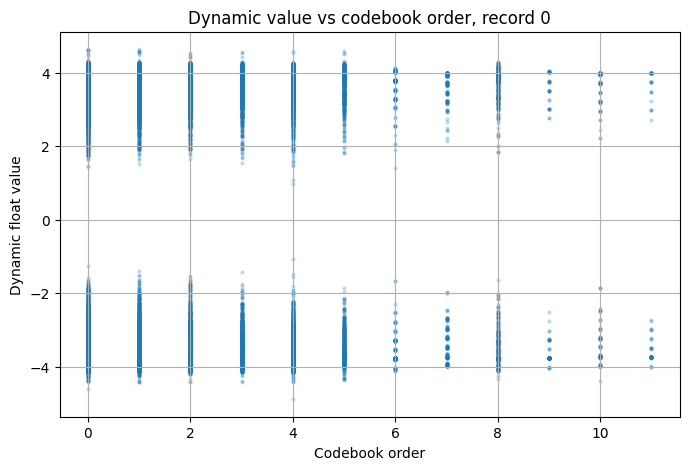

In [158]:
record_index_to_plot = 0
record_df = dynamic_code_ordered_df[dynamic_code_ordered_df["record_index"] == record_index_to_plot].copy()
plt.figure(figsize=(8, 5))
plt.scatter(record_df["first_occurrence_order"], record_df["dynamic_value"], s=4, alpha=0.2)
plt.xlabel("Codebook order")
plt.ylabel("Dynamic float value")
plt.title(f"Dynamic value vs codebook order, record {record_index_to_plot}")
plt.grid(True)
plt.show()

In [159]:
code_value_summary_df = (
    dynamic_code_ordered_df
    .groupby(["code_value", "code_hex", "first_occurrence_order"], dropna=False)
    .agg(
        n_observations=("dynamic_value", "size"),
        mean_value=("dynamic_value", "mean"),
        median_value=("dynamic_value", "median"),
        std_value=("dynamic_value", "std"),
        min_value=("dynamic_value", "min"),
        max_value=("dynamic_value", "max"),
    )
    .reset_index()
    .sort_values("first_occurrence_order")
)

code_value_summary_df.head(60)

,code_value,code_hex,first_occurrence_order,n_observations,mean_value,median_value,std_value,min_value,max_value
0,0,0x00000000,0,12193,-0.611531,-3.125000,3.509347,-4.418457,4.633301
1,110127366,0x06906906,0,11880,-0.769969,-3.188502,3.462639,-4.577687,4.704152
3,330382099,0x13B13B13,0,7969,-0.587271,-3.114333,3.478493,-4.489164,4.631254
11,1101273665,0x41A41A41,0,12116,-0.662265,-3.139899,3.499400,-4.614514,4.617078
10,991146299,0x3B13B13B,0,12169,-0.706033,-3.151592,3.484311,-4.609704,4.630578
14,1321528399,0x4EC4EC4F,0,9236,-0.653804,-3.117488,3.496651,-4.606680,4.730337
26,2532929431,0x96F96F97,0,12252,-0.744727,-3.161709,3.475087,-4.610527,4.587944
16,1541783132,0x5BE5BE5C,0,12494,-0.567645,-3.078475,3.493661,-4.611541,4.635833
29,2863311530,0xAAAAAAAA,0,10645,-0.742745,-3.172526,3.472147,-4.608846,4.615315
25,2422802064,0x90690690,0,11905,-0.771695,-3.217348,3.470366,-4.584109,4.781741


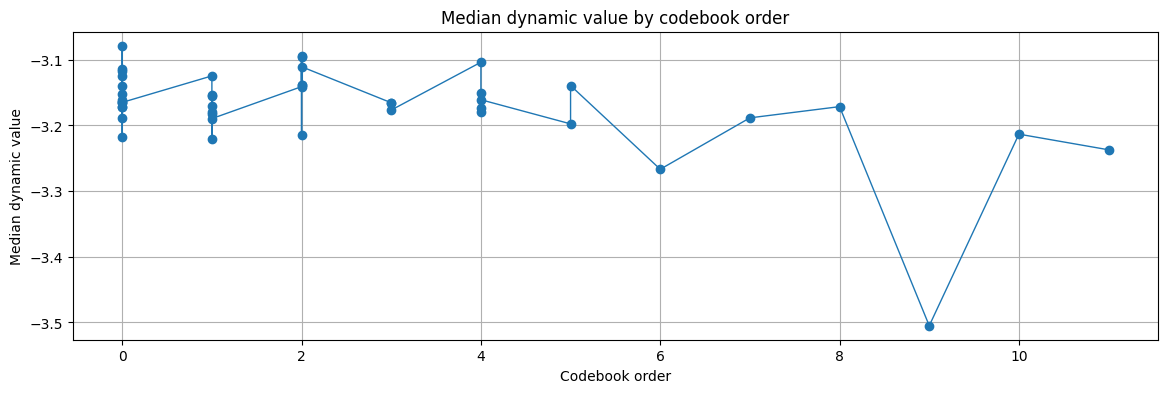

In [160]:
plt.figure(figsize=(14, 4))
plt.plot(
    code_value_summary_df["first_occurrence_order"],
    code_value_summary_df["median_value"],
    marker="o",
    linewidth=1,
)
plt.xlabel("Codebook order")
plt.ylabel("Median dynamic value")
plt.title("Median dynamic value by codebook order")
plt.grid(True)
plt.show()

## Interim finding: dynamic record codes look like fixed-point phase values

The dynamic uint32-like codes show repeated hexadecimal patterns such as:

```text
0x06906906
0x0D20D20D
0x13B13B13
0x1A41A41A
0x41A41A41
0xAAAAAAAA
0xF96F96F9

##  Candidate fixed-point phase decoding of dynamic codes

The dynamic uint32-like codes appear close to fixed-point fractional values.

This section tests whether the codes can be mapped to phase bins using a candidate denominator.

The strongest initial candidate is:

```text
denominator = 39

In [161]:
def decode_u32_codes_as_fixed_point_phase(code_values, denominator=39, uint_range=2**32):
    """
    Decode uint32-like codes as candidate fixed-point phase/bin values.

    The function interprets each code as a fraction of the uint32 range:

        phase_fraction = code / 2^32

    It then maps the fraction to a candidate phase bin:

        phase_bin_float = phase_fraction * denominator
        phase_bin_round = round(phase_bin_float)

    This is exploratory. It tests whether code values behave like fixed-point
    phase or lookup-table positions.

    Parameters
    ----------
    code_values : array-like
        Integer code values.

    denominator : int
        Candidate number of phase bins.

    uint_range : int
        Size of the uint32 range. Default is 2^32.

    Returns
    -------
    decoded_df : pandas.DataFrame
        One row per input code value with decoded phase information.
    """
    codes = np.asarray(code_values, dtype=np.uint64)

    phase_fraction = codes.astype(float) / float(uint_range)
    phase_bin_float = phase_fraction * denominator
    phase_bin_round = np.round(phase_bin_float).astype(int)

    expected_code = np.round(phase_bin_round.astype(float) * float(uint_range) / denominator).astype(np.uint64)

    residual_code = codes.astype(np.int64) - expected_code.astype(np.int64)
    residual_phase_bin = phase_bin_float - phase_bin_round

    decoded_df = pd.DataFrame(
        {
            "code_value": codes.astype(np.uint64),
            "code_hex": [f"0x{int(v):08X}" for v in codes],
            "denominator": denominator,
            "phase_fraction": phase_fraction,
            "phase_bin_float": phase_bin_float,
            "phase_bin_round": phase_bin_round,
            "expected_code": expected_code.astype(np.uint64),
            "expected_code_hex": [f"0x{int(v):08X}" for v in expected_code],
            "residual_code": residual_code,
            "residual_phase_bin": residual_phase_bin,
            "abs_residual_code": np.abs(residual_code),
        }
    )

    return decoded_df


def test_candidate_phase_denominators(code_values, denominators=range(2, 129)):
    """
    Test candidate denominators for fixed-point phase decoding.

    For each denominator, the function maps code values to nearest phase bins
    and reports residual errors.

    Parameters
    ----------
    code_values : array-like
        Unique uint32-like code values.

    denominators : iterable of int
        Candidate denominators to test.

    Returns
    -------
    denominator_test_df : pandas.DataFrame
        Summary table by denominator.
    """
    rows = []
    unique_codes = np.unique(np.asarray(code_values, dtype=np.uint64))

    for denominator in denominators:
        decoded_df = decode_u32_codes_as_fixed_point_phase(
            unique_codes,
            denominator=denominator,
        )

        rows.append(
            {
                "denominator": denominator,
                "n_codes": int(len(unique_codes)),
                "median_abs_residual_code": float(decoded_df["abs_residual_code"].median()),
                "max_abs_residual_code": float(decoded_df["abs_residual_code"].max()),
                "n_unique_phase_bins": int(decoded_df["phase_bin_round"].nunique()),
                "min_phase_bin": int(decoded_df["phase_bin_round"].min()),
                "max_phase_bin": int(decoded_df["phase_bin_round"].max()),
            }
        )

    denominator_test_df = pd.DataFrame(rows)
    denominator_test_df = denominator_test_df.sort_values(["median_abs_residual_code", "max_abs_residual_code", "denominator"]).reset_index(drop=True)

    return denominator_test_df

In [162]:
unique_dynamic_codes = np.sort(dynamic_code_long_df["code_value"].unique())

denominator_test_df = test_candidate_phase_denominators(unique_dynamic_codes, denominators=range(2, 129))
denominator_test_df.head(20)

,denominator,n_codes,median_abs_residual_code,max_abs_residual_code,n_unique_phase_bins,min_phase_bin,max_phase_bin
0,39,45,0.0,1.0,39,0,38
1,78,45,0.0,1.0,39,0,76
2,117,45,0.0,1.0,39,0,114
3,127,45,7804301.0,16475748.0,39,0,124
4,126,45,7866241.0,15732481.0,39,0,123
5,123,45,8058100.0,16116201.0,39,0,120
6,120,45,8259553.0,16519106.0,39,0,117
7,128,45,8603700.0,16347031.0,39,0,125
8,114,45,8694266.0,17388532.0,39,0,111
9,125,45,8810189.0,16739360.0,39,0,122


In [163]:
decoded_codebook_39_df = decode_u32_codes_as_fixed_point_phase(unique_dynamic_codes, denominator=39)
decoded_codebook_39_df.sort_values("phase_bin_round")

,code_value,code_hex,denominator,phase_fraction,phase_bin_float,phase_bin_round,expected_code,expected_code_hex,residual_code,residual_phase_bin,abs_residual_code
0,0,0x00000000,39,0.000000,0.0,0,0,0x00000000,0,0.000000e+00,0
1,110127366,0x06906906,39,0.025641,1.0,1,110127367,0x06906907,-1,-5.122274e-09,1
2,220254733,0x0D20D20D,39,0.051282,2.0,2,220254733,0x0D20D20D,0,-1.164153e-09,0
3,330382099,0x13B13B13,39,0.076923,3.0,3,330382100,0x13B13B14,-1,-6.286427e-09,1
4,330382100,0x13B13B14,39,0.076923,3.0,3,330382100,0x13B13B14,0,2.793968e-09,0
5,440509466,0x1A41A41A,39,0.102564,4.0,4,440509466,0x1A41A41A,0,-2.328306e-09,0
6,550636833,0x20D20D21,39,0.128205,5.0,5,550636833,0x20D20D21,0,1.629815e-09,0
7,660764199,0x27627627,39,0.153846,6.0,6,660764199,0x27627627,0,-3.492460e-09,0
8,770891566,0x2DF2DF2E,39,0.179487,7.0,7,770891566,0x2DF2DF2E,0,4.656613e-10,0
9,881018932,0x34834834,39,0.205128,8.0,8,881018933,0x34834835,-1,-4.656613e-09,1


In [164]:
phase_map_df = decoded_codebook_39_df[
    [
        "code_value",
        "phase_bin_round",
        "phase_bin_float",
        "residual_code",
        "abs_residual_code",
    ]
].copy()
dynamic_code_phase_df = dynamic_code_long_df.merge( phase_map_df, on="code_value", how="left")
dynamic_code_phase_df.head()

,page_index,record_index,code_value,dynamic_value,code_hex,phase_bin_round,phase_bin_float,residual_code,abs_residual_code
0,0,0,2532929431,-3.056240,0x96F96F97,23,23.0,0,0
1,1,0,3964585196,-3.106370,0xEC4EC4EC,36,36.0,0,0
2,2,0,4074712563,-3.064403,0xF2DF2DF3,37,37.0,0,0
3,3,0,881018932,-3.015825,0x34834834,8,8.0,-1,1
4,4,0,2753184164,-2.935196,0xA41A41A4,25,25.0,0,0


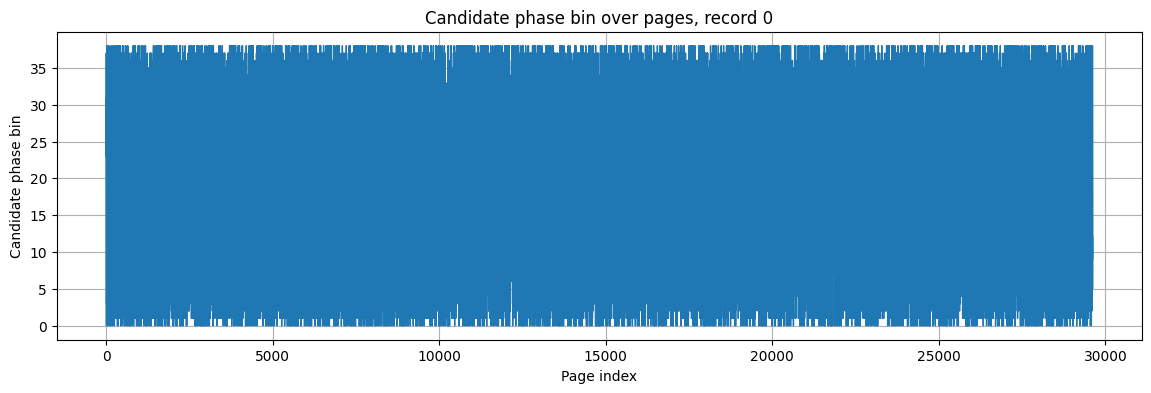

In [165]:
record_index_to_plot = 0

phase_record_df = dynamic_code_phase_df[dynamic_code_phase_df["record_index"] == record_index_to_plot].copy()
plt.figure(figsize=(14, 4))
plt.plot(
    phase_record_df["page_index"],
    phase_record_df["phase_bin_round"],
    linewidth=1,
)
plt.xlabel("Page index")
plt.ylabel("Candidate phase bin")
plt.title(f"Candidate phase bin over pages, record {record_index_to_plot}")
plt.grid(True)
plt.show()

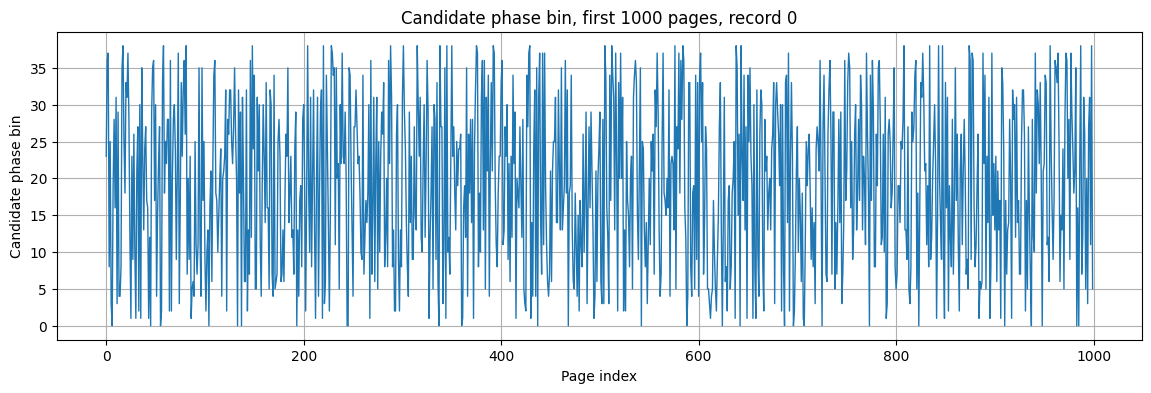

In [166]:
zoom_df = phase_record_df[phase_record_df["page_index"] < 1000].copy()
plt.figure(figsize=(14, 4))
plt.plot(
    zoom_df["page_index"],
    zoom_df["phase_bin_round"],
    linewidth=1,
)
plt.xlabel("Page index")
plt.ylabel("Candidate phase bin")
plt.title(f"Candidate phase bin, first 1000 pages, record {record_index_to_plot}")
plt.grid(True)
plt.show()

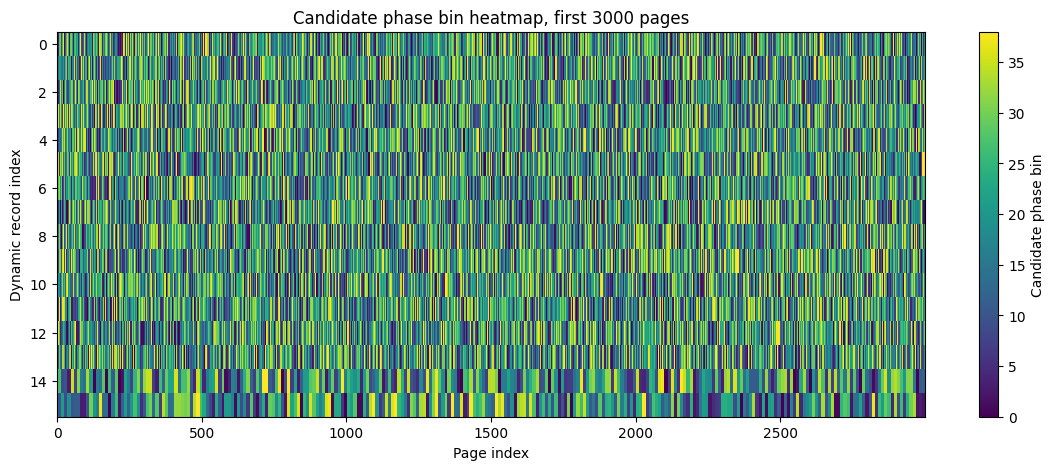

In [167]:
phase_bin_matrix = np.full(shape=(record_u32.shape[0], 16), fill_value=np.nan,)

for record_index in range(16):
    record_df = dynamic_code_phase_df[
        dynamic_code_phase_df["record_index"] == record_index
    ].sort_values("page_index")

    phase_bin_matrix[:, record_index] = record_df["phase_bin_round"].to_numpy()

plt.figure(figsize=(14, 5))
plt.imshow(
    phase_bin_matrix[:3000].T,
    aspect="auto",
    interpolation="nearest",
)
plt.xlabel("Page index")
plt.ylabel("Dynamic record index")
plt.title("Candidate phase bin heatmap, first 3000 pages")
plt.colorbar(label="Candidate phase bin")
plt.show()

## Interim finding: dynamic code field is Q32 fixed-point phase/bin data

The dynamic uint32-like code field was tested as fixed-point phase data.

The best minimal denominator is:

```text
39

## Dynamic value distribution by decoded phase bin

The dynamic code field is now interpreted as a candidate Q32 fixed-point phase/bin value with 39 bins.

This section analyzes whether the decoded phase bin explains the dynamic float value.

The goal is to check:

- whether different phase bins have different value distributions,
- whether even and odd dynamic record families use phase bins differently,
- whether positive and negative dynamic states are associated with specific bins,
- whether phase-bin transitions show a structured pattern.

This section remains exploratory.

In [168]:
def summarize_dynamic_values_by_phase_bin(dynamic_code_phase_df):
    """
    Summarize dynamic float values by decoded phase bin.

    The function groups dynamic values by phase bin and by even/odd record family.

    Parameters
    ----------
    dynamic_code_phase_df : pandas.DataFrame
        Dynamic code table with decoded phase-bin columns.

    Returns
    -------
    phase_bin_summary_df : pandas.DataFrame
        One row per phase bin.

    phase_bin_family_summary_df : pandas.DataFrame
        One row per phase bin and record family.
    """
    df = dynamic_code_phase_df.copy()
    df["record_family"] = np.where(df["record_index"] % 2 == 0, "even", "odd")
    df["is_positive_state"] = df["dynamic_value"] > 0
    df["is_negative_state"] = df["dynamic_value"] < 0

    phase_bin_summary_df = (
        df
        .groupby("phase_bin_round", dropna=False)
        .agg(
            n_observations=("dynamic_value", "size"),
            n_record_positions=("record_index", "nunique"),
            n_code_values=("code_value", "nunique"),
            mean_value=("dynamic_value", "mean"),
            median_value=("dynamic_value", "median"),
            std_value=("dynamic_value", "std"),
            min_value=("dynamic_value", "min"),
            max_value=("dynamic_value", "max"),
            positive_fraction=("is_positive_state", "mean"),
            negative_fraction=("is_negative_state", "mean"),
        )
        .reset_index()
        .sort_values("phase_bin_round")
    )

    phase_bin_family_summary_df = (
        df
        .groupby(["record_family", "phase_bin_round"], dropna=False)
        .agg(
            n_observations=("dynamic_value", "size"),
            n_record_positions=("record_index", "nunique"),
            mean_value=("dynamic_value", "mean"),
            median_value=("dynamic_value", "median"),
            std_value=("dynamic_value", "std"),
            positive_fraction=("is_positive_state", "mean"),
        )
        .reset_index()
        .sort_values(["record_family", "phase_bin_round"])
    )

    return phase_bin_summary_df, phase_bin_family_summary_df


def build_phase_transition_table(dynamic_code_phase_df, record_index=0):
    """
    Build a transition table between consecutive phase bins for one record index.

    This checks whether phase bins follow a structured transition pattern over pages.

    Parameters
    ----------
    dynamic_code_phase_df : pandas.DataFrame
        Dynamic code table with decoded phase-bin columns.

    record_index : int
        Dynamic record index to analyze.

    Returns
    -------
    transition_df : pandas.DataFrame
        One row per observed transition.

    transition_summary_df : pandas.DataFrame
        Frequency summary of transitions.
    """
    record_df = (
        dynamic_code_phase_df[
            dynamic_code_phase_df["record_index"] == record_index
        ]
        .sort_values("page_index")
        .copy()
    )

    phase_bins = record_df["phase_bin_round"].to_numpy()
    previous_bins = phase_bins[:-1]
    next_bins = phase_bins[1:]
    transition_df = pd.DataFrame(
        {
            "previous_phase_bin": previous_bins,
            "next_phase_bin": next_bins,
        }
    )

    transition_df["delta_phase_bin"] = (
        transition_df["next_phase_bin"] - transition_df["previous_phase_bin"]
    )

    transition_summary_df = (
        transition_df
        .groupby(["previous_phase_bin", "next_phase_bin", "delta_phase_bin"], dropna=False)
        .agg(
            count=("delta_phase_bin", "size"),
        )
        .reset_index()
        .sort_values("count", ascending=False)
    )

    transition_summary_df["fraction"] = (
        transition_summary_df["count"] / len(transition_df)
    )

    return transition_df, transition_summary_df

In [169]:
phase_bin_summary_df, phase_bin_family_summary_df = summarize_dynamic_values_by_phase_bin(dynamic_code_phase_df)
phase_bin_summary_df

,phase_bin_round,n_observations,n_record_positions,n_code_values,mean_value,median_value,std_value,min_value,max_value,positive_fraction,negative_fraction
0,0,12193,16,1,-0.611531,-3.125000,3.509347,-4.418457,4.633301,0.409169,0.590749
1,1,11880,16,1,-0.769969,-3.188502,3.462639,-4.577687,4.704152,0.387290,0.612710
2,2,12475,16,1,-0.771410,-3.189503,3.467903,-4.605935,4.625466,0.385972,0.614028
3,3,12109,16,2,-0.669593,-3.139724,3.485760,-4.600858,4.631254,0.400941,0.599059
4,4,12157,16,1,-0.583988,-3.103616,3.496092,-4.877642,4.585283,0.413095,0.586905
5,5,12284,16,1,-0.624583,-3.110477,3.496988,-4.981574,4.606452,0.408662,0.591338
6,6,12307,16,1,-0.697907,-3.170072,3.492076,-4.610774,4.595149,0.397091,0.602909
7,7,12075,16,1,-0.756660,-3.214042,3.473429,-4.596542,4.576156,0.389151,0.610849
8,8,12258,16,1,-0.687281,-3.140825,3.488468,-4.611729,4.868809,0.399331,0.600669
9,9,12169,16,1,-0.706033,-3.151592,3.484311,-4.609704,4.630578,0.396828,0.603172


In [170]:
phase_bin_family_summary_df.head(80)

,record_family,phase_bin_round,n_observations,n_record_positions,mean_value,median_value,std_value,positive_fraction
0,even,0,6135,8,0.180135,2.507812,3.567007,0.516218
1,even,1,5945,8,-0.080462,-2.446314,3.547809,0.479226
2,even,2,6236,8,0.025139,-2.111378,3.561046,0.491661
3,even,3,6066,8,0.075088,1.216346,3.566687,0.500330
4,even,4,6007,8,0.189414,2.519631,3.559513,0.518895
...,...,...,...,...,...,...,...,...
73,odd,34,5996,8,-1.485463,-3.390500,3.220548,0.290861
74,odd,35,6081,8,-1.420228,-3.365134,3.236699,0.300280
75,odd,36,6090,8,-1.411882,-3.366136,3.249340,0.301970
76,odd,37,6087,8,-1.468416,-3.363231,3.209136,0.293412


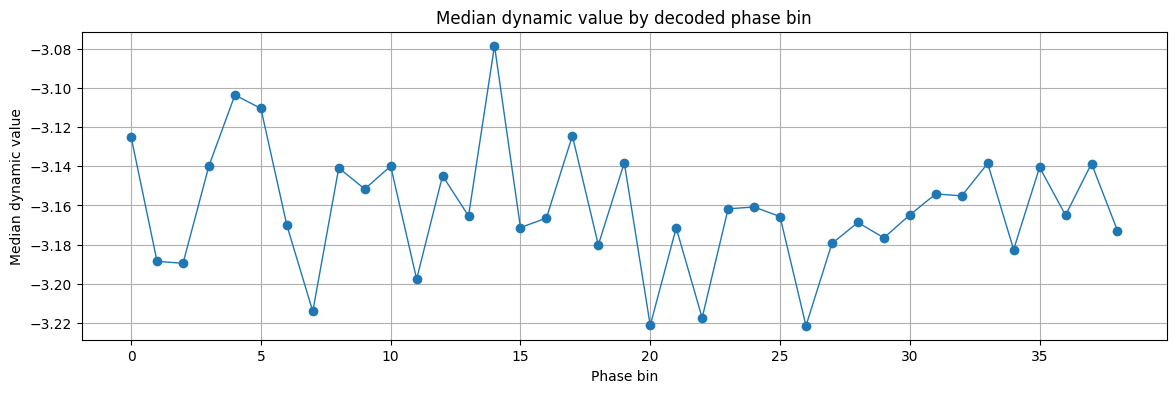

In [171]:
plt.figure(figsize=(14, 4))
plt.plot(
    phase_bin_summary_df["phase_bin_round"],
    phase_bin_summary_df["median_value"],
    marker="o",
    linewidth=1,
)
plt.xlabel("Phase bin")
plt.ylabel("Median dynamic value")
plt.title("Median dynamic value by decoded phase bin")
plt.grid(True)
plt.show()

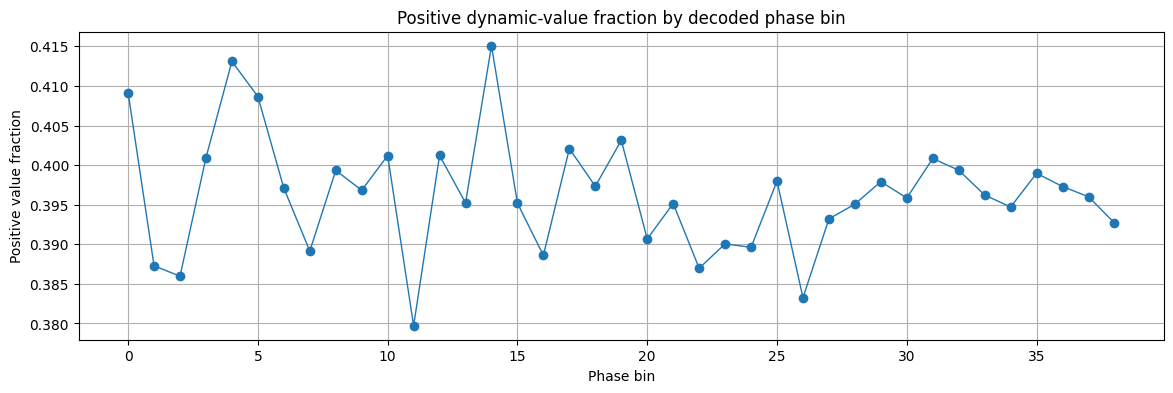

In [174]:
plt.figure(figsize=(14, 4))
plt.plot(
    phase_bin_summary_df["phase_bin_round"],
    phase_bin_summary_df["positive_fraction"],
    marker="o",
    linewidth=1,
)
plt.xlabel("Phase bin")
plt.ylabel("Positive value fraction")
plt.title("Positive dynamic-value fraction by decoded phase bin")
plt.grid(True)
plt.show()

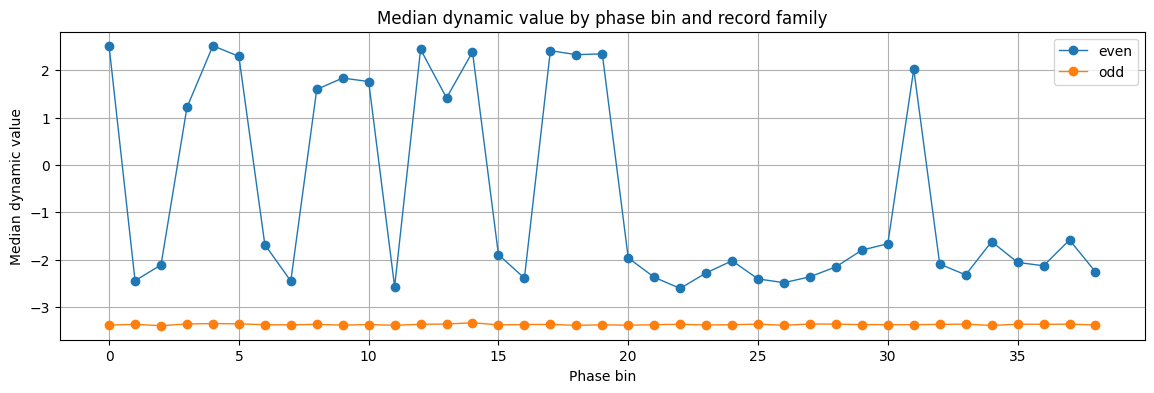

In [173]:
plt.figure(figsize=(14, 4))
for family_name, group_df in phase_bin_family_summary_df.groupby("record_family"):
    plt.plot(
        group_df["phase_bin_round"],
        group_df["median_value"],
        marker="o",
        linewidth=1,
        label=family_name,
    )
plt.xlabel("Phase bin")
plt.ylabel("Median dynamic value")
plt.title("Median dynamic value by phase bin and record family")
plt.grid(True)
plt.legend()
plt.show()

In [175]:
phase_transition_df, phase_transition_summary_df = build_phase_transition_table(dynamic_code_phase_df, record_index=0)

phase_transition_summary_df.head(30)

,previous_phase_bin,next_phase_bin,delta_phase_bin,count,fraction
200,5,5,0,36,0.001216
1063,27,10,-17,35,0.001182
822,21,3,-18,33,0.001114
1193,30,23,-7,33,0.001114
360,9,9,0,32,0.001081
1160,29,29,0,32,0.001081
864,22,6,-16,32,0.001081
1187,30,17,-13,32,0.001081
332,8,20,12,32,0.001081
924,23,27,4,31,0.001047


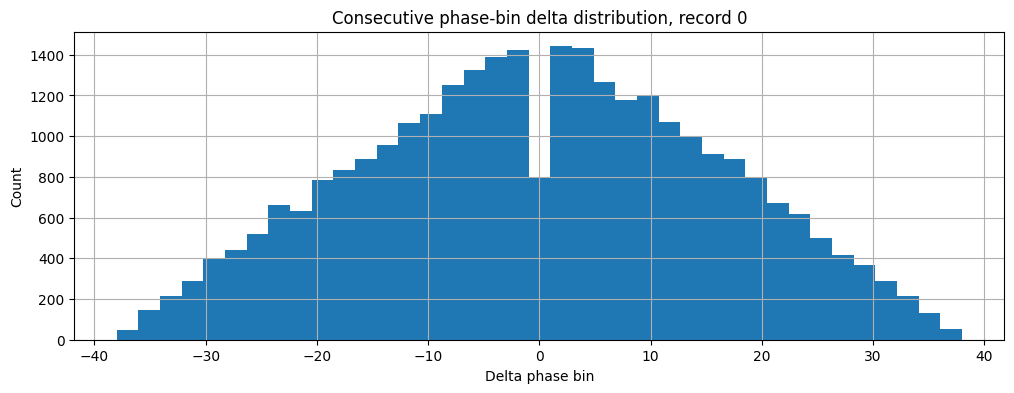

In [176]:
plt.figure(figsize=(12, 4))
plt.hist(phase_transition_df["delta_phase_bin"], bins=39)
plt.xlabel("Delta phase bin")
plt.ylabel("Count")
plt.title("Consecutive phase-bin delta distribution, record 0")
plt.grid(True)
plt.show()

## Interim finding: decoded phase bins mainly explain even-family dynamic structure

Decoded dynamic code values map almost perfectly to 39 Q32 fixed-point phase bins.

When dynamic values are summarized by phase bin across all records, the median remains mostly negative because even and odd dynamic record families are mixed together.

Separating record families reveals a stronger pattern:

- odd-family records have relatively stable negative median values across phase bins,
- even-family records vary strongly with phase bin and switch between positive and negative median states.

This suggests that the decoded phase bin is meaningful, but its relationship to the dynamic float value is family-dependent.

The phase-bin sequence does not behave like a simple monotonic counter.  
Consecutive phase-bin transitions are broadly distributed and no single transition dominates.

The current working interpretation is:

```text
The Q32 phase/bin field is likely an internal coordinate, state, or lookup-table input.
It is especially informative for even-family dynamic records.
Odd-family records may represent a paired reference, baseline, lower state, or complementary component.

In [177]:
def summarize_phase_bin_family_state_structure(dynamic_code_phase_df):
    """
    Summarize positive/negative state structure by phase bin and record family.

    The function focuses on the relationship between decoded phase bins,
    even/odd dynamic record families, and dynamic value sign.

    Parameters
    ----------
    dynamic_code_phase_df : pandas.DataFrame
        Dynamic code table with decoded phase-bin columns.

    Returns
    -------
    family_state_summary_df : pandas.DataFrame
        One row per record family and phase bin.

    record_phase_summary_df : pandas.DataFrame
        One row per record index and phase bin.
    """
    df = dynamic_code_phase_df.copy()
    df["record_family"] = np.where(df["record_index"] % 2 == 0,"even", "odd")
    df["is_positive_state"] = df["dynamic_value"] > 0
    df["is_negative_state"] = df["dynamic_value"] < 0
    df["abs_dynamic_value"] = np.abs(df["dynamic_value"])

    family_state_summary_df = (
        df
        .groupby(["record_family", "phase_bin_round"], dropna=False)
        .agg(
            n_observations=("dynamic_value", "size"),
            n_record_positions=("record_index", "nunique"),
            mean_value=("dynamic_value", "mean"),
            median_value=("dynamic_value", "median"),
            std_value=("dynamic_value", "std"),
            min_value=("dynamic_value", "min"),
            max_value=("dynamic_value", "max"),
            positive_fraction=("is_positive_state", "mean"),
            negative_fraction=("is_negative_state", "mean"),
            median_abs_value=("abs_dynamic_value", "median"),
        )
        .reset_index()
        .sort_values(["record_family", "phase_bin_round"])
    )

    record_phase_summary_df = (
        df
        .groupby(["record_index", "phase_bin_round"], dropna=False)
        .agg(
            n_observations=("dynamic_value", "size"),
            mean_value=("dynamic_value", "mean"),
            median_value=("dynamic_value", "median"),
            std_value=("dynamic_value", "std"),
            positive_fraction=("is_positive_state", "mean"),
            median_abs_value=("abs_dynamic_value", "median"),
        )
        .reset_index()
        .sort_values(["record_index", "phase_bin_round"])
    )

    return family_state_summary_df, record_phase_summary_df

In [178]:
family_state_summary_df, record_phase_summary_df = summarize_phase_bin_family_state_structure(dynamic_code_phase_df)
family_state_summary_df

,record_family,phase_bin_round,n_observations,n_record_positions,mean_value,median_value,std_value,min_value,max_value,positive_fraction,negative_fraction,median_abs_value
0,even,0,6135,8,0.180135,2.507812,3.567007,-4.418457,4.633301,0.516218,0.483782,3.696777
1,even,1,5945,8,-0.080462,-2.446314,3.547809,-4.405812,4.632008,0.479226,0.520774,3.675318
2,even,2,6236,8,0.025139,-2.111378,3.561046,-4.414163,4.625466,0.491661,0.508339,3.675343
3,even,3,6066,8,0.075088,1.216346,3.566687,-4.390531,4.631254,0.500330,0.499670,3.683181
4,even,4,6007,8,0.189414,2.519631,3.559513,-4.877642,4.585283,0.518895,0.481105,3.682229
...,...,...,...,...,...,...,...,...,...,...,...,...
73,odd,34,5996,8,-1.485463,-3.390500,3.220548,-4.689202,4.479486,0.290861,0.709139,3.550168
74,odd,35,6081,8,-1.420228,-3.365134,3.236699,-4.503339,4.526289,0.300280,0.699720,3.538474
75,odd,36,6090,8,-1.411882,-3.366136,3.249340,-4.611666,4.476656,0.301970,0.698030,3.555100
76,odd,37,6087,8,-1.468416,-3.363231,3.209136,-4.788107,4.459372,0.293412,0.706588,3.536083


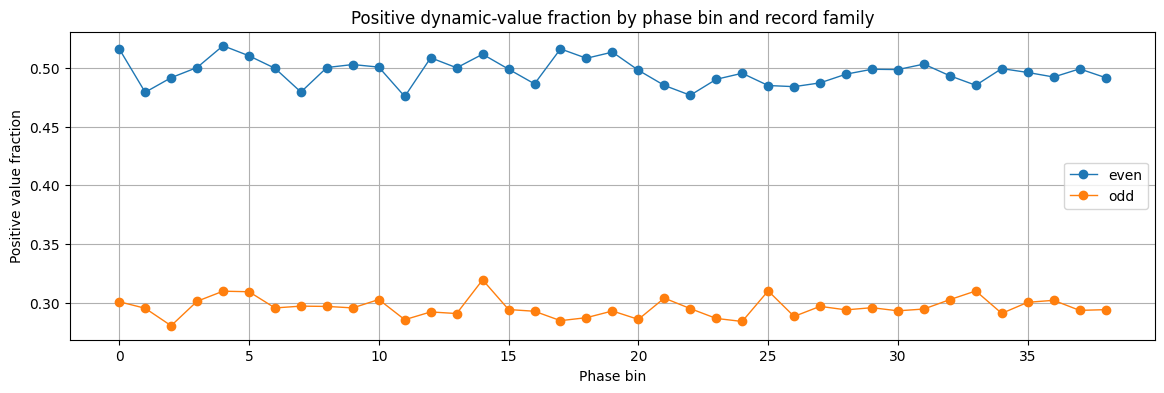

In [179]:
plt.figure(figsize=(14, 4))
for family_name, group_df in family_state_summary_df.groupby("record_family"):
    plt.plot(group_df["phase_bin_round"], group_df["positive_fraction"], marker="o", linewidth=1, label=family_name)
plt.xlabel("Phase bin")
plt.ylabel("Positive value fraction")
plt.title("Positive dynamic-value fraction by phase bin and record family")
plt.grid(True)
plt.legend()
plt.show()

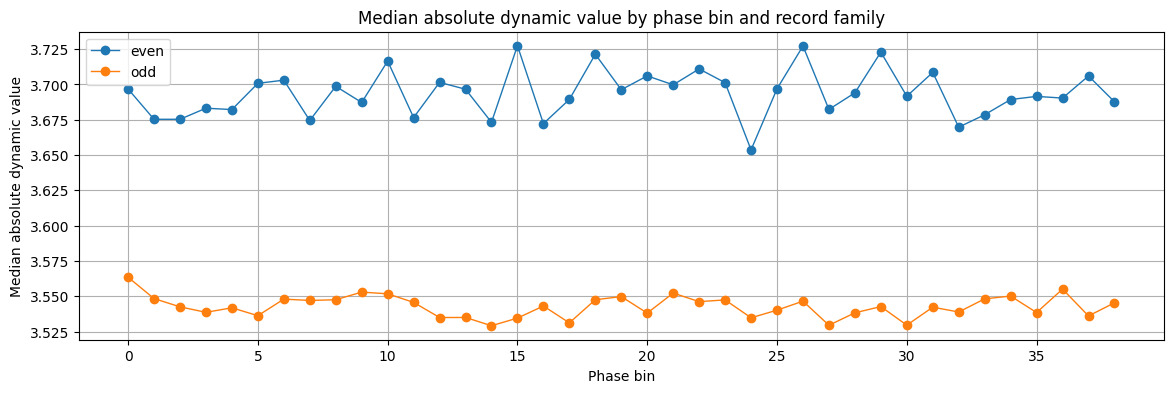

In [180]:
plt.figure(figsize=(14, 4))
for family_name, group_df in family_state_summary_df.groupby("record_family"):
    plt.plot(group_df["phase_bin_round"], group_df["median_abs_value"], marker="o", linewidth=1, label=family_name)
plt.xlabel("Phase bin")
plt.ylabel("Median absolute dynamic value")
plt.title("Median absolute dynamic value by phase bin and record family")
plt.grid(True)
plt.legend()
plt.show()

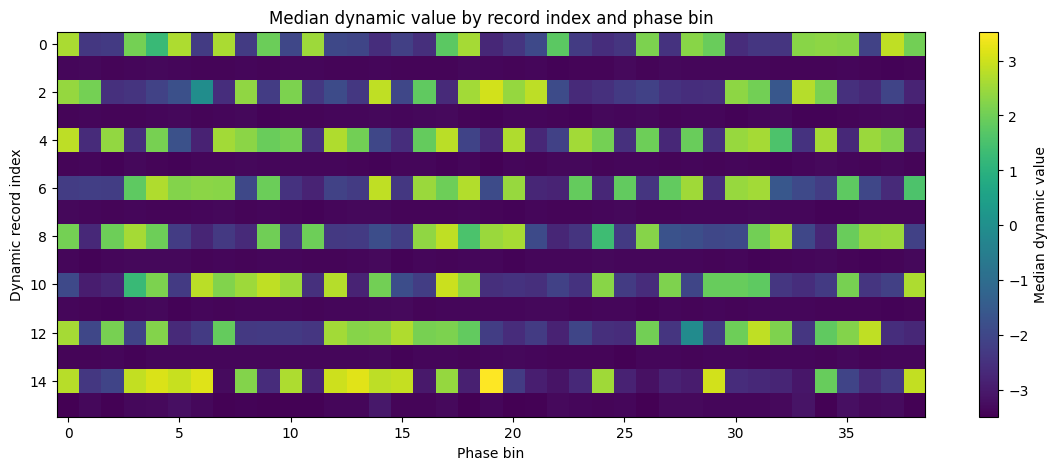

In [181]:
record_phase_matrix = (record_phase_summary_df.pivot_table(index="record_index", columns="phase_bin_round", values="median_value", aggfunc="first"))
plt.figure(figsize=(14, 5))
plt.imshow(record_phase_matrix, aspect="auto", interpolation="nearest")
plt.xlabel("Phase bin")
plt.ylabel("Dynamic record index")
plt.title("Median dynamic value by record index and phase bin")
plt.colorbar(label="Median dynamic value")
plt.show()

## Interim finding: dynamic records behave as 8 even/odd pairs

Decoded phase-bin analysis shows a strong difference between even and odd dynamic record families.

Even-indexed records have:

- positive-value fraction close to 0.5,
- stronger phase-dependent median-value variation,
- slightly higher absolute dynamic value.

Odd-indexed records have:

- positive-value fraction around 0.28–0.32,
- consistently negative median values,
- lower absolute dynamic value.

The record-index × phase-bin heatmap shows that even and odd records form a repeated alternating structure.

The current working interpretation is:

```text
The 16 dynamic records likely represent 8 paired dynamic structures.

Within each pair:
    even record = phase-dependent active component
    odd record  = mostly negative paired/reference component

## Dynamic even/odd pair structure

The previous section showed that the 16 dynamic records behave as 8 alternating even/odd pairs.

This section reorganizes the dynamic block into pairs:

```text
pair 0 = record 0 + record 1
pair 1 = record 2 + record 3
...
pair 7 = record 14 + record 15

In [182]:
def build_dynamic_pair_matrix(record_f32, n_dynamic_records=16):
    """
    Reorganize dynamic float records into even/odd pairs.

    The first 16 dynamic records are interpreted as 8 pairs:

        pair 0 = record 0 and record 1
        pair 1 = record 2 and record 3
        ...
        pair 7 = record 14 and record 15

    For each pair, the function computes midpoint and range-like features.

    Parameters
    ----------
    record_f32 : numpy.ndarray
        Candidate float32 value matrix with shape `(n_pages, n_records)`.

    n_dynamic_records : int
        Number of leading dynamic records. Expected to be 16.

    Returns
    -------
    pair_feature_df : pandas.DataFrame
        One row per page with pair-level features.

    pair_long_df : pandas.DataFrame
        Long table with one row per page and pair index.
    """
    if n_dynamic_records % 2 != 0:
        raise ValueError("n_dynamic_records must be even.")

    if record_f32.shape[1] < n_dynamic_records:
        raise ValueError("record_f32 does not contain enough dynamic records.")

    n_pages = record_f32.shape[0]
    n_pairs = n_dynamic_records // 2

    rows = []
    feature_dict = {"page_index": np.arange(n_pages)}

    for pair_index in range(n_pairs):
        even_record_index = pair_index * 2
        odd_record_index = even_record_index + 1

        even_value = record_f32[:, even_record_index].astype(float)
        odd_value = record_f32[:, odd_record_index].astype(float)

        pair_midpoint = (even_value + odd_value) / 2.0
        pair_range = even_value - odd_value
        pair_abs_range = np.abs(pair_range)
        pair_min = np.minimum(even_value, odd_value)
        pair_max = np.maximum(even_value, odd_value)

        feature_dict[f"pair_{pair_index:02d}_even_value"] = even_value
        feature_dict[f"pair_{pair_index:02d}_odd_value"] = odd_value
        feature_dict[f"pair_{pair_index:02d}_midpoint"] = pair_midpoint
        feature_dict[f"pair_{pair_index:02d}_range"] = pair_range
        feature_dict[f"pair_{pair_index:02d}_abs_range"] = pair_abs_range
        feature_dict[f"pair_{pair_index:02d}_min"] = pair_min
        feature_dict[f"pair_{pair_index:02d}_max"] = pair_max

        pair_rows = pd.DataFrame(
            {
                "page_index": np.arange(n_pages),
                "pair_index": pair_index,
                "even_record_index": even_record_index,
                "odd_record_index": odd_record_index,
                "even_value": even_value,
                "odd_value": odd_value,
                "midpoint": pair_midpoint,
                "range": pair_range,
                "abs_range": pair_abs_range,
                "min_value": pair_min,
                "max_value": pair_max,
            }
        )

        rows.append(pair_rows)

    pair_feature_df = pd.DataFrame(feature_dict)
    pair_long_df = pd.concat(rows, ignore_index=True)
    return pair_feature_df, pair_long_df


def summarize_dynamic_pair_features(pair_long_df):
    """
    Summarize pair-level dynamic features.

    Parameters
    ----------
    pair_long_df : pandas.DataFrame
        Long pair table from build_dynamic_pair_matrix().

    Returns
    -------
    pair_summary_df : pandas.DataFrame
        One row per pair index.
    """
    pair_summary_df = (
        pair_long_df
        .groupby("pair_index", dropna=False)
        .agg(
            n_pages=("page_index", "size"),
            even_median=("even_value", "median"),
            odd_median=("odd_value", "median"),
            midpoint_median=("midpoint", "median"),
            range_median=("range", "median"),
            abs_range_median=("abs_range", "median"),
            min_median=("min_value", "median"),
            max_median=("max_value", "median"),
            even_positive_fraction=("even_value", lambda x: (x > 0).mean()),
            odd_positive_fraction=("odd_value", lambda x: (x > 0).mean()),
            range_positive_fraction=("range", lambda x: (x > 0).mean()),
        )
        .reset_index()
    )

    return pair_summary_df

In [183]:
pair_feature_df, pair_long_df = build_dynamic_pair_matrix(record_f32=record_f32, n_dynamic_records=16)
pair_summary_df = summarize_dynamic_pair_features(pair_long_df)
pair_feature_df.shape, pair_long_df.shape

((29615, 57), (236920, 11))

In [184]:
pair_summary_df

,pair_index,n_pages,even_median,odd_median,midpoint_median,range_median,abs_range_median,min_median,max_median,even_positive_fraction,odd_positive_fraction,range_positive_fraction
0,0,29615,-1.913461,-3.371820,-0.210587,0.240435,0.564754,-3.567570,3.079026,0.497180,0.295864,0.611650
1,1,29615,-1.915865,-3.371745,-0.210011,0.238870,0.563414,-3.567721,3.078275,0.497282,0.296100,0.611582
2,2,29615,-1.901442,-3.372195,-0.208750,0.239765,0.563401,-3.567082,3.076122,0.497721,0.295897,0.611514
3,3,29615,-1.904647,-3.372746,-0.208408,0.239884,0.563771,-3.568071,3.078826,0.497147,0.295864,0.611650
4,4,29615,-1.922276,-3.372646,-0.208493,0.239709,0.562750,-3.567821,3.080328,0.497012,0.296032,0.611413
5,5,29615,-1.915064,-3.371770,-0.208725,0.240985,0.564090,-3.567733,3.078225,0.497180,0.295897,0.611447
6,6,29615,-1.936699,-3.371970,-0.209275,0.241561,0.566175,-3.567483,3.076322,0.497079,0.295729,0.612257
7,7,29615,-2.098557,-3.369366,-0.204865,0.245543,0.581881,-3.570024,3.077624,0.493466,0.296742,0.610974


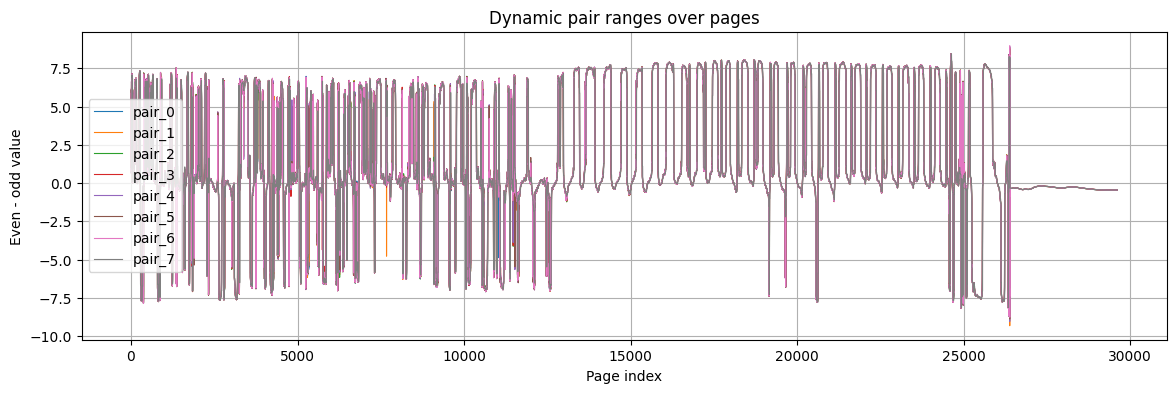

In [185]:
plt.figure(figsize=(14, 4))
for pair_index in range(8):
    plt.plot(
        pair_feature_df["page_index"],
        pair_feature_df[f"pair_{pair_index:02d}_range"],
        linewidth=0.8,
        label=f"pair_{pair_index}",
    )
plt.xlabel("Page index")
plt.ylabel("Even - odd value")
plt.title("Dynamic pair ranges over pages")
plt.grid(True)
plt.legend()
plt.show()

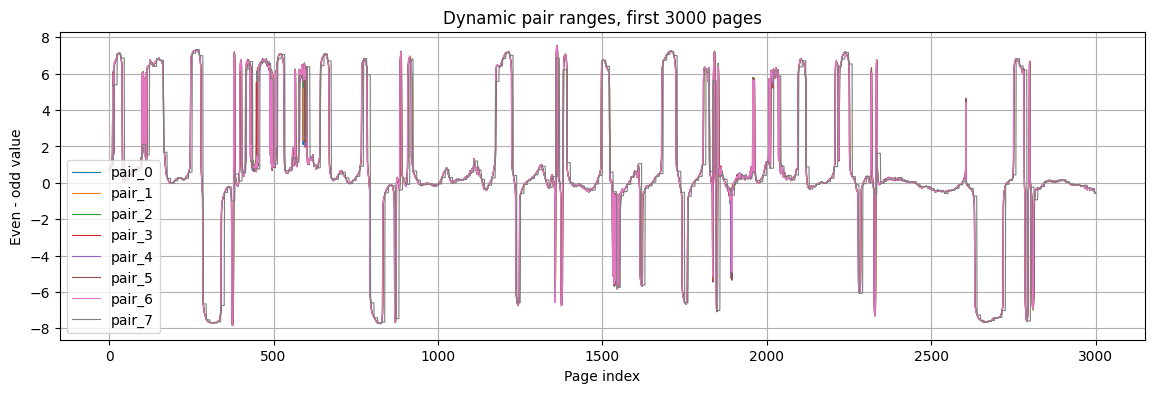

In [186]:
plt.figure(figsize=(14, 4))
for pair_index in range(8):
    mask = pair_feature_df["page_index"] < 3000
    plt.plot(
        pair_feature_df.loc[mask, "page_index"],
        pair_feature_df.loc[mask, f"pair_{pair_index:02d}_range"],
        linewidth=0.8,
        label=f"pair_{pair_index}",
    )
plt.xlabel("Page index")
plt.ylabel("Even - odd value")
plt.title("Dynamic pair ranges, first 3000 pages")
plt.grid(True)
plt.legend()
plt.show()

In [187]:
pair_range_columns = [f"pair_{pair_index:02d}_range" for pair_index in range(8)]
pair_range_corr_df = pair_feature_df[pair_range_columns].corr()
pair_range_corr_df

,pair_00_range,pair_01_range,pair_02_range,pair_03_range,pair_04_range,pair_05_range,pair_06_range,pair_07_range
pair_00_range,1.000000,0.994106,0.989354,0.986041,0.983278,0.980399,0.977853,0.928180
pair_01_range,0.994106,1.000000,0.994491,0.988645,0.986442,0.983216,0.980603,0.924846
pair_02_range,0.989354,0.994491,1.000000,0.994062,0.989131,0.985771,0.983179,0.924163
pair_03_range,0.986041,0.988645,0.994062,1.000000,0.993896,0.988722,0.986125,0.921946
pair_04_range,0.983278,0.986442,0.989131,0.993896,1.000000,0.994616,0.989259,0.919984
pair_05_range,0.980399,0.983216,0.985771,0.988722,0.994616,1.000000,0.993968,0.918228
pair_06_range,0.977853,0.980603,0.983179,0.986125,0.989259,0.993968,1.000000,0.917652
pair_07_range,0.928180,0.924846,0.924163,0.921946,0.919984,0.918228,0.917652,1.000000


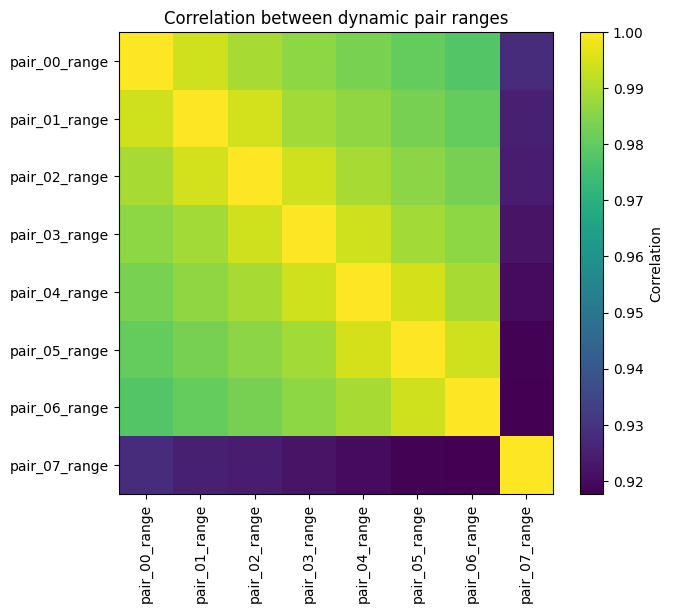

In [188]:
plt.figure(figsize=(7, 6))
plt.imshow(pair_range_corr_df, aspect="auto", interpolation="nearest")
plt.xticks(range(len(pair_range_columns)), pair_range_columns, rotation=90)
plt.yticks(range(len(pair_range_columns)), pair_range_columns)
plt.colorbar(label="Correlation")
plt.title("Correlation between dynamic pair ranges")
plt.show()

## Interim finding: pair ranges reveal a shared native PW dynamic signal

The 16 dynamic records were reorganized into 8 even/odd pairs.

For each pair, the range was computed as:

```text
pair_range = even_value - odd_value

##  Reduced pair-range native PW signal

The previous section showed that pair-range signals are highly correlated across dynamic pairs.

This section reduces the 8 pair ranges into one candidate native PW dynamic signal.

Two reduced signals are computed:

```text
pair_range_mean_0_6
pair_range_mean_0_7

In [189]:
def build_reduced_pair_range_signals(pair_feature_df):
    """
    Build reduced native PW dynamic signals from pair ranges.

    The function computes mean and standard deviation across dynamic pair ranges.

    Pair 7 is summarized separately because earlier correlation analysis showed
    that it is slightly less similar to pairs 0-6.

    Parameters
    ----------
    pair_feature_df : pandas.DataFrame
        Pair-level feature table produced by build_dynamic_pair_matrix().

    Returns
    -------
    reduced_pair_df : pandas.DataFrame
        One row per page with reduced pair-range signals.
    """
    output_df = pd.DataFrame({"page_index": pair_feature_df["page_index"].to_numpy()})
    pair_range_columns_0_6 = [f"pair_{pair_index:02d}_range" for pair_index in range(7)]
    pair_range_columns_0_7 = [f"pair_{pair_index:02d}_range" for pair_index in range(8)]

    output_df["pair_range_mean_0_6"] = (pair_feature_df[pair_range_columns_0_6].mean(axis=1))
    output_df["pair_range_std_0_6"] = (pair_feature_df[pair_range_columns_0_6].std(axis=1))
    output_df["pair_range_mean_0_7"] = (pair_feature_df[pair_range_columns_0_7].mean(axis=1))
    output_df["pair_range_std_0_7"] = (pair_feature_df[pair_range_columns_0_7].std(axis=1))
    output_df["pair_07_range"] = pair_feature_df["pair_07_range"].to_numpy()

    return output_df


def summarize_reduced_pair_range_signals(reduced_pair_df):
    """
    Summarize reduced pair-range native PW signals.

    Parameters
    ----------
    reduced_pair_df : pandas.DataFrame
        Reduced pair-range signal table.

    Returns
    -------
    reduced_pair_summary_df : pandas.DataFrame
        Summary table for reduced pair-range columns.
    """
    signal_columns = [
        "pair_range_mean_0_6",
        "pair_range_std_0_6",
        "pair_range_mean_0_7",
        "pair_range_std_0_7",
        "pair_07_range",
    ]

    rows = []
    for column in signal_columns:
        values = reduced_pair_df[column].to_numpy(dtype=float)

        rows.append(
            {
                "signal_name": column,
                "n_finite": int(np.isfinite(values).sum()),
                "min_value": float(np.nanmin(values)),
                "max_value": float(np.nanmax(values)),
                "mean_value": float(np.nanmean(values)),
                "std_value": float(np.nanstd(values)),
                "median_value": float(np.nanmedian(values)),
                "median_abs_diff": float(np.nanmedian(np.abs(np.diff(values)))),
                "max_abs_diff": float(np.nanmax(np.abs(np.diff(values)))),
            }
        )

    reduced_pair_summary_df = pd.DataFrame(rows)

    return reduced_pair_summary_df

In [191]:
reduced_pair_df = build_reduced_pair_range_signals(pair_feature_df=pair_feature_df)
reduced_pair_summary_df = summarize_reduced_pair_range_signals(reduced_pair_df)
reduced_pair_summary_df

,signal_name,n_finite,min_value,max_value,mean_value,std_value,median_value,median_abs_diff,max_abs_diff
0,pair_range_mean_0_6,29615,-8.484838,8.451888,1.495639,3.950492,0.240731,0.020105,8.743167
1,pair_range_std_0_6,29615,0.000045,7.338214,0.103431,0.426834,0.008445,0.004043,4.478483
2,pair_range_mean_0_7,29615,-8.174253,8.451107,1.493164,3.920744,0.247017,0.018516,8.410915
3,pair_range_std_0_7,29615,0.000064,7.383702,0.233061,0.630104,0.023128,0.006471,4.871835
4,pair_07_range,29615,-8.134609,8.445644,1.475840,3.966727,0.245543,0.000000,13.799742


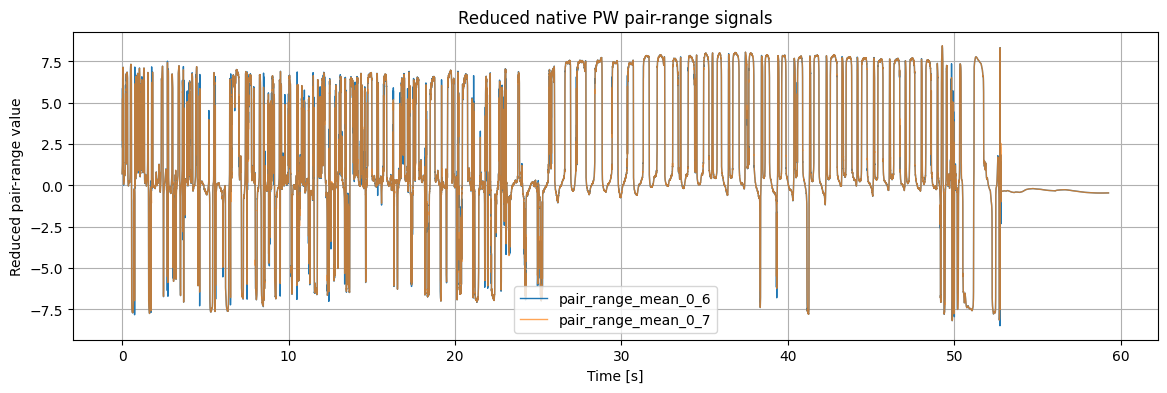

In [192]:
plt.figure(figsize=(14, 4))
plt.plot(time_s, reduced_pair_df["pair_range_mean_0_6"], linewidth=1, label="pair_range_mean_0_6")
plt.plot(time_s, reduced_pair_df["pair_range_mean_0_7"], linewidth=1, alpha=0.7, label="pair_range_mean_0_7")
plt.xlabel("Time [s]")
plt.ylabel("Reduced pair-range value")
plt.title("Reduced native PW pair-range signals")
plt.grid(True)
plt.legend()
plt.show()

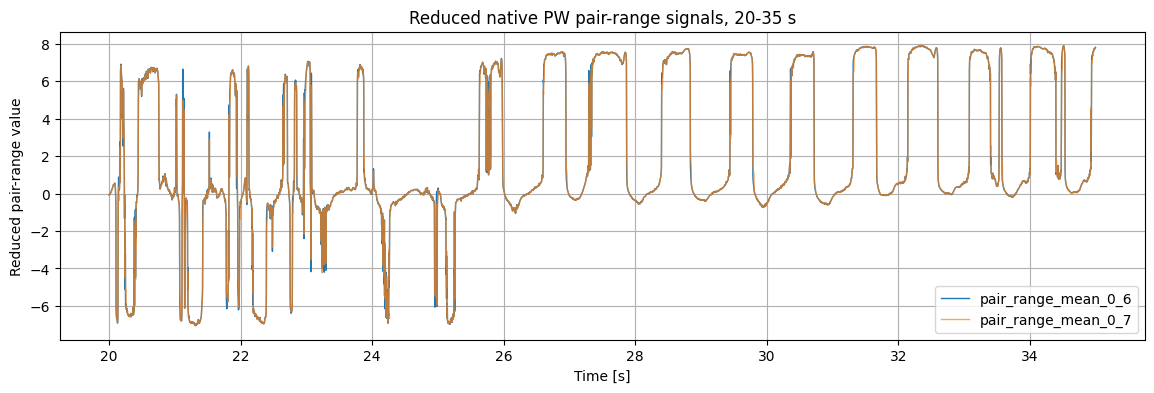

In [193]:
window_start_s = 20.0
window_end_s = 35.0
mask = (time_s >= window_start_s) & (time_s <= window_end_s)
plt.figure(figsize=(14, 4))
plt.plot(time_s[mask], reduced_pair_df.loc[mask, "pair_range_mean_0_6"], linewidth=1,  label="pair_range_mean_0_6")
plt.plot(time_s[mask], reduced_pair_df.loc[mask, "pair_range_mean_0_7"], linewidth=1, alpha=0.7, label="pair_range_mean_0_7")
plt.xlabel("Time [s]")
plt.ylabel("Reduced pair-range value")
plt.title("Reduced native PW pair-range signals, 20-35 s")
plt.grid(True)
plt.legend()
plt.show()

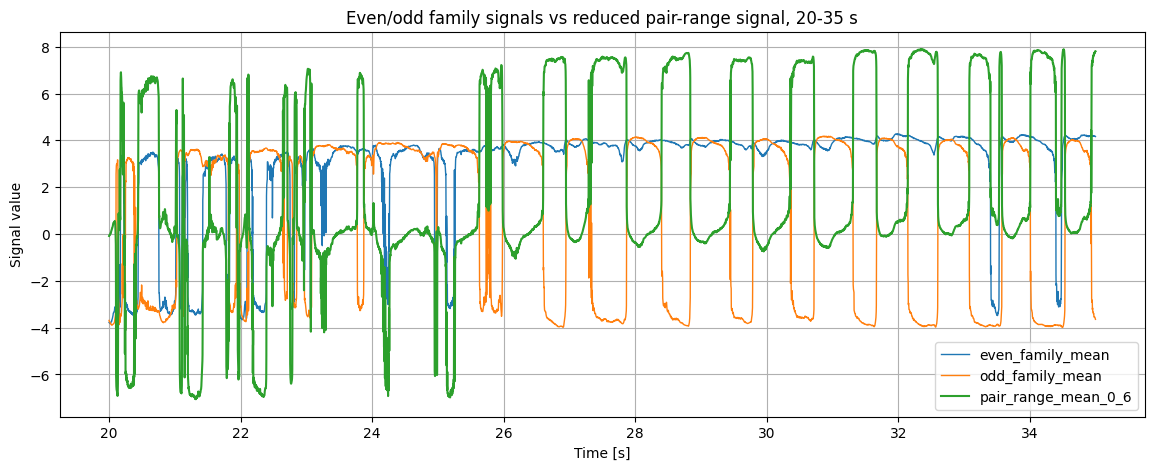

In [194]:
window_start_s = 20.0
window_end_s = 35.0
mask = (time_s >= window_start_s) & (time_s <= window_end_s)
plt.figure(figsize=(14, 5))
plt.plot(time_s[mask], family_df.loc[mask, "even_family_mean"], linewidth=1, label="even_family_mean")
plt.plot(time_s[mask], family_df.loc[mask, "odd_family_mean"], linewidth=1, label="odd_family_mean")
plt.plot(time_s[mask], reduced_pair_df.loc[mask, "pair_range_mean_0_6"], linewidth=1.5, label="pair_range_mean_0_6")
plt.xlabel("Time [s]")
plt.ylabel("Signal value")
plt.title("Even/odd family signals vs reduced pair-range signal, 20-35 s")
plt.grid(True)
plt.legend()
plt.show()

## Interim finding: reduced pair range is the strongest native dynamic signal candidate

Pair ranges were reduced into candidate native PW dynamic signals.

Two variants were tested:

```text
pair_range_mean_0_6
pair_range_mean_0_7

## Native pair-range signal versus linked AVI audio

The reduced pair-range signal is now treated as the preferred native PW dynamic signal candidate.

This section compares:

```text
pair_range_mean_0_6

In [195]:
def scale_signal_to_reference_range(signal_values, reference_values):
    """
    Scale one signal into the approximate value range of a reference signal.

    This helper is used only for visual overlay.

    Parameters
    ----------
    signal_values : array-like
        Signal to scale.

    reference_values : array-like
        Reference signal defining the target median and amplitude scale.

    Returns
    -------
    scaled_signal : numpy.ndarray
        Scaled signal values.
    """
    signal_values = np.asarray(signal_values, dtype=float)
    reference_values = np.asarray(reference_values, dtype=float)
    signal_median = np.nanmedian(signal_values)
    reference_median = np.nanmedian(reference_values)
    signal_iqr = np.nanpercentile(signal_values, 75) - np.nanpercentile(signal_values, 25)
    reference_iqr = np.nanpercentile(reference_values, 75) - np.nanpercentile(reference_values, 25)

    if signal_iqr == 0 or not np.isfinite(signal_iqr):
        return signal_values - signal_median + reference_median

    scaled_signal = (
        (signal_values - signal_median)
        / signal_iqr
        * reference_iqr
        + reference_median
    )

    return scaled_signal


def plot_pair_range_signal_vs_audio(
    time_s,
    pair_range_signal,
    audio_time_s,
    audio_envelope,
    window_start_s=20.0,
    window_end_s=35.0,
    title="Native pair-range signal vs linked AVI audio envelope",
):
    """
    Plot reduced native pair-range signal against linked AVI audio envelope.

    The audio envelope is visually scaled into the native signal range.

    Parameters
    ----------
    time_s : numpy.ndarray
        Native signal time axis.

    pair_range_signal : array-like
        Reduced pair-range native signal.

    audio_time_s : numpy.ndarray
        Audio envelope time axis.

    audio_envelope : array-like
        Audio envelope values.

    window_start_s : float
        Plot window start.

    window_end_s : float
        Plot window end.

    title : str
        Plot title.

    Returns
    -------
    None
        Displays the plot.
    """
    time_s = np.asarray(time_s, dtype=float)
    pair_range_signal = np.asarray(pair_range_signal, dtype=float)
    audio_time_s = np.asarray(audio_time_s, dtype=float)
    audio_envelope = np.asarray(audio_envelope, dtype=float)

    native_mask = (time_s >= window_start_s) & (time_s <= window_end_s)
    audio_mask = (audio_time_s >= window_start_s) & (audio_time_s <= window_end_s)

    native_window_values = pair_range_signal[native_mask]
    audio_window_values = audio_envelope[audio_mask]

    scaled_audio = scale_signal_to_reference_range(signal_values=audio_window_values, reference_values=native_window_values)
    plt.figure(figsize=(14, 5))
    plt.plot(time_s[native_mask], native_window_values, linewidth=1.2, label="native pair_range_mean_0_6")

    plt.plot(audio_time_s[audio_mask], scaled_audio, linewidth=1, alpha=0.8, label="audio envelope scaled")
    plt.xlabel("Time [s]")
    plt.ylabel("Signal value / scaled envelope")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

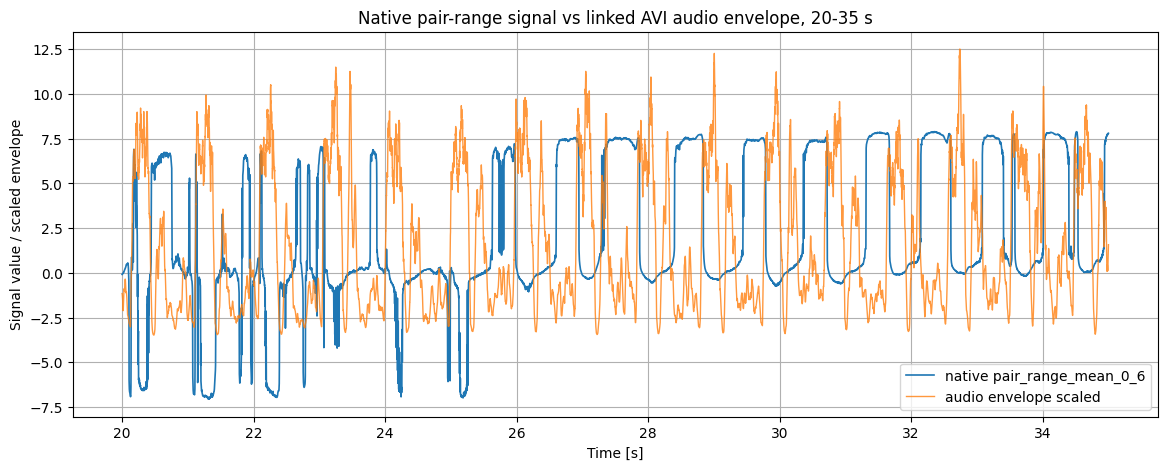

In [196]:
plot_pair_range_signal_vs_audio(
    time_s=time_s,
    pair_range_signal=reduced_pair_df["pair_range_mean_0_6"],
    audio_time_s=audio_time_s,
    audio_envelope=audio_envelope,
    window_start_s=20.0,
    window_end_s=35.0,
    title="Native pair-range signal vs linked AVI audio envelope, 20-35 s",
)

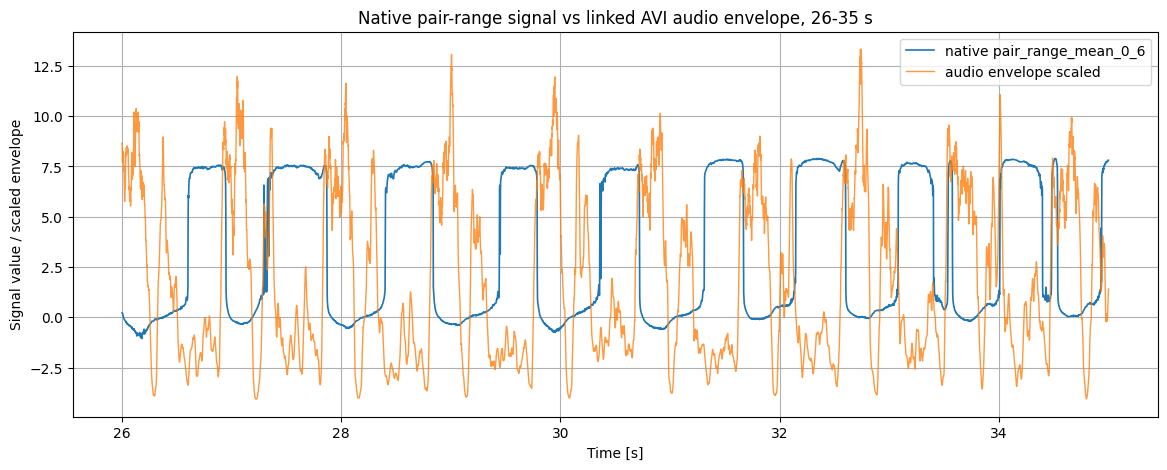

In [197]:
plot_pair_range_signal_vs_audio(
    time_s=time_s,
    pair_range_signal=reduced_pair_df["pair_range_mean_0_6"],
    audio_time_s=audio_time_s,
    audio_envelope=audio_envelope,
    window_start_s=26.0,
    window_end_s=35.0,
    title="Native pair-range signal vs linked AVI audio envelope, 26-35 s",
)

## Interim finding: pair-range signal aligns with Doppler audio timing but is not the audio envelope

The reduced native pair-range signal was compared with the linked AVI Doppler audio envelope.

The preferred signal was:

```text
pair_range_mean_0_6

In [198]:
def detect_pair_range_events(
    time_s,
    pair_range_signal,
    min_distance_s=0.4,
    prominence=4.0,
):
    """
    Detect candidate events in the reduced native pair-range signal.

    The detector searches for low-state events by finding peaks in the
    inverted pair-range signal.

    Parameters
    ----------
    time_s : numpy.ndarray
        Time axis in seconds.

    pair_range_signal : array-like
        Reduced pair-range native signal.

    min_distance_s : float
        Minimum allowed distance between detected events.

    prominence : float
        Peak prominence used on the inverted signal.

    Returns
    -------
    pair_event_df : pandas.DataFrame
        Detected native pair-range events.

    properties : dict
        Peak properties returned by scipy.signal.find_peaks.
    """
    from scipy.signal import find_peaks

    time_s = np.asarray(time_s, dtype=float)
    signal = np.asarray(pair_range_signal, dtype=float)

    if len(time_s) != len(signal):
        raise ValueError("time_s and pair_range_signal must have the same length.")

    sample_rate_hz = 1.0 / np.median(np.diff(time_s))
    min_distance_samples = int(round(min_distance_s * sample_rate_hz))
    detection_signal = -signal
    peak_indices, properties = find_peaks(detection_signal, distance=min_distance_samples, prominence=prominence)

    event_times = time_s[peak_indices]
    event_values = signal[peak_indices]

    rr_s = np.diff(event_times)
    instant_hr_bpm = 60.0 / rr_s

    pair_event_df = pd.DataFrame(
        {
            "event_index": np.arange(len(peak_indices)),
            "sample_index": peak_indices,
            "time_s": event_times,
            "signal_value": event_values,
            "detection_value": detection_signal[peak_indices],
            "prominence": properties.get("prominences", np.full(len(peak_indices), np.nan)),
        }
    )

    pair_event_df["rr_s"] = np.nan
    pair_event_df["instant_hr_bpm"] = np.nan

    if len(pair_event_df) > 1:
        pair_event_df.loc[1:, "rr_s"] = rr_s
        pair_event_df.loc[1:, "instant_hr_bpm"] = instant_hr_bpm

    return pair_event_df, properties

In [199]:
pair_event_df, pair_event_properties = detect_pair_range_events(time_s=time_s, pair_range_signal=reduced_pair_df["pair_range_mean_0_6"], min_distance_s=0.4, prominence=4.0)
pair_event_df.head(30)

,event_index,sample_index,time_s,signal_value,detection_value,prominence,rr_s,instant_hr_bpm
0,0,45,0.090056,0.017381,-0.017381,6.839565,NaN,NaN
1,1,375,0.750464,-7.822612,7.822612,15.152544,0.660409,90.852848
2,2,825,1.651021,-7.744768,7.744768,14.907693,0.900557,66.625422
3,3,1243,2.487539,-6.728544,6.728544,13.947805,0.836518,71.725933
4,4,1545,3.091913,-5.804219,5.804219,12.850119,0.604374,99.276291
5,5,1848,3.698288,-7.059336,7.059336,14.244664,0.606375,98.948646
6,6,2328,4.658882,-7.280735,7.280735,13.995099,0.960594,62.461333
7,7,2669,5.341305,-7.655073,7.655073,15.171761,0.682422,87.922111
8,8,3170,6.343925,-7.617046,7.617046,14.202847,1.002620,59.843193
9,9,3753,7.510647,-6.878348,6.878348,13.743757,1.166722,51.426140


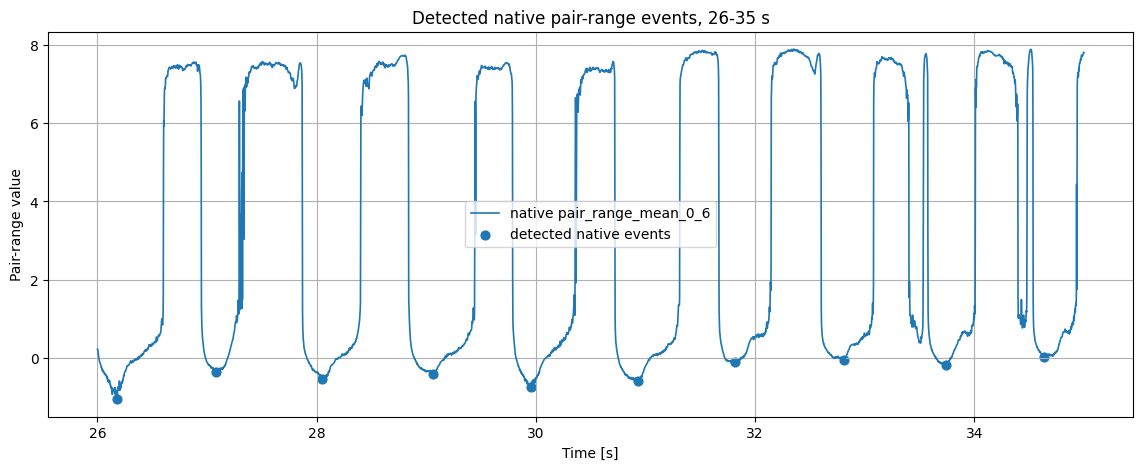

In [200]:
window_start_s = 26.0
window_end_s = 35.0
mask = (time_s >= window_start_s) & (time_s <= window_end_s)
event_mask = ((pair_event_df["time_s"] >= window_start_s) & (pair_event_df["time_s"] <= window_end_s))
plt.figure(figsize=(14, 5))
plt.plot(
    time_s[mask],
    reduced_pair_df.loc[mask, "pair_range_mean_0_6"],
    linewidth=1.2,
    label="native pair_range_mean_0_6",
)
plt.scatter(
    pair_event_df.loc[event_mask, "time_s"],
    pair_event_df.loc[event_mask, "signal_value"],
    s=40,
    label="detected native events",
)
plt.xlabel("Time [s]")
plt.ylabel("Pair-range value")
plt.title("Detected native pair-range events, 26-35 s")
plt.grid(True)
plt.legend()
plt.show()

## Interim finding: pair-range event detection works best in stable segments

Native event detection was tested on `pair_range_mean_0_6` by detecting low-state minima.

In the stable 26-35 s window, detected events align well with repeated pair-range cycles.

Across the full recording, the detector also captures extra events in unstable or noisy periods.

This suggests that `pair_range_mean_0_6` is suitable for native event detection, but detection should be combined with:

- stable-segment selection,
- realistic minimum event distance,
- RR interval quality control,
- and comparison against linked AVI audio events.

The current detector should not yet be treated as a final native HR estimator.

In [201]:
def filter_events_to_time_window(event_df, window_start_s, window_end_s):
    """
    Filter detected events to a selected time window and recompute RR intervals.

    Parameters
    ----------
    event_df : pandas.DataFrame
        Event table with at least `time_s` and `signal_value`.

    window_start_s : float
        Window start time in seconds.

    window_end_s : float
        Window end time in seconds.

    Returns
    -------
    window_event_df : pandas.DataFrame
        Event table filtered to the selected window with recomputed RR and HR.
    """
    window_event_df = event_df[(event_df["time_s"] >= window_start_s) & (event_df["time_s"] <= window_end_s)].copy()
    window_event_df = window_event_df.reset_index(drop=True)
    window_event_df["event_index"] = np.arange(len(window_event_df))

    window_event_df["rr_s"] = np.nan
    window_event_df["instant_hr_bpm"] = np.nan

    if len(window_event_df) > 1:
        rr_s = np.diff(window_event_df["time_s"].to_numpy())
        window_event_df.loc[1:, "rr_s"] = rr_s
        window_event_df.loc[1:, "instant_hr_bpm"] = 60.0 / rr_s

    return window_event_df


def summarize_event_rr_quality(event_df, min_rr_s=0.65, max_rr_s=1.20):
    """
    Summarize RR interval quality for detected events.

    Parameters
    ----------
    event_df : pandas.DataFrame
        Event table with `rr_s` and `instant_hr_bpm`.

    min_rr_s : float
        Minimum accepted RR interval.

    max_rr_s : float
        Maximum accepted RR interval.

    Returns
    -------
    rr_summary : dict
        Summary of accepted/rejected RR intervals.

    rr_quality_df : pandas.DataFrame
        Event table with RR quality flags.
    """
    rr_quality_df = event_df.copy()
    rr_quality_df["rr_quality_ok"] = (rr_quality_df["rr_s"].notna() & (rr_quality_df["rr_s"] >= min_rr_s) & (rr_quality_df["rr_s"] <= max_rr_s))
    valid_rr_df = rr_quality_df[rr_quality_df["rr_quality_ok"]].copy()

    rr_summary = {
        "n_events": int(len(rr_quality_df)),
        "n_intervals": int(rr_quality_df["rr_s"].notna().sum()),
        "n_intervals_ok": int(rr_quality_df["rr_quality_ok"].sum()),
        "ok_fraction": (
            float(rr_quality_df["rr_quality_ok"].sum() / rr_quality_df["rr_s"].notna().sum())
            if rr_quality_df["rr_s"].notna().sum() > 0
            else np.nan
        ),
        "min_rr_s": min_rr_s,
        "max_rr_s": max_rr_s,
        "median_rr_s_ok": float(valid_rr_df["rr_s"].median()) if len(valid_rr_df) else np.nan,
        "median_hr_bpm_ok": float(valid_rr_df["instant_hr_bpm"].median()) if len(valid_rr_df) else np.nan,
        "mean_hr_bpm_ok": float(valid_rr_df["instant_hr_bpm"].mean()) if len(valid_rr_df) else np.nan,
        "std_hr_bpm_ok": float(valid_rr_df["instant_hr_bpm"].std()) if len(valid_rr_df) else np.nan,
    }

    return rr_summary, rr_quality_df

In [202]:
pair_event_df_v2, pair_event_properties_v2 = detect_pair_range_events(
    time_s=time_s,
    pair_range_signal=reduced_pair_df["pair_range_mean_0_6"],
    min_distance_s=0.65,
    prominence=4.0,
)
stable_pair_event_df = filter_events_to_time_window(
    pair_event_df_v2,
    window_start_s=26.0,
    window_end_s=35.0,
)
stable_rr_summary, stable_pair_event_qc_df = summarize_event_rr_quality(
    stable_pair_event_df,
    min_rr_s=0.65,
    max_rr_s=1.20,
)
stable_rr_summary

{'n_events': 10,
 'n_intervals': 9,
 'n_intervals_ok': 9,
 'ok_fraction': 1.0,
 'min_rr_s': 0.65,
 'max_rr_s': 1.2,
 'median_rr_s_ok': 0.9265732455399842,
 'median_hr_bpm_ok': 64.75472963287804,
 'mean_hr_bpm_ok': 64.04589820463512,
 'std_hr_bpm_ok': 3.2673576874540995}

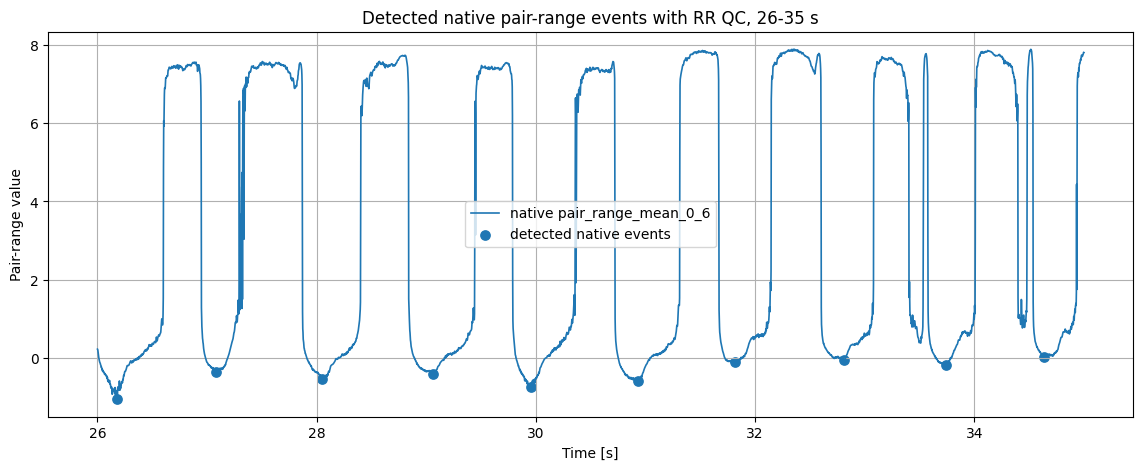

In [203]:
window_start_s = 26.0
window_end_s = 35.0
mask = (time_s >= window_start_s) & (time_s <= window_end_s)
plt.figure(figsize=(14, 5))
plt.plot(
    time_s[mask],
    reduced_pair_df.loc[mask, "pair_range_mean_0_6"],
    linewidth=1.2,
    label="native pair_range_mean_0_6",
)
plt.scatter(
    stable_pair_event_qc_df["time_s"],
    stable_pair_event_qc_df["signal_value"],
    s=45,
    label="detected native events",
)
bad_rr_df = stable_pair_event_qc_df[stable_pair_event_qc_df["rr_s"].notna() & ~stable_pair_event_qc_df["rr_quality_ok"]]

if len(bad_rr_df) > 0:
    plt.scatter(bad_rr_df["time_s"], bad_rr_df["signal_value"], s=80, marker="x", label="RR rejected",)

plt.xlabel("Time [s]")
plt.ylabel("Pair-range value")
plt.title("Detected native pair-range events with RR QC, 26-35 s")
plt.grid(True)
plt.legend()
plt.show()

## Interim finding: stable-segment pair-range event detection gives clean RR timing

Event detection was repeated on the reduced native signal:

```text
pair_range_mean_0_6

In [209]:
window_start_s = 26.0
window_end_s = 35.0

stable_audio_events_df = filter_events_to_time_window(
    audio_events_df,
    window_start_s=window_start_s,
    window_end_s=window_end_s,
)

pair_audio_comparison_df, pair_audio_comparison_summary = compare_event_timing_to_reference(
    candidate_events_df=stable_pair_event_qc_df,
    reference_events_df=stable_audio_events_df,
    candidate_time_column="time_s",
    reference_time_column="time_s",
    max_abs_delta_s=0.4,
)

pair_audio_comparison_summary

{'n_candidate_events': 10,
 'n_reference_events': 11,
 'n_valid_matches': 10,
 'valid_match_fraction': 1.0,
 'median_delta_s': 0.02608122115763223,
 'mean_delta_s': 0.04123870399290652,
 'std_delta_s': 0.06277704319309163,
 'median_abs_delta_s': 0.03262325538859834,
 'max_abs_delta_s_valid': 0.19512455681242358}

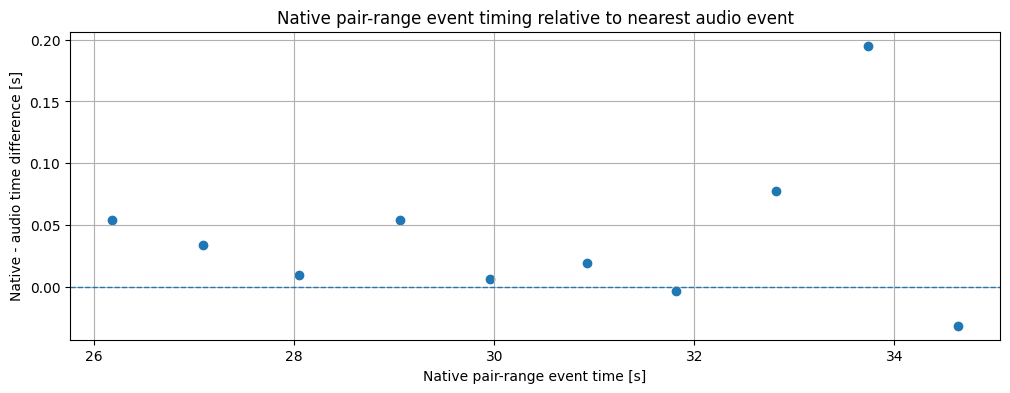

In [210]:
plt.figure(figsize=(12, 4))
plt.scatter(pair_audio_comparison_df["candidate_time_s"], pair_audio_comparison_df["delta_s"])

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Native pair-range event time [s]")
plt.ylabel("Native - audio time difference [s]")
plt.title("Native pair-range event timing relative to nearest audio event")
plt.grid(True)
plt.show()

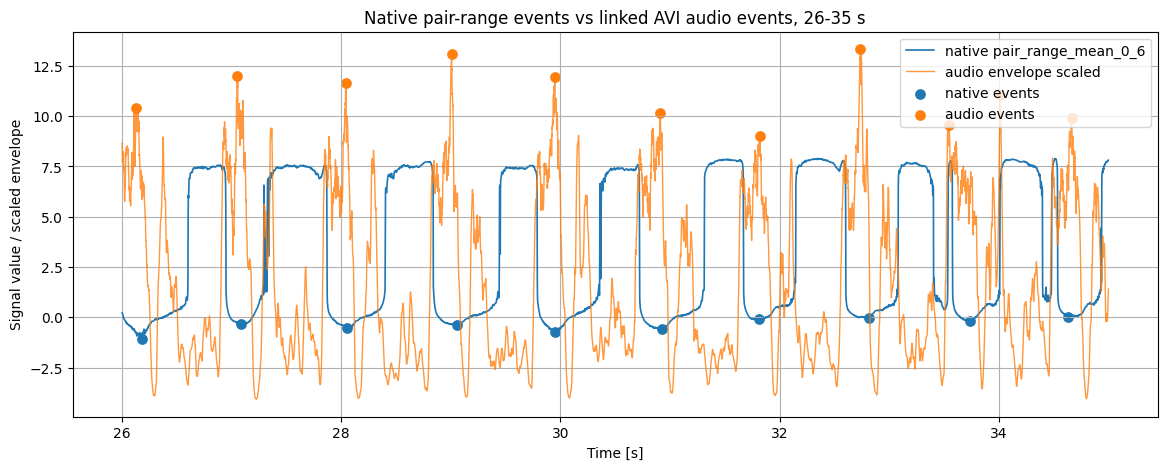

In [211]:
window_start_s = 26.0
window_end_s = 35.0

native_mask = (time_s >= window_start_s) & (time_s <= window_end_s)
audio_mask = (audio_time_s >= window_start_s) & (audio_time_s <= window_end_s)

native_window_values = reduced_pair_df.loc[native_mask, "pair_range_mean_0_6"].to_numpy()
audio_window_values = audio_envelope[audio_mask]
scaled_audio = scale_signal_to_reference_range(signal_values=audio_window_values, reference_values=native_window_values)

audio_event_times = stable_audio_events_df["time_s"].to_numpy()
audio_event_values_scaled = np.interp(audio_event_times, audio_time_s[audio_mask], scaled_audio)

plt.figure(figsize=(14, 5))
plt.plot(time_s[native_mask], native_window_values, linewidth=1.2, label="native pair_range_mean_0_6")
plt.plot(audio_time_s[audio_mask], scaled_audio, linewidth=1, alpha=0.8, label="audio envelope scaled")
plt.scatter(stable_pair_event_qc_df["time_s"], stable_pair_event_qc_df["signal_value"], s=45, label="native events")
plt.scatter(audio_event_times, audio_event_values_scaled, s=45, label="audio events")
plt.xlabel("Time [s]")
plt.ylabel("Signal value / scaled envelope")
plt.title("Native pair-range events vs linked AVI audio events, 26-35 s")
plt.grid(True)
plt.legend()
plt.show()

## Interim finding: pair-range native events align with linked AVI audio events

Native events detected from the reduced pair-range signal were compared with linked AVI Doppler audio events in the stable 26-35 s window.

The native signal used was:

```text
pair_range_mean_0_6

In [212]:
def compare_event_rr_intervals(
    candidate_event_df,
    reference_event_df,
    candidate_time_col="time_s",
    reference_time_col="time_s",
    max_abs_rr_delta_s=0.20,
):
    """
    Compare consecutive RR intervals between candidate and reference events.

    The comparison uses the first common number of intervals from both event
    sequences. This is a simple segment-level diagnostic, not a final event
    alignment algorithm.

    Parameters
    ----------
    candidate_event_df : pandas.DataFrame
        Candidate native event table.

    reference_event_df : pandas.DataFrame
        Reference event table, for example audio events.

    candidate_time_col : str
        Time column in candidate event table.

    reference_time_col : str
        Time column in reference event table.

    max_abs_rr_delta_s : float
        Maximum accepted absolute RR difference.

    Returns
    -------
    rr_comparison_df : pandas.DataFrame
        One row per compared interval.

    rr_comparison_summary : dict
        Summary of RR agreement.
    """
    candidate_times = candidate_event_df[candidate_time_col].to_numpy(dtype=float)
    reference_times = reference_event_df[reference_time_col].to_numpy(dtype=float)

    candidate_rr_s = np.diff(candidate_times)
    reference_rr_s = np.diff(reference_times)

    n_compared = min(len(candidate_rr_s), len(reference_rr_s))

    if n_compared == 0:
        rr_comparison_df = pd.DataFrame()
        rr_comparison_summary = {
            "n_candidate_intervals": int(len(candidate_rr_s)),
            "n_reference_intervals": int(len(reference_rr_s)),
            "n_compared_intervals": 0,
            "n_intervals_ok": 0,
            "ok_fraction": np.nan,
            "median_abs_rr_delta_s": np.nan,
            "mean_abs_rr_delta_s": np.nan,
            "max_abs_rr_delta_s": np.nan,
            "candidate_median_hr_bpm": np.nan,
            "reference_median_hr_bpm": np.nan,
        }
        return rr_comparison_df, rr_comparison_summary

    candidate_rr_s = candidate_rr_s[:n_compared]
    reference_rr_s = reference_rr_s[:n_compared]

    rr_delta_s = candidate_rr_s - reference_rr_s
    abs_rr_delta_s = np.abs(rr_delta_s)

    rr_comparison_df = pd.DataFrame(
        {
            "interval_index": np.arange(n_compared),
            "candidate_rr_s": candidate_rr_s,
            "reference_rr_s": reference_rr_s,
            "rr_delta_s": rr_delta_s,
            "abs_rr_delta_s": abs_rr_delta_s,
        }
    )

    rr_comparison_df["rr_match_ok"] = (rr_comparison_df["abs_rr_delta_s"] <= max_abs_rr_delta_s)
    ok_df = rr_comparison_df[rr_comparison_df["rr_match_ok"]].copy()

    rr_comparison_summary = {
        "n_candidate_intervals": int(len(np.diff(candidate_times))),
        "n_reference_intervals": int(len(np.diff(reference_times))),
        "n_compared_intervals": int(n_compared),
        "n_intervals_ok": int(rr_comparison_df["rr_match_ok"].sum()),
        "ok_fraction": float(rr_comparison_df["rr_match_ok"].mean()),
        "max_abs_rr_delta_s_threshold": max_abs_rr_delta_s,
        "median_abs_rr_delta_s": float(rr_comparison_df["abs_rr_delta_s"].median()),
        "mean_abs_rr_delta_s": float(rr_comparison_df["abs_rr_delta_s"].mean()),
        "max_abs_rr_delta_s": float(rr_comparison_df["abs_rr_delta_s"].max()),
        "median_abs_rr_delta_s_ok": float(ok_df["abs_rr_delta_s"].median()) if len(ok_df) else np.nan,
        "mean_abs_rr_delta_s_ok": float(ok_df["abs_rr_delta_s"].mean()) if len(ok_df) else np.nan,
        "candidate_median_hr_bpm": float(60.0 / np.median(candidate_rr_s)),
        "reference_median_hr_bpm": float(60.0 / np.median(reference_rr_s)),
    }

    return rr_comparison_df, rr_comparison_summary

In [213]:
pair_audio_rr_df, pair_audio_rr_summary = compare_event_rr_intervals(
    candidate_event_df=stable_pair_event_qc_df,
    reference_event_df=stable_audio_events_df,
    candidate_time_col="time_s",
    reference_time_col="time_s",
    max_abs_rr_delta_s=0.20,
)

pair_audio_rr_summary

{'n_candidate_intervals': 9,
 'n_reference_intervals': 10,
 'n_compared_intervals': 9,
 'n_intervals_ok': 8,
 'ok_fraction': 0.8888888888888888,
 'max_abs_rr_delta_s_threshold': 0.2,
 'median_abs_rr_delta_s': 0.04485317477066886,
 'mean_abs_rr_delta_s': 0.0885212311860223,
 'max_abs_rr_delta_s': 0.4260105309809177,
 'median_abs_rr_delta_s_ok': 0.03456508350216758,
 'mean_abs_rr_delta_s_ok': 0.04633506871166038,
 'candidate_median_hr_bpm': 64.75472963287804,
 'reference_median_hr_bpm': 65.02156096900178}

In [214]:
pair_audio_rr_df

,interval_index,candidate_rr_s,reference_rr_s,rr_delta_s,abs_rr_delta_s,rr_match_ok
0,0,0.902558,0.922771,-0.020212,0.020212,True
1,1,0.966598,0.990875,-0.024277,0.024277,True
2,2,1.008624,0.963771,0.044853,0.044853,True
3,3,0.894553,0.942437,-0.047884,0.047884,True
4,4,0.974603,0.962063,0.012540,0.012540,True
5,5,0.886548,0.908792,-0.022243,0.022243,True
6,6,0.998618,0.917708,0.080909,0.080909,True
7,7,0.926573,0.808812,0.117761,0.117761,True
8,8,0.892552,0.466542,0.426011,0.426011,False


## Interim finding: pair-range RR timing agrees with linked AVI audio in stable segment

RR intervals from native pair-range events were compared with RR intervals from linked AVI audio events in the stable 26-35 s window.

The comparison showed:

```text
native intervals: 9
audio intervals compared: 9
accepted intervals: 8 / 9
accepted fraction: ~0.89
native median HR: ~64.75 bpm
audio median HR: ~65.02 bpm
median absolute RR difference: ~45 ms
median absolute RR difference for accepted intervals: ~35 ms
mean absolute RR difference for accepted intervals: ~46 ms

## Current checkpoint: native pair-range signal

This section summarizes the strongest current finding from the native PW binary exploration.

The native PW page structure is currently interpreted as:

```text
PW_CinePartition0.bin
    page size = 1296 bytes
    page rate ≈ 500 Hz

Each page:
    16-byte header

    16 dynamic records = 8 even/odd pairs

Each dynamic record:
    Q32 fixed-point phase/bin field
    float32 dynamic value

### Stable-segment validation against linked AVI audio

The reduced native pair-range signal was validated against linked AVI Doppler audio in a stable 26-35 s segment.

Native events were detected from low-state minima of:

```text
pair_range_mean_0_6
```

### Current interpretation

The current strongest interpretation is:

```text
pair_range_mean_0_6 is a native PW event/state-like signal that contains beat-scale timing information.

```

## Batch validation of reduced pair-range native PW signal

This section applies the current preferred native PW signal candidate across all native recordings:

```text
pair_range_mean_0_6

In [237]:
pair_range_batch_rows = []
pair_range_batch_debug = {}

recording_ids = (
    batch_validation_df[
        batch_validation_df["status"] == "ok"
    ]["recording_id"]
    .tolist()
)

window_length_s = 9.0
step_s = 5.0

native_min_distance_s = 0.65
native_prominence = 4.0

min_rr_s = 0.65
max_rr_s = 1.20

max_abs_delta_s = 0.4
max_abs_rr_delta_s = 0.2

for recording_id in recording_ids:
    print(f"Processing {recording_id}...")

    try:
        debug = batch_debug.get(recording_id, None)

        if debug is None:
            pair_range_batch_rows.append(
                {
                    "recording_id": recording_id,
                    "status": "missing_batch_debug",
                }
            )
            continue

        record_f32 = debug["record_f32"]
        time_s = debug["time_s"]
        audio_time_s = debug["audio_time_s"]
        audio_envelope = debug["audio_envelope"]
        audio_events_df = debug["audio_events_df"]

        pair_feature_df, pair_long_df = build_dynamic_pair_matrix(record_f32=record_f32, n_dynamic_records=16)
        reduced_pair_df = build_reduced_pair_range_signals(pair_feature_df=pair_feature_df)
        pair_event_df, pair_event_properties = detect_pair_range_events(
            time_s=time_s,
            pair_range_signal=reduced_pair_df["pair_range_mean_0_6"],
            min_distance_s=native_min_distance_s,
            prominence=native_prominence,
        )

        duration_s = min(float(np.nanmax(time_s)), float(np.nanmax(audio_time_s)))
        window_starts = np.arange(0.0, max(0.0, duration_s - window_length_s), step_s)
        recording_window_rows = []

        for window_index, window_start_s in enumerate(window_starts):
            window_end_s = window_start_s + window_length_s

            stable_pair_event_df = filter_events_to_time_window(
                pair_event_df,
                window_start_s=window_start_s,
                window_end_s=window_end_s,
            )
            stable_audio_events_df = filter_events_to_time_window(
                audio_events_df,
                window_start_s=window_start_s,
                window_end_s=window_end_s,
            )
            stable_rr_summary, stable_pair_event_qc_df = summarize_event_rr_quality(
                stable_pair_event_df,
                min_rr_s=min_rr_s,
                max_rr_s=max_rr_s,
            )
            timing_comparison_df, timing_summary = compare_event_timing_to_reference(
                candidate_events_df=stable_pair_event_qc_df,
                reference_events_df=stable_audio_events_df,
                candidate_time_column="time_s",
                reference_time_column="time_s",
                max_abs_delta_s=max_abs_delta_s,
            )
            rr_comparison_df, rr_summary = compare_event_rr_intervals(
                candidate_event_df=stable_pair_event_qc_df,
                reference_event_df=stable_audio_events_df,
                candidate_time_col="time_s",
                reference_time_col="time_s",
                max_abs_rr_delta_s=max_abs_rr_delta_s,
            )
            rr_median_abs_delta_s_ok = rr_summary.get("median_abs_rr_delta_s_ok", np.nan)
            rr_mean_abs_delta_s_ok = rr_summary.get("mean_abs_rr_delta_s_ok", np.nan)

            row = {
                "recording_id": recording_id,
                "status": "ok",
                "window_index": window_index,
                "window_start_s": window_start_s,
                "window_end_s": window_end_s,

                "native_n_events": stable_rr_summary["n_events"],
                "native_n_intervals": stable_rr_summary["n_intervals"],
                "native_n_intervals_ok": stable_rr_summary["n_intervals_ok"],
                "native_rr_ok_fraction": stable_rr_summary["ok_fraction"],
                "native_median_hr_bpm_ok": stable_rr_summary["median_hr_bpm_ok"],
                "native_mean_hr_bpm_ok": stable_rr_summary["mean_hr_bpm_ok"],
                "native_std_hr_bpm_ok": stable_rr_summary["std_hr_bpm_ok"],

                "audio_n_events": len(stable_audio_events_df),

                "timing_n_valid_matches": timing_summary["n_valid_matches"],
                "timing_valid_match_fraction": timing_summary["valid_match_fraction"],
                "timing_median_delta_s": timing_summary["median_delta_s"],
                "timing_mean_delta_s": timing_summary["mean_delta_s"],
                "timing_std_delta_s": timing_summary["std_delta_s"],
                "timing_median_abs_delta_s": timing_summary["median_abs_delta_s"],
                "timing_max_abs_delta_s_valid": timing_summary["max_abs_delta_s_valid"],

                "rr_n_compared_intervals": rr_summary["n_compared_intervals"],
                "rr_n_intervals_ok": rr_summary["n_intervals_ok"],
                "rr_ok_fraction": rr_summary["ok_fraction"],
                "rr_median_abs_delta_s": rr_summary["median_abs_rr_delta_s"],
                "rr_mean_abs_delta_s": rr_summary["mean_abs_rr_delta_s"],
                "rr_max_abs_delta_s": rr_summary["max_abs_rr_delta_s"],
                "rr_median_abs_delta_s_ok": rr_median_abs_delta_s_ok,
                "rr_mean_abs_delta_s_ok": rr_mean_abs_delta_s_ok,
                "rr_candidate_median_hr_bpm": rr_summary["candidate_median_hr_bpm"],
                "rr_reference_median_hr_bpm": rr_summary["reference_median_hr_bpm"],
            }

            row["segment_quality_ok"] = (
                row["native_n_events"] >= 6
                and row["audio_n_events"] >= 6
                and pd.notna(row["native_rr_ok_fraction"])
                and row["native_rr_ok_fraction"] >= 0.80
                and pd.notna(row["timing_valid_match_fraction"])
                and row["timing_valid_match_fraction"] >= 0.80
                and pd.notna(row["rr_ok_fraction"])
                and row["rr_ok_fraction"] >= 0.80
            )

            pair_range_batch_rows.append(row)
            recording_window_rows.append(row)

        pair_range_batch_debug[recording_id] = {
            "pair_feature_df": pair_feature_df,
            "pair_long_df": pair_long_df,
            "reduced_pair_df": reduced_pair_df,
            "pair_event_df": pair_event_df,
            "audio_events_df": audio_events_df,
            "window_rows": recording_window_rows,
        }

    except Exception as exc:
        pair_range_batch_rows.append(
            {
                "recording_id": recording_id,
                "status": "error",
                "error_message": str(exc),
            }
        )

pair_range_batch_df = pd.DataFrame(pair_range_batch_rows)
pair_range_batch_df.shape

Processing 202606130411060002SMP...
Processing 202606130413540003SMP...
Processing 202606130417060004SMP...
Processing 202606130420260005SMP...
Processing 202606130422440006SMP...
Processing 202606130426500007SMP...
Processing 202606130430380008SMP...
Processing 202606130433280009SMP...
Processing 202606130434130010SMP...
Processing 202606130437480012SMP...


(75, 31)

In [238]:
pair_range_batch_df["status"].value_counts(dropna=False)

status
ok    75
Name: count, dtype: int64

In [241]:
pair_range_batch_df.shape

(75, 31)

In [242]:
if "error_message" in pair_range_batch_df.columns:
    error_preview_df = pair_range_batch_df[
        pair_range_batch_df["status"] == "error"
    ][
        ["recording_id", "status", "error_message"]
    ]

    display(error_preview_df)
else:
    print("No error_message column found.")
    print("This is expected when all rows completed with status == 'ok'.")

No error_message column found.
This is expected when all rows completed with status == 'ok'.


In [244]:
pair_range_ok_df = pair_range_batch_df[pair_range_batch_df["status"] == "ok"].copy()
pair_range_ok_df.shape

(75, 31)

In [245]:
preview_columns = [
    "recording_id",
    "window_index",
    "window_start_s",
    "window_end_s",
    "native_n_events",
    "audio_n_events",
    "native_rr_ok_fraction",
    "timing_valid_match_fraction",
    "timing_median_abs_delta_s",
    "rr_ok_fraction",
    "rr_median_abs_delta_s_ok",
    "rr_candidate_median_hr_bpm",
    "rr_reference_median_hr_bpm",
    "segment_quality_ok",
]
pair_range_ok_df[preview_columns].head(80)

,recording_id,window_index,window_start_s,window_end_s,native_n_events,audio_n_events,native_rr_ok_fraction,timing_valid_match_fraction,timing_median_abs_delta_s,rr_ok_fraction,rr_median_abs_delta_s_ok,rr_candidate_median_hr_bpm,rr_reference_median_hr_bpm,segment_quality_ok
0,202606130411060002SMP,0,0.0,9.0,10,9,0.888889,0.900000,0.168730,0.875000,0.125562,64.476215,62.160733,True
1,202606130411060002SMP,1,5.0,14.0,9,9,0.625000,1.000000,0.168730,0.375000,0.068912,55.316310,60.757571,False
2,202606130411060002SMP,2,10.0,19.0,9,9,0.750000,1.000000,0.104391,0.625000,0.024988,62.396337,63.045905,False
3,202606130411060002SMP,3,15.0,24.0,9,9,1.000000,1.000000,0.092766,1.000000,0.061330,62.461333,60.522002,True
4,202606130411060002SMP,4,20.0,29.0,9,9,1.000000,1.000000,0.042773,1.000000,0.060775,61.881197,60.828150,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,202606130437480012SMP,3,15.0,24.0,8,5,0.571429,0.500000,0.059598,0.500000,0.129623,50.887825,60.999502,False
71,202606130437480012SMP,4,20.0,29.0,9,4,0.750000,0.333333,0.074380,0.333333,0.032395,66.606509,63.927549,False
72,202606130437480012SMP,5,25.0,34.0,8,5,0.428571,0.375000,0.074380,0.500000,0.070779,61.294333,63.951681,False
73,202606130437480012SMP,6,30.0,39.0,9,2,0.750000,0.111111,0.061767,0.000000,NaN,48.033540,68.364707,False


In [246]:
pair_range_recording_summary_df = (
    pair_range_ok_df
    .groupby("recording_id", dropna=False)
    .agg(
        n_windows=("window_index", "size"),
        n_quality_ok_windows=("segment_quality_ok", "sum"),
        median_timing_abs_delta_s=("timing_median_abs_delta_s", "median"),
        median_rr_abs_delta_s_ok=("rr_median_abs_delta_s_ok", "median"),
        median_native_hr_bpm=("rr_candidate_median_hr_bpm", "median"),
        median_audio_hr_bpm=("rr_reference_median_hr_bpm", "median"),
    )
    .reset_index()
)

pair_range_recording_summary_df["quality_ok_fraction"] = (
    pair_range_recording_summary_df["n_quality_ok_windows"]
    / pair_range_recording_summary_df["n_windows"]
)
pair_range_recording_summary_df

,recording_id,n_windows,n_quality_ok_windows,median_timing_abs_delta_s,median_rr_abs_delta_s_ok,median_native_hr_bpm,median_audio_hr_bpm,quality_ok_fraction
0,202606130411060002SMP,11,5,0.092766,0.065121,62.234856,62.541679,0.454545
1,202606130413540003SMP,8,0,0.107357,0.126791,53.569167,103.021485,0.000000
2,202606130417060004SMP,7,0,0.059346,0.151393,65.162148,112.506592,0.000000
3,202606130420260005SMP,8,4,0.034983,0.042865,62.512081,62.579561,0.500000
4,202606130422440006SMP,9,0,0.160147,0.110597,65.298322,110.298342,0.000000
5,202606130426500007SMP,6,0,0.080907,0.088962,58.499130,100.872157,0.000000
6,202606130430380008SMP,8,0,0.175600,0.109446,46.205467,43.903366,0.000000
7,202606130433280009SMP,5,0,0.127029,0.133814,66.874344,109.643279,0.000000
8,202606130434130010SMP,5,0,0.060340,0.170993,61.161819,108.812695,0.000000
9,202606130437480012SMP,8,1,0.074380,0.070814,61.294333,63.927549,0.125000


In [247]:
pair_range_ok_df[
    pair_range_ok_df["segment_quality_ok"] == True
][
    [
        "recording_id",
        "window_index",
        "window_start_s",
        "window_end_s",
        "native_n_events",
        "audio_n_events",
        "timing_median_abs_delta_s",
        "rr_median_abs_delta_s_ok",
        "rr_candidate_median_hr_bpm",
        "rr_reference_median_hr_bpm",
    ]
].sort_values(
    ["recording_id", "window_start_s"]
)

,recording_id,window_index,window_start_s,window_end_s,native_n_events,audio_n_events,timing_median_abs_delta_s,rr_median_abs_delta_s_ok,rr_candidate_median_hr_bpm,rr_reference_median_hr_bpm
0,202606130411060002SMP,0,0.0,9.0,10,9,0.168730,0.125562,64.476215,62.160733
3,202606130411060002SMP,3,15.0,24.0,9,9,0.092766,0.061330,62.461333,60.522002
4,202606130411060002SMP,4,20.0,29.0,9,9,0.042773,0.060775,61.881197,60.828150
5,202606130411060002SMP,5,25.0,34.0,10,10,0.030284,0.026575,62.073374,63.664699
7,202606130411060002SMP,7,35.0,44.0,9,9,0.180373,0.084134,61.881197,62.922625
27,202606130420260005SMP,1,5.0,14.0,10,10,0.033113,0.067933,68.123961,64.650818
29,202606130420260005SMP,3,15.0,24.0,9,9,0.128592,0.090518,62.252425,61.934152
30,202606130420260005SMP,4,20.0,29.0,9,9,0.035174,0.026663,62.512081,62.802564
31,202606130420260005SMP,5,25.0,34.0,9,9,0.034047,0.020364,61.739532,61.966800
67,202606130437480012SMP,0,0.0,9.0,9,8,0.077242,0.070850,60.797016,62.258155


## Batch-level conclusion: native pair-range signal is not a replacement for AVI

The reduced native PW signal candidate:

```text
pair_range_mean_0_6

##  Final conclusion: Mindray native export exploration

This notebook explored whether the Mindray TE7 native export can be used as a standalone source for PW Doppler signal extraction.

The tested native export contained several files per recording, including:

```text
app.xml
BackEndSystem.txt
BackEndSystemInfo.txt
DcmRegionPara.txt
VirtualMachine.txt
PW_CinePartition0.bin
BC_CinePartition1.bin
.CIN descriptor
.uaec side files
```

The most useful metadata file was:

```text
DcmRegionPara.txt
```

This file contains region geometry and physical calibration information for the displayed ultrasound regions.

For the PW Doppler region, the metadata provided values consistent with the manually used Doppler extraction parameters:

```text
PW spectral ROI coordinates
baseline / zero-velocity position
time scale per pixel
velocity scale per pixel
```

In the tested recordings, the metadata-derived values were consistent with the manual calibration used earlier in the Doppler notebooks. For example, the PW baseline and velocity scale matched the previously selected manual baseline and ±20 cm/s reference lines closely enough to be considered promising for metadata-assisted automation.

The native binary file:

```text
PW_CinePartition0.bin
```

was explored in more detail.

The current working interpretation is:

```text
PW_CinePartition0.bin is a structured native PW dynamic binary stream.
```

The file appears to contain fixed-size pages:

```text
page size: 1296 bytes
approximate page rate: ~500 Hz
```

A candidate native dynamic signal was derived from repeated even/odd record pairs:

```text
pair_range_mean_0_6
```

This signal showed beat-scale timing relationship with linked AVI Doppler audio in selected stable segments.

However, batch-level validation was limited.

Summary of batch validation:

```text
total tested windows: 75
quality-ok windows: 10
quality-ok fraction: ~13%
recordings with any quality-ok window: 3 / 10
recordings with useful quality-ok coverage: mainly 2 / 10
```

The candidate native signal did not generalize reliably across recordings. In several recordings, the native-derived rhythm behaved like a subharmonic, harmonic, or state-switching signal rather than a stable beat-by-beat Doppler waveform.

Therefore, the current decoded native dynamic signal should not be treated as:

```text
raw Doppler audio
spectral Doppler image
calibrated velocity envelope
PSV / EDV / RI source
standalone replacement for AVI/video preprocessing
```

The practical conclusion is:

```text
The Mindray native export is useful as a metadata sidecar, but not currently as a standalone Doppler waveform source.
```

The most useful path for the existing DopplerLab pipeline is:

```text
video export = actual image/audio source
native metadata = ROI, baseline, time-scale and velocity-scale support
```

The native files can help improve existing notebooks by reducing manual steps:

```text
automatic spectral ROI selection
automatic baseline estimation
automatic velocity scale estimation
automatic time scale estimation
batch-level metadata QC
```

The native binary reverse-engineering is technically interesting, but it does not currently provide enough practical value to replace the AVI/video-based workflow.

For practical proof-of-concept work, the next step should be a clean demo notebook that extracts hemodynamic Doppler features from video:

```text
PW Doppler video
→ spectral ROI
→ velocity envelope
→ beat segmentation
→ PSV
→ EDV
→ RI
→ PI proxy
→ VTI proxy
→ HR / RR
→ quality flags
```

Absolute blood flow, stroke volume, blood pressure estimation, and clinical diagnosis should not be presented as completed outputs at this stage.

Those would require additional validated components, such as reliable vessel diameter or cross-sectional area estimation, angle correction, mean velocity estimation, and proper acquisition protocol control.
